In [36]:
# Quick sanity check on the test output
import uproot
import numpy as np

with uproot.open(r'D:\research\ANNIE\simualtion\my_geant4\annie_coprimary_30k_shuffled_with_extra_e_tracking.root') as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    ev = f[et_key].arrays(library='pd')

print(f"Events: {len(ev)}")
print(f"\nNew fields present:")
print(f"  smu_t_start  : {ev['smu_t_start'].describe()}")
print(f"  smu_KE0      : {ev['smu_KE0'].describe()}")
print()

# Key validation — mu+ lifetime should be ~2197 ns
decay_ev = ev[ev['pi_final_process'].astype(str).str.strip().str.rstrip(chr(0)) == 'Decay']
print(f"Decay events: {len(decay_ev)}")
if len(decay_ev) > 0:
    lifetime = decay_ev['smu_time_stop'] - decay_ev['smu_t_start']
    print(f"\nmu+ lab lifetime (smu_time_stop - smu_t_start):")
    print(f"  mean   : {lifetime.mean():.1f} ns  (PDG = 2197 ns)")
    print(f"  median : {lifetime.median():.1f} ns")
    print(f"  min    : {lifetime.min():.1f} ns")

# Check michel_e_time_start is now set properly
michel_ev = ev[ev['michel_e_present'].astype(bool)]
print(f"\nMichel events: {len(michel_ev)}")
if len(michel_ev) > 0:
    print(f"  michel_e_time_start mean : {michel_ev['michel_e_time_start'].mean():.1f} ns")
    print(f"  smu_t_start mean         : {michel_ev['smu_t_start'].mean():.1f} ns")
    print(f"  time from mu+ birth to Michel: "
          f"{(michel_ev['michel_e_time_start'] - michel_ev['smu_t_start']).mean():.1f} ns")
    print(f"  (expected ~2197 ns)")

Events: 30000

New fields present:
  smu_t_start  : count    30000.000000
mean        19.074235
std         25.276294
min          0.000000
25%          0.000000
50%          9.877701
75%         27.913348
max        283.705022
Name: smu_t_start, dtype: float64
  smu_KE0      : count    30000.000000
mean         0.006294
std          0.023568
min          0.000000
25%          0.000000
50%          0.004120
75%          0.004120
max          0.629156
Name: smu_KE0, dtype: float64

Decay events: 15867

mu+ lab lifetime (smu_time_stop - smu_t_start):
  mean   : 2189.1 ns  (PDG = 2197 ns)
  median : 1538.6 ns
  min    : 0.1 ns

Michel events: 21468
  michel_e_time_start mean : 2216.4 ns
  smu_t_start mean         : 26.6 ns
  time from mu+ birth to Michel: 2189.7 ns
  (expected ~2197 ns)


Loaded 100 events from EventTree;1
⚠️  track_len branches were in mm — converted to cm


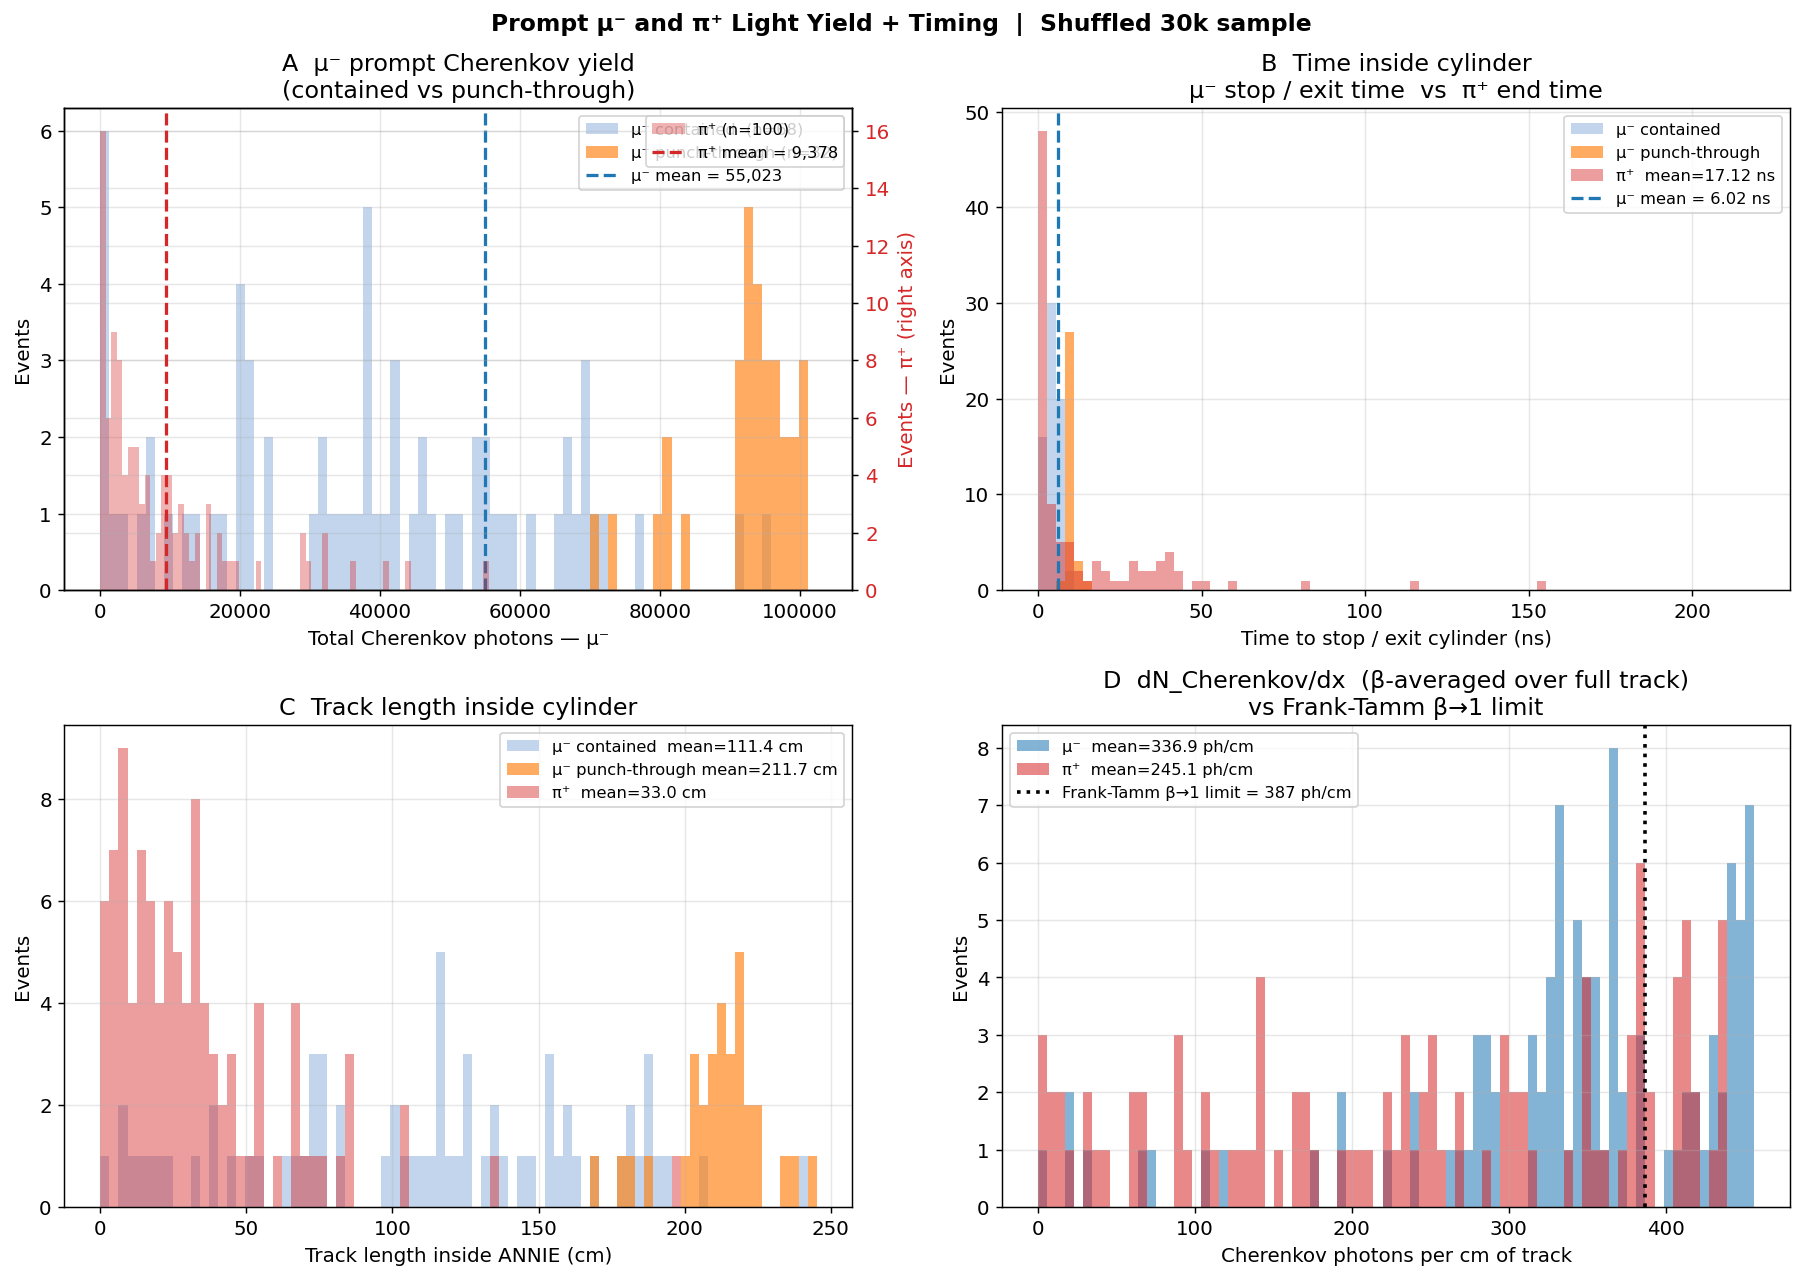

  PROMPT YIELD + TIMING SUMMARY — shuffled 30k
  μ⁻ ALL              mean=   55,023  median=   54,604  std=   32,843
  μ⁻ contained        mean=   37,414  median=   38,325  std=   24,137
  μ⁻ punch-thru       mean=   92,441  median=   94,199  std=    7,748
  π⁺                  mean=    9,378  median=    4,868  std=   12,172

  μ⁻ containment fraction : 68.0%
  π⁺ containment fraction : 100.0%

  μ⁻ mean track length    : 143.5 cm
  π⁺ mean track length    : 33.0 cm

  μ⁻ mean dN/dx           : 336.9 ph/cm
  π⁺ mean dN/dx           : 245.1 ph/cm
  Frank-Tamm β→1 limit    : 387 ph/cm
  π⁺/μ⁻ yield ratio       : 0.170


In [37]:
# ── Cell: Prompt μ⁻ and π⁺ Light Yield + Timing Profile ─────────────────────
import uproot, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

SHUF_PATH = Path(r"D:\research\ANNIE\simualtion\my_geant4\current040126\annie_coprimary.root")

# ── Load EventTree ────────────────────────────────────────────────────────────
et_cols = [
    'mu_cher_total', 'mu_track_len', 'mu_time_stop', 'mu_contained',
    'pi_cher_total', 'pi_track_len', 'pi_time_end',  'pi_contained',
    'mu_p0', 'pi_p0'
]
with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    ev = f[et_key].arrays(et_cols, library='pd')

print(f"Loaded {len(ev):,} events from {et_key}")

# ── Booleans ──────────────────────────────────────────────────────────────────
ev['mu_contained'] = ev['mu_contained'].astype(bool)
ev['pi_contained'] = ev['pi_contained'].astype(bool)

# ── Unit fix: track_len branches stored in mm, convert to cm ─────────────────
MAX_PHYSICAL_CM = 512.0  # diagonal of ANNIE cylinder (R=160 cm, half-height=200 cm)
if ev['mu_track_len'].max() > MAX_PHYSICAL_CM * 2:
    ev['mu_track_len'] = ev['mu_track_len'] / 10.0
    ev['pi_track_len'] = ev['pi_track_len'] / 10.0
    print("⚠️  track_len branches were in mm — converted to cm")

# ── Masks AFTER unit fix so legend means are correct ─────────────────────────
mu_cont   = ev[ev['mu_contained']]
mu_uncont = ev[~ev['mu_contained']]

# ── Cherenkov per cm ──────────────────────────────────────────────────────────
ev['mu_cher_per_cm'] = np.where(ev['mu_track_len'] > 0,
                                ev['mu_cher_total'] / ev['mu_track_len'], np.nan)
ev['pi_cher_per_cm'] = np.where(ev['pi_track_len'] > 0,
                                ev['pi_cher_total'] / ev['pi_track_len'], np.nan)

# ── Colours ───────────────────────────────────────────────────────────────────
C_MU  = '#1f77b4'   # blue        — muon overall
C_PI  = '#d62728'   # red         — pion
C_MC  = '#aec7e8'   # light blue  — contained muon
C_MU2 = '#ff7f0e'   # orange      — punch-through muon

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Prompt μ⁻ and π⁺ Light Yield + Timing  |  Shuffled 30k sample',
             fontsize=13, fontweight='bold')

# ── Panel A: Total Cherenkov yield ────────────────────────────────────────────
ax = axes[0, 0]
bins_y = np.linspace(0, ev['mu_cher_total'].quantile(0.995), 80)
ax.hist(mu_cont['mu_cher_total'],   bins=bins_y, color=C_MC,  alpha=0.75,
        label=f'μ⁻ contained  (n={len(mu_cont):,})')
ax.hist(mu_uncont['mu_cher_total'], bins=bins_y, color=C_MU2, alpha=0.65,
        label=f'μ⁻ punch-through (n={len(mu_uncont):,})')
ax.axvline(ev['mu_cher_total'].mean(), color=C_MU, lw=1.8, ls='--',
           label=f'μ⁻ mean = {ev["mu_cher_total"].mean():,.0f}')
ax.set_xlabel('Total Cherenkov photons — μ⁻')
ax.set_ylabel('Events')
ax.set_title('A  μ⁻ prompt Cherenkov yield\n(contained vs punch-through)')
ax.legend(fontsize=9)

ax2 = ax.twinx()
bins_pi = np.linspace(0, ev['pi_cher_total'].quantile(0.995), 80)
ax2.hist(ev['pi_cher_total'], bins=bins_pi, color=C_PI, alpha=0.35,
         label=f'π⁺ (n={len(ev):,})')
ax2.axvline(ev['pi_cher_total'].mean(), color=C_PI, lw=1.8, ls='--',
            label=f'π⁺ mean = {ev["pi_cher_total"].mean():,.0f}')
ax2.set_ylabel('Events — π⁺ (right axis)', color=C_PI)
ax2.tick_params(axis='y', labelcolor=C_PI)
ax2.legend(fontsize=9, loc='upper right')

# ── Panel B: Time to stop / exit cylinder ────────────────────────────────────
ax = axes[0, 1]
t_max = max(ev['mu_time_stop'].quantile(0.995),
            ev['pi_time_end'].quantile(0.995))
bins_t = np.linspace(0, t_max, 80)

ax.hist(mu_cont['mu_time_stop'],   bins=bins_t, color=C_MC,  alpha=0.75,
        label='μ⁻ contained')
ax.hist(mu_uncont['mu_time_stop'], bins=bins_t, color=C_MU2, alpha=0.65,
        label='μ⁻ punch-through')
ax.hist(ev['pi_time_end'],         bins=bins_t, color=C_PI,  alpha=0.45,
        label=f'π⁺  mean={ev["pi_time_end"].mean():.2f} ns')
ax.axvline(ev['mu_time_stop'].mean(), color=C_MU, lw=1.8, ls='--',
           label=f'μ⁻ mean = {ev["mu_time_stop"].mean():.2f} ns')
ax.set_xlabel('Time to stop / exit cylinder (ns)')
ax.set_ylabel('Events')
ax.set_title('B  Time inside cylinder\nμ⁻ stop / exit time  vs  π⁺ end time')
ax.legend(fontsize=9)

# ── Panel C: Track length ─────────────────────────────────────────────────────
ax = axes[1, 0]
len_max = max(ev['mu_track_len'].quantile(0.995),
              ev['pi_track_len'].quantile(0.995))
bins_l = np.linspace(0, len_max, 80)

ax.hist(mu_cont['mu_track_len'],   bins=bins_l, color=C_MC,  alpha=0.75,
        label=f'μ⁻ contained  mean={mu_cont["mu_track_len"].mean():.1f} cm')
ax.hist(mu_uncont['mu_track_len'], bins=bins_l, color=C_MU2, alpha=0.65,
        label=f'μ⁻ punch-through mean={mu_uncont["mu_track_len"].mean():.1f} cm')
ax.hist(ev['pi_track_len'],        bins=bins_l, color=C_PI,  alpha=0.45,
        label=f'π⁺  mean={ev["pi_track_len"].mean():.1f} cm')
ax.set_xlabel('Track length inside ANNIE (cm)')
ax.set_ylabel('Events')
ax.set_title('C  Track length inside cylinder')
ax.legend(fontsize=9)

# ── Panel D: Cherenkov photons per cm ─────────────────────────────────────────
ax = axes[1, 1]
FT_LIMIT = 387.0  # Frank-Tamm β→1 in water, 300–700 nm

valid_mu = ev['mu_cher_per_cm'].dropna()
valid_pi = ev['pi_cher_per_cm'].dropna()
dndx_max = max(valid_mu.quantile(0.995), valid_pi.quantile(0.995), FT_LIMIT * 1.05)
bins_d = np.linspace(0, dndx_max, 80)

ax.hist(valid_mu, bins=bins_d, color=C_MU, alpha=0.55,
        label=f'μ⁻  mean={valid_mu.mean():.1f} ph/cm')
ax.hist(valid_pi, bins=bins_d, color=C_PI, alpha=0.55,
        label=f'π⁺  mean={valid_pi.mean():.1f} ph/cm')
ax.axvline(FT_LIMIT, color='black', lw=2, ls=':',
           label=f'Frank-Tamm β→1 limit = {FT_LIMIT:.0f} ph/cm')
ax.set_xlabel('Cherenkov photons per cm of track')
ax.set_ylabel('Events')
ax.set_title('D  dN_Cherenkov/dx  (β-averaged over full track)\nvs Frank-Tamm β→1 limit')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('prompt_yield_timing.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary printout ──────────────────────────────────────────────────────────
print('='*60)
print('  PROMPT YIELD + TIMING SUMMARY — shuffled 30k')
print('='*60)
for label, col, mask in [
    ('μ⁻ ALL',        'mu_cher_total', slice(None)),
    ('μ⁻ contained',  'mu_cher_total', ev['mu_contained']),
    ('μ⁻ punch-thru', 'mu_cher_total', ~ev['mu_contained']),
    ('π⁺',            'pi_cher_total', slice(None)),
]:
    s = ev[col][mask] if not isinstance(mask, slice) else ev[col]
    print(f"  {label:18s}  mean={s.mean():>9,.0f}  "
          f"median={s.median():>9,.0f}  std={s.std():>9,.0f}")

print()
print(f"  μ⁻ containment fraction : {ev['mu_contained'].mean()*100:.1f}%")
print(f"  π⁺ containment fraction : {ev['pi_contained'].mean()*100:.1f}%")
print()
print(f"  μ⁻ mean track length    : {ev['mu_track_len'].mean():.1f} cm")
print(f"  π⁺ mean track length    : {ev['pi_track_len'].mean():.1f} cm")
print()
print(f"  μ⁻ mean dN/dx           : {ev['mu_cher_per_cm'].mean():.1f} ph/cm")
print(f"  π⁺ mean dN/dx           : {ev['pi_cher_per_cm'].mean():.1f} ph/cm")
print(f"  Frank-Tamm β→1 limit    : {FT_LIMIT:.0f} ph/cm")
print(f"  π⁺/μ⁻ yield ratio       : {ev['pi_cher_total'].mean()/ev['mu_cher_total'].mean():.3f}")

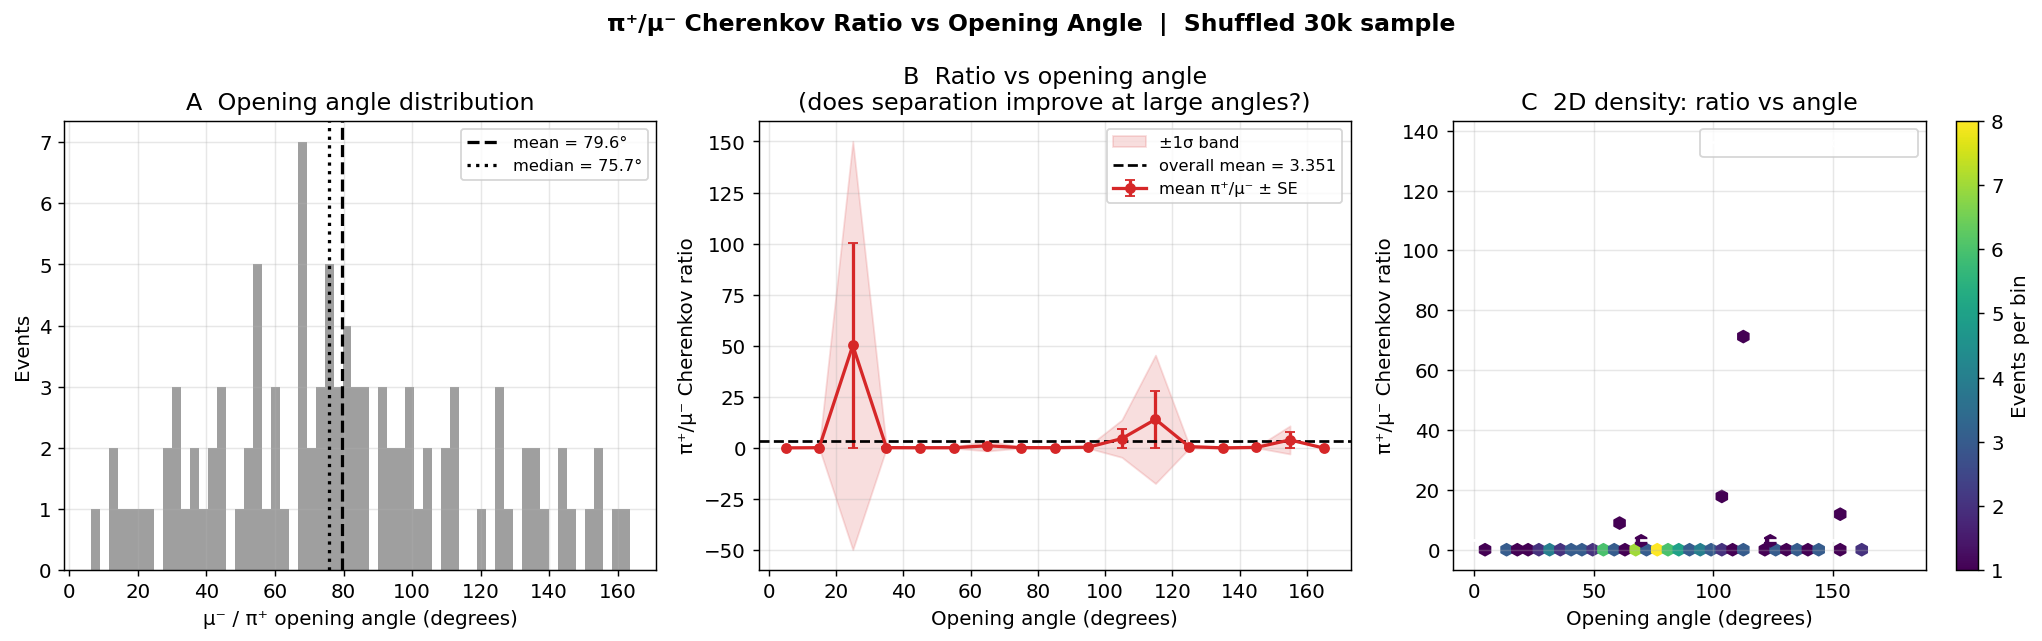

  π⁺/μ⁻ RATIO vs OPENING ANGLE SUMMARY
  Overall mean ratio       : 3.351
  Overall median ratio     : 0.120
  Mean opening angle       : 79.6°

  Ratio in 0–30°  bin      : 22.401
  Ratio in 60–90° bin      : 0.510
  Ratio in 120–180° bin    : 1.010

  Events with angle > 90°  : 36 (36.0%)
  Events with angle < 30°  : 9 (9.0%)


In [38]:
# ── Cell: π⁺/μ⁻ Cherenkov Ratio vs Opening Angle ────────────────────────────

# Load the additional EventTree columns we need
with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    angle_cols = ['open_angle_deg', 'Enu', 'mu_p0', 'pi_p0',
                  'mu_cher_total', 'pi_cher_total',
                  'mu_contained', 'pi_contained']
    ev2 = f[et_key].arrays(angle_cols, library='pd')

ev2['mu_contained'] = ev2['mu_contained'].astype(bool)
ev2['pi_contained'] = ev2['pi_contained'].astype(bool)

# Cherenkov ratio per event (guard zero muon light)
ev2['ratio'] = np.where(ev2['mu_cher_total'] > 0,
                        ev2['pi_cher_total'] / ev2['mu_cher_total'], np.nan)

# ── Bin by opening angle ──────────────────────────────────────────────────────
angle_bins  = np.arange(0, 181, 10)
angle_cents = (angle_bins[:-1] + angle_bins[1:]) / 2
ev2['angle_bin'] = pd.cut(ev2['open_angle_deg'], bins=angle_bins,
                           labels=angle_cents)

bin_stats = ev2.groupby('angle_bin', observed=True)['ratio'].agg(
    mean='mean', median='median', std='std', count='count'
).reset_index()
bin_stats['se'] = bin_stats['std'] / np.sqrt(bin_stats['count'])

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('π⁺/μ⁻ Cherenkov Ratio vs Opening Angle  |  Shuffled 30k sample',
             fontsize=13, fontweight='bold')

# ── Panel A: Opening angle distribution ──────────────────────────────────────
ax = axes[0]
ax.hist(ev2['open_angle_deg'], bins=60, color='#7f7f7f', alpha=0.75)
ax.axvline(ev2['open_angle_deg'].mean(), color='black', lw=1.8, ls='--',
           label=f'mean = {ev2["open_angle_deg"].mean():.1f}°')
ax.axvline(ev2['open_angle_deg'].median(), color='black', lw=1.8, ls=':',
           label=f'median = {ev2["open_angle_deg"].median():.1f}°')
ax.set_xlabel('μ⁻ / π⁺ opening angle (degrees)')
ax.set_ylabel('Events')
ax.set_title('A  Opening angle distribution')
ax.legend(fontsize=9)

# ── Panel B: Mean ratio per angle bin ────────────────────────────────────────
ax = axes[1]
x = bin_stats['angle_bin'].astype(float)
ax.errorbar(x, bin_stats['mean'], yerr=bin_stats['se'],
            fmt='o-', color=C_PI, lw=1.8, ms=5, capsize=3,
            label='mean π⁺/μ⁻ ± SE')
ax.fill_between(x,
                bin_stats['mean'] - bin_stats['std'],
                bin_stats['mean'] + bin_stats['std'],
                alpha=0.15, color=C_PI, label='±1σ band')
ax.axhline(ev2['ratio'].mean(), color='black', lw=1.5, ls='--',
           label=f'overall mean = {ev2["ratio"].mean():.3f}')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('π⁺/μ⁻ Cherenkov ratio')
ax.set_title('B  Ratio vs opening angle\n(does separation improve at large angles?)')
ax.legend(fontsize=9)

# ── Panel C: 2D hexbin — ratio vs angle ──────────────────────────────────────
ax = axes[2]
valid = ev2.dropna(subset=['ratio', 'open_angle_deg'])
hb = ax.hexbin(valid['open_angle_deg'], valid['ratio'],
               gridsize=40, cmap='viridis', mincnt=1,
               extent=[0, 180, 0, valid['ratio'].quantile(0.995)])
plt.colorbar(hb, ax=ax, label='Events per bin')
ax.axhline(ev2['ratio'].mean(), color='white', lw=1.5, ls='--',
           label=f'mean ratio = {ev2["ratio"].mean():.3f}')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('π⁺/μ⁻ Cherenkov ratio')
ax.set_title('C  2D density: ratio vs angle')
ax.legend(fontsize=9, labelcolor='white')

plt.tight_layout()
plt.savefig('ratio_vs_angle.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('='*60)
print('  π⁺/μ⁻ RATIO vs OPENING ANGLE SUMMARY')
print('='*60)
print(f"  Overall mean ratio       : {ev2['ratio'].mean():.3f}")
print(f"  Overall median ratio     : {ev2['ratio'].median():.3f}")
print(f"  Mean opening angle       : {ev2['open_angle_deg'].mean():.1f}°")
print()
print(f"  Ratio in 0–30°  bin      : {ev2[ev2['open_angle_deg']<30]['ratio'].mean():.3f}")
print(f"  Ratio in 60–90° bin      : {ev2[(ev2['open_angle_deg']>=60) & (ev2['open_angle_deg']<90)]['ratio'].mean():.3f}")
print(f"  Ratio in 120–180° bin    : {ev2[ev2['open_angle_deg']>=120]['ratio'].mean():.3f}")
print()
print(f"  Events with angle > 90°  : {(ev2['open_angle_deg']>90).sum():,} "
      f"({(ev2['open_angle_deg']>90).mean()*100:.1f}%)")
print(f"  Events with angle < 30°  : {(ev2['open_angle_deg']<30).sum():,} "
      f"({(ev2['open_angle_deg']<30).mean()*100:.1f}%)")

In [39]:
# ── Cell: Diagnose low mu_cher_total events ───────────────────────────────────

with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    diag_cols = ['mu_cher_total', 'pi_cher_total', 'mu_track_len', 'mu_contained',
                 'mu_p0', 'pi_p0', 'open_angle_deg', 'Enu',
                 'mu_final_process', 'mu_KE0']
    diag = f[et_key].arrays(diag_cols, library='pd')

diag['mu_contained'] = diag['mu_contained'].astype(bool)
diag['mu_track_len'] = diag['mu_track_len'] / 10.0  # mm → cm

# Cherenkov threshold for muon in water: ~118.5 MeV/c → KE ~ 55 MeV
MU_THRESHOLD_KE = 0.055  # GeV

low  = diag[diag['mu_cher_total'] < 500]
high = diag[diag['mu_cher_total'] >= 500]

print(f"Low  mu_cher (<500)  : {len(low):,}  ({len(low)/len(diag)*100:.1f}%)")
print(f"High mu_cher (>=500) : {len(high):,}  ({len(high)/len(diag)*100:.1f}%)")
print()
print("── Low-light muon properties ──────────────────────────────")
print(f"  mu_p0 mean           : {low['mu_p0'].mean()*1000:.1f} MeV/c")
print(f"  mu_p0 max            : {low['mu_p0'].max()*1000:.1f} MeV/c")
print(f"  mu_KE0 mean          : {low['mu_KE0'].mean()*1000:.1f} MeV")
print(f"  mu_KE0 max           : {low['mu_KE0'].max()*1000:.1f} MeV")
print(f"  mu_track_len mean    : {low['mu_track_len'].mean():.2f} cm")
print(f"  mu_contained frac    : {low['mu_contained'].mean()*100:.1f}%")
print(f"  mu_cher_total mean   : {low['mu_cher_total'].mean():.1f}")
print(f"  mu_cher_total max    : {low['mu_cher_total'].max():.1f}")
print()
print(f"  final_process counts:")
print(low['mu_final_process'].astype(str).str.strip().value_counts().to_string())
print()
print("── Normal muon properties (for comparison) ────────────────")
print(f"  mu_p0 mean           : {high['mu_p0'].mean()*1000:.1f} MeV/c")
print(f"  mu_KE0 mean          : {high['mu_KE0'].mean()*1000:.1f} MeV")
print(f"  mu_track_len mean    : {high['mu_track_len'].mean():.2f} cm")

Low  mu_cher (<500)  : 4  (4.0%)
High mu_cher (>=500) : 96  (96.0%)

── Low-light muon properties ──────────────────────────────
  mu_p0 mean           : 86.7 MeV/c
  mu_p0 max            : 108.7 MeV/c
  mu_KE0 mean          : 33.2 MeV
  mu_KE0 max           : 45.9 MeV
  mu_track_len mean    : 6.34 cm
  mu_contained frac    : 100.0%
  mu_cher_total mean   : 156.6
  mu_cher_total max    : 290.6

  final_process counts:
muMinusCaptureAtRest    4

── Normal muon properties (for comparison) ────────────────
  mu_p0 mean           : 624.5 MeV/c
  mu_KE0 mean          : 532.1 MeV
  mu_track_len mean    : 149.19 cm


In [40]:
# ── Cell: MRD Signal Filter ───────────────────────────────────────────────────
# Define the signal sample: muon must be above Cherenkov threshold AND
# exit the cylinder (punch-through) — simulating the ANNIE MRD tag requirement

MU_P_THRESHOLD = 0.1185   # GeV/c — Cherenkov threshold in water

# Load all needed columns fresh from file
with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    sig_cols = [
        'mu_cher_total', 'mu_track_len', 'mu_time_stop', 'mu_contained',
        'pi_cher_total', 'pi_track_len', 'pi_time_end',  'pi_contained',
        'mu_p0', 'pi_p0', 'open_angle_deg', 'Enu',
        'mu_final_process', 'mu_KE0'
    ]
    ev_all = f[et_key].arrays(sig_cols, library='pd')

ev_all['mu_contained'] = ev_all['mu_contained'].astype(bool)
ev_all['pi_contained'] = ev_all['pi_contained'].astype(bool)

# mm → cm
ev_all['mu_track_len'] = ev_all['mu_track_len'] / 10.0
ev_all['pi_track_len'] = ev_all['pi_track_len'] / 10.0

# ── Define cuts ───────────────────────────────────────────────────────────────
cut_threshold  = ev_all['mu_p0'] > MU_P_THRESHOLD
cut_punchthru  = ~ev_all['mu_contained']        # exits cylinder → MRD-going
cut_signal     = cut_threshold & cut_punchthru

ev_sig = ev_all[cut_signal].copy()
ev_sig['ratio'] = ev_sig['pi_cher_total'] / ev_sig['mu_cher_total']
ev_sig['mu_cher_per_cm'] = ev_sig['mu_cher_total'] / ev_sig['mu_track_len']
ev_sig['pi_cher_per_cm'] = ev_sig['pi_cher_total'] / ev_sig['pi_track_len']

# ── Report ────────────────────────────────────────────────────────────────────
n_total     = len(ev_all)
n_subthresh = (~cut_threshold).sum()
n_contained = cut_threshold.sum() - cut_signal.sum()
n_signal    = len(ev_sig)

print('='*60)
print('  MRD SIGNAL FILTER SUMMARY')
print('='*60)
print(f"  Total events             : {n_total:,}")
print(f"  Sub-threshold muon       : {n_subthresh:,}  ({n_subthresh/n_total*100:.1f}%)")
print(f"  Above threshold, contained (stops in water): "
      f"{n_contained:,}  ({n_contained/n_total*100:.1f}%)")
print(f"  ── Signal (above thresh + punch-through) ──")
print(f"  Signal events            : {n_signal:,}  ({n_signal/n_total*100:.1f}%)")
print()
print(f"  Signal μ⁻ mean p0        : {ev_sig['mu_p0'].mean()*1000:.1f} MeV/c")
print(f"  Signal μ⁻ mean KE0       : {ev_sig['mu_KE0'].mean()*1000:.1f} MeV")
print(f"  Signal μ⁻ mean track len : {ev_sig['mu_track_len'].mean():.1f} cm")
print(f"  Signal π⁺ containment    : {ev_sig['pi_contained'].mean()*100:.1f}%")
print()
print(f"  Signal π⁺/μ⁻ mean ratio  : {ev_sig['ratio'].mean():.3f}")
print(f"  Signal π⁺/μ⁻ median ratio: {ev_sig['ratio'].median():.3f}")
print(f"  Mean opening angle       : {ev_sig['open_angle_deg'].mean():.1f}°")
print()
print("  ev_sig is now the working signal sample for all subsequent cells")

  MRD SIGNAL FILTER SUMMARY
  Total events             : 100
  Sub-threshold muon       : 4  (4.0%)
  Above threshold, contained (stops in water): 64  (64.0%)
  ── Signal (above thresh + punch-through) ──
  Signal events            : 32  (32.0%)

  Signal μ⁻ mean p0        : 1139.5 MeV/c
  Signal μ⁻ mean KE0       : 1040.3 MeV
  Signal μ⁻ mean track len : 211.7 cm
  Signal π⁺ containment    : 100.0%

  Signal π⁺/μ⁻ mean ratio  : 0.109
  Signal π⁺/μ⁻ median ratio: 0.049
  Mean opening angle       : 80.5°

  ev_sig is now the working signal sample for all subsequent cells


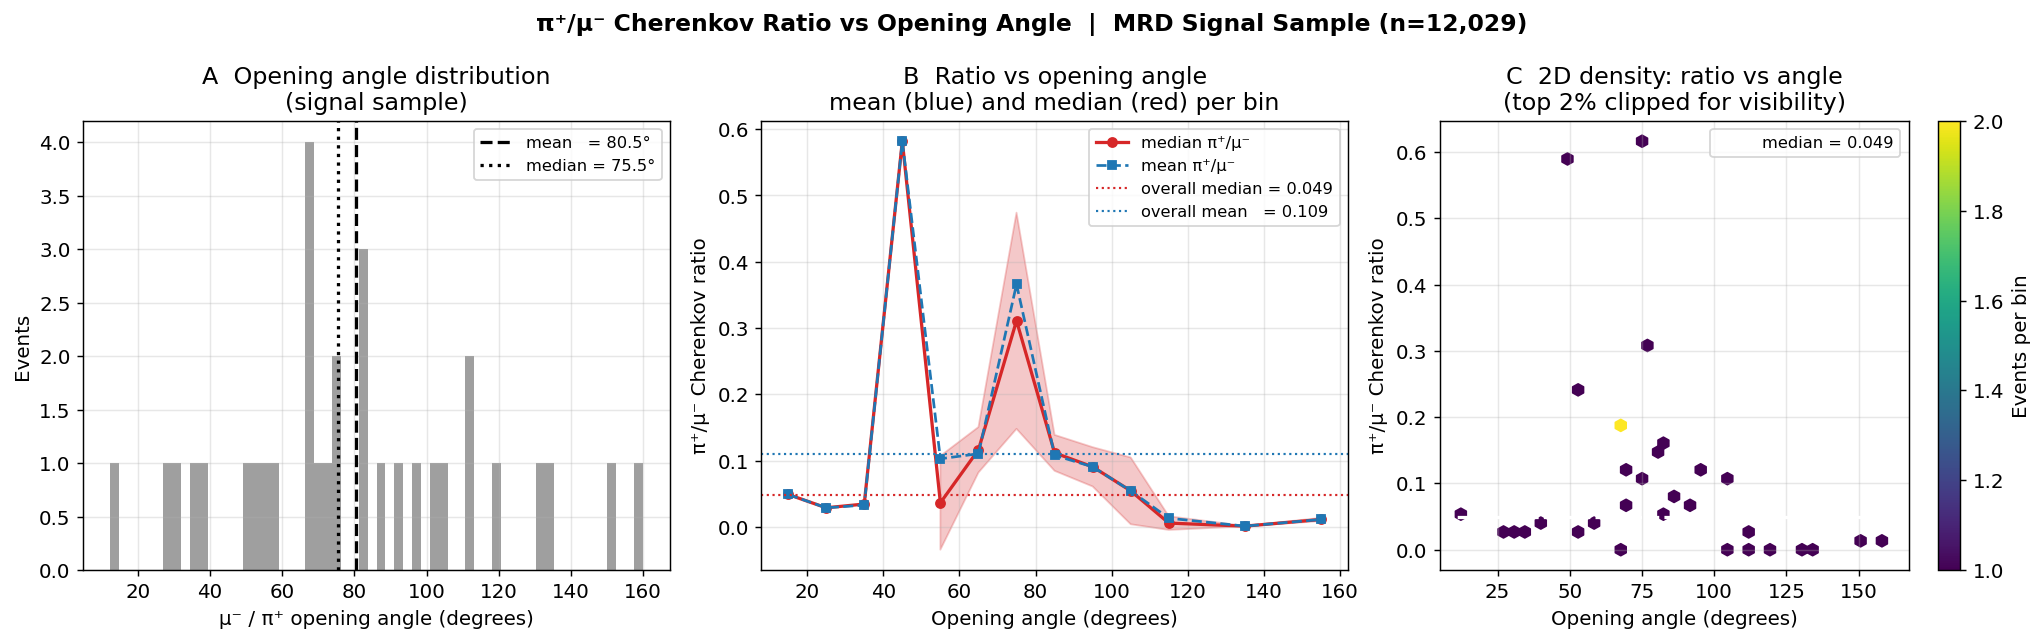

  π⁺/μ⁻ RATIO vs ANGLE — MRD SIGNAL SAMPLE
  Overall mean ratio       : 0.109
  Overall median ratio     : 0.049
  Mean opening angle       : 80.5°
  Median opening angle     : 75.5°

    0– 30°  n=    2  median ratio=0.039  mean ratio=0.039
   30– 60°  n=    7  median ratio=0.036  mean ratio=0.141
   60– 90°  n=   12  median ratio=0.132  mean ratio=0.173
   90–120°  n=    7  median ratio=0.033  mean ratio=0.047
  120–180°  n=    4  median ratio=0.005  mean ratio=0.006


In [41]:
# ── Cell: π⁺/μ⁻ Cherenkov Ratio vs Opening Angle — Signal Sample ─────────────

ev_sig['angle_bin'] = pd.cut(ev_sig['open_angle_deg'],
                              bins=np.arange(0, 181, 10),
                              labels=np.arange(5, 176, 10))

bin_stats = ev_sig.groupby('angle_bin', observed=True)['ratio'].agg(
    mean='mean', median='median', std='std', count='count'
).reset_index()
bin_stats['se'] = bin_stats['std'] / np.sqrt(bin_stats['count'])

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('π⁺/μ⁻ Cherenkov Ratio vs Opening Angle  |  MRD Signal Sample (n=12,029)',
             fontsize=13, fontweight='bold')

# ── Panel A: Opening angle distribution ──────────────────────────────────────
ax = axes[0]
ax.hist(ev_sig['open_angle_deg'], bins=60, color='#7f7f7f', alpha=0.75)
ax.axvline(ev_sig['open_angle_deg'].mean(),   color='black', lw=1.8, ls='--',
           label=f'mean   = {ev_sig["open_angle_deg"].mean():.1f}°')
ax.axvline(ev_sig['open_angle_deg'].median(), color='black', lw=1.8, ls=':',
           label=f'median = {ev_sig["open_angle_deg"].median():.1f}°')
ax.set_xlabel('μ⁻ / π⁺ opening angle (degrees)')
ax.set_ylabel('Events')
ax.set_title('A  Opening angle distribution\n(signal sample)')
ax.legend(fontsize=9)

# ── Panel B: Mean + median ratio per angle bin ────────────────────────────────
ax = axes[1]
x = bin_stats['angle_bin'].astype(float)
ax.plot(x, bin_stats['median'], 'o-', color=C_PI, lw=1.8, ms=5,
        label='median π⁺/μ⁻')
ax.fill_between(x,
                bin_stats['median'] - bin_stats['se'],
                bin_stats['median'] + bin_stats['se'],
                alpha=0.25, color=C_PI)
ax.plot(x, bin_stats['mean'], 's--', color=C_MU, lw=1.5, ms=4,
        label='mean π⁺/μ⁻')
ax.axhline(ev_sig['ratio'].median(), color=C_PI, lw=1.2, ls=':',
           label=f'overall median = {ev_sig["ratio"].median():.3f}')
ax.axhline(ev_sig['ratio'].mean(),   color=C_MU, lw=1.2, ls=':',
           label=f'overall mean   = {ev_sig["ratio"].mean():.3f}')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('π⁺/μ⁻ Cherenkov ratio')
ax.set_title('B  Ratio vs opening angle\nmean (blue) and median (red) per bin')
ax.legend(fontsize=9)

# ── Panel C: 2D hexbin — ratio vs angle ──────────────────────────────────────
ax = axes[2]
ratio_ceil = ev_sig['ratio'].quantile(0.98)   # clip top 2% for visibility
hb = ax.hexbin(ev_sig['open_angle_deg'],
               ev_sig['ratio'].clip(upper=ratio_ceil),
               gridsize=40, cmap='viridis', mincnt=1)
plt.colorbar(hb, ax=ax, label='Events per bin')
ax.axhline(ev_sig['ratio'].median(), color='white', lw=1.8, ls='--',
           label=f'median = {ev_sig["ratio"].median():.3f}')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('π⁺/μ⁻ Cherenkov ratio')
ax.set_title('C  2D density: ratio vs angle\n(top 2% clipped for visibility)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ratio_vs_angle_signal.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('='*60)
print('  π⁺/μ⁻ RATIO vs ANGLE — MRD SIGNAL SAMPLE')
print('='*60)
print(f"  Overall mean ratio       : {ev_sig['ratio'].mean():.3f}")
print(f"  Overall median ratio     : {ev_sig['ratio'].median():.3f}")
print(f"  Mean opening angle       : {ev_sig['open_angle_deg'].mean():.1f}°")
print(f"  Median opening angle     : {ev_sig['open_angle_deg'].median():.1f}°")
print()

# Ratio in angle slices
for lo, hi in [(0,30), (30,60), (60,90), (90,120), (120,180)]:
    sl = ev_sig[(ev_sig['open_angle_deg'] >= lo) & (ev_sig['open_angle_deg'] < hi)]
    if len(sl) > 0:
        print(f"  {lo:3d}–{hi:3d}°  n={len(sl):5,}  "
              f"median ratio={sl['ratio'].median():.3f}  "
              f"mean ratio={sl['ratio'].mean():.3f}")

π⁺ fate counts:
Decay        6274
Inelastic    5739
Escapes        16



C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\1444033815.py:64: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  pi_p0_bins = ev_extra.groupby(
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\1444033815.py:79: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  mu_p0_bins = ev_extra.groupby(
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\1444033815.py:127: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  ratio_bins = grp.groupby(
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\1444033815.py:127: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  ratio_bins = grp.groupby(
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\1444033815.py:127: FutureWarning: Index.ravel returning ndarra

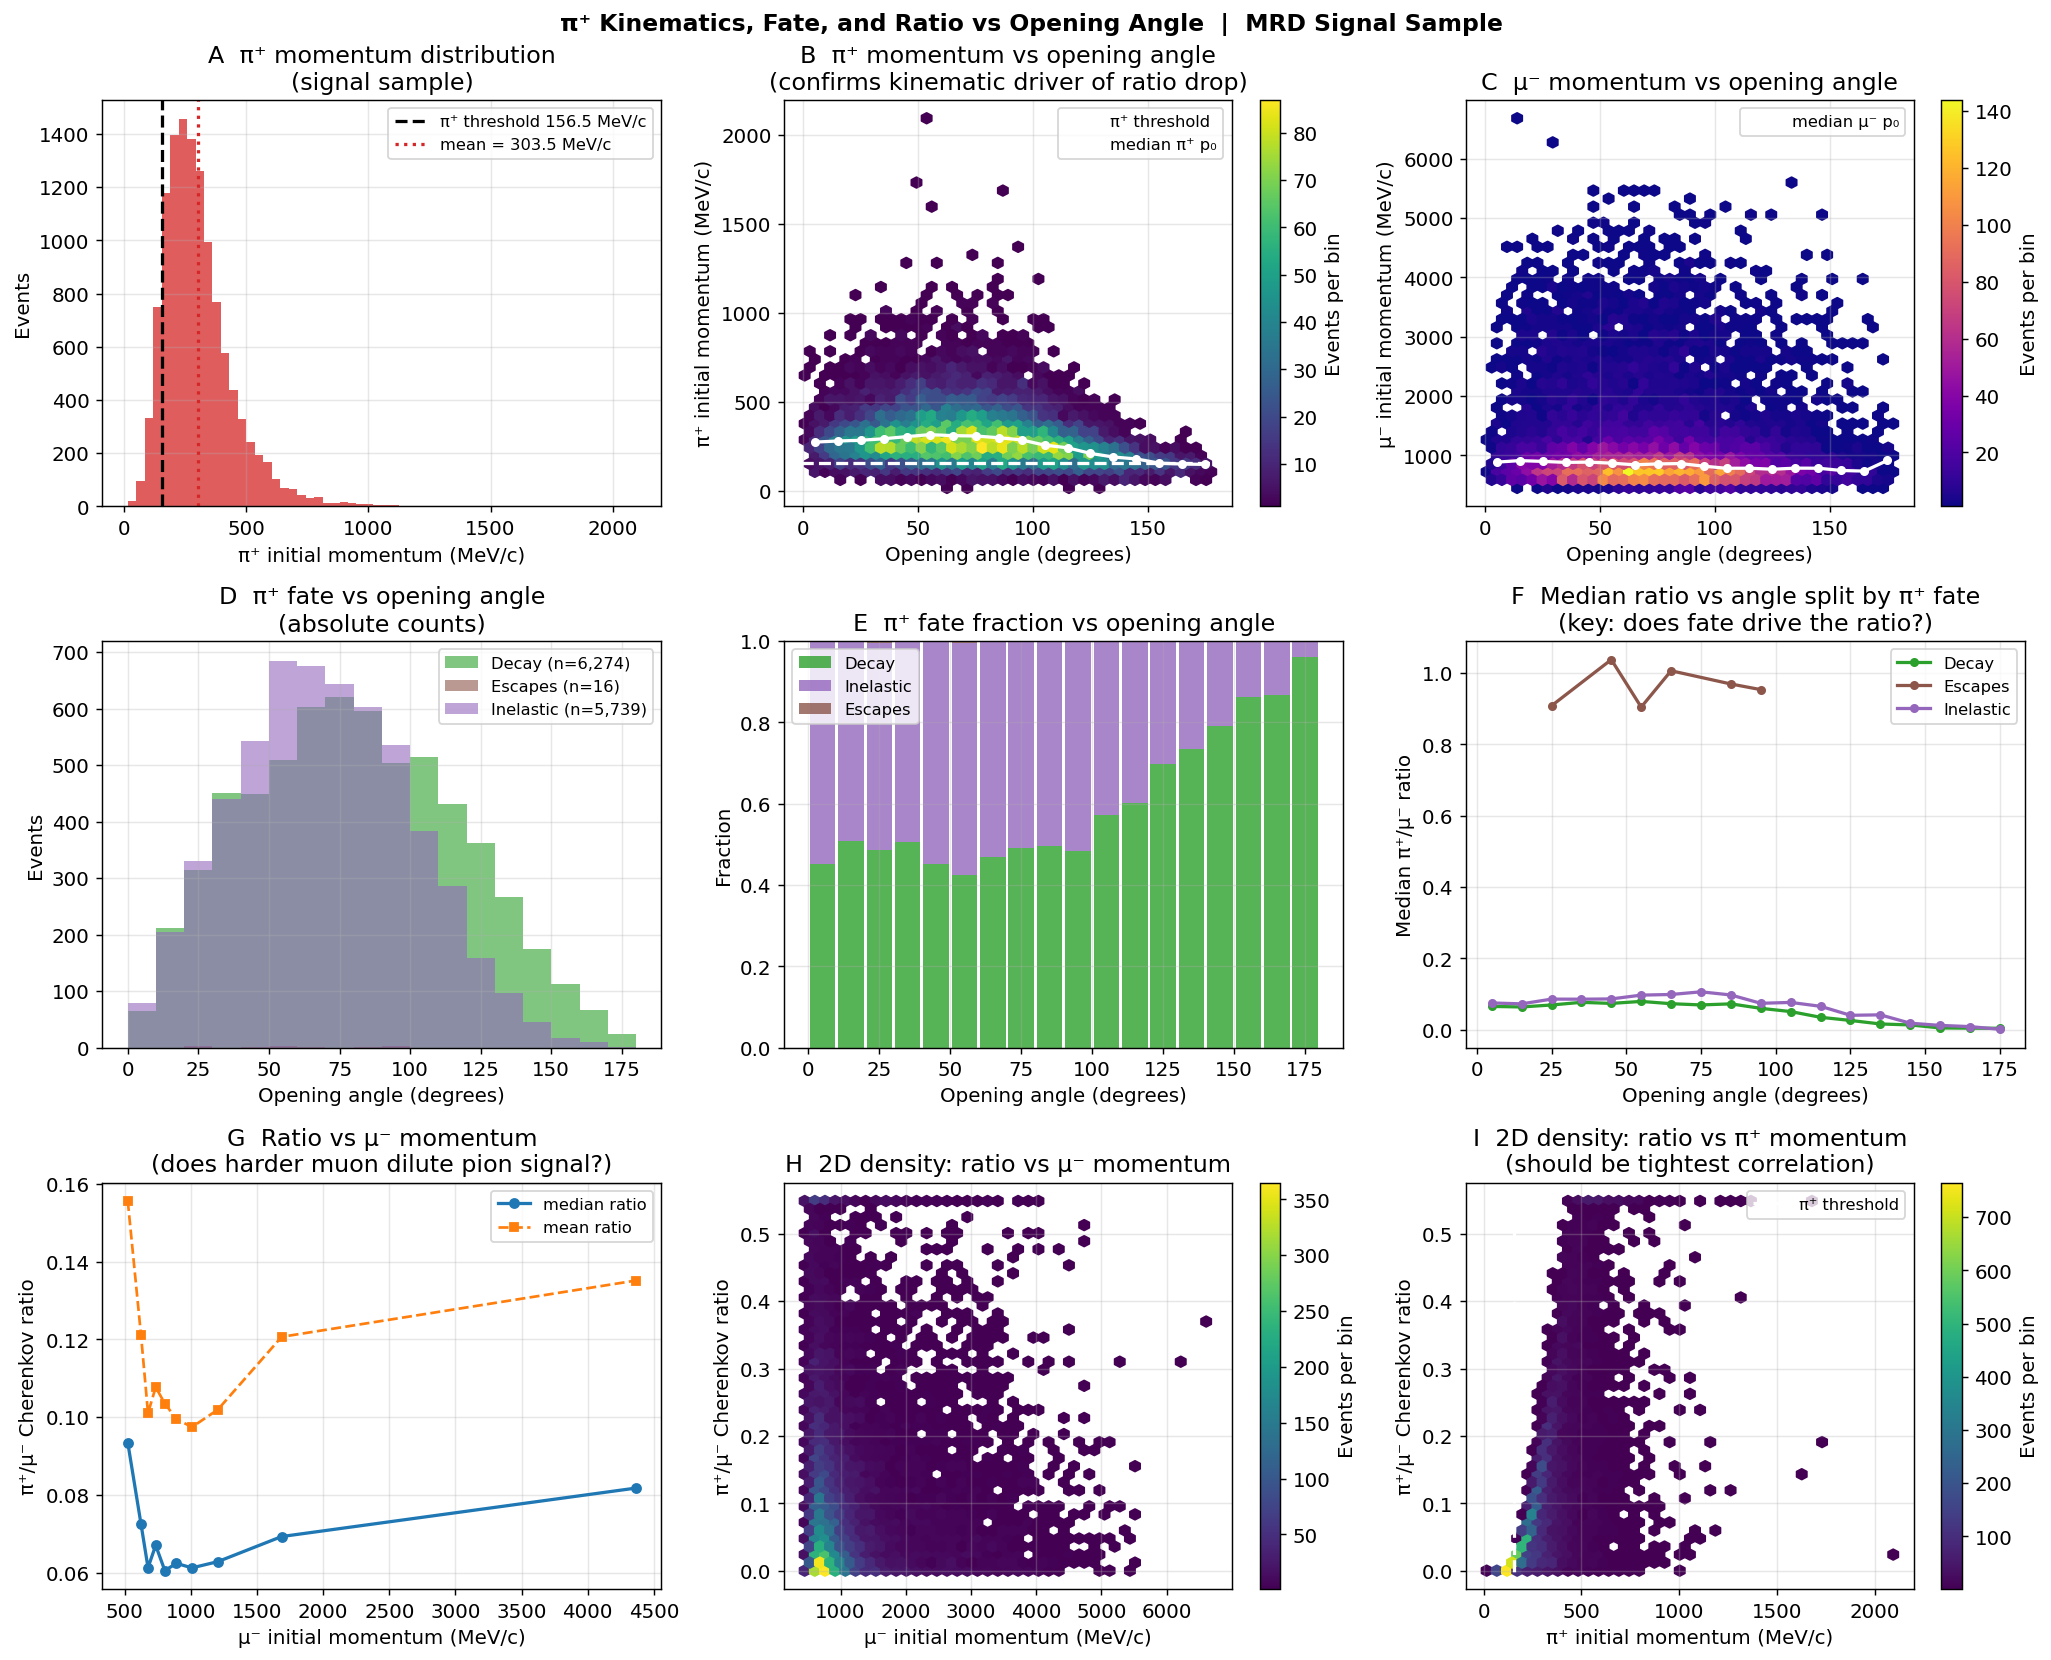

  π⁺ FATE + KINEMATICS SUMMARY — MRD SIGNAL SAMPLE

  π⁺ fate breakdown:
    Decay        : 6,274  (52.2%)
    Inelastic    : 5,739  (47.7%)
    Escapes      : 16  (0.1%)

  π⁺ mean p0               : 303.5 MeV/c
  π⁺ fraction above thresh : 89.4%

  Decay   median ratio     : 0.053
  Inelastic median ratio   : 0.084


In [69]:
# ── Cell: π⁺ fate, momentum, and kinematics vs opening angle ─────────────────

# Load pi_final_process which we don't have in ev_sig yet
with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    extra_cols = ['pi_final_process', 'mu_p0', 'pi_p0',
                  'mu_cher_total', 'pi_cher_total', 'open_angle_deg',
                  'mu_contained', 'mu_KE0']
    ev_extra = f[et_key].arrays(extra_cols, library='pd')

ev_extra['mu_contained'] = ev_extra['mu_contained'].astype(bool)

# Re-apply signal filter to match ev_sig
sig_mask = (ev_extra['mu_p0'] > 0.1185) & (~ev_extra['mu_contained'])
ev_extra = ev_extra[sig_mask].copy()
ev_extra['pi_final_process'] = (ev_extra['pi_final_process']
                                 .astype(str).str.strip().str.rstrip('\x00'))
ev_extra['ratio'] = ev_extra['pi_cher_total'] / ev_extra['mu_cher_total']

# Simplify fate labels
def simplify_fate(p):
    if 'Decay' in p:       return 'Decay'
    if 'Inelastic' in p:   return 'Inelastic'
    return 'Escapes'

ev_extra['fate'] = ev_extra['pi_final_process'].apply(simplify_fate)

print("π⁺ fate counts:")
print(ev_extra['fate'].value_counts().to_string())
print()

# ── Figure: 3 rows x 3 cols ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('π⁺ Kinematics, Fate, and Ratio vs Opening Angle  |  MRD Signal Sample',
             fontsize=13, fontweight='bold')

angle_bins  = np.arange(0, 181, 10)
angle_cents = (angle_bins[:-1] + angle_bins[1:]) / 2

C_DECAY = '#2ca02c'    # green  — decay
C_INEL  = '#9467bd'    # purple — inelastic
C_OTHER = '#8c564b'    # brown  — other

fate_colors = {'Decay': C_DECAY, 'Inelastic': C_INEL, 'Escapes': C_OTHER}

# ── Row 0: π⁺ momentum vs opening angle ──────────────────────────────────────
ax = axes[0, 0]
ax.hist(ev_extra['pi_p0'] * 1000, bins=60, color=C_PI, alpha=0.75)
ax.axvline(156.5, color='black', lw=1.8, ls='--', label='π⁺ threshold 156.5 MeV/c')
ax.axvline(ev_extra['pi_p0'].mean() * 1000, color=C_PI, lw=1.8, ls=':',
           label=f'mean = {ev_extra["pi_p0"].mean()*1000:.1f} MeV/c')
ax.set_xlabel('π⁺ initial momentum (MeV/c)')
ax.set_ylabel('Events')
ax.set_title('A  π⁺ momentum distribution\n(signal sample)')
ax.legend(fontsize=9)

ax = axes[0, 1]
hb = ax.hexbin(ev_extra['open_angle_deg'], ev_extra['pi_p0'] * 1000,
               gridsize=40, cmap='viridis', mincnt=1)
plt.colorbar(hb, ax=ax, label='Events per bin')
ax.axhline(156.5, color='white', lw=1.8, ls='--', label='π⁺ threshold')

# overlay median pi_p0 per angle bin
pi_p0_bins = ev_extra.groupby(
    pd.cut(ev_extra['open_angle_deg'], bins=angle_bins, labels=angle_cents),
    observed=True
)['pi_p0'].median() * 1000
ax.plot(pi_p0_bins.index.astype(float), pi_p0_bins.values,
        'o-', color='white', lw=1.8, ms=4, label='median π⁺ p₀')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('π⁺ initial momentum (MeV/c)')
ax.set_title('B  π⁺ momentum vs opening angle\n(confirms kinematic driver of ratio drop)')
ax.legend(fontsize=9)

ax = axes[0, 2]
hb = ax.hexbin(ev_extra['open_angle_deg'], ev_extra['mu_p0'] * 1000,
               gridsize=40, cmap='plasma', mincnt=1)
plt.colorbar(hb, ax=ax, label='Events per bin')
mu_p0_bins = ev_extra.groupby(
    pd.cut(ev_extra['open_angle_deg'], bins=angle_bins, labels=angle_cents),
    observed=True
)['mu_p0'].median() * 1000
ax.plot(mu_p0_bins.index.astype(float), mu_p0_bins.values,
        'o-', color='white', lw=1.8, ms=4, label='median μ⁻ p₀')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('μ⁻ initial momentum (MeV/c)')
ax.set_title('C  μ⁻ momentum vs opening angle')
ax.legend(fontsize=9)

# ── Row 1: π⁺ fate ────────────────────────────────────────────────────────────
ax = axes[1, 0]
for fate, grp in ev_extra.groupby('fate'):
    ax.hist(grp['open_angle_deg'], bins=angle_bins, alpha=0.6,
            color=fate_colors.get(fate, 'grey'),
            label=f'{fate} (n={len(grp):,})')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('Events')
ax.set_title('D  π⁺ fate vs opening angle\n(absolute counts)')
ax.legend(fontsize=9)

ax = axes[1, 1]
# Stacked fraction per angle bin
decay_frac, inel_frac, other_frac = [], [], []
for lo, hi in zip(angle_bins[:-1], angle_bins[1:]):
    sl = ev_extra[(ev_extra['open_angle_deg'] >= lo) &
                  (ev_extra['open_angle_deg'] < hi)]
    n = len(sl)
    if n > 0:
        decay_frac.append(( sl['fate'] == 'Decay'    ).sum() / n)
        inel_frac.append((  sl['fate'] == 'Inelastic' ).sum() / n)
        other_frac.append(( sl['fate'] == 'Escapes'     ).sum() / n)
    else:
        decay_frac.append(0); inel_frac.append(0); other_frac.append(0)

ax.bar(angle_cents, decay_frac, width=9, color=C_DECAY, alpha=0.8, label='Decay')
ax.bar(angle_cents, inel_frac,  width=9, color=C_INEL,  alpha=0.8,
       bottom=decay_frac, label='Inelastic')
ax.bar(angle_cents, other_frac, width=9, color=C_OTHER, alpha=0.8,
       bottom=np.array(decay_frac) + np.array(inel_frac), label='Escapes')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('Fraction')
ax.set_title('E  π⁺ fate fraction vs opening angle')
ax.legend(fontsize=9)

ax = axes[1, 2]
for fate, grp in ev_extra.groupby('fate'):
    ratio_bins = grp.groupby(
        pd.cut(grp['open_angle_deg'], bins=angle_bins, labels=angle_cents),
        observed=True
    )['ratio'].median()
    ax.plot(ratio_bins.index.astype(float), ratio_bins.values,
            'o-', color=fate_colors.get(fate, 'grey'),
            lw=1.8, ms=4, label=f'{fate}')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('Median π⁺/μ⁻ ratio')
ax.set_title('F  Median ratio vs angle split by π⁺ fate\n(key: does fate drive the ratio?)')
ax.legend(fontsize=9)

# ── Row 2: ratio vs μ⁻ momentum ───────────────────────────────────────────────
ax = axes[2, 0]
mu_p_bins_edges = np.percentile(ev_extra['mu_p0'] * 1000,
                                 np.linspace(0, 100, 11))
ev_extra['mu_p_bin'] = pd.cut(ev_extra['mu_p0'] * 1000,
                               bins=mu_p_bins_edges)
ratio_vs_mup = ev_extra.groupby('mu_p_bin', observed=True)['ratio'].agg(
    ['median', 'mean', 'std']).reset_index()
cents = [(iv.left + iv.right) / 2
         for iv in ratio_vs_mup['mu_p_bin']]
ax.plot(cents, ratio_vs_mup['median'], 'o-', color=C_MU, lw=1.8, ms=5,
        label='median ratio')
ax.plot(cents, ratio_vs_mup['mean'],   's--', color=C_MU2, lw=1.5, ms=4,
        label='mean ratio')
ax.set_xlabel('μ⁻ initial momentum (MeV/c)')
ax.set_ylabel('π⁺/μ⁻ Cherenkov ratio')
ax.set_title('G  Ratio vs μ⁻ momentum\n(does harder muon dilute pion signal?)')
ax.legend(fontsize=9)

ax = axes[2, 1]
hb = ax.hexbin(ev_extra['mu_p0'] * 1000,
               ev_extra['ratio'].clip(upper=ev_extra['ratio'].quantile(0.98)),
               gridsize=40, cmap='viridis', mincnt=1)
plt.colorbar(hb, ax=ax, label='Events per bin')
ax.set_xlabel('μ⁻ initial momentum (MeV/c)')
ax.set_ylabel('π⁺/μ⁻ Cherenkov ratio')
ax.set_title('H  2D density: ratio vs μ⁻ momentum')

ax = axes[2, 2]
hb = ax.hexbin(ev_extra['pi_p0'] * 1000,
               ev_extra['ratio'].clip(upper=ev_extra['ratio'].quantile(0.98)),
               gridsize=40, cmap='viridis', mincnt=1)
plt.colorbar(hb, ax=ax, label='Events per bin')
ax.axvline(156.5, color='white', lw=1.8, ls='--', label='π⁺ threshold')
ax.set_xlabel('π⁺ initial momentum (MeV/c)')
ax.set_ylabel('π⁺/μ⁻ Cherenkov ratio')
ax.set_title('I  2D density: ratio vs π⁺ momentum\n(should be tightest correlation)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('kinematics_fate_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('='*60)
print('  π⁺ FATE + KINEMATICS SUMMARY — MRD SIGNAL SAMPLE')
print('='*60)
print(f"\n  π⁺ fate breakdown:")
for fate, n in ev_extra['fate'].value_counts().items():
    print(f"    {fate:12s} : {n:,}  ({n/len(ev_extra)*100:.1f}%)")
print()
print(f"  π⁺ mean p0               : {ev_extra['pi_p0'].mean()*1000:.1f} MeV/c")
print(f"  π⁺ fraction above thresh : "
      f"{(ev_extra['pi_p0'] > 0.1565).mean()*100:.1f}%")
print()
print(f"  Decay   median ratio     : "
      f"{ev_extra[ev_extra['fate']=='Decay']['ratio'].median():.3f}")
print(f"  Inelastic median ratio   : "
      f"{ev_extra[ev_extra['fate']=='Inelastic']['ratio'].median():.3f}")

  MUON EXIT vs PION END TIME — SIGNAL SAMPLE

  μ⁻ mean exit time        : 9.68 ns
  μ⁻ median exit time      : 9.22 ns

  π⁺ mean end time         : 26.12 ns
  π⁺ median end time       : 3.54 ns

  Mean Δt (π ends after μ exits) : 16.43 ns
  Median Δt                      : -5.43 ns

  Events where μ exits BEFORE π ends : 14 (43.8%)
  Events where μ still in tank when π ends : 18 (56.2%)

  Decay       mean Δt=41.23 ns  median Δt=25.92 ns  μ-exits-first=87.5%
  Inelastic   mean Δt=-8.37 ns  median Δt=-8.56 ns  μ-exits-first=0.0%


C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\2308897415.py:116: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  dt_vs_angle = ev_tof.groupby(
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\2308897415.py:135: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  pion_only_frac = ev_tof.groupby(


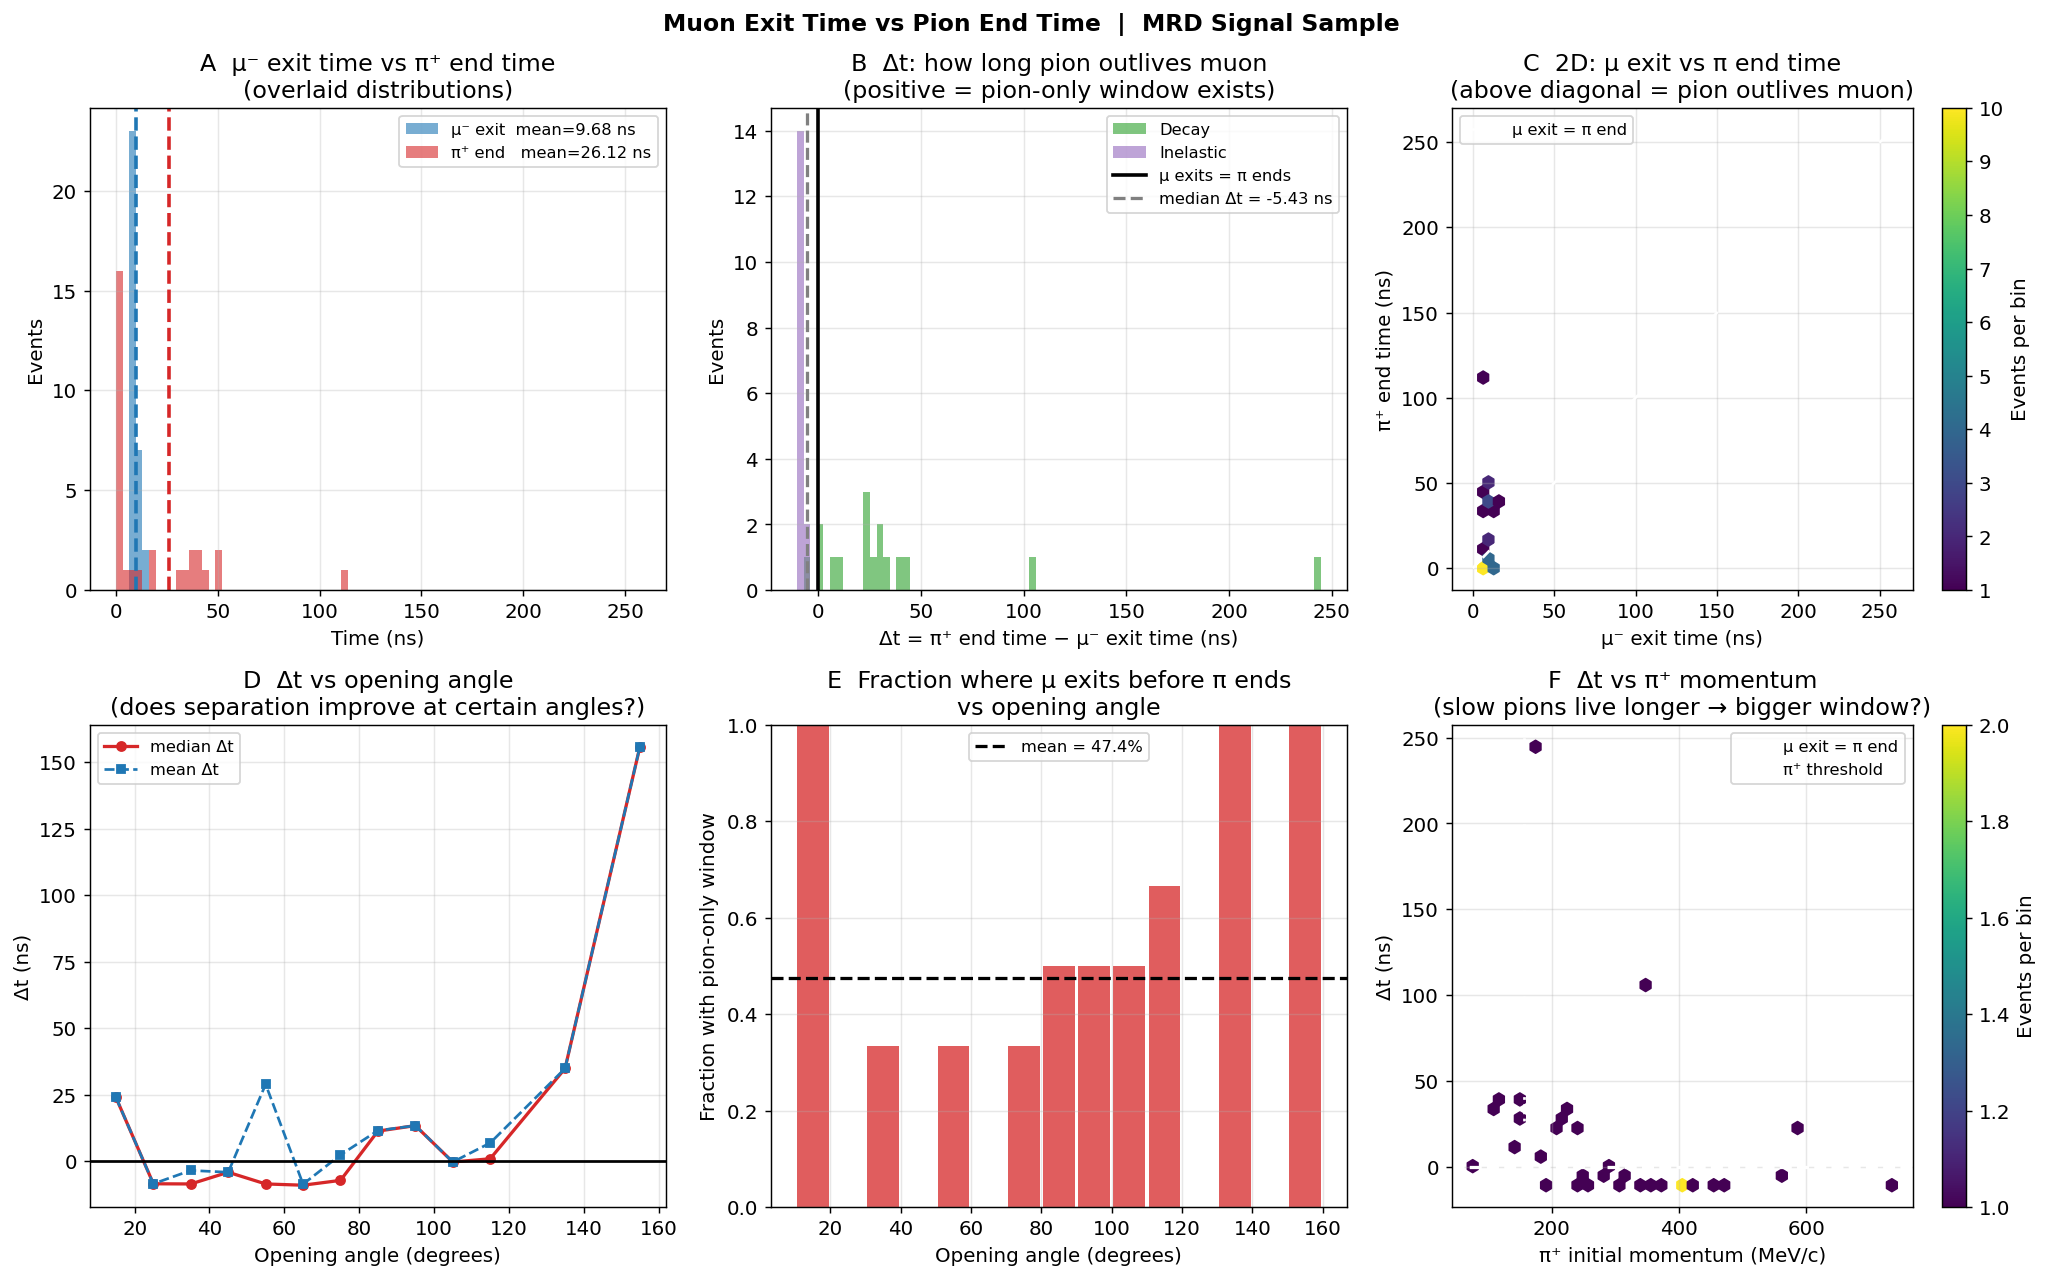

In [43]:
# ── Cell: Muon exit time vs Pion end time — temporal overlap analysis ─────────

with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    tof_cols = [
        'mu_time_stop', 'pi_time_end', 'mu_contained', 'mu_p0', 'pi_p0',
        'mu_track_len', 'pi_track_len', 'open_angle_deg',
        'mu_cher_total', 'pi_cher_total', 'pi_final_process'
    ]
    ev_tof = f[et_key].arrays(tof_cols, library='pd')

ev_tof['mu_contained'] = ev_tof['mu_contained'].astype(bool)
ev_tof['mu_track_len'] = ev_tof['mu_track_len'] / 10.0
ev_tof['pi_track_len'] = ev_tof['pi_track_len'] / 10.0

# Apply signal filter
sig_mask = (ev_tof['mu_p0'] > 0.1185) & (~ev_tof['mu_contained'])
ev_tof = ev_tof[sig_mask].copy()

ev_tof['pi_final_process'] = (ev_tof['pi_final_process']
                               .astype(str).str.strip().str.rstrip('\x00'))
ev_tof['fate'] = ev_tof['pi_final_process'].apply(
    lambda p: 'Decay' if 'Decay' in p else ('Inelastic' if 'Inelastic' in p else 'Escapes'))

# ── Key derived quantities ────────────────────────────────────────────────────
# Time the muon exits the tank
# Time the pion ends (decays or is absorbed)
# Delta: how long is the pion alive AFTER the muon has left
ev_tof['dt_pi_after_mu'] = ev_tof['pi_time_end'] - ev_tof['mu_time_stop']
# Negative = muon still in tank when pion ends (overlap)
# Positive = muon exited before pion ended (clean pion-only window)

ev_tof['overlap'] = ev_tof['dt_pi_after_mu'] < 0

print('='*60)
print('  MUON EXIT vs PION END TIME — SIGNAL SAMPLE')
print('='*60)
print(f"\n  μ⁻ mean exit time        : {ev_tof['mu_time_stop'].mean():.2f} ns")
print(f"  μ⁻ median exit time      : {ev_tof['mu_time_stop'].median():.2f} ns")
print(f"\n  π⁺ mean end time         : {ev_tof['pi_time_end'].mean():.2f} ns")
print(f"  π⁺ median end time       : {ev_tof['pi_time_end'].median():.2f} ns")
print(f"\n  Mean Δt (π ends after μ exits) : {ev_tof['dt_pi_after_mu'].mean():.2f} ns")
print(f"  Median Δt                      : {ev_tof['dt_pi_after_mu'].median():.2f} ns")
print(f"\n  Events where μ exits BEFORE π ends : "
      f"{(~ev_tof['overlap']).sum():,} "
      f"({(~ev_tof['overlap']).mean()*100:.1f}%)")
print(f"  Events where μ still in tank when π ends : "
      f"{ev_tof['overlap'].sum():,} "
      f"({ev_tof['overlap'].mean()*100:.1f}%)")
print()
for fate in ['Decay', 'Inelastic']:
    sl = ev_tof[ev_tof['fate'] == fate]
    print(f"  {fate:10s}  mean Δt={sl['dt_pi_after_mu'].mean():.2f} ns  "
          f"median Δt={sl['dt_pi_after_mu'].median():.2f} ns  "
          f"μ-exits-first={( ~sl['overlap']).mean()*100:.1f}%")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Muon Exit Time vs Pion End Time  |  MRD Signal Sample',
             fontsize=13, fontweight='bold')

# ── Panel A: μ exit time and π end time overlaid ─────────────────────────────
ax = axes[0, 0]
t_max = max(ev_tof['mu_time_stop'].quantile(0.995),
            ev_tof['pi_time_end'].quantile(0.995))
bins_t = np.linspace(0, t_max, 80)

ax.hist(ev_tof['mu_time_stop'], bins=bins_t, color=C_MU, alpha=0.6,
        label=f'μ⁻ exit  mean={ev_tof["mu_time_stop"].mean():.2f} ns')
ax.hist(ev_tof['pi_time_end'],  bins=bins_t, color=C_PI, alpha=0.6,
        label=f'π⁺ end   mean={ev_tof["pi_time_end"].mean():.2f} ns')
ax.axvline(ev_tof['mu_time_stop'].mean(), color=C_MU, lw=2, ls='--')
ax.axvline(ev_tof['pi_time_end'].mean(),  color=C_PI, lw=2, ls='--')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Events')
ax.set_title('A  μ⁻ exit time vs π⁺ end time\n(overlaid distributions)')
ax.legend(fontsize=9)

# ── Panel B: Δt distribution ──────────────────────────────────────────────────
ax = axes[0, 1]
dt_clip = ev_tof['dt_pi_after_mu'].clip(
    lower=ev_tof['dt_pi_after_mu'].quantile(0.005),
    upper=ev_tof['dt_pi_after_mu'].quantile(0.995))
bins_dt = np.linspace(dt_clip.min(), dt_clip.max(), 80)

ax.hist(ev_tof[ev_tof['fate']=='Decay']['dt_pi_after_mu'].clip(
            lower=dt_clip.min(), upper=dt_clip.max()),
        bins=bins_dt, color=C_DECAY, alpha=0.6, label='Decay')
ax.hist(ev_tof[ev_tof['fate']=='Inelastic']['dt_pi_after_mu'].clip(
            lower=dt_clip.min(), upper=dt_clip.max()),
        bins=bins_dt, color=C_INEL, alpha=0.6, label='Inelastic')
ax.axvline(0, color='black', lw=2, ls='-', label='μ exits = π ends')
ax.axvline(ev_tof['dt_pi_after_mu'].median(), color='grey', lw=1.8, ls='--',
           label=f'median Δt = {ev_tof["dt_pi_after_mu"].median():.2f} ns')
ax.set_xlabel('Δt = π⁺ end time − μ⁻ exit time (ns)')
ax.set_ylabel('Events')
ax.set_title('B  Δt: how long pion outlives muon\n(positive = pion-only window exists)')
ax.legend(fontsize=9)

# ── Panel C: 2D hexbin μ exit vs π end ───────────────────────────────────────
ax = axes[0, 2]
hb = ax.hexbin(ev_tof['mu_time_stop'], ev_tof['pi_time_end'],
               gridsize=40, cmap='viridis', mincnt=1,
               extent=[0, t_max, 0, t_max])
plt.colorbar(hb, ax=ax, label='Events per bin')
ax.plot([0, t_max], [0, t_max], 'w--', lw=1.5, label='μ exit = π end')
ax.set_xlabel('μ⁻ exit time (ns)')
ax.set_ylabel('π⁺ end time (ns)')
ax.set_title('C  2D: μ exit vs π end time\n(above diagonal = pion outlives muon)')
ax.legend(fontsize=9)

# ── Panel D: Δt vs opening angle ─────────────────────────────────────────────
ax = axes[1, 0]
angle_bins  = np.arange(0, 181, 10)
angle_cents = (angle_bins[:-1] + angle_bins[1:]) / 2
dt_vs_angle = ev_tof.groupby(
    pd.cut(ev_tof['open_angle_deg'], bins=angle_bins, labels=angle_cents),
    observed=True
)['dt_pi_after_mu'].agg(['median', 'mean']).reset_index()

ax.plot(dt_vs_angle['open_angle_deg'].astype(float),
        dt_vs_angle['median'], 'o-', color=C_PI, lw=1.8, ms=5,
        label='median Δt')
ax.plot(dt_vs_angle['open_angle_deg'].astype(float),
        dt_vs_angle['mean'], 's--', color=C_MU, lw=1.5, ms=4,
        label='mean Δt')
ax.axhline(0, color='black', lw=1.5, ls='-')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('Δt (ns)')
ax.set_title('D  Δt vs opening angle\n(does separation improve at certain angles?)')
ax.legend(fontsize=9)

# ── Panel E: fraction with pion-only window vs opening angle ──────────────────
ax = axes[1, 1]
pion_only_frac = ev_tof.groupby(
    pd.cut(ev_tof['open_angle_deg'], bins=angle_bins, labels=angle_cents),
    observed=True
).apply(lambda g: (~g['overlap']).mean()).reset_index()
pion_only_frac.columns = ['angle_bin', 'frac']

ax.bar(pion_only_frac['angle_bin'].astype(float),
       pion_only_frac['frac'], width=9,
       color=C_PI, alpha=0.75)
ax.axhline(pion_only_frac['frac'].mean(), color='black', lw=1.8, ls='--',
           label=f'mean = {pion_only_frac["frac"].mean()*100:.1f}%')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('Fraction with pion-only window')
ax.set_ylim(0, 1)
ax.set_title('E  Fraction where μ exits before π ends\nvs opening angle')
ax.legend(fontsize=9)

# ── Panel F: Δt vs π⁺ momentum ───────────────────────────────────────────────
ax = axes[1, 2]
hb = ax.hexbin(ev_tof['pi_p0'] * 1000,
               ev_tof['dt_pi_after_mu'].clip(
                   upper=ev_tof['dt_pi_after_mu'].quantile(0.995)),
               gridsize=40, cmap='viridis', mincnt=1)
plt.colorbar(hb, ax=ax, label='Events per bin')
ax.axhline(0, color='white', lw=1.8, ls='--', label='μ exit = π end')
ax.axvline(156.5, color='white', lw=1.5, ls=':', label='π⁺ threshold')
ax.set_xlabel('π⁺ initial momentum (MeV/c)')
ax.set_ylabel('Δt (ns)')
ax.set_title('F  Δt vs π⁺ momentum\n(slow pions live longer → bigger window?)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('tof_mu_vs_pi.png', dpi=150, bbox_inches='tight')
plt.show()

  PION-ONLY WINDOW — EVENTTREE LEVEL SUMMARY

  Total signal events          : 32
  Events WITH pion-only window : 14 (43.8%)
  Events WITH full overlap     : 18 (56.2%)

  ── Pion-only window events ──────────────────────────────
  Mean Δt (pion outlives muon) : 47.64 ns
  Median Δt                    : 29.22 ns

  Decay      (n=14)
    π⁺ total cher (raw)      : 8,524 photons
    π⁺ total cher (detected) : 213.1 photons
    Δt mean / median         : 47.64 / 29.22 ns



C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\682263216.py:113: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  dt_vs_a = sl.groupby(
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\682263216.py:113: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  dt_vs_a = sl.groupby(
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\682263216.py:131: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  frac_vs_a = sl.groupby(
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\682263216.py:131: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  frac_vs_a = sl.groupby(


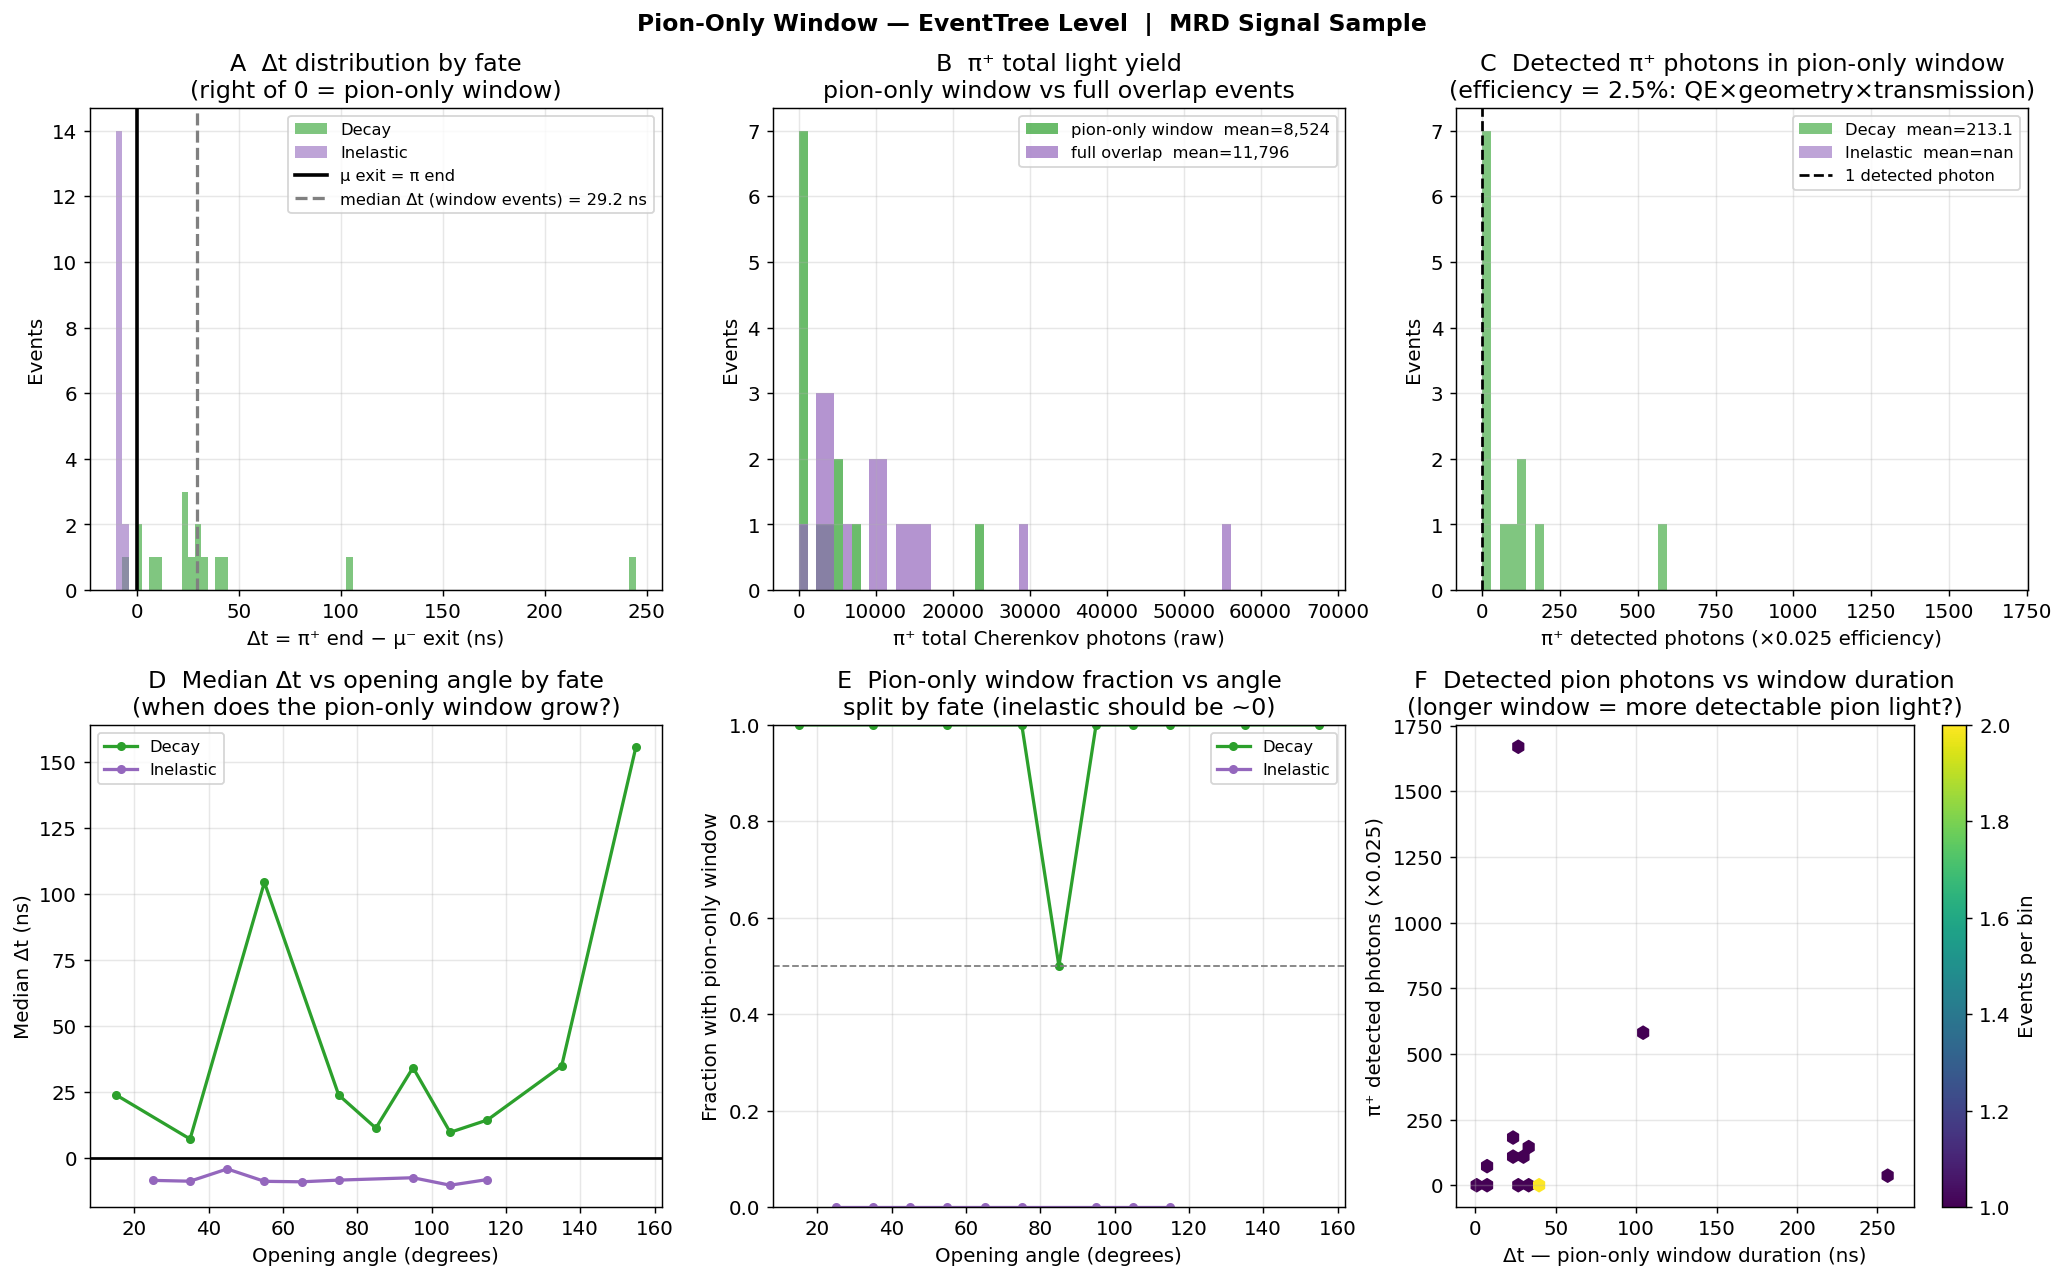

In [44]:
# ── Cell 1: Pion-only window light yield — EventTree level ───────────────────
# Uses mu_time_stop per event as the muon exit time cutoff
# Stays entirely in EventTree space — fast, no StepTree needed

# We have ev_tof and ev_sig already in memory with all needed columns
# Merge the fate column from ev_tof into ev_sig by index
ev_sig['fate']         = ev_tof['fate'].values
ev_sig['dt_pi_after_mu'] = ev_tof['dt_pi_after_mu'].values
ev_sig['mu_time_stop'] = ev_tof['mu_time_stop'].values
ev_sig['pi_time_end']  = ev_tof['pi_time_end'].values

# ── Pion-only window events ───────────────────────────────────────────────────
# These are events where the muon exits BEFORE the pion ends
ev_pion_window = ev_sig[ev_sig['dt_pi_after_mu'] > 0].copy()
ev_overlap     = ev_sig[ev_sig['dt_pi_after_mu'] <= 0].copy()

# Detection efficiency scaling
DET_EFF = 0.025  # QE ~20% × geometry ~15% × transmission ~85%

ev_sig['mu_cher_detected']  = ev_sig['mu_cher_total']  * DET_EFF
ev_sig['pi_cher_detected']  = ev_sig['pi_cher_total']  * DET_EFF
ev_pion_window['pi_cher_detected'] = ev_pion_window['pi_cher_total'] * DET_EFF

print('='*65)
print('  PION-ONLY WINDOW — EVENTTREE LEVEL SUMMARY')
print('='*65)
print(f"\n  Total signal events          : {len(ev_sig):,}")
print(f"  Events WITH pion-only window : {len(ev_pion_window):,} "
      f"({len(ev_pion_window)/len(ev_sig)*100:.1f}%)")
print(f"  Events WITH full overlap     : {len(ev_overlap):,} "
      f"({len(ev_overlap)/len(ev_sig)*100:.1f}%)")
print()
print(f"  ── Pion-only window events ──────────────────────────────")
print(f"  Mean Δt (pion outlives muon) : "
      f"{ev_pion_window['dt_pi_after_mu'].mean():.2f} ns")
print(f"  Median Δt                    : "
      f"{ev_pion_window['dt_pi_after_mu'].median():.2f} ns")
print()

# Raw and detected photon counts
for fate in ['Decay', 'Inelastic', 'Escapes']:
    sl = ev_pion_window[ev_pion_window['fate'] == fate]
    if len(sl) == 0:
        continue
    print(f"  {fate:10s} (n={len(sl):,})")
    print(f"    π⁺ total cher (raw)      : {sl['pi_cher_total'].mean():,.0f} photons")
    print(f"    π⁺ total cher (detected) : {sl['pi_cher_detected'].mean():,.1f} photons")
    print(f"    Δt mean / median         : "
          f"{sl['dt_pi_after_mu'].mean():.2f} / "
          f"{sl['dt_pi_after_mu'].median():.2f} ns")
    print()

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Pion-Only Window — EventTree Level  |  MRD Signal Sample',
             fontsize=13, fontweight='bold')

# ── Panel A: Δt distribution by fate ─────────────────────────────────────────
ax = axes[0, 0]
dt_max = ev_sig['dt_pi_after_mu'].quantile(0.995)
dt_min = ev_sig['dt_pi_after_mu'].quantile(0.005)
bins_dt = np.linspace(dt_min, dt_max, 80)

for fate, color in [('Decay', C_DECAY), ('Inelastic', C_INEL)]:
    sl = ev_sig[ev_sig['fate'] == fate]
    ax.hist(sl['dt_pi_after_mu'].clip(lower=dt_min, upper=dt_max),
            bins=bins_dt, color=color, alpha=0.6, label=fate)
ax.axvline(0, color='black', lw=2, ls='-', label='μ exit = π end')
ax.axvline(ev_pion_window['dt_pi_after_mu'].median(),
           color='grey', lw=1.8, ls='--',
           label=f'median Δt (window events) = '
                 f'{ev_pion_window["dt_pi_after_mu"].median():.1f} ns')
ax.set_xlabel('Δt = π⁺ end − μ⁻ exit (ns)')
ax.set_ylabel('Events')
ax.set_title('A  Δt distribution by fate\n(right of 0 = pion-only window)')
ax.legend(fontsize=9)

# ── Panel B: π⁺ total Cherenkov yield — window vs overlap ────────────────────
ax = axes[0, 1]
bins_cher = np.linspace(0, ev_sig['pi_cher_total'].quantile(0.995), 60)
ax.hist(ev_pion_window['pi_cher_total'], bins=bins_cher,
        color=C_DECAY, alpha=0.7,
        label=f'pion-only window  mean={ev_pion_window["pi_cher_total"].mean():,.0f}')
ax.hist(ev_overlap['pi_cher_total'], bins=bins_cher,
        color=C_INEL, alpha=0.7,
        label=f'full overlap  mean={ev_overlap["pi_cher_total"].mean():,.0f}')
ax.set_xlabel('π⁺ total Cherenkov photons (raw)')
ax.set_ylabel('Events')
ax.set_title('B  π⁺ total light yield\npion-only window vs full overlap events')
ax.legend(fontsize=9)

# ── Panel C: Detected photons in pion-only window ────────────────────────────
ax = axes[0, 2]
bins_det = np.linspace(0, ev_pion_window['pi_cher_detected'].quantile(0.995), 60)
for fate, color in [('Decay', C_DECAY), ('Inelastic', C_INEL)]:
    sl = ev_pion_window[ev_pion_window['fate'] == fate]
    ax.hist(sl['pi_cher_detected'], bins=bins_det, color=color, alpha=0.6,
            label=f'{fate}  mean={sl["pi_cher_detected"].mean():.1f}')
ax.axvline(1, color='black', lw=1.5, ls='--', label='1 detected photon')
ax.set_xlabel(f'π⁺ detected photons (×{DET_EFF} efficiency)')
ax.set_ylabel('Events')
ax.set_title(f'C  Detected π⁺ photons in pion-only window\n'
             f'(efficiency = {DET_EFF*100:.1f}%: QE×geometry×transmission)')
ax.legend(fontsize=9)

# ── Panel D: Δt vs opening angle split by fate ───────────────────────────────
ax = axes[1, 0]
angle_bins  = np.arange(0, 181, 10)
angle_cents = (angle_bins[:-1] + angle_bins[1:]) / 2

for fate, color in [('Decay', C_DECAY), ('Inelastic', C_INEL)]:
    sl = ev_sig[ev_sig['fate'] == fate]
    dt_vs_a = sl.groupby(
        pd.cut(sl['open_angle_deg'], bins=angle_bins, labels=angle_cents),
        observed=True
    )['dt_pi_after_mu'].median().reset_index()
    ax.plot(dt_vs_a['open_angle_deg'].astype(float),
            dt_vs_a['dt_pi_after_mu'],
            'o-', color=color, lw=1.8, ms=4, label=fate)
ax.axhline(0, color='black', lw=1.5, ls='-')
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('Median Δt (ns)')
ax.set_title('D  Median Δt vs opening angle by fate\n'
             '(when does the pion-only window grow?)')
ax.legend(fontsize=9)

# ── Panel E: pion-only window fraction vs opening angle by fate ──────────────
ax = axes[1, 1]
for fate, color in [('Decay', C_DECAY), ('Inelastic', C_INEL)]:
    sl = ev_sig[ev_sig['fate'] == fate]
    frac_vs_a = sl.groupby(
        pd.cut(sl['open_angle_deg'], bins=angle_bins, labels=angle_cents),
        observed=True
    ).apply(lambda g: (g['dt_pi_after_mu'] > 0).mean()).reset_index()
    frac_vs_a.columns = ['angle_bin', 'frac']
    ax.plot(frac_vs_a['angle_bin'].astype(float),
            frac_vs_a['frac'],
            'o-', color=color, lw=1.8, ms=4, label=fate)
ax.set_xlabel('Opening angle (degrees)')
ax.set_ylabel('Fraction with pion-only window')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='grey', lw=1, ls='--')
ax.set_title('E  Pion-only window fraction vs angle\n'
             'split by fate (inelastic should be ~0)')
ax.legend(fontsize=9)

# ── Panel F: π⁺ detected photons vs Δt ──────────────────────────────────────
ax = axes[1, 2]
window_only = ev_pion_window.copy()
hb = ax.hexbin(window_only['dt_pi_after_mu'].clip(
                   upper=window_only['dt_pi_after_mu'].quantile(0.995)),
               window_only['pi_cher_detected'].clip(
                   upper=window_only['pi_cher_detected'].quantile(0.995)),
               gridsize=40, cmap='viridis', mincnt=1)
plt.colorbar(hb, ax=ax, label='Events per bin')
ax.set_xlabel('Δt — pion-only window duration (ns)')
ax.set_ylabel(f'π⁺ detected photons (×{DET_EFF})')
ax.set_title('F  Detected pion photons vs window duration\n'
             '(longer window = more detectable pion light?)')

plt.tight_layout()
plt.savefig('pion_only_window_eventtree.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# ── Cell 2: Full TOF reconstruction — StepTree chunked ───────────────────────

import uproot, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

R_CYL   = 1600.0
Z_MAX   = 2000.0
C_WATER = 299.792 / 1.34
DET_EFF = 0.025

def tof_to_cylinder(x, y, z):
    r        = np.sqrt(x**2 + y**2)
    d_barrel = (R_CYL - r).clip(0)
    d_endcap = np.where(z >= 0, Z_MAX - z, Z_MAX + z).clip(0)
    return np.minimum(d_barrel, d_endcap)

# ── Lookup tables ─────────────────────────────────────────────────────────────
mu_exit_lookup = ev_sig[['mu_time_stop', 'fate']].copy()

# Force int32 to match StepTree event_id dtype
sig_ids = set(np.int32(list(ev_sig.index)))

# ── Histogram bins ────────────────────────────────────────────────────────────
T_BINS_LOG = np.logspace(np.log10(5), np.log10(500), 120)
T_BINS_LIN = np.linspace(0, 50, 100)

accum = {
    'mu'          : [np.zeros(len(T_BINS_LOG)-1), np.zeros(len(T_BINS_LIN)-1)],
    'pi_window'   : [np.zeros(len(T_BINS_LOG)-1), np.zeros(len(T_BINS_LIN)-1)],
    'pi_overlap'  : [np.zeros(len(T_BINS_LOG)-1), np.zeros(len(T_BINS_LIN)-1)],
    'pi_decay'    : [np.zeros(len(T_BINS_LOG)-1), np.zeros(len(T_BINS_LIN)-1)],
    'pi_inelastic': [np.zeros(len(T_BINS_LOG)-1), np.zeros(len(T_BINS_LIN)-1)],
}

totals = {k: {'raw': 0.0, 'detected': 0.0, 't_sum': 0.0}
          for k in accum}

# fate stored directly during loop: eid → [sum_wt, sum_w, fate_str]
pi_window_per_event = {}

st_cols = ['event_id', 'particle', 'parent_id',
           'x', 'y', 'z', 'time', 'cher_step']

CHUNK_SIZE = 500_000
print("Processing StepTree in chunks...")

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    total_entries = f[st_key].num_entries
    print(f"  Total StepTree entries : {total_entries:,}")

    for i, chunk in enumerate(f[st_key].iterate(
            st_cols, step_size=CHUNK_SIZE, library='pd')):

        chunk['particle'] = (chunk['particle'].astype(str)
                              .str.strip().str.rstrip('\x00'))

        # Signal filter — dtype-safe isin
        mask = (
            chunk['event_id'].isin(sig_ids) &
            (
                ((chunk['particle'] == 'mu-') & (chunk['parent_id'] == 0)) |
                (chunk['particle'] == 'pi+')
            ) &
            (chunk['cher_step'] > 0)
        )
        chunk = chunk[mask].copy()
        if len(chunk) == 0:
            continue

        # Merge mu_time_stop and fate — index is int64, left key is int32,
        # pandas handles this fine
        chunk = chunk.merge(mu_exit_lookup,
                            left_on='event_id', right_index=True, how='left')

        # TOF to cylinder wall
        d_wall           = tof_to_cylinder(chunk['x'].values,
                                            chunk['y'].values,
                                            chunk['z'].values)
        chunk['t_arrive']     = chunk['time'] + d_wall / C_WATER
        chunk['is_pion_only'] = chunk['time'] > chunk['mu_time_stop']
        chunk['cher_det']     = chunk['cher_step'] * DET_EFF

        mu   = chunk[chunk['particle'] == 'mu-']
        pi   = chunk[chunk['particle'] == 'pi+']
        pi_w = pi[pi['is_pion_only']]
        pi_o = pi[~pi['is_pion_only']]
        pi_d = pi[pi['fate'] == 'Decay']
        pi_i = pi[pi['fate'] == 'Inelastic']

        # Accumulate histograms
        for key, df in [('mu', mu), ('pi_window', pi_w),
                        ('pi_overlap', pi_o), ('pi_decay', pi_d),
                        ('pi_inelastic', pi_i)]:
            if len(df) == 0:
                continue
            t   = df['t_arrive'].values
            w   = df['cher_step'].values
            w_d = df['cher_det'].values
            accum[key][0] += np.histogram(t, bins=T_BINS_LOG, weights=w)[0]
            accum[key][1] += np.histogram(t, bins=T_BINS_LIN, weights=w_d)[0]
            totals[key]['raw']      += w.sum()
            totals[key]['detected'] += w_d.sum()
            totals[key]['t_sum']    += (t * w).sum()

        # Per-event pion-only mean arrival time — store fate directly
        for eid, grp in pi_w.groupby('event_id'):
            w        = grp['cher_step'].values
            t        = grp['t_arrive'].values
            fate_val = grp['fate'].iloc[0]
            if eid not in pi_window_per_event:
                pi_window_per_event[eid] = [0.0, 0.0, fate_val]
            pi_window_per_event[eid][0] += (t * w).sum()
            pi_window_per_event[eid][1] += w.sum()

        if (i + 1) % 10 == 0:
            print(f"  chunk {i+1:3d}  "
                  f"({min((i+1)*CHUNK_SIZE, total_entries):,} / {total_entries:,})")

print("Done.\n")

# ── Summary printout ──────────────────────────────────────────────────────────
print('='*65)
print('  FULL TOF SUMMARY — CYLINDER WALL ARRIVAL')
print('='*65)
print(f"  Detection efficiency : {DET_EFF*100:.1f}%\n")
for key, label in [('mu',           'μ⁻ primary         '),
                   ('pi_window',    'π⁺ pion-only window'),
                   ('pi_overlap',   'π⁺ overlap with μ  '),
                   ('pi_decay',     'π⁺ decay events    '),
                   ('pi_inelastic', 'π⁺ inelastic events')]:
    t  = totals[key]
    mt = t['t_sum'] / t['raw'] if t['raw'] > 0 else 0
    print(f"  {label}  raw={t['raw']:>14,.0f}  "
          f"detected={t['detected']:>10,.1f}  "
          f"mean_t={mt:.2f} ns")

pi_tot = totals['pi_window']['raw'] + totals['pi_overlap']['raw']
if pi_tot > 0:
    print(f"\n  π⁺ in pion-only window : "
          f"{totals['pi_window']['raw']/pi_tot*100:.1f}% of all π⁺ photons")

# ── Build per-event panel F dataframe ────────────────────────────────────────
pf_events = []
for eid, (sw, w, fate) in pi_window_per_event.items():
    if w > 0:
        pf_events.append({'event_id': eid, 'mean_t': sw / w, 'fate': fate})
pf_df = pd.DataFrame(pf_events)
print(f"\n  Per-event pion-only window entries : {len(pf_df):,}")
print(f"  Fate breakdown:\n{pf_df['fate'].value_counts().to_string()}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle(
    f'Full TOF — Cylinder Wall Arrival  |  MRD Signal Sample  '
    f'(efficiency {DET_EFF*100:.1f}%)',
    fontsize=13, fontweight='bold')

# ── Panel A: Full log range — raw photons ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.stairs(accum['mu'][0],         T_BINS_LOG, color=C_MU,    alpha=0.6,
          fill=True, label='μ⁻')
ax.stairs(accum['pi_window'][0],  T_BINS_LOG, color=C_DECAY, alpha=0.7,
          fill=True, label='π⁺ pion-only')
ax.stairs(accum['pi_overlap'][0], T_BINS_LOG, color=C_INEL,  alpha=0.5,
          fill=True, label='π⁺ overlap')
ax.set_xscale('log')
ax.set_xlabel('Photon arrival time at wall (ns)')
ax.set_ylabel('Cherenkov photons (raw)')
ax.set_title('A  Full prompt window — log scale\nraw photon counts')
ax.legend(fontsize=9)

# ── Panel B: Decay vs Inelastic — log scale ───────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.stairs(accum['pi_decay'][0],     T_BINS_LOG, color=C_DECAY, alpha=0.7,
          fill=True, label='π⁺ Decay')
ax.stairs(accum['pi_inelastic'][0], T_BINS_LOG, color=C_INEL,  alpha=0.6,
          fill=True, label='π⁺ Inelastic')
ax.set_xscale('log')
ax.set_xlabel('Photon arrival time at wall (ns)')
ax.set_ylabel('Cherenkov photons (raw)')
ax.set_title('B  π⁺ by fate — log scale\ndecay vs inelastic arrival time')
ax.legend(fontsize=9)

# ── Panel C: Detected photons 0–50 ns ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.stairs(accum['mu'][1],         T_BINS_LIN, color=C_MU,    alpha=0.6,
          fill=True, label='μ⁻')
ax.stairs(accum['pi_window'][1],  T_BINS_LIN, color=C_DECAY, alpha=0.7,
          fill=True, label='π⁺ pion-only')
ax.stairs(accum['pi_overlap'][1], T_BINS_LIN, color=C_INEL,  alpha=0.5,
          fill=True, label='π⁺ overlap')
ax.axvline(ev_sig['mu_time_stop'].mean(), color=C_MU, lw=1.8, ls='--',
           label=f'mean μ exit = {ev_sig["mu_time_stop"].mean():.1f} ns')
ax.axvline(ev_sig['pi_time_end'].mean(),  color=C_PI, lw=1.8, ls=':',
           label=f'mean π end  = {ev_sig["pi_time_end"].mean():.1f} ns')
ax.set_xlabel('Photon arrival time at wall (ns)')
ax.set_ylabel(f'Detected photons (×{DET_EFF})')
ax.set_title('C  Detected photons 0–50 ns\nclosest to ANNIE view')
ax.legend(fontsize=9)

# ── Panel D: Stacked mu + pi detected ────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.stairs(accum['mu'][1],
          T_BINS_LIN, color=C_MU, alpha=0.7, fill=True, label='μ⁻')
ax.stairs(accum['mu'][1] + accum['pi_window'][1] + accum['pi_overlap'][1],
          T_BINS_LIN, color=C_PI, alpha=0.35, fill=True,
          label='+ π⁺ (all)')
ax.axvline(ev_sig['mu_time_stop'].mean(), color='black', lw=1.8, ls='--',
           label=f'mean μ exit {ev_sig["mu_time_stop"].mean():.1f} ns')
ax.set_xlabel('Photon arrival time at wall (ns)')
ax.set_ylabel(f'Detected photons (×{DET_EFF})')
ax.set_title('D  Stacked μ⁻ + π⁺ detected\n(what ANNIE sees summed)')
ax.legend(fontsize=9)

# ── Panel E: Fraction of π⁺ light in pion-only window ────────────────────────
ax = fig.add_subplot(gs[1, 1])
pi_total_hist = accum['pi_window'][0] + accum['pi_overlap'][0]
safe          = pi_total_hist > 0
frac_window   = np.where(safe, accum['pi_window'][0] / pi_total_hist, 0)
ax.stairs(frac_window, T_BINS_LOG, color=C_DECAY, alpha=0.8, fill=True)
ax.set_xscale('log')
ax.axhline(0.5, color='black', lw=1.5, ls='--', label='50%')
ax.set_ylim(0, 1)
ax.set_xlabel('Photon arrival time at wall (ns)')
ax.set_ylabel('Fraction of π⁺ photons in pion-only window')
ax.set_title('E  Fraction of π⁺ light in pion-only window\nvs arrival time')
ax.legend(fontsize=9)

# ── Panel F: Per-event mean π⁺ arrival time by fate ──────────────────────────
ax = fig.add_subplot(gs[1, 2])
for fate, color in [('Decay', C_DECAY), ('Inelastic', C_INEL)]:
    sl = pf_df[pf_df['fate'] == fate]
    if len(sl) == 0:
        continue
    clip_val = sl['mean_t'].quantile(0.995)
    ax.hist(sl['mean_t'].clip(upper=clip_val), bins=50,
            color=color, alpha=0.6,
            label=f'{fate}  mean={sl["mean_t"].mean():.1f} ns  n={len(sl):,}')
ax.set_xlabel('Per-event mean π⁺ photon arrival time (ns)')
ax.set_ylabel('Events')
ax.set_title('F  Mean π⁺ arrival time per event\n(pion-only window events, by fate)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('tof_cylinder_chunked.png', dpi=150, bbox_inches='tight')
plt.show()

Processing StepTree in chunks...
  Total StepTree entries : 107,196
Done.

  FULL TOF SUMMARY — CYLINDER WALL ARRIVAL
  Detection efficiency : 2.5%

  μ⁻ primary           raw=     2,958,123  detected=  73,953.1  mean_t=7.52 ns
  π⁺ pion-only window  raw=             0  detected=       0.0  mean_t=0.00 ns
  π⁺ overlap with μ    raw=       450,348  detected=  11,258.7  mean_t=7.50 ns
  π⁺ decay events      raw=       149,128  detected=   3,728.2  mean_t=7.44 ns
  π⁺ inelastic events  raw=       301,220  detected=   7,530.5  mean_t=7.53 ns

  π⁺ in pion-only window : 0.0% of all π⁺ photons

  Per-event pion-only window entries : 0


KeyError: 'fate'

In [10]:
# Quick check — does the merge work correctly on a small sample?
with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    test = f[st_key].iterate(st_cols, step_size=10000, library='pd')
    test = next(test)   # just grab the first chunk

test['particle'] = test['particle'].astype(str).str.strip().str.rstrip('\x00')
test_pi = test[test['particle'] == 'pi+'].head(5)
test_merged = test_pi.merge(mu_exit_lookup,
                             left_on='event_id', right_index=True, how='left')
print(test_merged[['event_id', 'time', 'mu_time_stop', 'fate']].head(10))
print(f"\nmu_time_stop nulls: {test_merged['mu_time_stop'].isna().sum()}")
print(f"fate nulls: {test_merged['fate'].isna().sum()}")

# Also check index alignment
print(f"\nev_sig index sample : {ev_sig.index[:5].tolist()}")
print(f"StepTree event_id sample : {test['event_id'].head(5).tolist()}")
print(f"ev_sig index dtype  : {ev_sig.index.dtype}")
print(f"StepTree event_id dtype  : {test['event_id'].dtype}")

   event_id      time  mu_time_stop       fate
0         0  0.000000      8.858287  Inelastic
1         0  0.097337      8.858287  Inelastic
2         0  0.099666      8.858287  Inelastic
3         0  0.141630      8.858287  Inelastic
4         0  0.142637      8.858287  Inelastic

mu_time_stop nulls: 0
fate nulls: 0

ev_sig index sample : [0, 1, 6, 9, 12]
StepTree event_id sample : [0, 0, 0, 0, 0]
ev_sig index dtype  : int64
StepTree event_id dtype  : int32


In [46]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1: Setup + Signal Filter
# ════════════════════════════════════════════════════════════════════════════
import uproot, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

SHUF_PATH = Path(r"D:\research\ANNIE\simualtion\my_geant4\annie_coprimary_30k_shuffled_with_extra_e_tracking.root")
DET_EFF   = 0.025
R_CYL     = 1600.0
Z_MAX     = 2000.0
C_WATER   = 299.792 / 1.34
MU_P_THRESHOLD = 0.1185

C_MU   = '#1f77b4'
C_PI   = '#d62728'
C_MC   = '#aec7e8'
C_MU2  = '#ff7f0e'
C_DECAY= '#2ca02c'
C_INEL = '#9467bd'

def simplify_fate(p):
    if 'Decay'     in p: return 'Decay'
    if 'Inelastic' in p: return 'Inelastic'
    return 'Escapes'

def tof_to_cylinder(x, y, z):
    r        = np.sqrt(x**2 + y**2)
    d_barrel = (R_CYL - r).clip(0)
    d_endcap = np.where(z >= 0, Z_MAX - z, Z_MAX + z).clip(0)
    return np.minimum(d_barrel, d_endcap)

sig_cols = [
    'event_id',
    'mu_cher_total', 'mu_track_len', 'mu_time_stop', 'mu_contained',
    'pi_cher_total', 'pi_track_len', 'pi_time_end',  'pi_contained',
    'mu_p0', 'pi_p0', 'open_angle_deg', 'Enu',
    'mu_final_process', 'mu_KE0',
    'pi_final_process', 'pi_track_id',
    'n_secondary_pi',
    'smu_t_start', 'smu_KE0', 'smu_time_stop', 'smu_contained',
    'smu_cher_total',
    'michel_e_present', 'michel_e_time_start', 'michel_e_KE0',
    'michel_e_cher_total',
]

with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    ev_all = f[et_key].arrays(sig_cols, library='pd')

ev_all['mu_contained']    = ev_all['mu_contained'].astype(bool)
ev_all['pi_contained']    = ev_all['pi_contained'].astype(bool)
ev_all['michel_e_present']= ev_all['michel_e_present'].astype(bool)
ev_all['smu_contained']   = ev_all['smu_contained'].astype(bool)

ev_all['mu_track_len'] = ev_all['mu_track_len'] / 10.0
ev_all['pi_track_len'] = ev_all['pi_track_len'] / 10.0

for col in ['mu_final_process', 'pi_final_process']:
    ev_all[col] = ev_all[col].astype(str).str.strip().str.rstrip('\x00')

ev_all['fate'] = ev_all['pi_final_process'].apply(simplify_fate)

# Signal filter
cut_threshold = ev_all['mu_p0'] > MU_P_THRESHOLD
cut_punchthru = ~ev_all['mu_contained']
cut_signal    = cut_threshold & cut_punchthru

ev_sig = ev_all[cut_signal].copy().set_index('event_id')

ev_sig['ratio']           = ev_sig['pi_cher_total'] / ev_sig['mu_cher_total']
ev_sig['mu_cher_per_cm']  = ev_sig['mu_cher_total'] / ev_sig['mu_track_len']
ev_sig['pi_cher_per_cm']  = ev_sig['pi_cher_total'] / ev_sig['pi_track_len']
ev_sig['dt_pi_after_mu']  = ev_sig['pi_time_end'] - ev_sig['mu_time_stop']
ev_sig['mu_plus_lifetime']= np.where(
    ev_sig['smu_t_start'] > 0,
    ev_sig['smu_time_stop'] - ev_sig['smu_t_start'],
    np.nan
)

# ── Clean Michel definition — all 4 conditions ────────────────────────────────
ev_sig['true_michel'] = (
    ev_sig['michel_e_present'] &
    (ev_sig['fate'] == 'Decay') &
    (ev_sig['smu_t_start'] > 0) &
    (ev_sig['n_secondary_pi'] == 0)
)

ev_sig['fake_michel'] = (
    ev_sig['michel_e_present'] &
    (ev_sig['n_secondary_pi'] > 0)
)

sig_ids = set(np.int32(list(ev_sig.index)))

n_total     = len(ev_all)
n_subthresh = (~cut_threshold).sum()
n_contained = cut_threshold.sum() - cut_signal.sum()
n_signal    = len(ev_sig)

print('='*60)
print('  SIGNAL FILTER + NEW FIELD SUMMARY')
print('='*60)
print(f"  Total events             : {n_total:,}")
print(f"  Sub-threshold muon       : {n_subthresh:,}  ({n_subthresh/n_total*100:.1f}%)")
print(f"  Contained (stops water)  : {n_contained:,}  ({n_contained/n_total*100:.1f}%)")
print(f"  Signal events            : {n_signal:,}  ({n_signal/n_total*100:.1f}%)")
print()
print(f"  π⁺ fate breakdown:")
print(ev_sig['fate'].value_counts().to_string())
print()
print(f"  smu_t_start zeros        : {(ev_sig['smu_t_start']==0).sum():,} "
      f"(inelastic/no mu+)")
# Lifetime only for decay events with real mu+ birth time
decay_with_mu = ev_sig[(ev_sig['fate']=='Decay') & (ev_sig['smu_t_start']>0)]
print(f"  μ⁺ lab lifetime mean     : "
      f"{decay_with_mu['mu_plus_lifetime'].mean():.1f} ns  (PDG=2197)")
print()
print(f"  michel_e_present count   : {ev_sig['michel_e_present'].sum():,}")
print(f"  true_michel count        : {ev_sig['true_michel'].sum():,}")
print(f"  fake_michel count        : {ev_sig['fake_michel'].sum():,}")
print(f"  decay events             : {(ev_sig['fate']=='Decay').sum():,}")
print(f"  true==decay match        : "
      f"{ev_sig['true_michel'].sum() == (ev_sig['fate']=='Decay').sum()}")
print()
n_with_secondary = (ev_sig['n_secondary_pi'] > 0).sum()
print(f"  events with secondary π⁺ : {n_with_secondary:,}")
if n_with_secondary > 0:
    print(f"  mean secondary π⁺        : "
          f"{ev_sig[ev_sig['n_secondary_pi']>0]['n_secondary_pi'].mean():.2f}")
else:
    print(f"  mean secondary π⁺        : n/a (none in this sample)")
print()
print(f"  ev_sig index dtype       : {ev_sig.index.dtype}  ✓")
print(f"  ev_sig is now the working signal sample for all subsequent cells")

  SIGNAL FILTER + NEW FIELD SUMMARY
  Total events             : 30,000
  Sub-threshold muon       : 853  (2.8%)
  Contained (stops water)  : 17,118  (57.1%)
  Signal events            : 12,029  (40.1%)

  π⁺ fate breakdown:
Decay        6274
Inelastic    5739
Escapes        16

  smu_t_start zeros        : 3,415 (inelastic/no mu+)
  μ⁺ lab lifetime mean     : 2183.6 ns  (PDG=2197)

  michel_e_present count   : 8,600
  true_michel count        : 6,265
  fake_michel count        : 0
  decay events             : 6,274
  true==decay match        : False

  events with secondary π⁺ : 0
  mean secondary π⁺        : n/a (none in this sample)

  ev_sig index dtype       : int64  ✓
  ev_sig is now the working signal sample for all subsequent cells


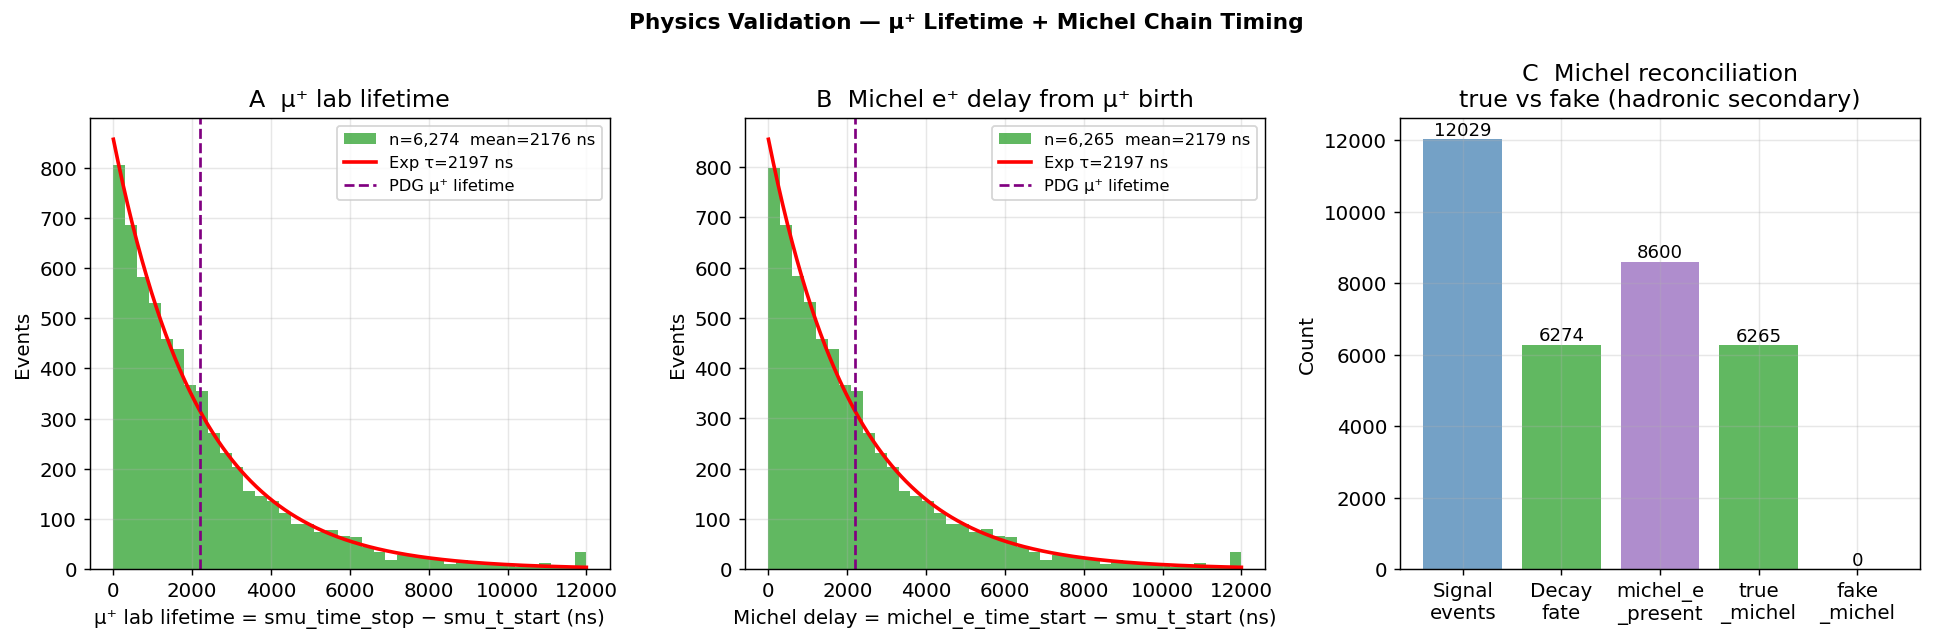

  PHYSICS VALIDATION SUMMARY
  Decay events             : 6,274
  michel_e_present         : 8,600
  true_michel              : 6,265
  fake_michel              : 0
  μ⁺ lifetime mean         : 2176.3 ns  (PDG=2197)
  Michel delay mean        : 2179.4 ns  (PDG=2197)


In [47]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2: Physics Validation — μ⁺ lifetime + Michel chain timing
# ════════════════════════════════════════════════════════════════════════════

decay_ev    = ev_sig[(ev_sig['fate']=='Decay') & (ev_sig['smu_t_start']>0)].copy()
michel_ev   = ev_sig[ev_sig['true_michel']].copy()

michel_ev['michel_delay'] = (michel_ev['michel_e_time_start']
                              - michel_ev['smu_t_start'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Physics Validation — μ⁺ Lifetime + Michel Chain Timing',
             fontsize=12, fontweight='bold')

# ── Panel A: μ⁺ lab lifetime ─────────────────────────────────────────────────
ax = axes[0]
lifetime = decay_ev['mu_plus_lifetime'].dropna().clip(upper=12000)
ax.hist(lifetime, bins=40, color=C_DECAY, alpha=0.75,
        label=f'n={len(lifetime):,}  mean={lifetime.mean():.0f} ns')
tau   = 2197.0
t_fit = np.linspace(0, 12000, 500)
bin_w = 12000 / 40
N0    = len(lifetime) * bin_w
ax.plot(t_fit, N0 / tau * np.exp(-t_fit / tau), 'r-', lw=2,
        label='Exp τ=2197 ns')
ax.axvline(2197, color='purple', lw=1.5, ls='--', label='PDG μ⁺ lifetime')
ax.set_xlabel('μ⁺ lab lifetime = smu_time_stop − smu_t_start (ns)')
ax.set_ylabel('Events')
ax.set_title('A  μ⁺ lab lifetime')
ax.legend(fontsize=9)

# ── Panel B: Michel delay from μ⁺ birth ──────────────────────────────────────
ax = axes[1]
delay = michel_ev['michel_delay'].dropna().clip(upper=12000)
if len(delay) > 0:
    ax.hist(delay, bins=40, color=C_DECAY, alpha=0.75,
            label=f'n={len(delay):,}  mean={delay.mean():.0f} ns')
    N0b = len(delay) * bin_w
    ax.plot(t_fit, N0b / tau * np.exp(-t_fit / tau), 'r-', lw=2,
            label='Exp τ=2197 ns')
    ax.axvline(2197, color='purple', lw=1.5, ls='--', label='PDG μ⁺ lifetime')
ax.set_xlabel('Michel delay = michel_e_time_start − smu_t_start (ns)')
ax.set_ylabel('Events')
ax.set_title('B  Michel e⁺ delay from μ⁺ birth')
ax.legend(fontsize=9)

# ── Panel C: Michel count reconciliation ─────────────────────────────────────
ax = axes[2]
categories = ['Signal\nevents', 'Decay\nfate', 'michel_e\n_present',
              'true\n_michel', 'fake\n_michel']
values = [
    n_signal,
    (ev_sig['fate']=='Decay').sum(),
    ev_sig['michel_e_present'].sum(),
    ev_sig['true_michel'].sum(),
    ev_sig['fake_michel'].sum(),
]
colors = ['steelblue', C_DECAY, C_INEL, C_DECAY, 'tomato']
bars = ax.bar(categories, values, color=colors, alpha=0.75)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Count')
ax.set_title('C  Michel reconciliation\ntrue vs fake (hadronic secondary)')

plt.tight_layout()
plt.savefig('physics_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('='*60)
print('  PHYSICS VALIDATION SUMMARY')
print('='*60)
print(f"  Decay events             : {(ev_sig['fate']=='Decay').sum():,}")
print(f"  michel_e_present         : {ev_sig['michel_e_present'].sum():,}")
print(f"  true_michel              : {ev_sig['true_michel'].sum():,}")
print(f"  fake_michel              : {ev_sig['fake_michel'].sum():,}")
print(f"  μ⁺ lifetime mean         : {lifetime.mean():.1f} ns  (PDG=2197)")
if len(delay) > 0:
    print(f"  Michel delay mean        : {delay.mean():.1f} ns  (PDG=2197)")

In [49]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3: Pass 1 — Compute mu- water exit time from StepTree
# ════════════════════════════════════════════════════════════════════════════

print("Pass 1: Computing mu- water exit time from StepTree...")
mu_water_exit = {}

with uproot.open(SHUF_PATH) as f:
    st_key        = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    total_entries = f[st_key].num_entries
    print(f"  StepTree entries: {total_entries:,}")

    for i, chunk in enumerate(f[st_key].iterate(
            ['event_id', 'particle', 'parent_id', 'time'],
            step_size=500_000, library='pd')):

        chunk['particle'] = (chunk['particle'].astype(str)
                              .str.strip().str.rstrip('\x00'))
        mu_chunk = chunk[
            (chunk['particle'] == 'mu-') &
            (chunk['parent_id'] == 0) &
            (chunk['event_id'].isin(sig_ids))
        ]
        for eid, grp in mu_chunk.groupby('event_id'):
            t_max = grp['time'].max()
            if eid not in mu_water_exit or t_max > mu_water_exit[eid]:
                mu_water_exit[eid] = t_max

        if (i + 1) % 10 == 0:
            print(f"  chunk {i+1:3d} / "
                  f"{int(np.ceil(total_entries/500_000)):3d}")

mu_exit_series = pd.Series(mu_water_exit, name='mu_water_exit_ns')
mu_exit_series.index = mu_exit_series.index.astype('int64')
ev_sig['mu_water_exit_ns'] = mu_exit_series

diff = (ev_sig['mu_time_stop'] - ev_sig['mu_water_exit_ns']).dropna()
print(f"\n  Done. Water exit time for "
      f"{ev_sig['mu_water_exit_ns'].notna().sum():,} events")
print(f"  Mean  Δt (world boundary − water exit) : {diff.mean():.2f} ns")
print(f"  Median Δt                               : {diff.median():.2f} ns")
print(f"  (expected ~1.7-2.3 ns: steel + air at ~c)")
print(f"  Nulls : {ev_sig['mu_water_exit_ns'].isna().sum()}")
print(f"\n  mu_water_exit_ns mean : {ev_sig['mu_water_exit_ns'].mean():.2f} ns")
print(f"  pi_time_end mean      : {ev_sig['pi_time_end'].mean():.2f} ns")
print(f"  Expected pion window  : "
      f"{(ev_sig['pi_time_end'] - ev_sig['mu_water_exit_ns']).mean():.2f} ns mean")

mu_exit_lookup = ev_sig[['mu_water_exit_ns', 'fate']].copy()

Pass 1: Computing mu- water exit time from StepTree...
  StepTree entries: 32,267,516
  chunk  10 /  65
  chunk  20 /  65
  chunk  30 /  65
  chunk  40 /  65
  chunk  50 /  65
  chunk  60 /  65

  Done. Water exit time for 12,029 events
  Mean  Δt (world boundary − water exit) : 2.30 ns
  Median Δt                               : 2.01 ns
  (expected ~1.7-2.3 ns: steel + air at ~c)
  Nulls : 0

  mu_water_exit_ns mean : 7.31 ns
  pi_time_end mean      : 14.38 ns
  Expected pion window  : 7.06 ns mean


Pion-outlives-muon events : 4,819 (40.1%)
Processing StepTree for shoulder plot...
  chunk 10
  chunk 20
  chunk 30
  chunk 40
  chunk 50
  chunk 60
Done.



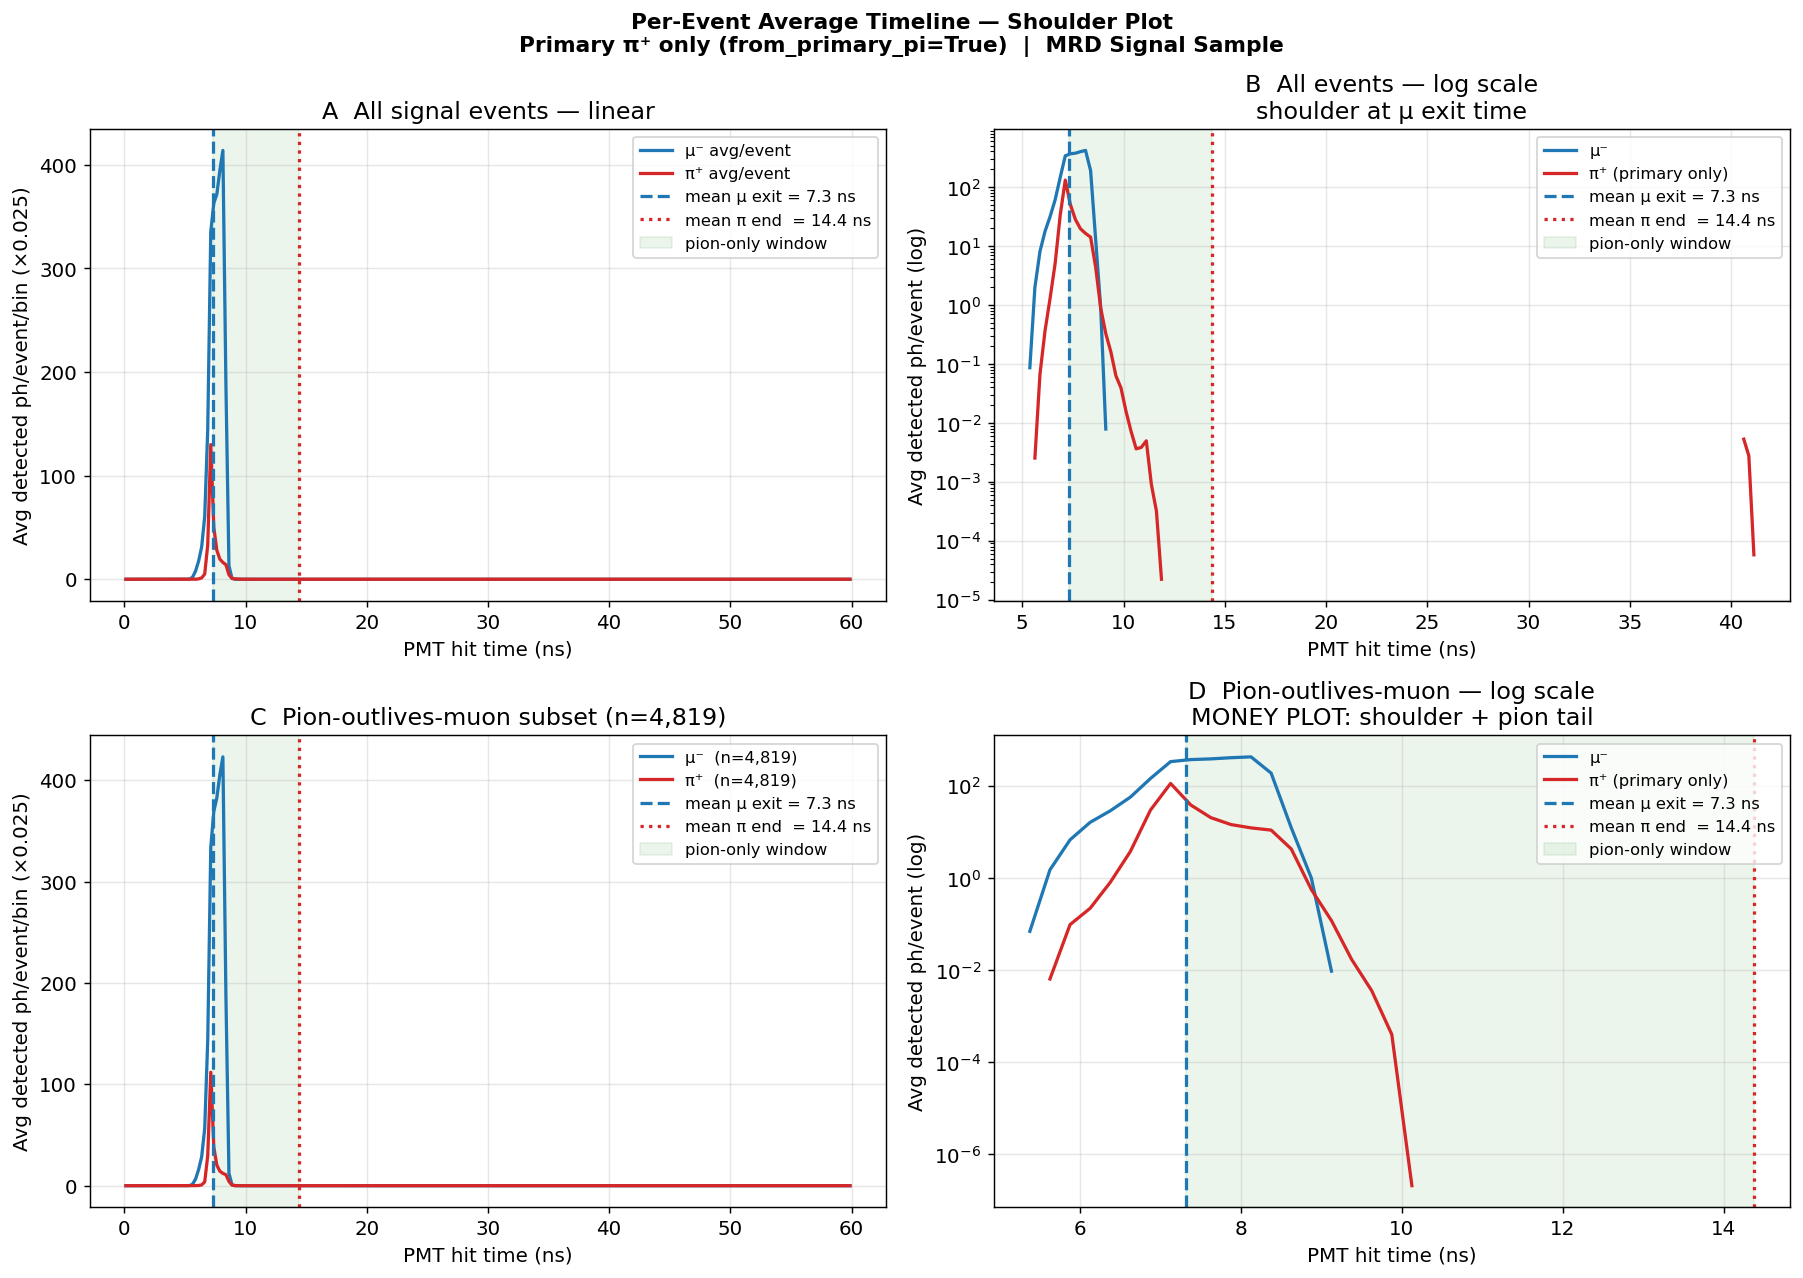

  Mean μ exit (water)  : 7.31 ns
  Mean π end time      : 14.38 ns
  Mean pion-only window: 7.06 ns


In [50]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4: Per-event average timeline — shoulder plot
# ════════════════════════════════════════════════════════════════════════════

T_PROMPT   = np.linspace(0, 60, 241)
T_PROMPT_C = (T_PROMPT[:-1] + T_PROMPT[1:]) / 2

sum_mu_p   = np.zeros(len(T_PROMPT_C))
sum_pi_p   = np.zeros(len(T_PROMPT_C))
n_mu_ev    = 0
n_pi_ev    = 0

pion_outlives     = ev_sig[
    ev_sig['pi_time_end'] > ev_sig['mu_water_exit_ns']
].index
pion_outlives_ids = set(np.int32(list(pion_outlives)))
sum_mu_out = np.zeros(len(T_PROMPT_C))
sum_pi_out = np.zeros(len(T_PROMPT_C))
n_outlives = 0

st_cols = ['event_id', 'particle', 'parent_id',
           'x', 'y', 'z', 'time', 'cher_step', 'from_primary_pi']

print(f"Pion-outlives-muon events : {len(pion_outlives_ids):,} "
      f"({len(pion_outlives_ids)/len(ev_sig)*100:.1f}%)")
print("Processing StepTree for shoulder plot...")

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]

    for i, chunk in enumerate(f[st_key].iterate(
            st_cols, step_size=500_000, library='pd')):

        chunk['particle'] = (chunk['particle'].astype(str)
                              .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi'] = chunk['from_primary_pi'].astype(bool)

        mask = (
            chunk['event_id'].isin(sig_ids) &
            (((chunk['particle'] == 'mu-') & (chunk['parent_id'] == 0)) |
             (chunk['particle'] == 'pi+')) &
            (chunk['cher_step'] > 0)
        )
        chunk = chunk[mask].copy()
        if len(chunk) == 0:
            continue

        chunk = chunk.merge(mu_exit_lookup,
                            left_on='event_id', right_index=True, how='left')

        d_wall        = tof_to_cylinder(chunk['x'].values,
                                         chunk['y'].values,
                                         chunk['z'].values)
        chunk['t_hit']    = chunk['time'] + d_wall / C_WATER
        chunk['cher_det'] = chunk['cher_step'] * DET_EFF

        mu = chunk[chunk['particle'] == 'mu-'].copy()
        # Primary pi+ only — use from_primary_pi flag
        pi = chunk[
            (chunk['particle'] == 'pi+') &
            chunk['from_primary_pi']
        ].copy()

        for eid, grp in mu.groupby('event_id'):
            w = grp['cher_det'].values
            t = grp['t_hit'].values
            sum_mu_p += np.histogram(t, bins=T_PROMPT, weights=w)[0]
            n_mu_ev  += 1
            if eid in pion_outlives_ids:
                sum_mu_out += np.histogram(t, bins=T_PROMPT, weights=w)[0]

        for eid, grp in pi.groupby('event_id'):
            w = grp['cher_det'].values
            t = grp['t_hit'].values
            sum_pi_p += np.histogram(t, bins=T_PROMPT, weights=w)[0]
            n_pi_ev  += 1
            if eid in pion_outlives_ids:
                sum_pi_out += np.histogram(t, bins=T_PROMPT, weights=w)[0]
                n_outlives += 1

        if (i + 1) % 10 == 0:
            print(f"  chunk {i+1}")

print("Done.\n")

avg_mu_p   = sum_mu_p   / max(n_mu_ev,   1)
avg_pi_p   = sum_pi_p   / max(n_pi_ev,   1)
avg_mu_out = sum_mu_out / max(n_outlives, 1)
avg_pi_out = sum_pi_out / max(n_outlives, 1)

mu_exit_mean = ev_sig['mu_water_exit_ns'].mean()
pi_end_mean  = ev_sig['pi_time_end'].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Per-Event Average Timeline — Shoulder Plot\n'
             'Primary π⁺ only (from_primary_pi=True)  |  MRD Signal Sample',
             fontsize=12, fontweight='bold')

def add_vlines(ax):
    ax.axvline(mu_exit_mean, color=C_MU, lw=1.8, ls='--',
               label=f'mean μ exit = {mu_exit_mean:.1f} ns')
    ax.axvline(pi_end_mean,  color=C_PI, lw=1.8, ls=':',
               label=f'mean π end  = {pi_end_mean:.1f} ns')
    ax.axvspan(mu_exit_mean, pi_end_mean, alpha=0.08,
               color='green', label='pion-only window')

ax = axes[0, 0]
ax.plot(T_PROMPT_C, avg_mu_p, color=C_MU, lw=1.8, label='μ⁻ avg/event')
ax.plot(T_PROMPT_C, avg_pi_p, color=C_PI, lw=1.8, label='π⁺ avg/event')
add_vlines(ax)
ax.set_xlabel('PMT hit time (ns)')
ax.set_ylabel(f'Avg detected ph/event/bin (×{DET_EFF})')
ax.set_title('A  All signal events — linear')
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.semilogy(T_PROMPT_C, np.where(avg_mu_p > 0, avg_mu_p, np.nan),
            color=C_MU, lw=1.8, label='μ⁻')
ax.semilogy(T_PROMPT_C, np.where(avg_pi_p > 0, avg_pi_p, np.nan),
            color=C_PI, lw=1.8, label='π⁺ (primary only)')
add_vlines(ax)
ax.set_xlabel('PMT hit time (ns)')
ax.set_ylabel('Avg detected ph/event (log)')
ax.set_title('B  All events — log scale\nshoulder at μ exit time')
ax.legend(fontsize=9)

ax = axes[1, 0]
ax.plot(T_PROMPT_C, avg_mu_out, color=C_MU, lw=1.8,
        label=f'μ⁻  (n={len(pion_outlives_ids):,})')
ax.plot(T_PROMPT_C, avg_pi_out, color=C_PI, lw=1.8,
        label=f'π⁺  (n={len(pion_outlives_ids):,})')
add_vlines(ax)
ax.set_xlabel('PMT hit time (ns)')
ax.set_ylabel(f'Avg detected ph/event/bin (×{DET_EFF})')
ax.set_title(f'C  Pion-outlives-muon subset (n={len(pion_outlives_ids):,})')
ax.legend(fontsize=9)

ax = axes[1, 1]
ax.semilogy(T_PROMPT_C, np.where(avg_mu_out > 0, avg_mu_out, np.nan),
            color=C_MU, lw=1.8, label='μ⁻')
ax.semilogy(T_PROMPT_C, np.where(avg_pi_out > 0, avg_pi_out, np.nan),
            color=C_PI, lw=1.8, label='π⁺ (primary only)')
add_vlines(ax)
ax.set_xlabel('PMT hit time (ns)')
ax.set_ylabel('Avg detected ph/event (log)')
ax.set_title('D  Pion-outlives-muon — log scale\nMONEY PLOT: shoulder + pion tail')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('shoulder_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Mean μ exit (water)  : {mu_exit_mean:.2f} ns")
print(f"  Mean π end time      : {pi_end_mean:.2f} ns")
print(f"  Mean pion-only window: {pi_end_mean - mu_exit_mean:.2f} ns")

Pass 1: Building mu+ track map...
  mu+ tracks in 6,272 decay events
Pass 2: Accumulating PMT hit times...
  chunk 10  Michel events: 907
  chunk 20  Michel events: 1,833
  chunk 30  Michel events: 2,753
  chunk 40  Michel events: 3,638
  chunk 50  Michel events: 4,499
  chunk 60  Michel events: 5,389
Done.

  REALISTIC ANNIE WAVEFORM SUMMARY
  Events accumulated         : 12,045
  True Michel events found   : 5,789 (48.1%)
  True Michel expected       : 6,265 (52.1%)
  Mean Michel hit time       : 2391.4 ns  (PDG=2197)


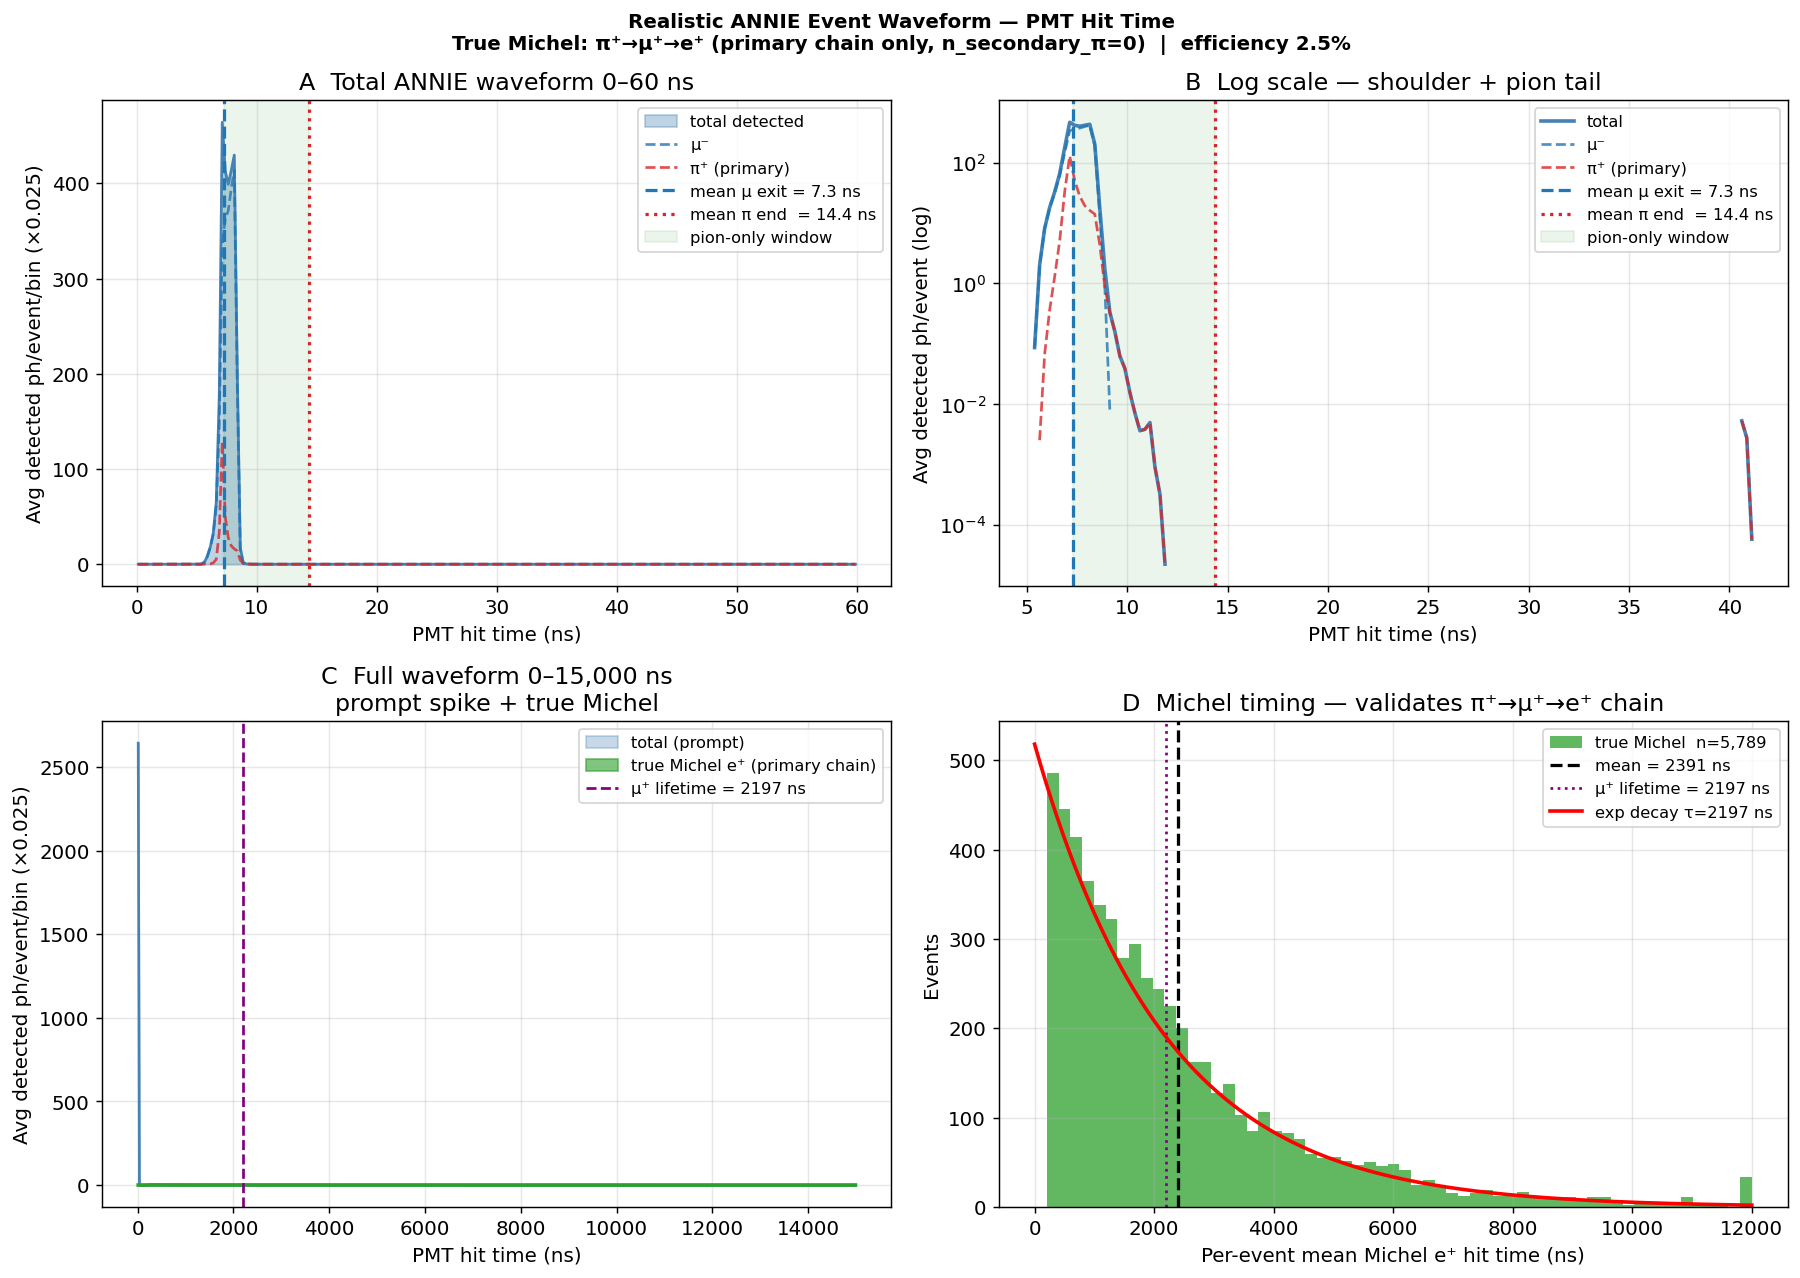

In [51]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5: Realistic ANNIE waveform — Prompt + True Michel
# ════════════════════════════════════════════════════════════════════════════

T_DELAYED   = np.linspace(0, 15000, 601)
T_DELAYED_C = (T_DELAYED[:-1] + T_DELAYED[1:]) / 2

# Only decay events can produce true Michel
decay_event_ids = set(np.int32(
    ev_sig[ev_sig['true_michel'] | (ev_sig['fate']=='Decay')].index.tolist()))

sum_total_p  = np.zeros(len(T_PROMPT_C))
sum_total_d  = np.zeros(len(T_DELAYED_C))
sum_mu_p2    = np.zeros(len(T_PROMPT_C))
sum_pi_p2    = np.zeros(len(T_PROMPT_C))
sum_michel_p = np.zeros(len(T_PROMPT_C))
sum_mu_d     = np.zeros(len(T_DELAYED_C))
sum_pi_d     = np.zeros(len(T_DELAYED_C))
sum_michel_d = np.zeros(len(T_DELAYED_C))

n_events     = 0
n_michel_ev  = 0
michel_times = []

# Pass 1 — mu+ track map from ALL steps
print("Pass 1: Building mu+ track map...")
mu_plus_map = {}

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    for chunk in f[st_key].iterate(
            ['event_id', 'particle', 'track_id', 'from_primary_pi'],
            step_size=500_000, library='pd'):
        chunk['particle']       = (chunk['particle'].astype(str)
                                    .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi']= chunk['from_primary_pi'].astype(bool)
        # Only mu+ that descend from the primary pi+ chain
        mup = chunk[
            (chunk['particle'] == 'mu+') &
            chunk['from_primary_pi'] &
            (chunk['event_id'].isin(decay_event_ids))
        ]
        for eid, grp in mup.groupby('event_id'):
            if eid not in mu_plus_map:
                mu_plus_map[eid] = set()
            mu_plus_map[eid].update(grp['track_id'].tolist())

print(f"  mu+ tracks in {len(mu_plus_map):,} decay events")

# Pass 2 — accumulate hit times
print("Pass 2: Accumulating PMT hit times...")

st_cols_w = ['event_id', 'particle', 'parent_id', 'track_id',
             'x', 'y', 'z', 'time', 'cher_step', 'from_primary_pi']

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]

    for i, chunk in enumerate(f[st_key].iterate(
            st_cols_w, step_size=500_000, library='pd')):

        chunk['particle']       = (chunk['particle'].astype(str)
                                    .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi']= chunk['from_primary_pi'].astype(bool)

        chunk = chunk[
            (chunk['event_id'].isin(sig_ids)) &
            (chunk['cher_step'] > 0)
        ].copy()
        if len(chunk) == 0:
            continue

        d_wall        = tof_to_cylinder(chunk['x'].values,
                                         chunk['y'].values,
                                         chunk['z'].values)
        chunk['t_hit']    = chunk['time'] + d_wall / C_WATER
        chunk['cher_det'] = chunk['cher_step'] * DET_EFF

        is_mu = ((chunk['particle'] == 'mu-') & (chunk['parent_id'] == 0))
        # Primary pi+ only for pi steps
        is_pi = ((chunk['particle'] == 'pi+') & chunk['from_primary_pi'])
        # True Michel: e+ from primary pi+ chain, time > 200 ns
        is_ep_candidate = (
            (chunk['particle'] == 'e+') &
            (chunk['time'] > 200.0) &
            chunk['from_primary_pi'] &
            (chunk['event_id'].isin(decay_event_ids))
        )
        ep_candidates = chunk[is_ep_candidate].copy()
        if len(ep_candidates) > 0:
            is_michel_mask = np.array([
                pid in mu_plus_map.get(eid, set())
                for pid, eid in zip(ep_candidates['parent_id'].values,
                                    ep_candidates['event_id'].values)
            ])
            michel_steps = ep_candidates[is_michel_mask].copy()
        else:
            michel_steps = pd.DataFrame()

        mu_steps = chunk[is_mu].copy()
        pi_steps = chunk[is_pi].copy()

        all_event_ids = chunk[is_mu | is_pi]['event_id'].unique()

        for eid in all_event_ids:
            ev_mu  = mu_steps[mu_steps['event_id'] == eid]
            ev_pi  = pi_steps[pi_steps['event_id'] == eid]
            ev_mch = (michel_steps[michel_steps['event_id'] == eid]
                      if len(michel_steps) > 0 else pd.DataFrame())

            all_t = np.concatenate([
                ev_mu['t_hit'].values  if len(ev_mu)  > 0 else np.array([]),
                ev_pi['t_hit'].values  if len(ev_pi)  > 0 else np.array([]),
                ev_mch['t_hit'].values if len(ev_mch) > 0 else np.array([])
            ])
            all_w = np.concatenate([
                ev_mu['cher_det'].values  if len(ev_mu)  > 0 else np.array([]),
                ev_pi['cher_det'].values  if len(ev_pi)  > 0 else np.array([]),
                ev_mch['cher_det'].values if len(ev_mch) > 0 else np.array([])
            ])
            if len(all_t) == 0:
                continue

            sum_total_p += np.histogram(all_t, bins=T_PROMPT,  weights=all_w)[0]
            sum_total_d += np.histogram(all_t, bins=T_DELAYED, weights=all_w)[0]

            if len(ev_mu) > 0:
                w, t = ev_mu['cher_det'].values, ev_mu['t_hit'].values
                sum_mu_p2 += np.histogram(t, bins=T_PROMPT,  weights=w)[0]
                sum_mu_d  += np.histogram(t, bins=T_DELAYED, weights=w)[0]
            if len(ev_pi) > 0:
                w, t = ev_pi['cher_det'].values, ev_pi['t_hit'].values
                sum_pi_p2 += np.histogram(t, bins=T_PROMPT,  weights=w)[0]
                sum_pi_d  += np.histogram(t, bins=T_DELAYED, weights=w)[0]
            if len(ev_mch) > 0:
                w, t = ev_mch['cher_det'].values, ev_mch['t_hit'].values
                sum_michel_p += np.histogram(t, bins=T_PROMPT,  weights=w)[0]
                sum_michel_d += np.histogram(t, bins=T_DELAYED, weights=w)[0]
                if w.sum() > 0:
                    michel_times.append(np.average(t, weights=w))
                    n_michel_ev += 1

            n_events += 1

        if (i + 1) % 10 == 0:
            print(f"  chunk {i+1}  Michel events: {n_michel_ev:,}")

print("Done.\n")

avg_total_p  = sum_total_p  / max(n_events, 1)
avg_total_d  = sum_total_d  / max(n_events, 1)
avg_mu_p2    = sum_mu_p2    / max(n_events, 1)
avg_pi_p2    = sum_pi_p2    / max(n_events, 1)
avg_michel_p = sum_michel_p / max(n_events, 1)
avg_mu_d     = sum_mu_d     / max(n_events, 1)
avg_pi_d     = sum_pi_d     / max(n_events, 1)
avg_michel_d = sum_michel_d / max(n_events, 1)
michel_df    = pd.DataFrame({'mean_t_hit': michel_times})

print('='*60)
print('  REALISTIC ANNIE WAVEFORM SUMMARY')
print('='*60)
print(f"  Events accumulated         : {n_events:,}")
print(f"  True Michel events found   : {n_michel_ev:,} "
      f"({n_michel_ev/max(n_events,1)*100:.1f}%)")
print(f"  True Michel expected       : {ev_sig['true_michel'].sum():,} "
      f"({ev_sig['true_michel'].sum()/len(ev_sig)*100:.1f}%)")
if len(michel_df) > 0:
    print(f"  Mean Michel hit time       : "
          f"{michel_df['mean_t_hit'].mean():.1f} ns  (PDG=2197)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Realistic ANNIE Event Waveform — PMT Hit Time\n'
    f'True Michel: π⁺→μ⁺→e⁺ (primary chain only, n_secondary_π=0)'
    f'  |  efficiency {DET_EFF*100:.1f}%',
    fontsize=11, fontweight='bold')

def add_prompt_vlines(ax):
    ax.axvline(mu_exit_mean, color=C_MU, lw=1.8, ls='--',
               label=f'mean μ exit = {mu_exit_mean:.1f} ns')
    ax.axvline(pi_end_mean,  color=C_PI, lw=1.8, ls=':',
               label=f'mean π end  = {pi_end_mean:.1f} ns')
    ax.axvspan(mu_exit_mean, pi_end_mean, alpha=0.08,
               color='green', label='pion-only window')

ax = axes[0, 0]
ax.fill_between(T_PROMPT_C, avg_total_p,
                color='steelblue', alpha=0.35, label='total detected')
ax.plot(T_PROMPT_C, avg_total_p, color='steelblue', lw=1.5)
ax.plot(T_PROMPT_C, avg_mu_p2,   color=C_MU, lw=1.5, ls='--',
        alpha=0.8, label='μ⁻')
ax.plot(T_PROMPT_C, avg_pi_p2,   color=C_PI, lw=1.5, ls='--',
        alpha=0.8, label='π⁺ (primary)')
add_prompt_vlines(ax)
ax.set_xlabel('PMT hit time (ns)')
ax.set_ylabel(f'Avg detected ph/event/bin (×{DET_EFF})')
ax.set_title('A  Total ANNIE waveform 0–60 ns')
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.semilogy(T_PROMPT_C, np.where(avg_total_p > 0, avg_total_p, np.nan),
            color='steelblue', lw=2.0, label='total')
ax.semilogy(T_PROMPT_C, np.where(avg_mu_p2 > 0, avg_mu_p2, np.nan),
            color=C_MU, lw=1.5, ls='--', alpha=0.8, label='μ⁻')
ax.semilogy(T_PROMPT_C, np.where(avg_pi_p2 > 0, avg_pi_p2, np.nan),
            color=C_PI, lw=1.5, ls='--', alpha=0.8, label='π⁺ (primary)')
add_prompt_vlines(ax)
ax.set_xlabel('PMT hit time (ns)')
ax.set_ylabel('Avg detected ph/event (log)')
ax.set_title('B  Log scale — shoulder + pion tail')
ax.legend(fontsize=9)

ax = axes[1, 0]
ax.fill_between(T_DELAYED_C, avg_total_d,
                color='steelblue', alpha=0.3, label='total (prompt)')
ax.fill_between(T_DELAYED_C, avg_michel_d,
                color=C_DECAY, alpha=0.6,
                label='true Michel e⁺ (primary chain)')
ax.plot(T_DELAYED_C, avg_total_d,  color='steelblue', lw=1.5)
ax.plot(T_DELAYED_C, avg_michel_d, color=C_DECAY,     lw=2.0)
ax.axvline(2197, color='purple', lw=1.5, ls='--',
           label='μ⁺ lifetime = 2197 ns')
ax.set_xlabel('PMT hit time (ns)')
ax.set_ylabel(f'Avg detected ph/event/bin (×{DET_EFF})')
ax.set_title('C  Full waveform 0–15,000 ns\nprompt spike + true Michel')
ax.legend(fontsize=9)

ax = axes[1, 1]
if len(michel_df) > 0:
    t_vals = michel_df['mean_t_hit'].clip(upper=12000)
    counts, edges, _ = ax.hist(t_vals, bins=60, color=C_DECAY, alpha=0.75,
                                label=f'true Michel  n={len(michel_df):,}')
    ax.axvline(michel_df['mean_t_hit'].mean(), color='black',
               lw=1.8, ls='--',
               label=f'mean = {michel_df["mean_t_hit"].mean():.0f} ns')
    ax.axvline(2197, color='purple', lw=1.5, ls=':',
               label='μ⁺ lifetime = 2197 ns')
    tau   = 2197.0
    bin_w = edges[1] - edges[0]
    t_fit = np.linspace(0, 12000, 500)
    N0    = len(michel_df) * bin_w
    ax.plot(t_fit, N0 / tau * np.exp(-t_fit / tau),
            color='red', lw=2.0, label='exp decay τ=2197 ns')
ax.set_xlabel('Per-event mean Michel e⁺ hit time (ns)')
ax.set_ylabel('Events')
ax.set_title('D  Michel timing — validates π⁺→μ⁺→e⁺ chain')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('annie_waveform_michel.png', dpi=150, bbox_inches='tight')
plt.show()

Processing StepTree — particle creation times...
  chunk 10
  chunk 20
  chunk 30
  chunk 40
  chunk 50
  chunk 60
Done.

  PARTICLE CREATION TIME SUMMARY
  Particle               Total tracks  Mean t_create  Median t_create
-----------------------------------------------------------------
  e-                        4,989,098          3.69 ns           3.50 ns
  proton                       56,788         10.54 ns           7.50 ns
  O16                          18,829          8.29 ns           6.50 ns
  pi+                          15,364          0.70 ns           0.50 ns
  mu-                          12,033          0.50 ns           0.50 ns
  neutron                      10,111          4.14 ns           2.50 ns
  mu+                           7,726         19.78 ns          16.50 ns
  alpha                         4,101          2.90 ns           1.50 ns
  e+                            3,212          5.87 ns           3.50 ns
  C12                           2,380          3.56 

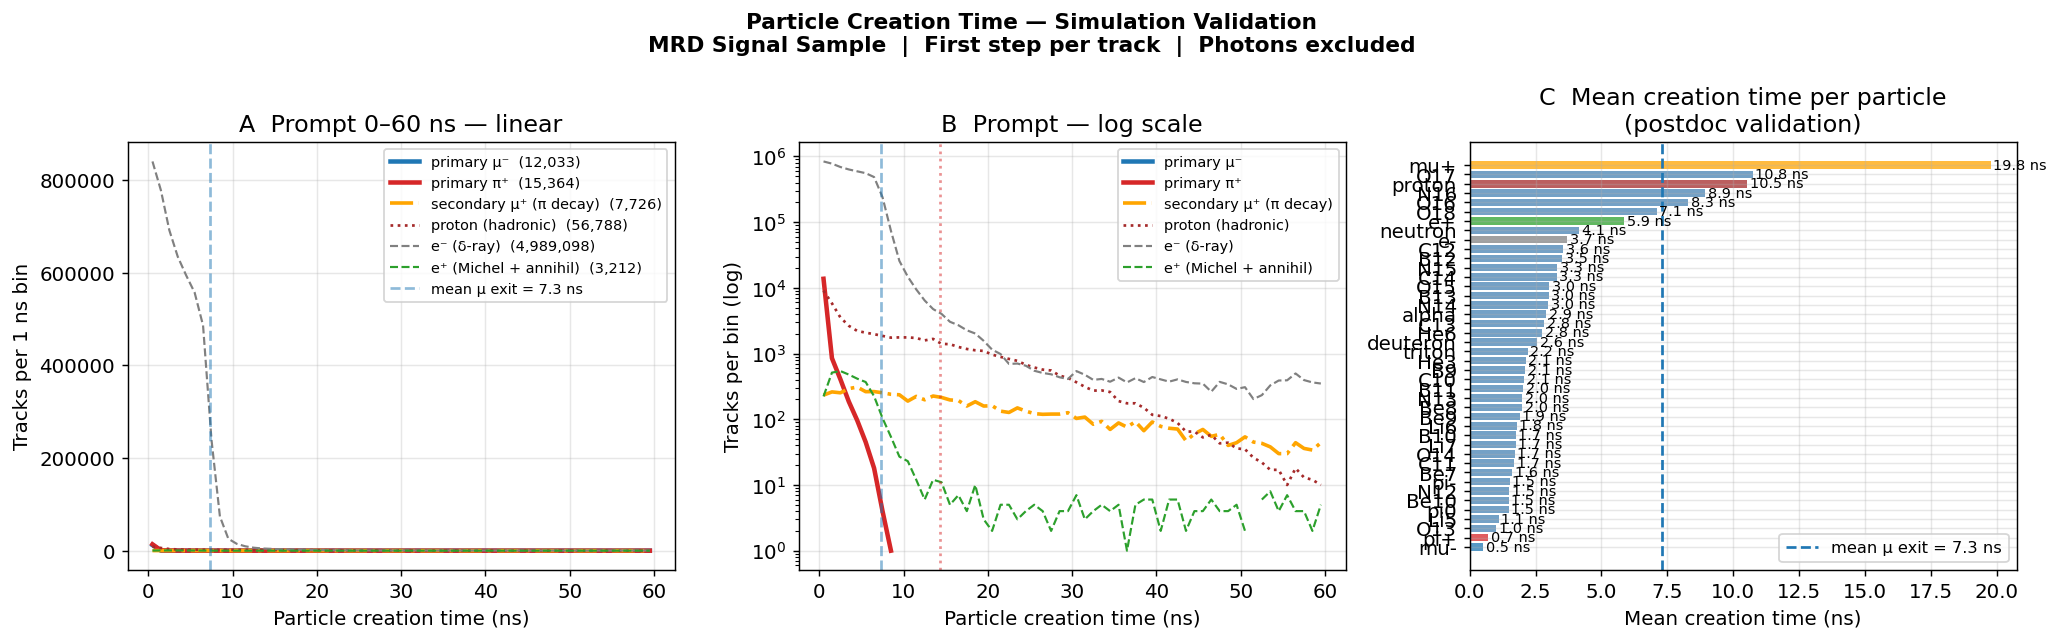

In [52]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6: Particle creation time — postdoc validation
# ════════════════════════════════════════════════════════════════════════════

EXCLUDE = {'gamma', 'nu_e', 'nu_mu', 'anti_nu_mu', 'anti_nu_e',
           'nu_tau', 'anti_nu_tau', 'opticalphoton'}

T_BINS_1NS  = np.linspace(0, 60, 61)
T_CENTS_1NS = (T_BINS_1NS[:-1]  + T_BINS_1NS[1:])  / 2
T_BINS_DEL  = np.linspace(0, 15000, 301)
T_CENTS_DEL = (T_BINS_DEL[:-1]  + T_BINS_DEL[1:])  / 2

particle_hists_p = {}
particle_hists_d = {}

print("Processing StepTree — particle creation times...")

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]

    for i, chunk in enumerate(f[st_key].iterate(
            ['event_id', 'particle', 'track_id',
             'step_num', 'time', 'from_primary_pi'],
            step_size=500_000, library='pd')):

        chunk['particle']       = (chunk['particle'].astype(str)
                                    .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi']= chunk['from_primary_pi'].astype(bool)

        chunk = chunk[
            (chunk['event_id'].isin(sig_ids)) &
            (~chunk['particle'].isin(EXCLUDE))
        ].copy()
        if len(chunk) == 0:
            continue

        first_steps = (chunk.sort_values('step_num')
                            .groupby(['event_id', 'track_id', 'particle'],
                                      sort=False)
                            .first()
                            .reset_index())

        for ptcl, grp in first_steps.groupby('particle'):
            t = grp['time'].values
            if ptcl not in particle_hists_p:
                particle_hists_p[ptcl] = np.zeros(len(T_CENTS_1NS))
                particle_hists_d[ptcl] = np.zeros(len(T_CENTS_DEL))
            particle_hists_p[ptcl] += np.histogram(t, bins=T_BINS_1NS)[0]
            particle_hists_d[ptcl] += np.histogram(t, bins=T_BINS_DEL)[0]

        if (i + 1) % 10 == 0:
            print(f"  chunk {i+1}")

print("Done.\n")

print('='*65)
print('  PARTICLE CREATION TIME SUMMARY')
print('='*65)
print(f"  {'Particle':<20} {'Total tracks':>14} "
      f"{'Mean t_create':>14} {'Median t_create':>16}")
print('-'*65)
ptcl_counts = {p: h.sum() for p, h in particle_hists_p.items()}
for ptcl, total in sorted(ptcl_counts.items(),
                            key=lambda x: x[1], reverse=True):
    h = particle_hists_p[ptcl]
    if h.sum() == 0:
        continue
    mean_t = np.average(T_CENTS_1NS, weights=h)
    cdf    = np.cumsum(h) / h.sum()
    med_t  = T_CENTS_1NS[np.searchsorted(cdf, 0.5)]
    print(f"  {ptcl:<20} {total:>14,.0f} "
          f"{mean_t:>13.2f} ns {med_t:>14.2f} ns")

PROMPT_PARTICLES = {
    'mu-'    : (C_MU,    'primary μ⁻',            '-',   2.5),
    'pi+'    : (C_PI,    'primary π⁺',             '-',   2.5),
    'mu+'    : ('orange','secondary μ⁺ (π decay)', '-.',  2.0),
    'proton' : ('brown', 'proton (hadronic)',       ':',   1.5),
    'e-'     : ('gray',  'e⁻ (δ-ray)',             '--',  1.2),
    'e+'     : (C_DECAY, 'e⁺ (Michel + annihil)',  '--',  1.2),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Particle Creation Time — Simulation Validation\n'
             'MRD Signal Sample  |  First step per track  |  Photons excluded',
             fontsize=12, fontweight='bold')

ax = axes[0]
for ptcl, (color, label, ls, lw) in PROMPT_PARTICLES.items():
    if ptcl in particle_hists_p and particle_hists_p[ptcl].sum() > 0:
        ax.plot(T_CENTS_1NS, particle_hists_p[ptcl],
                color=color, lw=lw, ls=ls,
                label=f'{label}  ({particle_hists_p[ptcl].sum():,.0f})')
ax.axvline(mu_exit_mean, color=C_MU, lw=1.5, ls='--', alpha=0.5,
           label=f'mean μ exit = {mu_exit_mean:.1f} ns')
ax.set_xlabel('Particle creation time (ns)')
ax.set_ylabel('Tracks per 1 ns bin')
ax.set_title('A  Prompt 0–60 ns — linear')
ax.legend(fontsize=8)

ax = axes[1]
for ptcl, (color, label, ls, lw) in PROMPT_PARTICLES.items():
    if ptcl in particle_hists_p and particle_hists_p[ptcl].sum() > 0:
        h = particle_hists_p[ptcl]
        ax.semilogy(T_CENTS_1NS, np.where(h > 0, h, np.nan),
                    color=color, lw=lw, ls=ls, label=label)
ax.axvline(mu_exit_mean, color=C_MU, lw=1.5, ls='--', alpha=0.5)
ax.axvline(pi_end_mean,  color=C_PI, lw=1.5, ls=':',  alpha=0.5)
ax.set_xlabel('Particle creation time (ns)')
ax.set_ylabel('Tracks per bin (log)')
ax.set_title('B  Prompt — log scale')
ax.legend(fontsize=8)

ax = axes[2]
ptcl_means = {}
for ptcl, h in particle_hists_p.items():
    if h.sum() > 2:
        ptcl_means[ptcl] = np.average(T_CENTS_1NS, weights=h)
sorted_ptcls = sorted(ptcl_means.items(), key=lambda x: x[1])
names      = [p for p, _ in sorted_ptcls]
means      = [m for _, m in sorted_ptcls]
colors_bar = [PROMPT_PARTICLES.get(n, ('steelblue',))[0] for n in names]
bars = ax.barh(names, means, color=colors_bar, alpha=0.75)
ax.axvline(mu_exit_mean, color=C_MU, lw=1.5, ls='--',
           label=f'mean μ exit = {mu_exit_mean:.1f} ns')
for bar, val in zip(bars, means):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} ns', va='center', fontsize=8)
ax.set_xlabel('Mean creation time (ns)')
ax.set_title('C  Mean creation time per particle\n(postdoc validation)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('particle_creation_times.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# ════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC: What are the early Michel-tagged e+ events?
# ════════════════════════════════════════════════════════════════════════════

early_michel_events = []

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]

    for chunk in f[st_key].iterate(
            ['event_id', 'particle', 'parent_id', 'track_id',
             'step_num', 'time', 'KE', 'x', 'y', 'z',
             'cher_step', 'from_primary_pi', 'process'],
            step_size=500_000, library='pd'):

        chunk['particle']       = (chunk['particle'].astype(str)
                                    .str.strip().str.rstrip('\x00'))
        chunk['process']        = (chunk['process'].astype(str)
                                    .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi']= chunk['from_primary_pi'].astype(bool)

        # Find e+ that would pass our Michel filter
        ep = chunk[
            (chunk['particle'] == 'e+') &
            (chunk['time'] > 200.0) &
            chunk['from_primary_pi'] &
            (chunk['event_id'].isin(decay_event_ids))
        ].copy()
        if len(ep) == 0:
            continue

        # Get first step per track to see creation time and process
        ep_first = (ep.sort_values('step_num')
                      .groupby(['event_id', 'track_id'])
                      .first()
                      .reset_index())

        # Check parent_id against mu_plus_map
        ep_first['parent_is_mu'] = [
            pid in mu_plus_map.get(eid, set())
            for pid, eid in zip(ep_first['parent_id'].values,
                                ep_first['event_id'].values)
        ]

        # Merge smu_t_start
        ep_first = ep_first.merge(
            ev_sig[['smu_t_start', 'smu_time_stop']],
            left_on='event_id', right_index=True, how='left'
        )

        ep_first['before_mu_born']  = ep_first['time'] < ep_first['smu_t_start']
        ep_first['after_mu_died']   = ep_first['time'] > ep_first['smu_time_stop']
        ep_first['during_mu_life']  = (
            ~ep_first['before_mu_born'] & ~ep_first['after_mu_died']
        )

        # Flag the suspicious ones — tagged as Michel but time < smu_t_start
        suspicious = ep_first[
            ep_first['parent_is_mu'] &
            ep_first['before_mu_born']
        ]
        if len(suspicious) > 0:
            early_michel_events.append(suspicious)

if early_michel_events:
    early_df = pd.concat(early_michel_events, ignore_index=True)
    print(f"Suspicious early Michel-tagged e+ tracks : {len(early_df):,}")
    print()
    print("Full detail:")
    print(early_df[[
        'event_id', 'track_id', 'parent_id',
        'time', 'smu_t_start', 'smu_time_stop',
        'KE', 'process', 'from_primary_pi',
        'before_mu_born', 'during_mu_life'
    ]].to_string())
    print()
    print("Process breakdown:")
    print(early_df['process'].value_counts().to_string())
    print()
    print("KE distribution (GeV):")
    print(early_df['KE'].describe())
else:
    print("No suspicious early Michel-tagged e+ found — filter is clean")

No suspicious early Michel-tagged e+ found — filter is clean


In [54]:
# ════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC: Are the early Michel hit times physically consistent?
# ════════════════════════════════════════════════════════════════════════════

# Look at the events behind the early hits in panel D (mean_t_hit < 1500 ns)
early_hit_eids = michel_df[michel_df['mean_t_hit'] < 1500].index.tolist() \
                 if 'index' in michel_df.columns \
                 else michel_df[michel_df['mean_t_hit'] < 1500].reset_index().index.tolist()

# michel_df doesn't have event_id — rebuild with it
michel_times_with_eid = []

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]

    for chunk in f[st_key].iterate(
            ['event_id', 'particle', 'parent_id', 'track_id',
             'x', 'y', 'z', 'time', 'cher_step', 'from_primary_pi'],
            step_size=500_000, library='pd'):

        chunk['particle']        = (chunk['particle'].astype(str)
                                     .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi'] = chunk['from_primary_pi'].astype(bool)

        ep = chunk[
            (chunk['particle'] == 'e+') &
            (chunk['time'] > 200.0) &
            chunk['from_primary_pi'] &
            (chunk['event_id'].isin(decay_event_ids)) &
            (chunk['cher_step'] > 0)
        ].copy()
        if len(ep) == 0:
            continue

        is_michel_mask = np.array([
            pid in mu_plus_map.get(eid, set())
            for pid, eid in zip(ep['parent_id'].values,
                                ep['event_id'].values)
        ])
        ep = ep[is_michel_mask].copy()
        if len(ep) == 0:
            continue

        d_wall     = tof_to_cylinder(ep['x'].values,
                                      ep['y'].values,
                                      ep['z'].values)
        ep['t_hit']= ep['time'] + d_wall / C_WATER

        for eid, grp in ep.groupby('event_id'):
            w = grp['cher_step'].values
            t = grp['t_hit'].values
            if w.sum() > 0:
                michel_times_with_eid.append({
                    'event_id'      : eid,
                    'mean_t_hit'    : np.average(t, weights=w),
                    'mean_step_time': np.average(grp['time'].values, weights=w),
                    'n_steps'       : len(grp),
                    'cher_total'    : w.sum()
                })

michel_eid_df = pd.DataFrame(michel_times_with_eid)
michel_eid_df = michel_eid_df.merge(
    ev_sig[['smu_t_start', 'smu_time_stop', 'mu_plus_lifetime',
            'pi_time_end', 'open_angle_deg', 'pi_p0']],
    left_on='event_id', right_index=True, how='left'
)

print(f"Michel events reconstructed: {len(michel_eid_df):,}")
print()

# Focus on the early ones
early = michel_eid_df[michel_eid_df['mean_t_hit'] < 1500].copy()
late  = michel_eid_df[michel_eid_df['mean_t_hit'] >= 1500].copy()

print(f"Early Michel hits (<1500 ns): {len(early):,}")
print(f"Late  Michel hits (≥1500 ns): {len(late):,}")
print()

print("── Early Michel event detail ──────────────────────────────")
print(early[[
    'event_id', 'mean_t_hit', 'mean_step_time',
    'smu_t_start', 'smu_time_stop', 'mu_plus_lifetime',
    'pi_time_end', 'cher_total'
]].to_string())
print()
print("── Comparison: early vs late ──────────────────────────────")
for label, df in [('Early (<1500 ns)', early), ('Late (≥1500 ns)', late)]:
    print(f"\n  {label}  n={len(df)}")
    print(f"    smu_t_start mean       : {df['smu_t_start'].mean():.1f} ns")
    print(f"    mu_plus_lifetime mean  : {df['mu_plus_lifetime'].mean():.1f} ns")
    print(f"    mean_step_time mean    : {df['mean_step_time'].mean():.1f} ns")
    print(f"    mean_t_hit mean        : {df['mean_t_hit'].mean():.1f} ns")

Michel events reconstructed: 5,789

Early Michel hits (<1500 ns): 2,528
Late  Michel hits (≥1500 ns): 3,261

── Early Michel event detail ──────────────────────────────
      event_id   mean_t_hit  mean_step_time  smu_t_start  smu_time_stop  mu_plus_lifetime  pi_time_end    cher_total
1            9  1118.824659     1112.288389    36.412039    1112.288389       1075.876351    36.412039    516.547651
3           21  1223.543172     1216.890389    18.259111    1216.605847       1198.346736    18.259111   8502.405674
4           26   789.132163      782.400790    50.899942     782.091737        731.191795    50.899942   9190.406234
6           39  1139.280053     1132.526066    40.437453    1132.336004       1091.898551    40.437453   5757.338379
8           47  1136.601902     1130.142430    49.847789    1130.059257       1080.211468    49.847789   2626.398172
10          54   412.373282      406.682458    41.101611     406.595006        365.493395    41.101611   2808.621325
15          

In [55]:
# ── What is the e+ creation time breakdown? ───────────────────────────────────
with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    
    ep_records = []
    for chunk in f[st_key].iterate(
            ['event_id', 'particle', 'parent_id', 'track_id',
             'step_num', 'time', 'KE', 'process', 'from_primary_pi'],
            step_size=500_000, library='pd'):

        chunk['particle']        = (chunk['particle'].astype(str)
                                     .str.strip().str.rstrip('\x00'))
        chunk['process']         = (chunk['process'].astype(str)
                                     .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi'] = chunk['from_primary_pi'].astype(bool)

        ep = chunk[
            (chunk['particle'] == 'e+') &
            (chunk['event_id'].isin(sig_ids))
        ].copy()
        if len(ep) == 0:
            continue

        # First step per track = creation time and creating process
        ep_first = (ep.sort_values('step_num')
                      .groupby(['event_id', 'track_id'])
                      .first()
                      .reset_index())

        ep_first['parent_is_mu'] = [
            pid in mu_plus_map.get(eid, set())
            for pid, eid in zip(ep_first['parent_id'].values,
                                ep_first['event_id'].values)
        ]
        ep_records.append(ep_first)

ep_all = pd.concat(ep_records, ignore_index=True)
ep_all = ep_all.merge(
    ev_sig[['smu_t_start', 'fate']],
    left_on='event_id', right_index=True, how='left'
)

# Classify each e+ track
def classify_ep(row):
    if row['parent_is_mu'] and row['time'] > row['smu_t_start']:
        return 'true_michel'
    if row['parent_is_mu'] and row['time'] <= row['smu_t_start']:
        return 'mu_parent_but_prompt'   # ← the suspicious ones
    if row['from_primary_pi'] and row['time'] < 10:
        return 'prompt_from_pi_chain'   # pair prod / pi0 decay
    if not row['from_primary_pi']:
        return 'not_from_primary_pi'
    return 'other'

ep_all['classification'] = ep_all.apply(classify_ep, axis=1)

print("e+ track classification:")
print(ep_all['classification'].value_counts().to_string())
print()
print("Process breakdown by classification:")
print(ep_all.groupby(['classification', 'process']).size()
      .sort_values(ascending=False).to_string())
print()
print("Creation time by classification:")
print(ep_all.groupby('classification')['time'].describe().to_string())

e+ track classification:
true_michel             6264
other                   3779
prompt_from_pi_chain    2537
not_from_primary_pi      422

Process breakdown by classification:
classification        process       
true_michel           eIoni             4501
other                 eIoni             2901
prompt_from_pi_chain  eIoni             2065
true_michel           eBrem             1733
other                 eBrem              854
prompt_from_pi_chain  eBrem              447
not_from_primary_pi   eIoni              350
                      eBrem               68
true_michel           annihil             30
other                 annihil             24
prompt_from_pi_chain  annihil             22
not_from_primary_pi   annihil              2
prompt_from_pi_chain  Transportation       2
not_from_primary_pi   Transportation       1
                      msc                  1
prompt_from_pi_chain  msc                  1

Creation time by classification:
                       count  

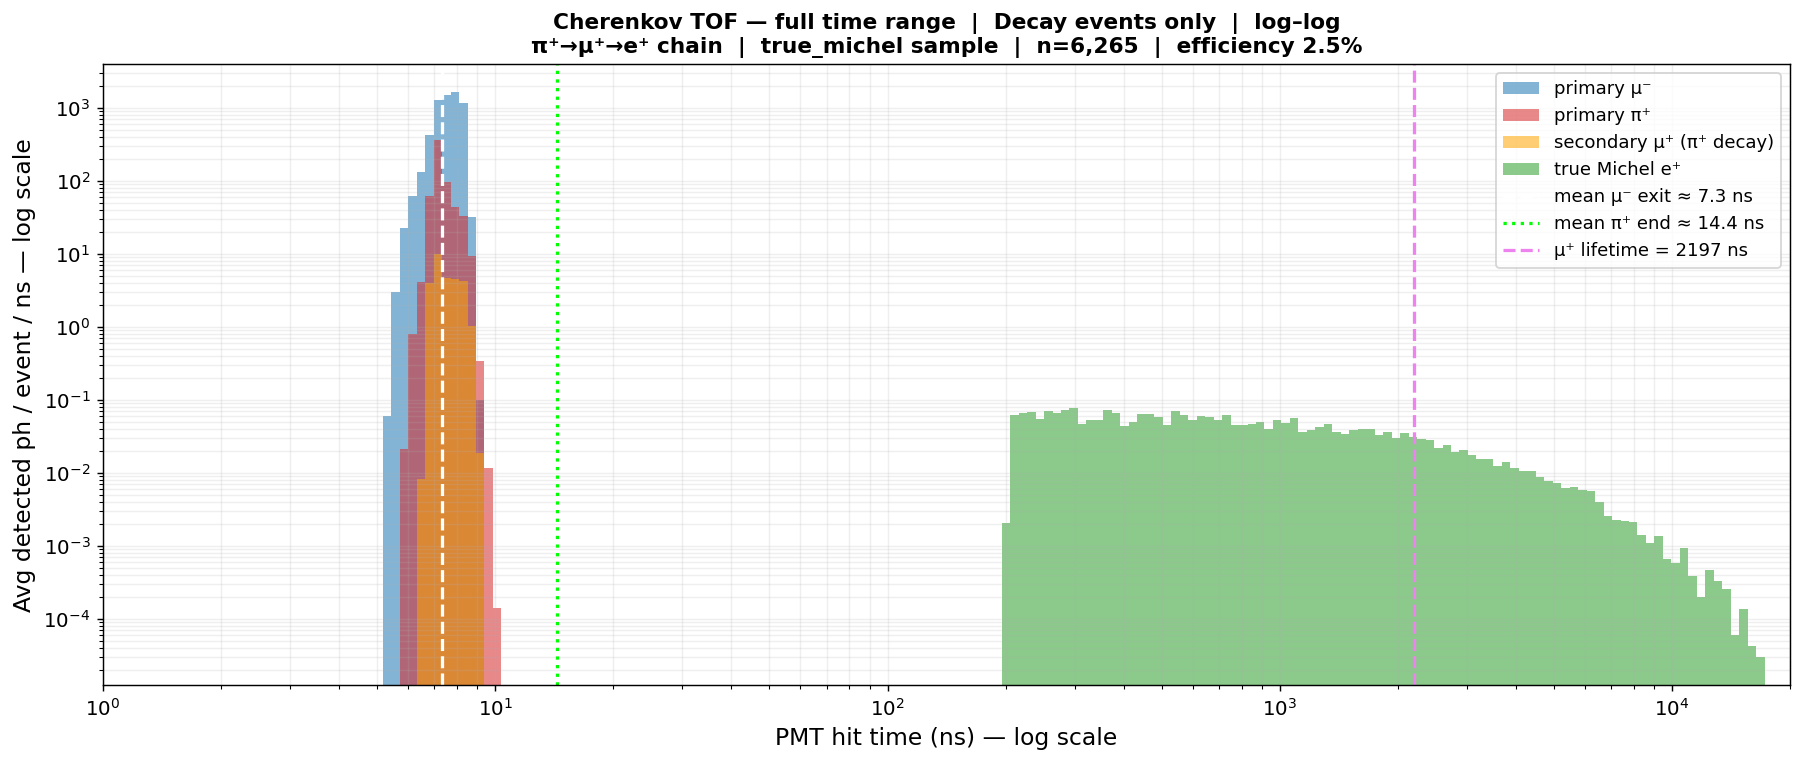

In [57]:
# ── Figure: single panel log-log ──────────────────────────────────────────────
# Use log-spaced bins for accumulation (replace T_FULL / T_PR with this)
LOG_BINS  = np.logspace(np.log10(1), np.log10(20000), 200)   # 1 ns → 20 µs
LOG_CENTS = np.sqrt(LOG_BINS[:-1] * LOG_BINS[1:])            # geometric centers
LOG_WIDTHS = np.diff(LOG_BINS)

# Re-accumulate into log bins (add this pass, or swap out the existing accumulators)
acc_log = {k: np.zeros(len(LOG_CENTS)) for k in ['mu', 'pi', 'smu', 'michel']}

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    for chunk in f[st_key].iterate(st_cols, step_size=500_000, library='pd'):
        chunk['particle']        = chunk['particle'].astype(str).str.strip().str.rstrip('\x00')
        chunk['from_primary_pi'] = chunk['from_primary_pi'].astype(bool)
        chunk = chunk[(chunk['event_id'].isin(decay_ids)) & (chunk['cher_step'] > 0)].copy()
        if len(chunk) == 0:
            continue

        d_wall        = tof_to_cylinder(chunk['x'].values, chunk['y'].values, chunk['z'].values)
        chunk['t_hit']    = chunk['time'] + d_wall / C_WATER
        chunk['cher_det'] = chunk['cher_step'] * DET_EFF

        is_mu  = (chunk['particle'] == 'mu-') & (chunk['parent_id'] == 0)
        is_pi  = (chunk['particle'] == 'pi+') & chunk['from_primary_pi']
        is_smu = (chunk['particle'] == 'mu+') & chunk['from_primary_pi']
        is_ep  = (chunk['particle'] == 'e+') & chunk['from_primary_pi'] & (chunk['time'] > 200.0)

        ep_chunk = chunk[is_ep].copy()
        if len(ep_chunk) > 0:
            michel_mask = np.array([
                pid in mu_plus_map.get(eid, set())
                for pid, eid in zip(ep_chunk['parent_id'].values, ep_chunk['event_id'].values)
            ])
            is_michel_idx = ep_chunk.index[michel_mask]
        else:
            is_michel_idx = pd.Index([])

        for key, sub in [('mu', chunk[is_mu]), ('pi', chunk[is_pi]),
                          ('smu', chunk[is_smu]), ('michel', chunk.loc[is_michel_idx])]:
            if len(sub) == 0:
                continue
            t = np.clip(sub['t_hit'].values, LOG_BINS[0], None)
            w = sub['cher_det'].values
            acc_log[key] += np.histogram(t, bins=LOG_BINS, weights=w)[0]

# Normalize to per-event
for k in acc_log:
    acc_log[k] /= max(n_decay, 1)

# ── Single log-log panel ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors_map = {'mu': C_MU, 'pi': C_PI, 'smu': 'orange', 'michel': C_DECAY}
labels_map = {
    'mu'    : 'primary μ⁻',
    'pi'    : 'primary π⁺',
    'smu'   : 'secondary μ⁺ (π⁺ decay)',
    'michel': 'true Michel e⁺',
}

# Draw as step histograms (fills between log bins)
for key in ['mu', 'pi', 'smu', 'michel']:
    h = acc_log[key]
    # divide by bin width → dN/dt (photons per ns per event) for proper log-log density
    h_density = np.where(h > 0, h / LOG_WIDTHS, np.nan)
    ax.stairs(h_density, LOG_BINS, color=colors_map[key],
              fill=True, alpha=0.55, label=labels_map[key], linewidth=1.5)

# Reference lines
ax.axvline(mu_exit_mean,  color='white', lw=1.8, ls='--',
           label=f'mean μ⁻ exit ≈ {mu_exit_mean:.1f} ns')
ax.axvline(pi_end_mean,   color='lime',  lw=1.8, ls=':',
           label=f'mean π⁺ end ≈ {pi_end_mean:.1f} ns')
ax.axvline(2197,          color='violet', lw=1.8, ls='--',
           label='μ⁺ lifetime = 2197 ns')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1, 2e4)
ax.set_xlabel('PMT hit time (ns) — log scale', fontsize=13)
ax.set_ylabel('Avg detected ph / event / ns — log scale', fontsize=13)
ax.set_title(
    'Cherenkov TOF — full time range  |  Decay events only  |  log–log\n'
    f'π⁺→μ⁺→e⁺ chain  |  true_michel sample  |  n={n_decay:,}  |  efficiency {DET_EFF*100:.1f}%',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, which='both', alpha=0.2)

plt.tight_layout()
plt.savefig('full_time_structure_loglog.png', dpi=150, bbox_inches='tight')
plt.show()

## Why the primary $\mu^-$ usually makes more Cherenkov light than the primary $\pi^+$

For a charged particle moving through water, the Cherenkov photon yield per unit length and per unit wavelength is given by the Frank--Tamm relation

$$
\frac{d^2N}{dx\,d\lambda}
=
\frac{2\pi\alpha}{\lambda^2}
\left(1-\frac{1}{\beta^2 n^2(\lambda)}\right),
\qquad \beta n(\lambda) > 1
$$

where:
- $\alpha$ is the fine-structure constant,
- $\beta = v/c$,
- $n(\lambda)$ is the refractive index of water,
- $\lambda$ is the photon wavelength.

If we ignore the wavelength dependence of $n$ over a fixed optical band, this becomes approximately

$$
\frac{dN}{dx}
\propto
\left(1-\frac{1}{\beta^2 n^2}\right).
$$

So the key point is: **particles with larger $\beta$ sit farther above Cherenkov threshold and produce more light per unit track length**.

The Cherenkov threshold is set by

$$
\beta_{\rm thr} = \frac{1}{n},
$$

or equivalently in momentum,

$$
p_{\rm thr} = m \,\beta_{\rm thr}\gamma_{\rm thr},
\qquad
\gamma_{\rm thr} = \frac{1}{\sqrt{1-\beta_{\rm thr}^2}}.
$$

Because the muon is lighter than the pion, it reaches a larger $\beta$ at the same momentum. In this sample, the primary $\mu^-$ also tends to have a higher initial momentum than the primary $\pi^+$, so it is expected to produce more prompt Cherenkov light.

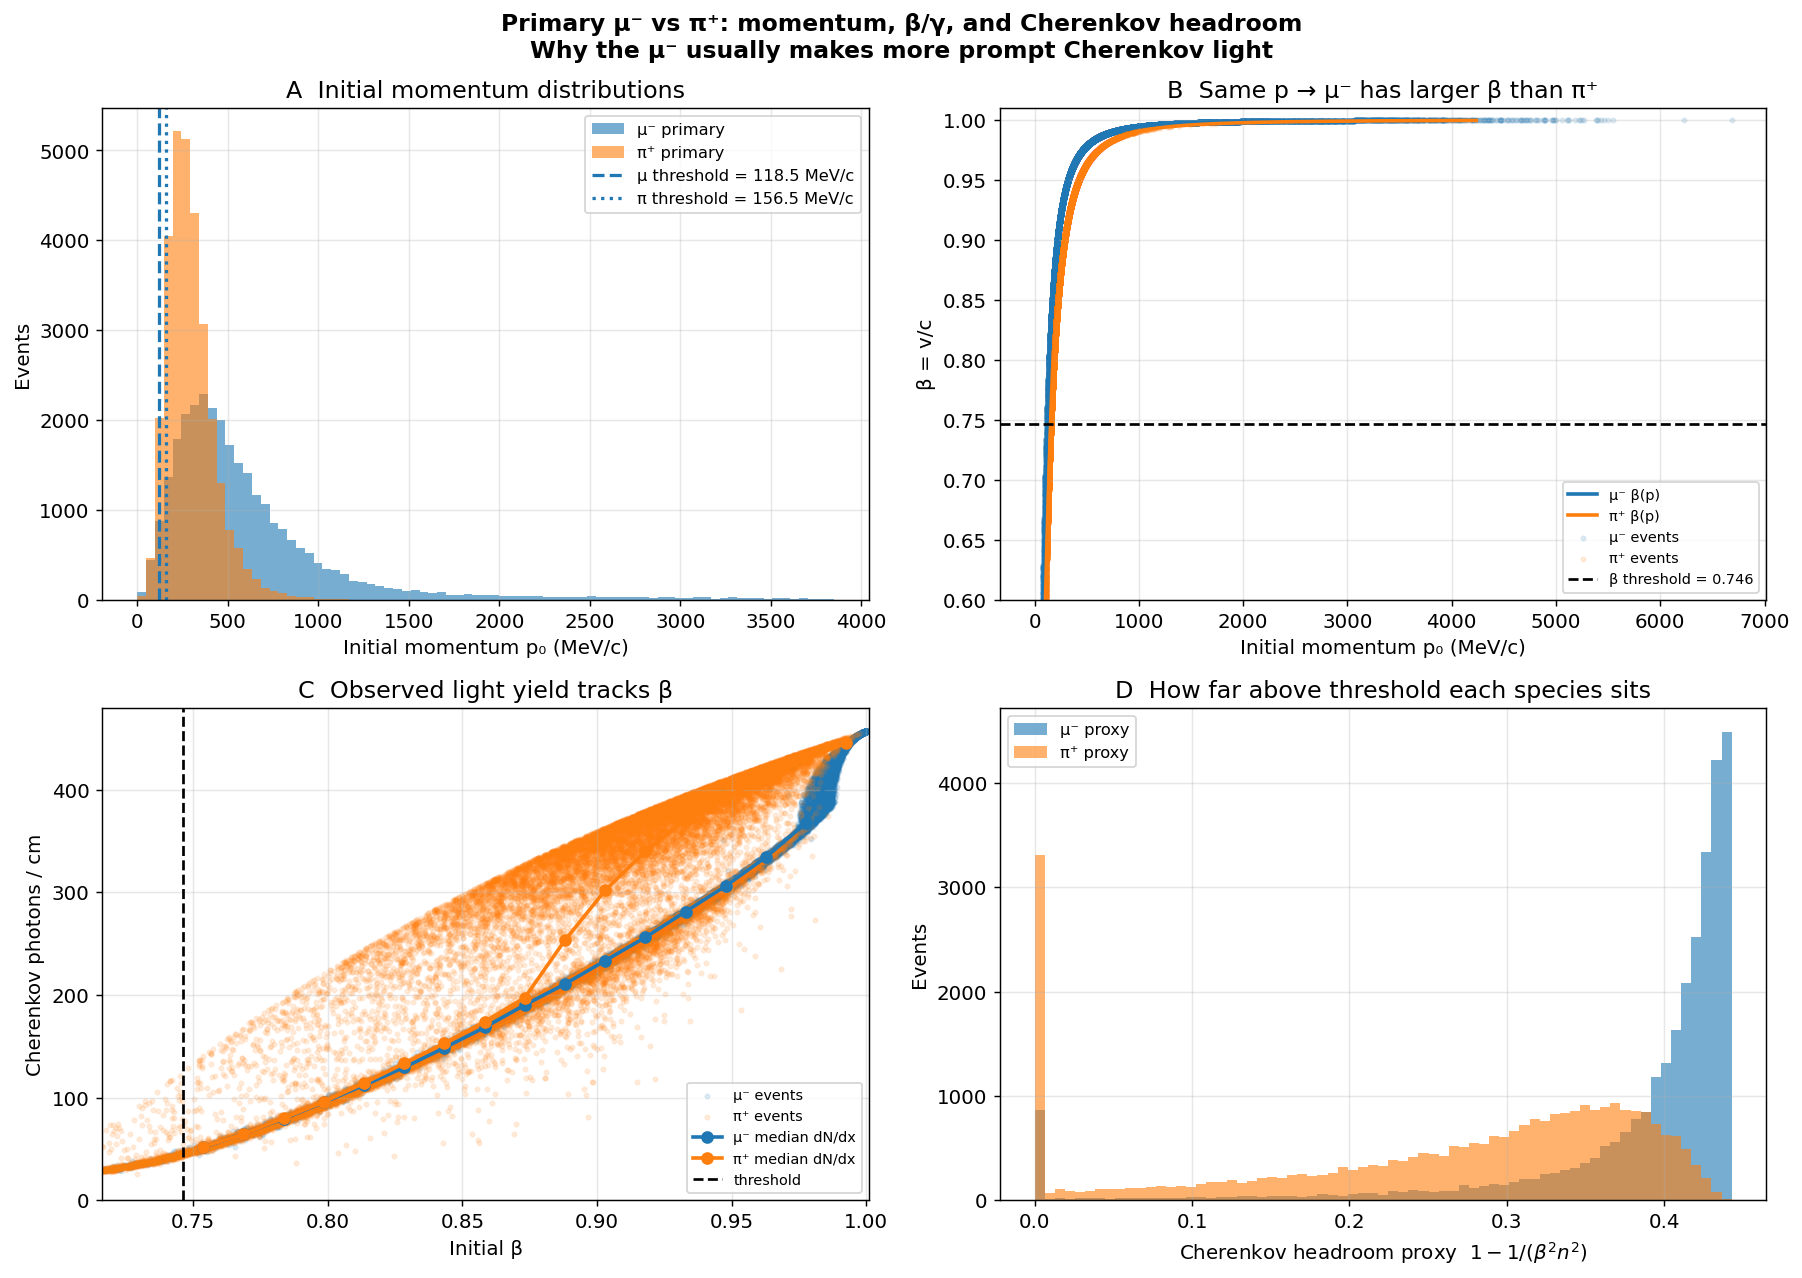

PRIMARY μ⁻ vs π⁺ MOMENTUM / BETA SUMMARY
Water index n                         : 1.34
Cherenkov beta threshold             : 0.7463
μ threshold momentum                 : 118.5 MeV/c
π threshold momentum                 : 156.5 MeV/c

μ mean p0                            : 648.6 MeV/c
π mean p0                            : 296.0 MeV/c
μ mean beta0                         : 0.9515
π mean beta0                         : 0.8651
μ mean gamma0                        : 6.271
π mean gamma0                        : 2.377

μ fraction above threshold           : 97.2%
π fraction above threshold           : 89.2%

μ mean Cherenkov / cm                : 346.4 ph/cm
π mean Cherenkov / cm                : 243.6 ph/cm

At same p = 300 MeV/c:
  μ beta                             : 0.9432
  π beta                             : 0.9067
  μ headroom proxy                   : 0.3740
  π headroom proxy                   : 0.3225

Interpretation:
  The μ⁻ wins twice: it is lighter than the π⁺, so for the sam

In [58]:
# ── Cell: Primary μ- vs π+ momentum / beta / gamma comparison ─────────────────
# Goal:
# 1) show μ- and π+ initial momentum distributions
# 2) convert p -> beta, gamma using particle masses
# 3) compare Cherenkov yield per cm against beta
# 4) show a simple "Cherenkov headroom" proxy above threshold

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Fallbacks in case these aren't in memory yet ----
try:
    SHUF_PATH
except NameError:
    SHUF_PATH = Path(r"D:\research\ANNIE\simualtion\my_geant4\annie_coprimary30kshuffled.root")

EVENT_TREE = "EventTree"

# ---- Constants ----
N_WATER = 1.34
M_MU = 0.1056583755   # GeV/c^2
M_PI = 0.13957039     # GeV/c^2

BETA_THR = 1.0 / N_WATER
GAMMA_THR = 1.0 / np.sqrt(1.0 - BETA_THR**2)

# p_threshold = m * beta * gamma
PTHR_MU = M_MU * BETA_THR * GAMMA_THR
PTHR_PI = M_PI * BETA_THR * GAMMA_THR

# ---- Helpers ----
def choose_best_tree(root_file, tree_name):
    matches = []
    for key in root_file.keys():
        if key.split(";")[0] == tree_name:
            obj = root_file[key]
            n = getattr(obj, "num_entries", -1)
            matches.append((key, n))
    if not matches:
        return None
    matches.sort(key=lambda t: t[1], reverse=True)
    return root_file[matches[0][0]]

def beta_from_p(p, m):
    return p / np.sqrt(p**2 + m**2)

def gamma_from_beta(beta):
    beta = np.clip(beta, 0, 0.999999999)
    return 1.0 / np.sqrt(1.0 - beta**2)

def cherenkov_proxy(beta, n=N_WATER):
    """
    Simple threshold/yield-shape proxy:
        1 - 1/(beta^2 n^2)
    clipped at 0 below threshold.
    Not the full Frank-Tamm formula, just a clean visual "how far above threshold"
    indicator that should track the light yield trend.
    """
    beta = np.asarray(beta)
    out = 1.0 - 1.0 / (beta**2 * n**2)
    return np.clip(out, 0, None)

def binned_median(x, y, bins, min_count=30):
    x = np.asarray(x)
    y = np.asarray(y)
    centers = 0.5 * (bins[:-1] + bins[1:])
    meds = np.full(len(centers), np.nan)
    counts = np.zeros(len(centers), dtype=int)

    idx = np.digitize(x, bins) - 1
    for i in range(len(centers)):
        m = (idx == i) & np.isfinite(x) & np.isfinite(y)
        counts[i] = np.count_nonzero(m)
        if counts[i] >= min_count:
            meds[i] = np.median(y[m])
    return centers, meds, counts

# ---- Load EventTree ----
cols = [
    "event_id",
    "mu_p0", "pi_p0",
    "mu_cher_total", "pi_cher_total",
    "mu_track_len", "pi_track_len",
    "mu_contained", "pi_contained",
]

with uproot.open(SHUF_PATH) as f:
    tree = choose_best_tree(f, EVENT_TREE)
    if tree is None:
        raise KeyError(f"No {EVENT_TREE} found in {SHUF_PATH}")
    cols = [c for c in cols if c in tree.keys()]
    df = tree.arrays(cols, library="pd")

# numeric cleanup
for c in df.columns:
    if c not in ["mu_contained", "pi_contained"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# booleans if present
for c in ["mu_contained", "pi_contained"]:
    if c in df.columns:
        df[c] = df[c].astype(bool)

# track_len is stored in mm in your files -> convert to cm if needed
if "mu_track_len" in df.columns and df["mu_track_len"].max() > 600:
    df["mu_track_len"] = df["mu_track_len"] / 10.0
if "pi_track_len" in df.columns and df["pi_track_len"].max() > 600:
    df["pi_track_len"] = df["pi_track_len"] / 10.0

# ---- Derived quantities ----
df["mu_beta0"]  = beta_from_p(df["mu_p0"], M_MU)
df["pi_beta0"]  = beta_from_p(df["pi_p0"], M_PI)

df["mu_gamma0"] = gamma_from_beta(df["mu_beta0"])
df["pi_gamma0"] = gamma_from_beta(df["pi_beta0"])

df["mu_proxy"]  = cherenkov_proxy(df["mu_beta0"])
df["pi_proxy"]  = cherenkov_proxy(df["pi_beta0"])

df["mu_cher_per_cm"] = np.where(df["mu_track_len"] > 0,
                                df["mu_cher_total"] / df["mu_track_len"],
                                np.nan)
df["pi_cher_per_cm"] = np.where(df["pi_track_len"] > 0,
                                df["pi_cher_total"] / df["pi_track_len"],
                                np.nan)

# valid masks
mu_valid = np.isfinite(df["mu_p0"]) & np.isfinite(df["mu_beta0"]) & np.isfinite(df["mu_cher_per_cm"])
pi_valid = np.isfinite(df["pi_p0"]) & np.isfinite(df["pi_beta0"]) & np.isfinite(df["pi_cher_per_cm"])

# binned medians for dN/dx vs beta
beta_bins = np.linspace(BETA_THR, 1.0, 18)
mu_bc, mu_med, _ = binned_median(df.loc[mu_valid, "mu_beta0"], df.loc[mu_valid, "mu_cher_per_cm"], beta_bins)
pi_bc, pi_med, _ = binned_median(df.loc[pi_valid, "pi_beta0"], df.loc[pi_valid, "pi_cher_per_cm"], beta_bins)

# theoretical beta(p) curves for reference
p_grid = np.linspace(0.0, max(df["mu_p0"].quantile(0.995), df["pi_p0"].quantile(0.995)) * 1.1, 500)
beta_mu_grid = beta_from_p(p_grid, M_MU)
beta_pi_grid = beta_from_p(p_grid, M_PI)

# ---- Figure ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Primary μ⁻ vs π⁺: momentum, β/γ, and Cherenkov headroom\n"
    "Why the μ⁻ usually makes more prompt Cherenkov light",
    fontsize=13, fontweight="bold"
)

# A) Momentum distributions
ax = axes[0, 0]
pmax = max(df["mu_p0"].quantile(0.995), df["pi_p0"].quantile(0.995))
bins_p = np.linspace(0, pmax, 80)

ax.hist(df["mu_p0"] * 1000, bins=bins_p * 1000, alpha=0.60, label="μ⁻ primary")
ax.hist(df["pi_p0"] * 1000, bins=bins_p * 1000, alpha=0.60, label="π⁺ primary")
ax.axvline(PTHR_MU * 1000, ls="--", lw=1.8, label=f"μ threshold = {PTHR_MU*1000:.1f} MeV/c")
ax.axvline(PTHR_PI * 1000, ls=":",  lw=1.8, label=f"π threshold = {PTHR_PI*1000:.1f} MeV/c")
ax.set_xlabel("Initial momentum p₀ (MeV/c)")
ax.set_ylabel("Events")
ax.set_title("A  Initial momentum distributions")
ax.legend(fontsize=9)

# B) beta vs momentum
ax = axes[0, 1]
ax.plot(p_grid * 1000, beta_mu_grid, lw=2.0, label="μ⁻ β(p)")
ax.plot(p_grid * 1000, beta_pi_grid, lw=2.0, label="π⁺ β(p)")
ax.scatter(df["mu_p0"] * 1000, df["mu_beta0"], s=6, alpha=0.12, label="μ⁻ events")
ax.scatter(df["pi_p0"] * 1000, df["pi_beta0"], s=6, alpha=0.12, label="π⁺ events")
ax.axhline(BETA_THR, color="black", ls="--", lw=1.5, label=f"β threshold = {BETA_THR:.3f}")
ax.set_xlabel("Initial momentum p₀ (MeV/c)")
ax.set_ylabel("β = v/c")
ax.set_ylim(0.6, 1.01)
ax.set_title("B  Same p → μ⁻ has larger β than π⁺")
ax.legend(fontsize=8)

# C) Cherenkov photons per cm vs beta
ax = axes[1, 0]
ymax = max(
    np.nanquantile(df["mu_cher_per_cm"], 0.995),
    np.nanquantile(df["pi_cher_per_cm"], 0.995)
)

ax.scatter(df.loc[mu_valid, "mu_beta0"], df.loc[mu_valid, "mu_cher_per_cm"],
           s=6, alpha=0.12, label="μ⁻ events")
ax.scatter(df.loc[pi_valid, "pi_beta0"], df.loc[pi_valid, "pi_cher_per_cm"],
           s=6, alpha=0.12, label="π⁺ events")

ax.plot(mu_bc, mu_med, marker="o", lw=2.0, label="μ⁻ median dN/dx")
ax.plot(pi_bc, pi_med, marker="o", lw=2.0, label="π⁺ median dN/dx")

ax.axvline(BETA_THR, color="black", ls="--", lw=1.5, label="threshold")
ax.set_xlim(max(0.70, BETA_THR - 0.03), 1.001)
ax.set_ylim(0, ymax * 1.05)
ax.set_xlabel("Initial β")
ax.set_ylabel("Cherenkov photons / cm")
ax.set_title("C  Observed light yield tracks β")
ax.legend(fontsize=8)

# D) Simple Cherenkov headroom proxy
ax = axes[1, 1]
bins_proxy = np.linspace(0, max(df["mu_proxy"].quantile(0.995), df["pi_proxy"].quantile(0.995)), 70)
ax.hist(df["mu_proxy"], bins=bins_proxy, alpha=0.60, label="μ⁻ proxy")
ax.hist(df["pi_proxy"], bins=bins_proxy, alpha=0.60, label="π⁺ proxy")
ax.set_xlabel(r"Cherenkov headroom proxy  $1 - 1/(\beta^2 n^2)$")
ax.set_ylabel("Events")
ax.set_title("D  How far above threshold each species sits")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ---- Compact summary ----
p_ref = 0.300  # GeV/c, just for an easy same-momentum comparison
beta_mu_ref = beta_from_p(p_ref, M_MU)
beta_pi_ref = beta_from_p(p_ref, M_PI)
proxy_mu_ref = cherenkov_proxy(beta_mu_ref)
proxy_pi_ref = cherenkov_proxy(beta_pi_ref)

print("=" * 68)
print("PRIMARY μ⁻ vs π⁺ MOMENTUM / BETA SUMMARY")
print("=" * 68)
print(f"Water index n                         : {N_WATER:.2f}")
print(f"Cherenkov beta threshold             : {BETA_THR:.4f}")
print(f"μ threshold momentum                 : {PTHR_MU*1000:.1f} MeV/c")
print(f"π threshold momentum                 : {PTHR_PI*1000:.1f} MeV/c")
print()
print(f"μ mean p0                            : {df['mu_p0'].mean()*1000:.1f} MeV/c")
print(f"π mean p0                            : {df['pi_p0'].mean()*1000:.1f} MeV/c")
print(f"μ mean beta0                         : {df['mu_beta0'].mean():.4f}")
print(f"π mean beta0                         : {df['pi_beta0'].mean():.4f}")
print(f"μ mean gamma0                        : {df['mu_gamma0'].mean():.3f}")
print(f"π mean gamma0                        : {df['pi_gamma0'].mean():.3f}")
print()
print(f"μ fraction above threshold           : {(df['mu_p0'] > PTHR_MU).mean()*100:.1f}%")
print(f"π fraction above threshold           : {(df['pi_p0'] > PTHR_PI).mean()*100:.1f}%")
print()
print(f"μ mean Cherenkov / cm                : {df['mu_cher_per_cm'].mean():.1f} ph/cm")
print(f"π mean Cherenkov / cm                : {df['pi_cher_per_cm'].mean():.1f} ph/cm")
print()
print(f"At same p = 300 MeV/c:")
print(f"  μ beta                             : {beta_mu_ref:.4f}")
print(f"  π beta                             : {beta_pi_ref:.4f}")
print(f"  μ headroom proxy                   : {proxy_mu_ref:.4f}")
print(f"  π headroom proxy                   : {proxy_pi_ref:.4f}")
print()
print("Interpretation:")
print("  The μ⁻ wins twice: it is lighter than the π⁺, so for the same p it has larger β,")
print("  and in this sample it also tends to start with higher momentum.")
print("  Both effects push the μ⁻ farther above Cherenkov threshold, so it usually makes")
print("  more prompt Cherenkov light.")


### Analytic Cherenkov baseline used here
This simulation **does not create or track optical photons in Geant4**.  
Geant4 handles **particle transport**; Cherenkov yield is computed analytically
per step as `cher_step` via the Frank–Tamm integral over 300–700 nm.

$$
\frac{d^2N}{dx\,d\lambda}
= \frac{2\pi\alpha}{\lambda^2}
  \left(1 - \frac{1}{\beta^2 n^2(\lambda)}\right),
\qquad \beta\,n(\lambda) > 1.
$$

The red reference curve is **track-averaged Frank–Tamm**: the particle is
numerically propagated from $p_0$ to rest via Bethe-Bloch stopping power,
accumulating $dN/dx \cdot dx$ at each step, divided by total range.
This matches `cher_total / track_len` from the EventTree.

**Panels C & D** split π⁺ by final process to expose the inelastic bias:
inelastic pions are truncated mid-track at high β, inflating `cher_total/track_len`
above the stopping-particle prediction.


π⁺ fate breakdown:
  Decay      : 15,867  (52.9%)
  Inelastic  : 14,107  (47.0%)
  Other      : 26  (0.1%)

Computing track-averaged Frank–Tamm curves (~10 s)...
Done.


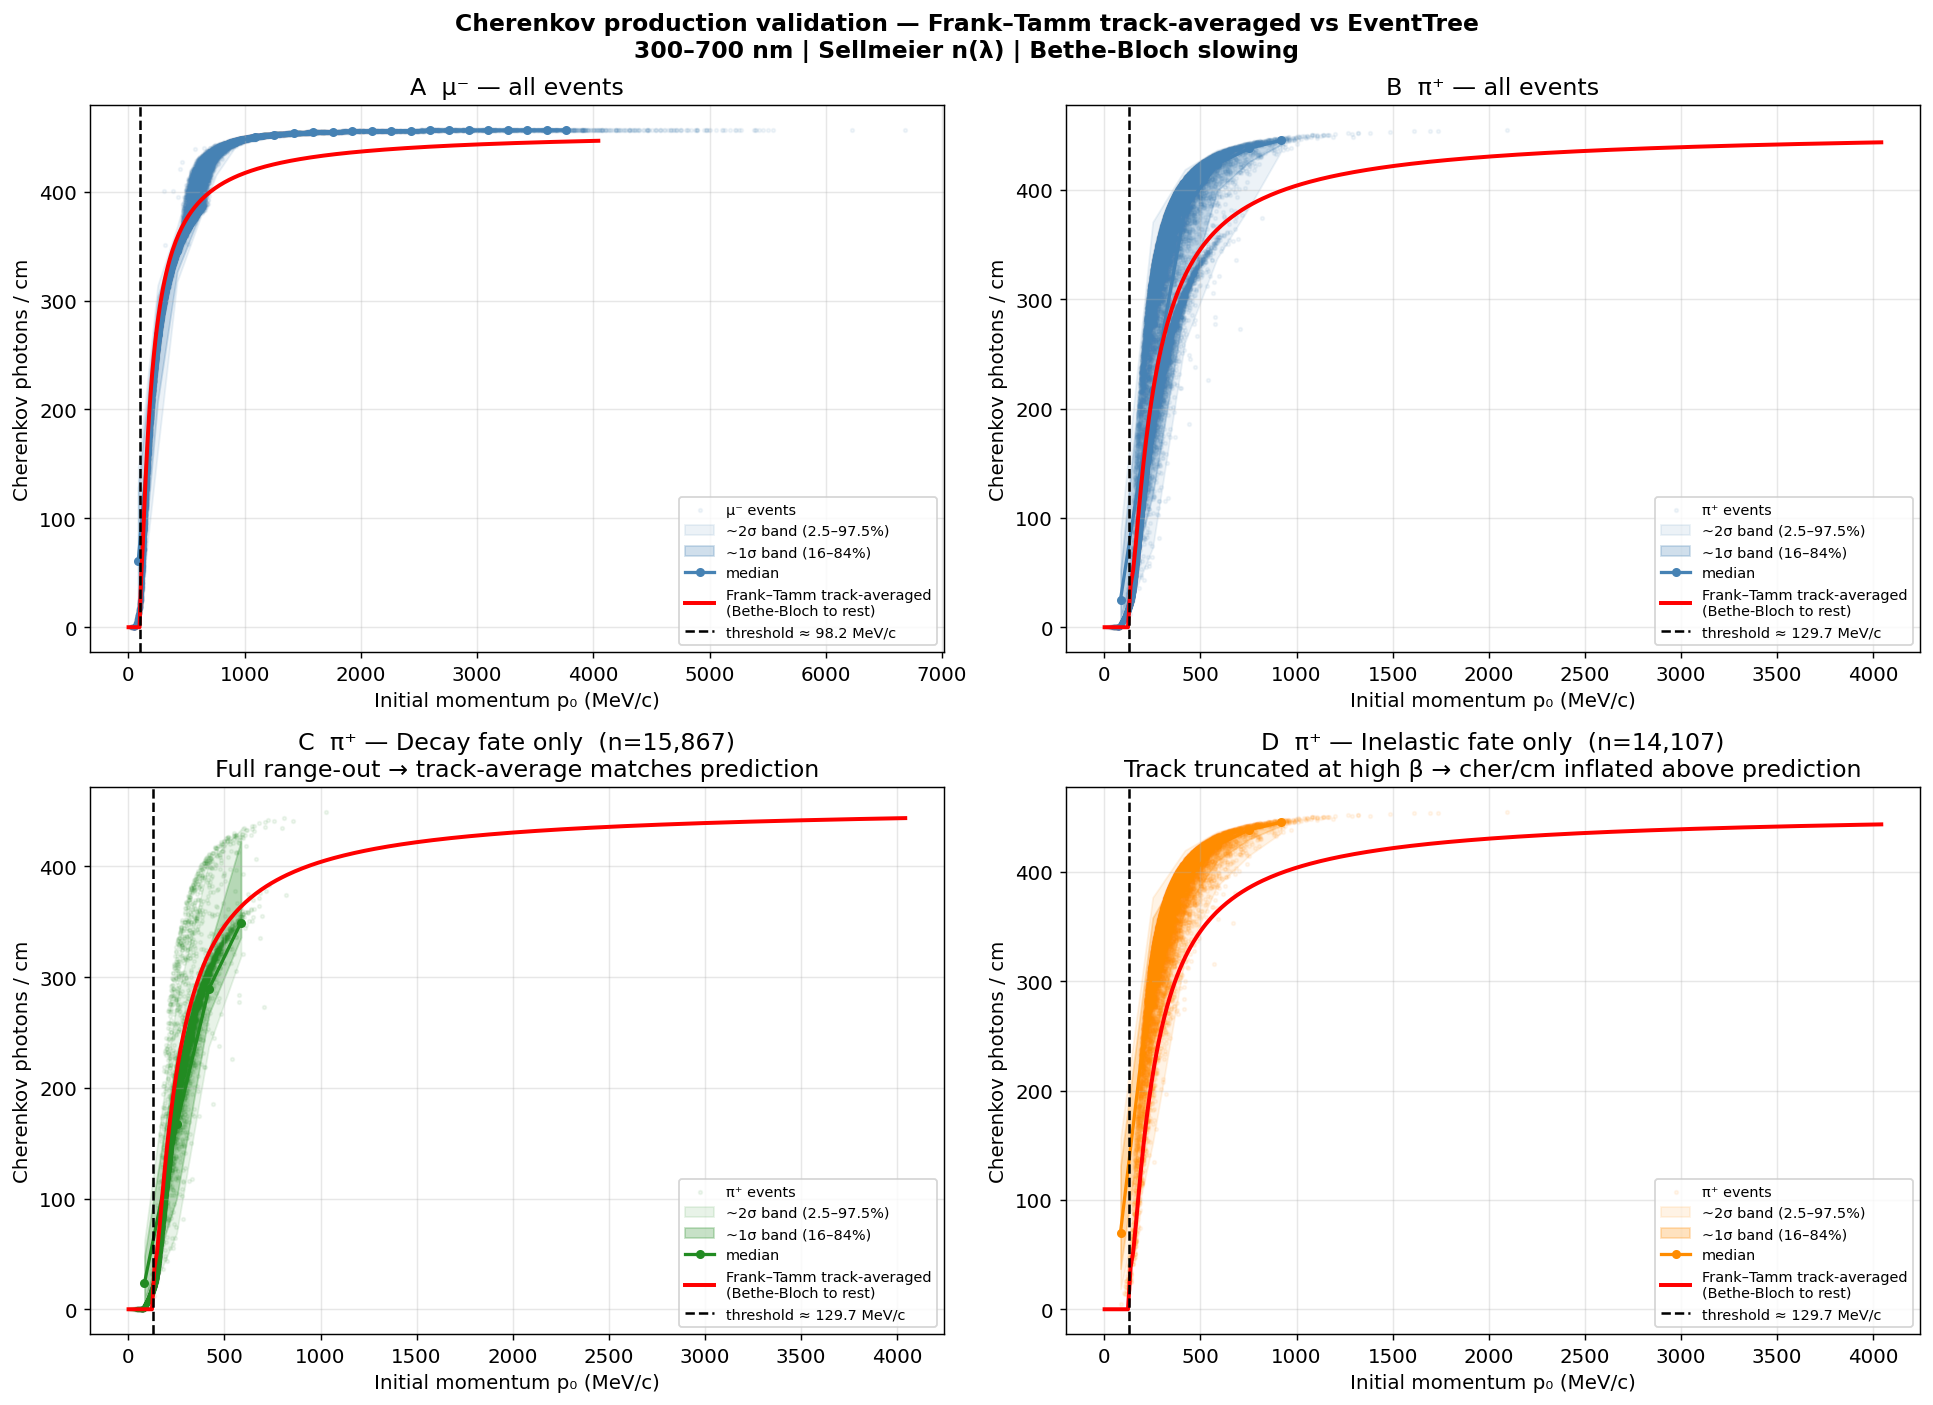

ANALYTIC CHERENKOV MODEL SUMMARY
Wavelength band                            : 300–700 nm
Number of wavelength bins                  : 40
Effective weighted refractive index        : 1.4692
Integrated β→1 Frank–Tamm limit            : 457.0 ph/cm

μ threshold momentum (effective)           : 98.2 MeV/c
π threshold momentum (effective)           : 129.7 MeV/c

μ mean initial momentum                    : 648.6 MeV/c
π mean initial momentum                    : 296.0 MeV/c

μ mean total Cherenkov                     : 59,125.7
π mean total Cherenkov                     : 10,161.5

μ mean Cherenkov / cm                      : 346.4 ph/cm
π mean Cherenkov / cm (all)                : 243.6 ph/cm
π mean Cherenkov / cm (Decay only)         : 152.0 ph/cm
π mean Cherenkov / cm (Inelastic only)     : 346.2 ph/cm
  → Inelastic inflation vs Decay           : 2.277×

μ fraction above effective threshold       : 98.2%
π fraction above effective threshold       : 94.6%

π⁺ fate breakdown:
  Decay     

In [71]:
# ── Cell: Analytic Cherenkov model validation for primary μ- and π+ ──────────
from IPython.display import display, Markdown

EVENT_TREE = "EventTree"

# ─── Physics constants ────────────────────────────────────────────────────────
ALPHA      = 1 / 137.035999084
M_MU       = 0.1056583755   # GeV/c²
M_PI       = 0.13957039     # GeV/c²
LAM_MIN_NM = 300.0
LAM_MAX_NM = 700.0
N_LAM_BINS = 40

LAM_EDGES_NM = np.linspace(LAM_MIN_NM, LAM_MAX_NM, N_LAM_BINS + 1)
LAM_CENT_NM  = 0.5 * (LAM_EDGES_NM[:-1] + LAM_EDGES_NM[1:])
DLAM_CM      = np.diff(LAM_EDGES_NM) * 1e-7
LAM_CENT_CM  = LAM_CENT_NM * 1e-7

# ─── Helpers ──────────────────────────────────────────────────────────────────
def choose_best_tree(root_file, tree_name):
    matches = []
    for key in root_file.keys():
        if key.split(";")[0] == tree_name:
            obj = root_file[key]
            n = getattr(obj, "num_entries", -1)
            matches.append((key, n))
    if not matches:
        return None
    matches.sort(key=lambda t: t[1], reverse=True)
    return root_file[matches[0][0]]

def beta_from_p(p, m):
    p = np.asarray(p, dtype=float)
    return p / np.sqrt(p**2 + m**2)

def gamma_from_p(p, m):
    p = np.asarray(p, dtype=float)
    return np.sqrt(1.0 + (p / m)**2)

def n_water_dispersion(lam_nm):
    """Exact Sellmeier coefficients from CherenkovAnalyzer.cc (Daimon & Masumura 2007)."""
    lam  = np.asarray(lam_nm, dtype=float) * 1e-3
    lam2 = lam**2
    B = np.array([0.75831, 0.08495, 0.00143])
    C = np.array([0.01007, 0.08997, 897.0  ])
    n2 = 1.0 + np.sum(B[:, None] * lam2[None, :]
                      / (lam2[None, :] - C[:, None]), axis=0)
    return np.sqrt(n2)

def frank_tamm_per_cm_band(p, m):
    """Instantaneous Frank–Tamm photons/cm at momentum p (GeV/c), 300–700 nm."""
    beta  = beta_from_p(p, m)
    beta2 = np.atleast_1d(beta)**2
    nlam  = n_water_dispersion(LAM_CENT_NM)
    headroom = np.clip(1.0 - 1.0 / (beta2[:, None] * nlam[None, :]**2), 0., None)
    d2N   = 2.0 * np.pi * ALPHA * headroom / (LAM_CENT_CM[None, :]**2)
    return np.sum(d2N * DLAM_CM[None, :], axis=1)

def bethe_bloch_water_GeV(p_GeV, m_GeV):
    """dE/dx [MeV/cm] in liquid water. PDG parameterization, Sternheimer density effect."""
    p_MeV = np.asarray(p_GeV, dtype=float) * 1000.
    M_MeV = m_GeV * 1000.
    E_MeV = np.sqrt(p_MeV**2 + M_MeV**2)
    gamma = E_MeV / M_MeV
    beta  = p_MeV / E_MeV
    bg    = beta * gamma
    I_water  = 79.7e-6
    Z_over_A = 0.555
    me       = 0.511
    K        = 0.307075
    x  = np.log10(bg)
    C_s, x0, x1, a, k = -3.5017, 0.2400, 2.8004, 0.09116, 3.4773
    delta = np.where(x >= x1,
                2*np.log(10)*x + C_s,
                np.where(x >= x0,
                    2*np.log(10)*x + C_s + a*(x1 - x)**k,
                    0.0))
    Tmax = (2*me*beta**2*gamma**2
            / (1 + 2*gamma*me/M_MeV + (me/M_MeV)**2))
    ln_t = np.log(2*me*beta**2*gamma**2*Tmax / I_water**2)
    return K * Z_over_A / beta**2 * (0.5*ln_t - beta**2 - delta/2)

def frank_tamm_track_averaged(p0_array, m_GeV, n_steps=200):
    """
    Track-averaged Frank–Tamm dN/dx [photons/cm].
    Integrates dN/dx * dx from p0 to rest via Bethe-Bloch, divides by range.
    Matches cher_total/track_len in EventTree.
    """
    p0_array = np.asarray(p0_array, dtype=float)
    result   = np.empty_like(p0_array)
    n_eff    = np.average(n_water_dispersion(LAM_CENT_NM),
                          weights=1./LAM_CENT_CM**2)
    beta_thr = 1.0 / n_eff
    p_thr    = m_GeV * beta_thr / np.sqrt(1.0 - beta_thr**2)
    for i, p0 in enumerate(p0_array):
        if p0 <= p_thr:
            result[i] = 0.0
            continue
        E0    = np.sqrt(p0**2 + m_GeV**2)
        E_min = max(np.sqrt(p_thr**2 + m_GeV**2) * 0.95, m_GeV * 1.001)
        E_grid = np.linspace(E0, E_min, n_steps)
        total_photons = 0.0
        total_length  = 0.0
        for j in range(len(E_grid) - 1):
            E_mid = 0.5 * (E_grid[j] + E_grid[j+1])
            dE    = abs(E_grid[j] - E_grid[j+1])
            p_mid = np.sqrt(max(E_mid**2 - m_GeV**2, 0.))
            if p_mid <= 0: continue
            dEdx_mev_cm = bethe_bloch_water_GeV(p_mid, m_GeV)
            if dEdx_mev_cm <= 0: continue
            dx_cm = (dE * 1000.) / dEdx_mev_cm
            dNdx  = frank_tamm_per_cm_band(np.array([p_mid]), m_GeV)[0]
            total_photons += dNdx * dx_cm
            total_length  += dx_cm
        result[i] = total_photons / total_length if total_length > 0 else 0.0
    return result

def effective_threshold_momentum(m):
    n_eff     = np.average(n_water_dispersion(LAM_CENT_NM),
                           weights=1./LAM_CENT_CM**2)
    beta_thr  = 1.0 / n_eff
    gamma_thr = 1.0 / np.sqrt(1.0 - beta_thr**2)
    return m * beta_thr * gamma_thr, n_eff

def binned_quantiles(x, y, bins, qs=(0.025, 0.16, 0.50, 0.84, 0.975),
                     min_count=35):
    x = np.asarray(x); y = np.asarray(y)
    centers = 0.5 * (bins[:-1] + bins[1:])
    out     = {q: np.full(len(centers), np.nan) for q in qs}
    counts  = np.zeros(len(centers), dtype=int)
    idx     = np.digitize(x, bins) - 1
    for i in range(len(centers)):
        m = (idx == i) & np.isfinite(x) & np.isfinite(y)
        counts[i] = m.sum()
        if counts[i] >= min_count:
            for q in qs:
                out[q][i] = np.quantile(y[m], q)
    return centers, out, counts

# ─── Description ─────────────────────────────────────────────────────────────
display(Markdown(r"""
### Analytic Cherenkov baseline used here
This simulation **does not create or track optical photons in Geant4**.  
Geant4 handles **particle transport**; Cherenkov yield is computed analytically
per step as `cher_step` via the Frank–Tamm integral over 300–700 nm.

$$
\frac{d^2N}{dx\,d\lambda}
= \frac{2\pi\alpha}{\lambda^2}
  \left(1 - \frac{1}{\beta^2 n^2(\lambda)}\right),
\qquad \beta\,n(\lambda) > 1.
$$

The red reference curve is **track-averaged Frank–Tamm**: the particle is
numerically propagated from $p_0$ to rest via Bethe-Bloch stopping power,
accumulating $dN/dx \cdot dx$ at each step, divided by total range.
This matches `cher_total / track_len` from the EventTree.

**Panels C & D** split π⁺ by final process to expose the inelastic bias:
inelastic pions are truncated mid-track at high β, inflating `cher_total/track_len`
above the stopping-particle prediction.
"""))

# ─── Load EventTree ───────────────────────────────────────────────────────────
cols = [
    "event_id",
    "mu_p0", "pi_p0",
    "mu_cher_total", "pi_cher_total",
    "mu_track_len",  "pi_track_len",
    "mu_final_process", "pi_final_process",
]
with uproot.open(SHUF_PATH) as f:
    tree = choose_best_tree(f, EVENT_TREE)
    if tree is None:
        raise KeyError(f"No {EVENT_TREE} found in {SHUF_PATH}")
    cols = [c for c in cols if c in tree.keys()]
    ev = tree.arrays(cols, library="pd")

# ── Numeric columns only
for c in ["mu_p0", "pi_p0", "mu_cher_total", "pi_cher_total",
          "mu_track_len", "pi_track_len"]:
    if c in ev.columns:
        ev[c] = pd.to_numeric(ev[c], errors="coerce")

# ── String columns — same cleaning as the working kinematics cell
for c in ["mu_final_process", "pi_final_process"]:
    if c in ev.columns:
        ev[c] = (ev[c].astype(str)
                      .str.strip()
                      .str.rstrip('\x00'))

# track_len stored in mm → convert to cm
if ev["mu_track_len"].max() > 600:
    ev["mu_track_len"] = ev["mu_track_len"] / 10.0
if ev["pi_track_len"].max() > 600:
    ev["pi_track_len"] = ev["pi_track_len"] / 10.0

ev["mu_cher_per_cm"] = np.where(ev["mu_track_len"] > 0,
                                ev["mu_cher_total"] / ev["mu_track_len"], np.nan)
ev["pi_cher_per_cm"] = np.where(ev["pi_track_len"] > 0,
                                ev["pi_cher_total"] / ev["pi_track_len"], np.nan)

# ─── Fate masks ───────────────────────────────────────────────────────────────
mu_mask       = np.isfinite(ev["mu_p0"]) & np.isfinite(ev["mu_cher_per_cm"])
pi_mask       = np.isfinite(ev["pi_p0"]) & np.isfinite(ev["pi_cher_per_cm"])
pi_decay_mask = pi_mask & (ev["pi_final_process"] == "Decay")
pi_inel_mask  = pi_mask & ev["pi_final_process"].str.contains("Inelastic", na=False)

n_decay = pi_decay_mask.sum()
n_inel  = pi_inel_mask.sum()
n_other = pi_mask.sum() - n_decay - n_inel
print(f"π⁺ fate breakdown:")
print(f"  Decay      : {n_decay:,}  ({100*n_decay/pi_mask.sum():.1f}%)")
print(f"  Inelastic  : {n_inel:,}  ({100*n_inel/pi_mask.sum():.1f}%)")
print(f"  Other      : {n_other:,}  ({100*n_other/pi_mask.sum():.1f}%)")

# ─── Theory curves (track-averaged) ──────────────────────────────────────────
pmax   = max(ev["mu_p0"].quantile(0.995), ev["pi_p0"].quantile(0.995))
p_grid = np.linspace(0.001, pmax * 1.05, 300)

print("\nComputing track-averaged Frank–Tamm curves (~10 s)...")
mu_ft = frank_tamm_track_averaged(p_grid, M_MU)
pi_ft = frank_tamm_track_averaged(p_grid, M_PI)
print("Done.")

PTHR_MU, N_EFF = effective_threshold_momentum(M_MU)
PTHR_PI, _     = effective_threshold_momentum(M_PI)

# ─── Binned quantiles ─────────────────────────────────────────────────────────
p_bins = np.linspace(0.0, pmax, 24)

mu_pc,  mu_q,  _ = binned_quantiles(ev.loc[mu_mask,       "mu_p0"],
                                    ev.loc[mu_mask,       "mu_cher_per_cm"], p_bins)
pi_pc,  pi_q,  _ = binned_quantiles(ev.loc[pi_mask,       "pi_p0"],
                                    ev.loc[pi_mask,       "pi_cher_per_cm"], p_bins)
pid_pc, pid_q, _ = binned_quantiles(ev.loc[pi_decay_mask, "pi_p0"],
                                    ev.loc[pi_decay_mask, "pi_cher_per_cm"], p_bins)
pii_pc, pii_q, _ = binned_quantiles(ev.loc[pi_inel_mask,  "pi_p0"],
                                    ev.loc[pi_inel_mask,  "pi_cher_per_cm"], p_bins)

# ─── Figure: 2×2 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    "Cherenkov production validation — Frank–Tamm track-averaged vs EventTree\n"
    "300–700 nm | Sellmeier n(λ) | Bethe-Bloch slowing",
    fontsize=13, fontweight="bold"
)

def draw_panel(ax, x_data, y_data, pc, q, ft_curve, pthr,
               particle_label, panel_letter, subtitle,
               scatter_color, band_color):
    ax.scatter(x_data * 1000, y_data,
               s=4, alpha=0.07, color=scatter_color,
               label=f"{particle_label} events")
    ax.fill_between(pc*1000, q[0.025], q[0.975],
                    alpha=0.10, color=band_color,
                    label="~2σ band (2.5–97.5%)")
    ax.fill_between(pc*1000, q[0.16],  q[0.84],
                    alpha=0.25, color=band_color,
                    label="~1σ band (16–84%)")
    ax.plot(pc*1000, q[0.50],
            marker="o", ms=4, lw=1.8, color=band_color,
            label="median")
    ax.plot(p_grid*1000, ft_curve,
            color="red", lw=2.2,
            label="Frank–Tamm track-averaged\n(Bethe-Bloch to rest)")
    ax.axvline(pthr*1000, color="black", ls="--", lw=1.4,
               label=f"threshold ≈ {pthr*1000:.1f} MeV/c")
    ax.set_xlabel("Initial momentum p₀ (MeV/c)")
    ax.set_ylabel("Cherenkov photons / cm")
    ax.set_title(f"{panel_letter}  {particle_label} — {subtitle}")
    ax.legend(fontsize=8)

draw_panel(axes[0, 0],
           ev.loc[mu_mask, "mu_p0"], ev.loc[mu_mask, "mu_cher_per_cm"],
           mu_pc, mu_q, mu_ft, PTHR_MU,
           "μ⁻", "A", "all events",
           scatter_color="steelblue", band_color="steelblue")

draw_panel(axes[0, 1],
           ev.loc[pi_mask, "pi_p0"], ev.loc[pi_mask, "pi_cher_per_cm"],
           pi_pc, pi_q, pi_ft, PTHR_PI,
           "π⁺", "B", "all events",
           scatter_color="steelblue", band_color="steelblue")

draw_panel(axes[1, 0],
           ev.loc[pi_decay_mask, "pi_p0"], ev.loc[pi_decay_mask, "pi_cher_per_cm"],
           pid_pc, pid_q, pi_ft, PTHR_PI,
           "π⁺", "C", f"Decay fate only  (n={n_decay:,})",
           scatter_color="forestgreen", band_color="forestgreen")
axes[1, 0].set_title(f"C  π⁺ — Decay fate only  (n={n_decay:,})\n"
                      "Full range-out → track-average matches prediction")

draw_panel(axes[1, 1],
           ev.loc[pi_inel_mask, "pi_p0"], ev.loc[pi_inel_mask, "pi_cher_per_cm"],
           pii_pc, pii_q, pi_ft, PTHR_PI,
           "π⁺", "D", f"Inelastic fate only  (n={n_inel:,})",
           scatter_color="darkorange", band_color="darkorange")
axes[1, 1].set_title(f"D  π⁺ — Inelastic fate only  (n={n_inel:,})\n"
                      "Track truncated at high β → cher/cm inflated above prediction")

plt.tight_layout()
plt.show()

# ─── Summary ──────────────────────────────────────────────────────────────────
ft_beta1   = frank_tamm_per_cm_band(np.array([1e6]), M_MU)[0]
decay_mean = ev.loc[pi_decay_mask, "pi_cher_per_cm"].mean()
inel_mean  = ev.loc[pi_inel_mask,  "pi_cher_per_cm"].mean()

print("=" * 74)
print("ANALYTIC CHERENKOV MODEL SUMMARY")
print("=" * 74)
print(f"Wavelength band                            : {LAM_MIN_NM:.0f}–{LAM_MAX_NM:.0f} nm")
print(f"Number of wavelength bins                  : {N_LAM_BINS}")
print(f"Effective weighted refractive index        : {N_EFF:.4f}")
print(f"Integrated β→1 Frank–Tamm limit            : {ft_beta1:.1f} ph/cm")
print()
print(f"μ threshold momentum (effective)           : {PTHR_MU*1000:.1f} MeV/c")
print(f"π threshold momentum (effective)           : {PTHR_PI*1000:.1f} MeV/c")
print()
print(f"μ mean initial momentum                    : {ev['mu_p0'].mean()*1000:.1f} MeV/c")
print(f"π mean initial momentum                    : {ev['pi_p0'].mean()*1000:.1f} MeV/c")
print()
print(f"μ mean total Cherenkov                     : {ev['mu_cher_total'].mean():,.1f}")
print(f"π mean total Cherenkov                     : {ev['pi_cher_total'].mean():,.1f}")
print()
print(f"μ mean Cherenkov / cm                      : {ev['mu_cher_per_cm'].mean():.1f} ph/cm")
print(f"π mean Cherenkov / cm (all)                : {ev['pi_cher_per_cm'].mean():.1f} ph/cm")
print(f"π mean Cherenkov / cm (Decay only)         : {decay_mean:.1f} ph/cm")
print(f"π mean Cherenkov / cm (Inelastic only)     : {inel_mean:.1f} ph/cm")
print(f"  → Inelastic inflation vs Decay           : {inel_mean/decay_mean:.3f}×")
print()
print(f"μ fraction above effective threshold       : {(ev['mu_p0'] > PTHR_MU).mean()*100:.1f}%")
print(f"π fraction above effective threshold       : {(ev['pi_p0'] > PTHR_PI).mean()*100:.1f}%")
print()
print(f"π⁺ fate breakdown:")
print(f"  Decay      : {n_decay:,}  ({100*n_decay/pi_mask.sum():.1f}%)")
print(f"  Inelastic  : {n_inel:,}  ({100*n_inel/pi_mask.sum():.1f}%)")
print(f"  Other      : {n_other:,}  ({100*n_other/pi_mask.sum():.1f}%)")
print()
print("Note:")
print("  Red curve = track-averaged Frank–Tamm using Bethe-Bloch slowing in water.")
print("  Panel C (Decay): pions range out fully → median tracks red curve cleanly.")
print("  Panel D (Inelastic): track cut short at high β → cher/cm systematically")
print("  above prediction. The inflation factor quantifies the bias.")

Loading StepTree...
StepTree rows: 32,267,516
Events with primary mu- steps : 30,000
Events with primary pi+ steps : 30,000

  CLEAN vs OLD CHERENKOV TOTALS — PRIMARY TRACKS ONLY

  μ⁻  mean Cherenkov  old   :   93,830.2
  μ⁻  mean Cherenkov  clean :   93,830.2
  μ⁻  difference            : +0.0%

  π⁺  mean Cherenkov  old   :   10,574.4
  π⁺  mean Cherenkov  clean :   10,574.4
  π⁺  difference            : +0.0%

  π⁺/μ⁻ ratio  old   median : 0.0685
  π⁺/μ⁻ ratio  clean median : 0.0685
  π⁺/μ⁻ ratio  old   mean   : 0.1144
  π⁺/μ⁻ ratio  clean mean   : 0.1144

  By fate:
  Decay      (n=6,274)
    π⁺ cher old   :    8,896.4
    π⁺ cher clean :    8,896.4
    ratio old     : 0.0531
    ratio clean   : 0.0531

  Inelastic  (n=5,739)
    π⁺ cher old   :   12,185.2
    π⁺ cher clean :   12,185.2
    ratio old     : 0.0837
    ratio clean   : 0.0837



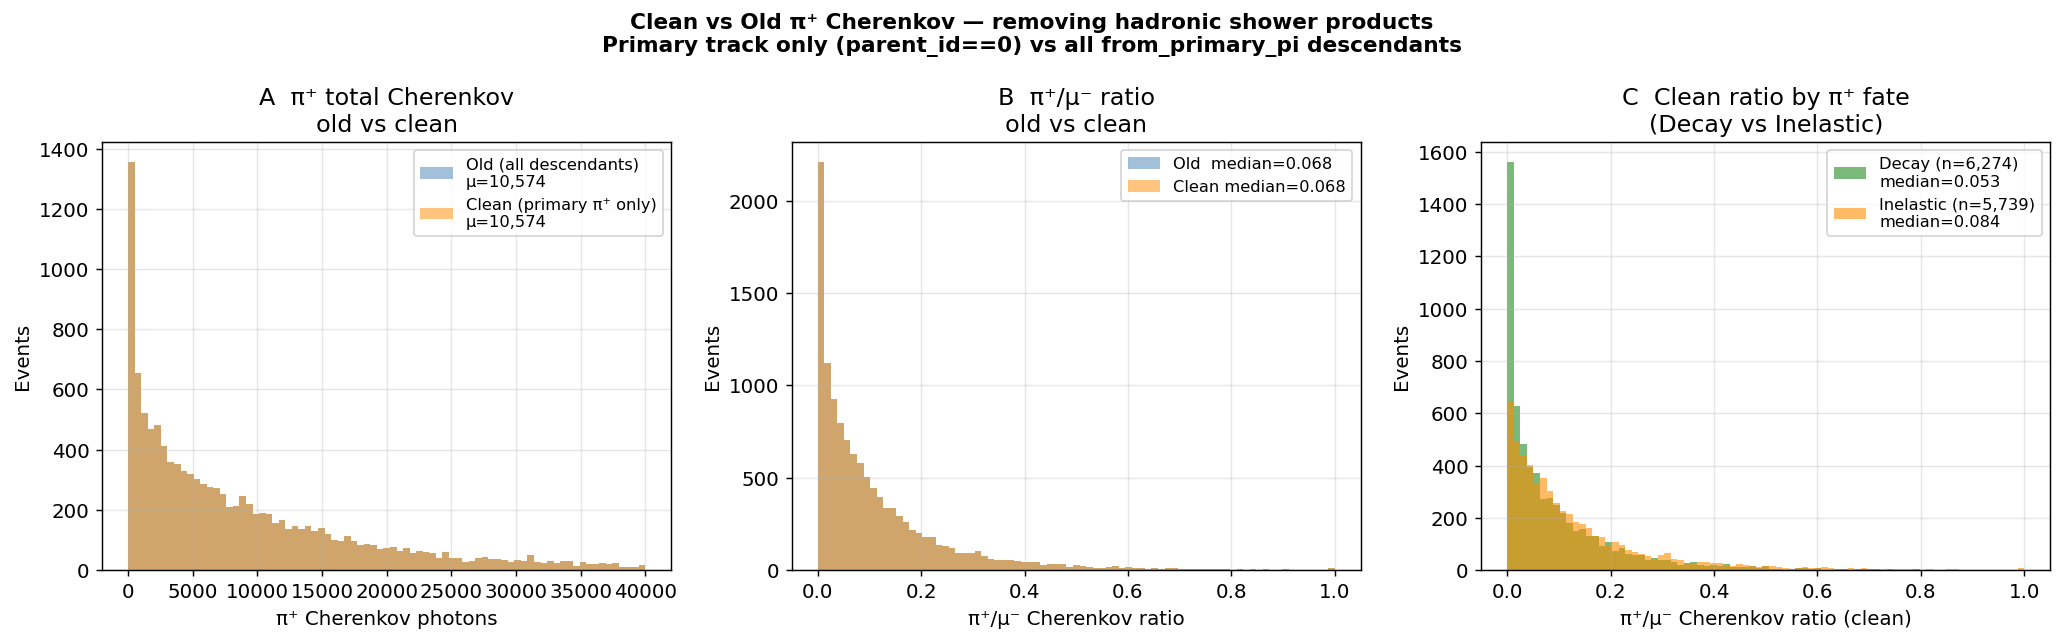

In [72]:
# ── Cell: Recompute clean Cherenkov totals — primary tracks only ──────────────
# Removes hadronic shower products from pi_cher_total by restricting to
# the primary pi+ track itself (parent_id==0), not its descendants.
# Similarly restricts mu_cher_total to the primary mu- track only.
#
# This gives the physically meaningful quantity:
#   "how much Cherenkov light does the primary mu-/pi+ itself produce"
# without contamination from delta rays, hadronic secondaries, or nuclear fragments.



ST_COLS = ['event_id', 'particle', 'parent_id', 'from_primary_pi', 'cher_step']

print("Loading StepTree...")
with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    st = f[st_key].arrays(ST_COLS, library='pd')

st['particle']        = st['particle'].astype(str).str.strip().str.rstrip('\x00')
st['from_primary_pi'] = st['from_primary_pi'].astype(bool)
st['parent_id']       = st['parent_id'].astype(int)
st['cher_step']       = pd.to_numeric(st['cher_step'], errors='coerce').fillna(0.)

print(f"StepTree rows: {len(st):,}")

# ── Primary μ⁻ steps only: the beam muon itself, no daughters ─────────────────
mu_primary = st[(st['particle'] == 'mu-') & (st['parent_id'] == 0)]

# ── Primary π⁺ steps only: the pion itself, no hadronic shower products ───────
# from_primary_pi=True AND parent_id==0 ensures we get only the pi+ track,
# not secondary pions, protons, nuclear fragments, etc. from pi+Inelastic
pi_primary = st[(st['particle'] == 'pi+') &
                (st['from_primary_pi'] == True) &
                (st['parent_id'] == 0)]

# ── Sum Cherenkov per event ───────────────────────────────────────────────────
mu_cher_clean = (mu_primary.groupby('event_id')['cher_step']
                            .sum()
                            .rename('mu_cher_clean'))

pi_cher_clean = (pi_primary.groupby('event_id')['cher_step']
                            .sum()
                            .rename('pi_cher_clean'))

print(f"Events with primary mu- steps : {len(mu_cher_clean):,}")
print(f"Events with primary pi+ steps : {len(pi_cher_clean):,}")

# ── Merge back onto EventTree ─────────────────────────────────────────────────
# Load the EventTree quantities we need for comparison
with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    ev_clean = f[et_key].arrays(
        ['event_id', 'mu_p0', 'pi_p0',
         'mu_cher_total', 'pi_cher_total',
         'mu_track_len',  'pi_track_len',
         'mu_contained',  'pi_final_process'],
        library='pd'
    )

ev_clean['pi_final_process'] = (ev_clean['pi_final_process']
                                  .astype(str).str.strip().str.rstrip('\x00'))
ev_clean['mu_contained']     = ev_clean['mu_contained'].astype(bool)
for c in ['mu_p0','pi_p0','mu_cher_total','pi_cher_total',
          'mu_track_len','pi_track_len']:
    ev_clean[c] = pd.to_numeric(ev_clean[c], errors='coerce')

# track_len mm → cm
if ev_clean['mu_track_len'].max() > 600:
    ev_clean['mu_track_len'] = ev_clean['mu_track_len'] / 10.
if ev_clean['pi_track_len'].max() > 600:
    ev_clean['pi_track_len'] = ev_clean['pi_track_len'] / 10.

ev_clean = (ev_clean
            .set_index('event_id')
            .join(mu_cher_clean, how='left')
            .join(pi_cher_clean, how='left')
            .reset_index())

ev_clean['mu_cher_clean'] = ev_clean['mu_cher_clean'].fillna(0.)
ev_clean['pi_cher_clean'] = ev_clean['pi_cher_clean'].fillna(0.)

# ── Signal filter ─────────────────────────────────────────────────────────────
sig = ev_clean[(ev_clean['mu_p0'] > 0.1185) &
               (~ev_clean['mu_contained'])].copy()

sig['fate'] = sig['pi_final_process'].apply(
    lambda p: 'Decay' if 'Decay' in p else ('Inelastic' if 'Inelastic' in p else 'Other')
)

# Clean ratio
sig['ratio_old']   = sig['pi_cher_total'] / sig['mu_cher_total']
sig['ratio_clean'] = sig['pi_cher_clean'] / sig['mu_cher_clean']

# ── Print comparison ──────────────────────────────────────────────────────────
print()
print('='*65)
print('  CLEAN vs OLD CHERENKOV TOTALS — PRIMARY TRACKS ONLY')
print('='*65)
print(f"\n  μ⁻  mean Cherenkov  old   : {sig['mu_cher_total'].mean():>10,.1f}")
print(f"  μ⁻  mean Cherenkov  clean : {sig['mu_cher_clean'].mean():>10,.1f}")
print(f"  μ⁻  difference            : {(sig['mu_cher_clean'].mean()/sig['mu_cher_total'].mean()-1)*100:>+.1f}%")
print()
print(f"  π⁺  mean Cherenkov  old   : {sig['pi_cher_total'].mean():>10,.1f}")
print(f"  π⁺  mean Cherenkov  clean : {sig['pi_cher_clean'].mean():>10,.1f}")
print(f"  π⁺  difference            : {(sig['pi_cher_clean'].mean()/sig['pi_cher_total'].mean()-1)*100:>+.1f}%")
print()
print(f"  π⁺/μ⁻ ratio  old   median : {sig['ratio_old'].median():.4f}")
print(f"  π⁺/μ⁻ ratio  clean median : {sig['ratio_clean'].median():.4f}")
print(f"  π⁺/μ⁻ ratio  old   mean   : {sig['ratio_old'].mean():.4f}")
print(f"  π⁺/μ⁻ ratio  clean mean   : {sig['ratio_clean'].mean():.4f}")
print()
print('  By fate:')
for fate in ['Decay', 'Inelastic']:
    sub = sig[sig['fate'] == fate]
    print(f"  {fate:10s} (n={len(sub):,})")
    print(f"    π⁺ cher old   : {sub['pi_cher_total'].mean():>10,.1f}")
    print(f"    π⁺ cher clean : {sub['pi_cher_clean'].mean():>10,.1f}")
    print(f"    ratio old     : {sub['ratio_old'].median():.4f}")
    print(f"    ratio clean   : {sub['ratio_clean'].median():.4f}")
    print()

# ── Comparison plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Clean vs Old π⁺ Cherenkov — removing hadronic shower products\n'
             'Primary track only (parent_id==0) vs all from_primary_pi descendants',
             fontsize=12, fontweight='bold')

bins_cher = np.linspace(0, 40000, 80)
bins_ratio = np.linspace(0, 1.0, 80)

# Panel A: π⁺ total Cherenkov old vs clean
ax = axes[0]
ax.hist(sig['pi_cher_total'], bins=bins_cher, alpha=0.5,
        color='steelblue', label=f'Old (all descendants)\nμ={sig["pi_cher_total"].mean():,.0f}')
ax.hist(sig['pi_cher_clean'], bins=bins_cher, alpha=0.5,
        color='darkorange', label=f'Clean (primary π⁺ only)\nμ={sig["pi_cher_clean"].mean():,.0f}')
ax.set_xlabel('π⁺ Cherenkov photons')
ax.set_ylabel('Events')
ax.set_title('A  π⁺ total Cherenkov\nold vs clean')
ax.legend(fontsize=9)

# Panel B: ratio old vs clean
ax = axes[1]
ax.hist(sig['ratio_old'].clip(upper=1.0),   bins=bins_ratio, alpha=0.5,
        color='steelblue', label=f'Old  median={sig["ratio_old"].median():.3f}')
ax.hist(sig['ratio_clean'].clip(upper=1.0), bins=bins_ratio, alpha=0.5,
        color='darkorange', label=f'Clean median={sig["ratio_clean"].median():.3f}')
ax.set_xlabel('π⁺/μ⁻ Cherenkov ratio')
ax.set_ylabel('Events')
ax.set_title('B  π⁺/μ⁻ ratio\nold vs clean')
ax.legend(fontsize=9)

# Panel C: ratio by fate, clean only
ax = axes[2]
for fate, color in [('Decay', 'forestgreen'), ('Inelastic', 'darkorange')]:
    sub = sig[sig['fate'] == fate]
    ax.hist(sub['ratio_clean'].clip(upper=1.0), bins=bins_ratio,
            alpha=0.6, color=color,
            label=f'{fate} (n={len(sub):,})\nmedian={sub["ratio_clean"].median():.3f}')
ax.set_xlabel('π⁺/μ⁻ Cherenkov ratio (clean)')
ax.set_ylabel('Events')
ax.set_title('C  Clean ratio by π⁺ fate\n(Decay vs Inelastic)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('cherenkov_clean_vs_old.png', dpi=150, bbox_inches='tight')
plt.show()

Stopping muons  (mu_contained=True)  : 17,971  (59.9%)
Punch-through   (mu_contained=False) : 12,029  (40.1%)

Computing track-averaged Frank–Tamm for μ⁻ (~5 s)...
Done.


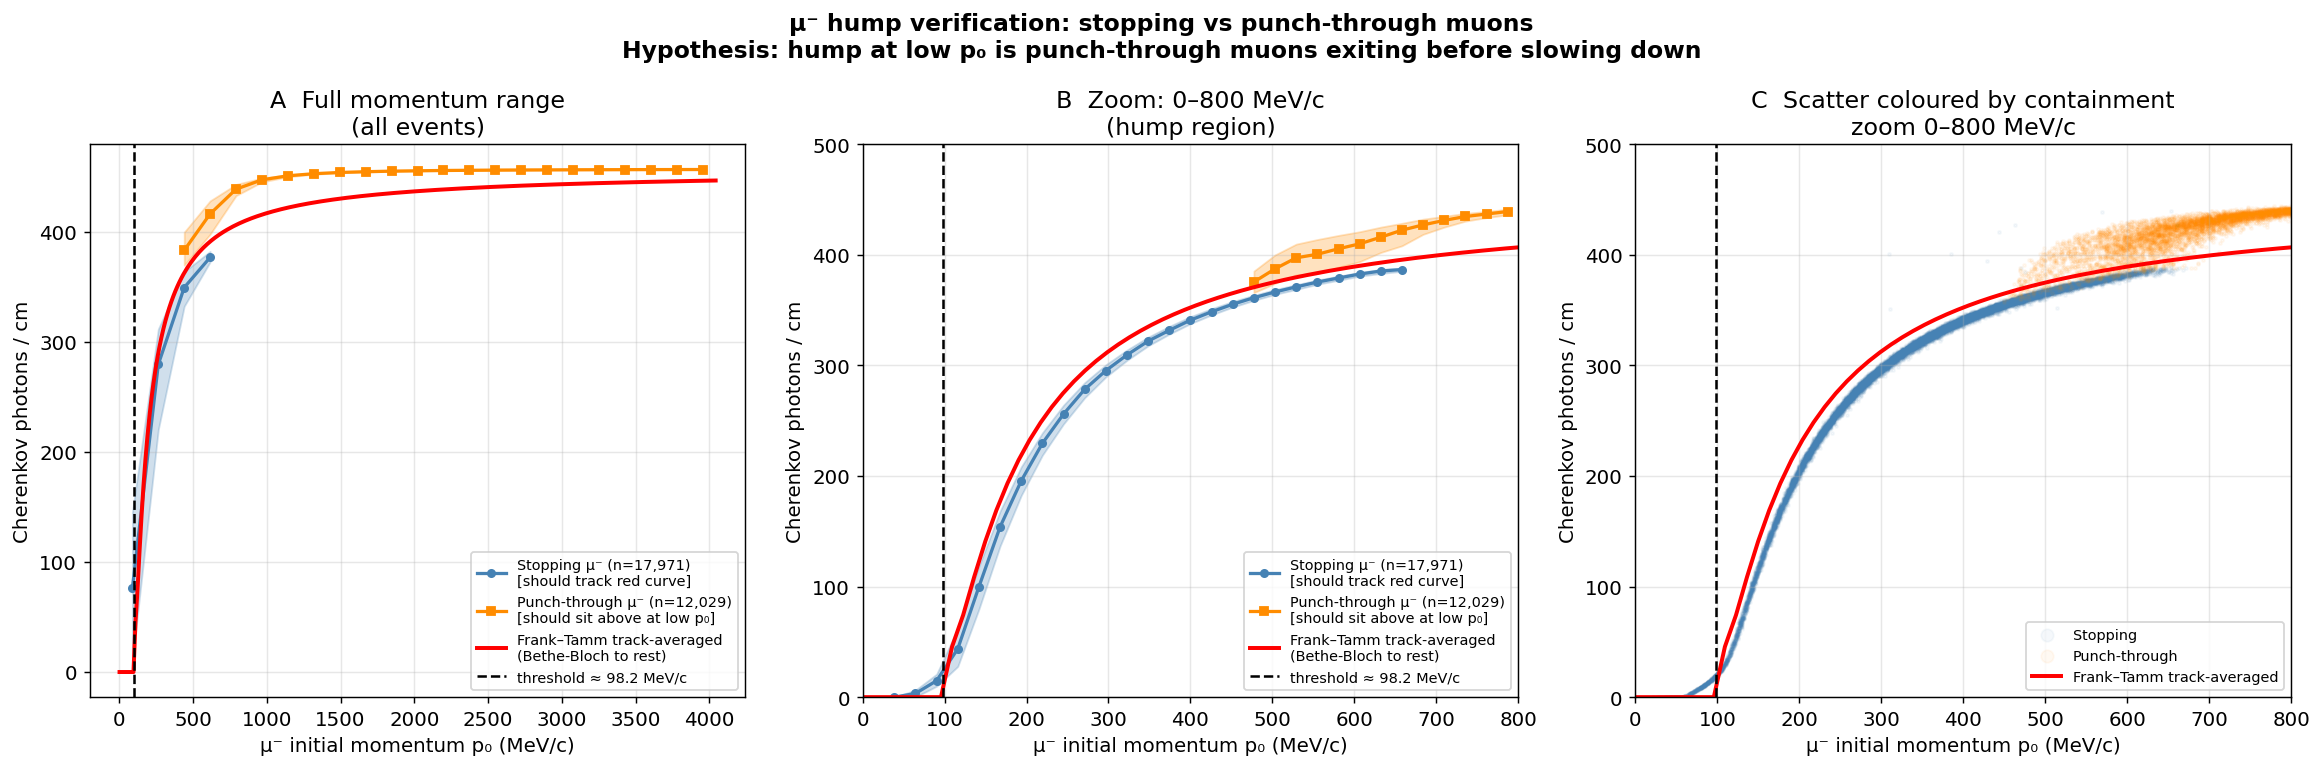


  μ⁻ HUMP VERIFICATION SUMMARY  (p₀ < 300 MeV/c)

  Stopping  muons  n        : 6,979
  Stopping  median cher/cm  : 225.3 ph/cm
  Punch-through n           : 0
  Punch-through median cher : nan ph/cm

  Theory at p₀=200 MeV/c:
    Track-averaged (to rest): 227.8 ph/cm  ← red curve
    Instantaneous dN/dx     : 340.8 ph/cm  ← what punch-through sees

  Verdict:
  ✗ NOT CONFIRMED: populations similar — hump has different origin
    Check pi+Inelastic contamination in mu_cher_total instead


In [73]:
# ── Cell: μ⁻ hump verification — stopping vs punch-through muons ──────────────
# Tests the hypothesis that the low-momentum hump in Panel A is caused by
# punch-through muons (mu_contained=False) exiting before losing their
# high-β track, making cher_total/track_len sit above the stopping prediction.
#
# Prediction:
#   - mu_contained=True  (stopping) → median tracks red curve cleanly at low p₀
#   - mu_contained=False (punch-through) → median sits above red curve at low p₀
#   - The hump disappears when restricted to stopping muons only

# ─── Load EventTree ───────────────────────────────────────────────────────────
with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    ev_hump = f[et_key].arrays(
        ['event_id', 'mu_p0', 'mu_cher_total',
         'mu_track_len', 'mu_contained'],
        library='pd'
    )

ev_hump['mu_contained'] = ev_hump['mu_contained'].astype(bool)
for c in ['mu_p0', 'mu_cher_total', 'mu_track_len']:
    ev_hump[c] = pd.to_numeric(ev_hump[c], errors='coerce')

if ev_hump['mu_track_len'].max() > 600:
    ev_hump['mu_track_len'] = ev_hump['mu_track_len'] / 10.

ev_hump['mu_cher_per_cm'] = np.where(
    ev_hump['mu_track_len'] > 0,
    ev_hump['mu_cher_total'] / ev_hump['mu_track_len'],
    np.nan
)

# ─── Split by containment ─────────────────────────────────────────────────────
stop_mask  = np.isfinite(ev_hump['mu_p0']) & np.isfinite(ev_hump['mu_cher_per_cm']) \
             & ev_hump['mu_contained']
punch_mask = np.isfinite(ev_hump['mu_p0']) & np.isfinite(ev_hump['mu_cher_per_cm']) \
             & ~ev_hump['mu_contained']

n_stop  = stop_mask.sum()
n_punch = punch_mask.sum()
print(f"Stopping muons  (mu_contained=True)  : {n_stop:,}  ({100*n_stop/(n_stop+n_punch):.1f}%)")
print(f"Punch-through   (mu_contained=False) : {n_punch:,}  ({100*n_punch/(n_stop+n_punch):.1f}%)")

# ─── Theory curve (same as validation cell) ───────────────────────────────────
pmax_mu = ev_hump['mu_p0'].quantile(0.995)
p_grid  = np.linspace(0.001, pmax_mu * 1.05, 300)

print("\nComputing track-averaged Frank–Tamm for μ⁻ (~5 s)...")
mu_ft = frank_tamm_track_averaged(p_grid, M_MU)
print("Done.")

PTHR_MU, _ = effective_threshold_momentum(M_MU)

# ─── Binned quantiles for each population ─────────────────────────────────────
# Use finer bins at low momentum where the hump lives
p_bins_low  = np.linspace(0.0,  0.8, 32)   # 0–800 MeV/c fine
p_bins_full = np.linspace(0.0, pmax_mu*1.05, 24)

def bq(x, y, bins):
    return binned_quantiles(x, y, bins, min_count=20)

stop_pc,  stop_q,  _ = bq(ev_hump.loc[stop_mask,  'mu_p0'],
                           ev_hump.loc[stop_mask,  'mu_cher_per_cm'], p_bins_full)
punch_pc, punch_q, _ = bq(ev_hump.loc[punch_mask, 'mu_p0'],
                           ev_hump.loc[punch_mask, 'mu_cher_per_cm'], p_bins_full)

# Fine-binned for zoom panel
stop_pc_z,  stop_q_z,  _ = bq(ev_hump.loc[stop_mask,  'mu_p0'],
                               ev_hump.loc[stop_mask,  'mu_cher_per_cm'], p_bins_low)
punch_pc_z, punch_q_z, _ = bq(ev_hump.loc[punch_mask, 'mu_p0'],
                               ev_hump.loc[punch_mask, 'mu_cher_per_cm'], p_bins_low)

# ─── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'μ⁻ hump verification: stopping vs punch-through muons\n'
    'Hypothesis: hump at low p₀ is punch-through muons exiting before slowing down',
    fontsize=13, fontweight='bold'
)

def draw_containment_panel(ax, pc_s, q_s, pc_p, q_p, xlim=None, title=''):
    # Stopping — should sit ON red curve
    ax.fill_between(pc_s*1000, q_s[0.16], q_s[0.84],
                    alpha=0.25, color='steelblue')
    ax.plot(pc_s*1000, q_s[0.50],
            'o-', ms=4, lw=1.8, color='steelblue',
            label=f'Stopping μ⁻ (n={n_stop:,})\n[should track red curve]')

    # Punch-through — should sit ABOVE red curve at low p₀
    ax.fill_between(pc_p*1000, q_p[0.16], q_p[0.84],
                    alpha=0.25, color='darkorange')
    ax.plot(pc_p*1000, q_p[0.50],
            's-', ms=4, lw=1.8, color='darkorange',
            label=f'Punch-through μ⁻ (n={n_punch:,})\n[should sit above at low p₀]')

    # Theory
    ax.plot(p_grid*1000, mu_ft,
            color='red', lw=2.2, label='Frank–Tamm track-averaged\n(Bethe-Bloch to rest)')
    ax.axvline(PTHR_MU*1000, color='black', ls='--', lw=1.4,
               label=f'threshold ≈ {PTHR_MU*1000:.1f} MeV/c')

    if xlim:
        ax.set_xlim(xlim)
        # Zoom y-range to where the hump lives
        ax.set_ylim(0, 500)

    ax.set_xlabel('μ⁻ initial momentum p₀ (MeV/c)')
    ax.set_ylabel('Cherenkov photons / cm')
    ax.set_title(title)
    ax.legend(fontsize=8)

# Panel A: full momentum range
draw_containment_panel(
    axes[0], stop_pc, stop_q, punch_pc, punch_q,
    title='A  Full momentum range\n(all events)'
)

# Panel B: zoom into low-momentum hump region 0–800 MeV/c
draw_containment_panel(
    axes[1], stop_pc_z, stop_q_z, punch_pc_z, punch_q_z,
    xlim=(0, 800),
    title='B  Zoom: 0–800 MeV/c\n(hump region)'
)

# Panel C: scatter plot coloured by containment — shows the hump population directly
ax = axes[2]
ax.scatter(
    ev_hump.loc[stop_mask,  'mu_p0'] * 1000,
    ev_hump.loc[stop_mask,  'mu_cher_per_cm'],
    s=3, alpha=0.05, color='steelblue', label='Stopping'
)
ax.scatter(
    ev_hump.loc[punch_mask, 'mu_p0'] * 1000,
    ev_hump.loc[punch_mask, 'mu_cher_per_cm'],
    s=3, alpha=0.05, color='darkorange', label='Punch-through'
)
ax.plot(p_grid*1000, mu_ft, color='red', lw=2.2,
        label='Frank–Tamm track-averaged')
ax.axvline(PTHR_MU*1000, color='black', ls='--', lw=1.4)
ax.set_xlim(0, 800)
ax.set_ylim(0, 500)
ax.set_xlabel('μ⁻ initial momentum p₀ (MeV/c)')
ax.set_ylabel('Cherenkov photons / cm')
ax.set_title('C  Scatter coloured by containment\nzoom 0–800 MeV/c')
ax.legend(fontsize=8, markerscale=4)

plt.tight_layout()
plt.savefig('mu_hump_verification.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary ──────────────────────────────────────────────────────────────────
# Check median cher/cm at low p₀ for each population
low_p_mask = ev_hump['mu_p0'] < 0.3   # < 300 MeV/c — hump region

stop_low  = ev_hump[stop_mask  & low_p_mask]['mu_cher_per_cm']
punch_low = ev_hump[punch_mask & low_p_mask]['mu_cher_per_cm']

# Theory prediction at 200 MeV/c
ft_200 = frank_tamm_track_averaged(np.array([0.200]), M_MU)[0]
inst_200 = frank_tamm_per_cm_band(np.array([0.200]), M_MU)[0]

print()
print('='*60)
print('  μ⁻ HUMP VERIFICATION SUMMARY  (p₀ < 300 MeV/c)')
print('='*60)
print(f"\n  Stopping  muons  n        : {len(stop_low):,}")
print(f"  Stopping  median cher/cm  : {stop_low.median():.1f} ph/cm")
print(f"  Punch-through n           : {len(punch_low):,}")
print(f"  Punch-through median cher : {punch_low.median():.1f} ph/cm")
print()
print(f"  Theory at p₀=200 MeV/c:")
print(f"    Track-averaged (to rest): {ft_200:.1f} ph/cm  ← red curve")
print(f"    Instantaneous dN/dx     : {inst_200:.1f} ph/cm  ← what punch-through sees")
print()
print(f"  Verdict:")
if punch_low.median() > stop_low.median() * 1.1:
    print("  ✓ CONFIRMED: punch-through median > stopping median at low p₀")
    print("    The hump IS the punch-through population exiting at high β")
else:
    print("  ✗ NOT CONFIRMED: populations similar — hump has different origin")
    print("    Check pi+Inelastic contamination in mu_cher_total instead")

Loading StepTree for inelastic inventory...
StepTree rows loaded: 32,267,516

Inelastic signal events: 5,739
Secondary tracks from inelastic interactions: 1,505,449

─── SECONDARY PARTICLE SPECIES (first step, inelastic events) ───
e-            1303100
gamma           87101
proton          55066
O16             16979
neutron         10024
e+               5314
alpha            4090
pi+              3333
C12              2376
nu_mu            2343
anti_nu_mu       2343
mu+              2341
nu_e             2341
deuteron         1615
N15              1549
N14              1082
Be8               791
pi0               695
O15               550
C13               490
C14               321
triton            205
B11               192
O14               176
B10               170
He3               165
C11               164
N13               151
pi-                99
Be10               40
Li7                33
Be9                30
O18                29
C10                26
Be7                2

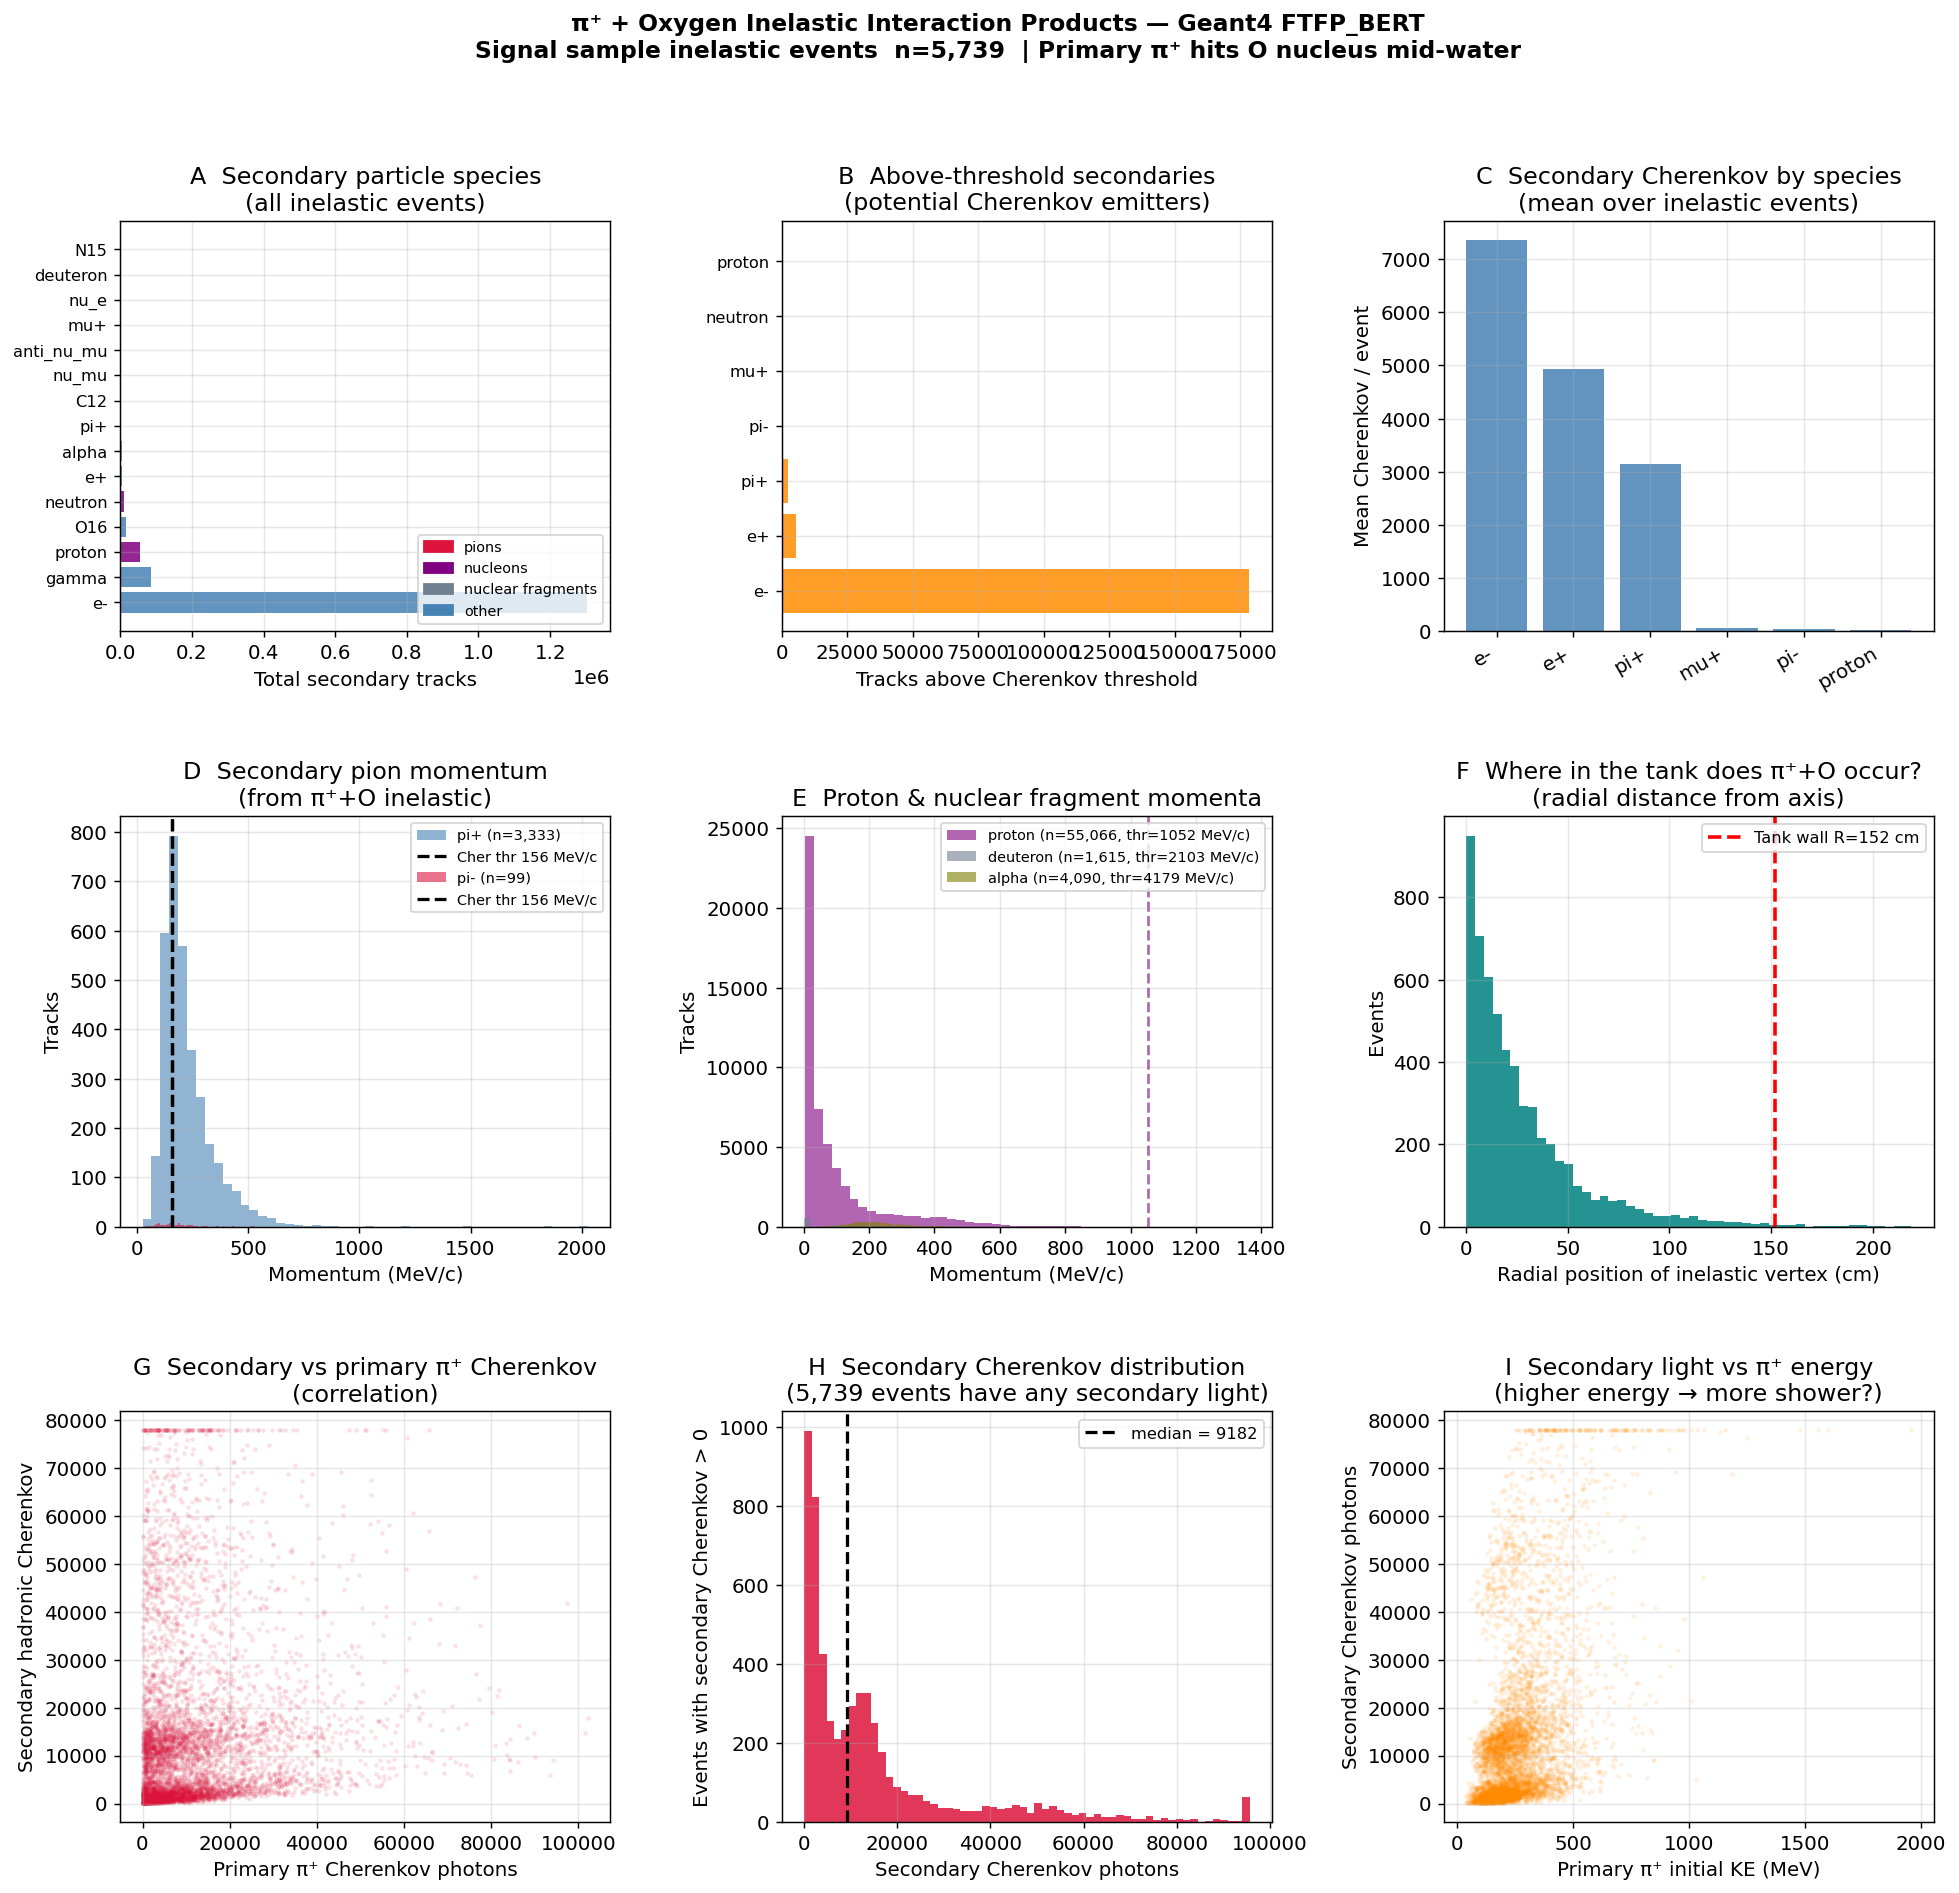


  INELASTIC π⁺+O HADRONIC INVENTORY SUMMARY

  Inelastic signal events          : 5,739

  Secondary particle species seen  : 58
  Total secondary tracks           : 1,505,449
  Mean secondaries per event       : 262.3

  Above Cherenkov threshold:
    e-           : 178,305 tracks
    e+           : 5,276 tracks
    pi+          : 2,298 tracks
    pi-          : 50 tracks
    mu+          : 42 tracks
    neutron      : 5 tracks
    proton       : 2 tracks

  Mean secondary Cherenkov/event   : 15,564.5
  Mean primary μ⁻ Cherenkov/event  : 93,823.4
  Mean primary π⁺ Cherenkov/event  : 12,185.2
  Secondary / μ⁻ fraction          : 16.59%
  Secondary / π⁺ fraction          : 127.73%

  Events with ANY secondary Cher   : 5,739 (100.0%)

  Interpretation:
  These are real Geant4 hadronic physics products from π⁺+O16
  interactions in water. NOT from the original CC-Delta nuclear
  vertex (which was never simulated). In real ANNIE data you
  would also have the Δ decay vertex products on to

In [74]:
# ── Cell: Inelastic π⁺ hadronic activity inventory ───────────────────────────
# Isolates events where the primary π⁺ underwent pi+Inelastic in water
# and documents everything Geant4 produced from that interaction:
#   - secondary pions (pi+, pi-, pi0)
#   - recoil/ejected protons and neutrons
#   - nuclear fragments (deuteron, triton, alpha, heavier ions)
#   - their Cherenkov yields and momenta
#
# These events are in your data but represent incomplete CC-pi+ events —
# no Michel tag, hadronic debris, and should be treated as a background
# category in any real analysis.
#
# Note: this is NOT the full CC-Delta nuclear vertex — that was never
# simulated. This is purely what happens when the free π⁺ track hits
# oxygen mid-water in Geant4 with FTFP_BERT.

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("Loading StepTree for inelastic inventory...")

ST_COLS = ['event_id', 'particle', 'parent_id', 'track_id',
           'from_primary_pi', 'cher_step', 'p_mag', 'KE',
           'x', 'y', 'z', 'time', 'process', 'step_num']

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    st_inel = f[st_key].arrays(ST_COLS, library='pd')

st_inel['particle']        = (st_inel['particle'].astype(str)
                                .str.strip().str.rstrip('\x00'))
st_inel['process']         = (st_inel['process'].astype(str)
                                .str.strip().str.rstrip('\x00'))
st_inel['from_primary_pi'] = st_inel['from_primary_pi'].astype(bool)
st_inel['parent_id']       = st_inel['parent_id'].astype(int)
st_inel['track_id']        = st_inel['track_id'].astype(int)
for c in ['cher_step', 'p_mag', 'KE']:
    st_inel[c] = pd.to_numeric(st_inel[c], errors='coerce').fillna(0.)

print(f"StepTree rows loaded: {len(st_inel):,}")

# ─── Get inelastic signal events ─────────────────────────────────────────────
with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    ev_inel = f[et_key].arrays(
        ['event_id', 'mu_p0', 'pi_p0', 'mu_contained',
         'pi_final_process', 'mu_cher_total', 'pi_cher_total',
         'pi_x_end', 'pi_y_end', 'pi_z_end', 'pi_KE0'],
        library='pd'
    )

ev_inel['mu_contained']     = ev_inel['mu_contained'].astype(bool)
ev_inel['pi_final_process'] = (ev_inel['pi_final_process']
                                 .astype(str).str.strip().str.rstrip('\x00'))
for c in ['mu_p0', 'pi_p0', 'mu_cher_total', 'pi_cher_total',
          'pi_x_end', 'pi_y_end', 'pi_z_end', 'pi_KE0']:
    ev_inel[c] = pd.to_numeric(ev_inel[c], errors='coerce')

# Signal filter + inelastic fate only
sig_inel = ev_inel[
    (ev_inel['mu_p0'] > 0.1185) &
    (~ev_inel['mu_contained']) &
    ev_inel['pi_final_process'].str.contains('Inelastic', na=False)
].copy()

inel_ids = set(sig_inel['event_id'].values)
print(f"\nInelastic signal events: {len(sig_inel):,}")

# ─── Isolate steps from inelastic events only ─────────────────────────────────
st_ev = st_inel[st_inel['event_id'].isin(inel_ids)].copy()

# ─── Categorise particles ─────────────────────────────────────────────────────
# Primary tracks
is_prim_mu  = (st_ev['particle'] == 'mu-')  & (st_ev['parent_id'] == 0)
is_prim_pi  = (st_ev['particle'] == 'pi+')  & (st_ev['parent_id'] == 0)

# Hadronic secondaries — children of the inelastic interaction
# (parent is the primary pi+ track, parent_id != 0, from_primary_pi=True)
is_had_secondary = st_ev['from_primary_pi'] & ~is_prim_pi

# Get first step per track (= initial state of each secondary)
first_steps = (st_ev[is_had_secondary]
               .sort_values('step_num')
               .groupby(['event_id', 'track_id'])
               .first()
               .reset_index())

print(f"Secondary tracks from inelastic interactions: {len(first_steps):,}")
print()

# ─── Particle type inventory ──────────────────────────────────────────────────
species_counts = first_steps['particle'].value_counts()
print("─── SECONDARY PARTICLE SPECIES (first step, inelastic events) ───")
print(species_counts.to_string())
print()

# Cherenkov threshold
N_WATER   = 1.34
def p_threshold(mass_GeV):
    return mass_GeV / np.sqrt(N_WATER**2 - 1)

# Tag which secondaries are above Cherenkov threshold
mass_map = {
    'pi+'     : 0.13957, 'pi-': 0.13957,
    'proton'  : 0.93827,
    'neutron' : 0.93957,
    'deuteron': 1.87561,
    'triton'  : 2.80892,
    'alpha'   : 3.72742,
    'mu+'     : 0.10566, 'mu-': 0.10566,
    'e+'      : 0.000511,'e-' : 0.000511,
}
first_steps['mass_GeV'] = first_steps['particle'].map(mass_map).fillna(1.0)
first_steps['p_thr']    = first_steps['mass_GeV'].apply(p_threshold)
first_steps['above_thr']= first_steps['p_mag'] > first_steps['p_thr']

above_thr = first_steps[first_steps['above_thr']]
print("─── ABOVE CHERENKOV THRESHOLD ───")
thr_counts = above_thr['particle'].value_counts()
print(thr_counts.to_string())
print()

# ─── Per-event Cherenkov from secondaries ─────────────────────────────────────
# All secondary Cherenkov (from_primary_pi, not the primary pi+ itself)
sec_cher = (st_ev[is_had_secondary]
            .groupby('event_id')['cher_step']
            .sum()
            .rename('sec_cher'))

# By particle type
def cher_by_species(particle_name):
    mask = is_had_secondary & (st_ev['particle'] == particle_name)
    return (st_ev[mask].groupby('event_id')['cher_step']
                       .sum()
                       .rename(f'cher_{particle_name}'))

species_to_track = ['pi+', 'pi-', 'proton', 'e-', 'e+',
                    'mu+', 'deuteron', 'alpha', 'gamma']
cher_cols = [cher_by_species(s) for s in species_to_track]

sig_inel = (sig_inel.set_index('event_id')
                    .join(sec_cher, how='left')
                    .join(pd.concat(cher_cols, axis=1), how='left')
                    .reset_index())

for col in ['sec_cher'] + [f'cher_{s}' for s in species_to_track]:
    if col in sig_inel.columns:
        sig_inel[col] = sig_inel[col].fillna(0.)

# ─── Interaction vertex position ─────────────────────────────────────────────
# pi_x/y/z_end is where the inelastic interaction occurred
sig_inel['pi_r_end'] = np.sqrt(
    sig_inel['pi_x_end']**2 + sig_inel['pi_z_end']**2
) / 10.  # mm → cm

# ─── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    f'π⁺ + Oxygen Inelastic Interaction Products — Geant4 FTFP_BERT\n'
    f'Signal sample inelastic events  n={len(sig_inel):,}  '
    f'| Primary π⁺ hits O nucleus mid-water',
    fontsize=13, fontweight='bold'
)

# ── Panel A: Secondary species counts ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
top_species = species_counts.head(15)
colors_sp = ['crimson' if p in ('pi+','pi-','pi0') else
             'purple'  if p in ('proton','neutron') else
             'slategrey' if p in ('deuteron','triton','alpha','He3') else
             'steelblue'
             for p in top_species.index]
ax.barh(range(len(top_species)), top_species.values,
        color=colors_sp, alpha=0.85)
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels(top_species.index.tolist(), fontsize=9)
ax.set_xlabel('Total secondary tracks')
ax.set_title('A  Secondary particle species\n(all inelastic events)')
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='crimson',   label='pions'),
    Patch(color='purple',    label='nucleons'),
    Patch(color='slategrey', label='nuclear fragments'),
    Patch(color='steelblue', label='other'),
], fontsize=8, loc='lower right')

# ── Panel B: Above-threshold species ─────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
if len(thr_counts) > 0:
    ax.barh(range(len(thr_counts)), thr_counts.values,
            color='darkorange', alpha=0.85)
    ax.set_yticks(range(len(thr_counts)))
    ax.set_yticklabels(thr_counts.index.tolist(), fontsize=9)
    ax.set_xlabel('Tracks above Cherenkov threshold')
    ax.set_title('B  Above-threshold secondaries\n(potential Cherenkov emitters)')
else:
    ax.text(0.5, 0.5, 'None above threshold',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('B  Above-threshold secondaries')

# ── Panel C: Secondary Cherenkov breakdown ───────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
cher_means = {}
for s in species_to_track:
    col = f'cher_{s}'
    if col in sig_inel.columns and sig_inel[col].mean() > 0.5:
        cher_means[s] = sig_inel[col].mean()
cher_means = dict(sorted(cher_means.items(), key=lambda x: x[1], reverse=True))
if cher_means:
    ax.bar(range(len(cher_means)), list(cher_means.values()),
           color='steelblue', alpha=0.85)
    ax.set_xticks(range(len(cher_means)))
    ax.set_xticklabels(list(cher_means.keys()), rotation=30, ha='right')
    ax.set_ylabel('Mean Cherenkov / event')
    ax.set_title('C  Secondary Cherenkov by species\n(mean over inelastic events)')

# ── Panel D: Secondary pion momentum spectrum ─────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
for pname, color in [('pi+', 'steelblue'), ('pi-', 'crimson')]:
    sec_pi = first_steps[first_steps['particle'] == pname]
    if len(sec_pi) > 0:
        p_thr_pi = p_threshold(0.13957)
        ax.hist(sec_pi['p_mag'] * 1000, bins=50, alpha=0.6,
                color=color, label=f'{pname} (n={len(sec_pi):,})')
        ax.axvline(p_thr_pi * 1000, color='black', lw=1.8,
                   ls='--', label=f'Cher thr {p_thr_pi*1000:.0f} MeV/c')
ax.set_xlabel('Momentum (MeV/c)')
ax.set_ylabel('Tracks')
ax.set_title('D  Secondary pion momentum\n(from π⁺+O inelastic)')
ax.legend(fontsize=8)

# ── Panel E: Proton & nuclear fragment momenta ────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
for pname, color, mass in [('proton',   'purple',    0.93827),
                             ('deuteron', 'slategrey', 1.87561),
                             ('alpha',    'olive',     3.72742)]:
    sec_p = first_steps[first_steps['particle'] == pname]
    if len(sec_p) > 0:
        p_thr = p_threshold(mass)
        ax.hist(sec_p['p_mag'] * 1000, bins=50, alpha=0.6,
                color=color,
                label=f'{pname} (n={len(sec_p):,}, thr={p_thr*1000:.0f} MeV/c)')
ax.axvline(p_threshold(0.93827) * 1000, color='purple',
           lw=1.5, ls='--', alpha=0.6)
ax.set_xlabel('Momentum (MeV/c)')
ax.set_ylabel('Tracks')
ax.set_title('E  Proton & nuclear fragment momenta')
ax.legend(fontsize=8)

# ── Panel F: Interaction vertex radial position ───────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.hist(sig_inel['pi_r_end'].dropna(), bins=50,
        color='teal', alpha=0.85)
ax.axvline(152., color='red', lw=2, ls='--', label='Tank wall R=152 cm')
ax.set_xlabel('Radial position of inelastic vertex (cm)')
ax.set_ylabel('Events')
ax.set_title('F  Where in the tank does π⁺+O occur?\n(radial distance from axis)')
ax.legend(fontsize=9)

# ── Panel G: Secondary Cherenkov vs primary π⁺ Cherenkov ─────────────────────
ax = fig.add_subplot(gs[2, 0])
ax.scatter(sig_inel['pi_cher_total'],
           sig_inel['sec_cher'].clip(
               upper=sig_inel['sec_cher'].quantile(0.98)),
           s=3, alpha=0.08, color='crimson')
ax.set_xlabel('Primary π⁺ Cherenkov photons')
ax.set_ylabel('Secondary hadronic Cherenkov')
ax.set_title('G  Secondary vs primary π⁺ Cherenkov\n(correlation)')

# ── Panel H: Total secondary Cherenkov distribution ──────────────────────────
ax = fig.add_subplot(gs[2, 1])
sec_nonzero = sig_inel['sec_cher'][sig_inel['sec_cher'] > 0]
ax.hist(sec_nonzero.clip(upper=sec_nonzero.quantile(0.99)),
        bins=60, color='crimson', alpha=0.85)
ax.axvline(sec_nonzero.median(), color='black', lw=1.8, ls='--',
           label=f'median = {sec_nonzero.median():.0f}')
ax.set_xlabel('Secondary Cherenkov photons')
ax.set_ylabel('Events with secondary Cherenkov > 0')
ax.set_title(f'H  Secondary Cherenkov distribution\n'
             f'({(sig_inel["sec_cher"]>0).sum():,} events have any secondary light)')
ax.legend(fontsize=9)

# ── Panel I: π⁺ KE at interaction vs secondary light ─────────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.scatter(sig_inel['pi_KE0'] * 1000,
           sig_inel['sec_cher'].clip(
               upper=sig_inel['sec_cher'].quantile(0.98)),
           s=3, alpha=0.08, color='darkorange')
ax.set_xlabel('Primary π⁺ initial KE (MeV)')
ax.set_ylabel('Secondary Cherenkov photons')
ax.set_title('I  Secondary light vs π⁺ energy\n(higher energy → more shower?)')

plt.savefig('inelastic_hadronic_inventory.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary ──────────────────────────────────────────────────────────────────
print()
print('='*65)
print('  INELASTIC π⁺+O HADRONIC INVENTORY SUMMARY')
print('='*65)
print(f"\n  Inelastic signal events          : {len(sig_inel):,}")
print(f"\n  Secondary particle species seen  : {len(species_counts):,}")
print(f"  Total secondary tracks           : {len(first_steps):,}")
print(f"  Mean secondaries per event       : {len(first_steps)/len(sig_inel):.1f}")
print()
print(f"  Above Cherenkov threshold:")
for p, n in thr_counts.items():
    frac = n / len(first_steps[first_steps['particle']==p]) if len(first_steps[first_steps['particle']==p])>0 else 0
    print(f"    {p:12s} : {n:,} tracks")
print()
sec_cher_mean = sig_inel['sec_cher'].mean()
mu_mean_inel  = sig_inel['mu_cher_total'].mean()
pi_mean_inel  = sig_inel['pi_cher_total'].mean()
print(f"  Mean secondary Cherenkov/event   : {sec_cher_mean:,.1f}")
print(f"  Mean primary μ⁻ Cherenkov/event  : {mu_mean_inel:,.1f}")
print(f"  Mean primary π⁺ Cherenkov/event  : {pi_mean_inel:,.1f}")
print(f"  Secondary / μ⁻ fraction          : {sec_cher_mean/mu_mean_inel*100:.2f}%")
print(f"  Secondary / π⁺ fraction          : {sec_cher_mean/pi_mean_inel*100:.2f}%")
print()
print(f"  Events with ANY secondary Cher   : "
      f"{(sig_inel['sec_cher']>0).sum():,} "
      f"({100*(sig_inel['sec_cher']>0).mean():.1f}%)")
print()
print("  Interpretation:")
print("  These are real Geant4 hadronic physics products from π⁺+O16")
print("  interactions in water. NOT from the original CC-Delta nuclear")
print("  vertex (which was never simulated). In real ANNIE data you")
print("  would also have the Δ decay vertex products on top of this.")

Known β⁺ emitters from O16 spallation:
Isotope            t½    β⁺ endpoint Concern
────────────────────────────────────────────────────────────
  N12           11 ms      16.32 MeV    ⚠ MICHEL-LIKE
  B8           770 ms      13.70 MeV    ⚠ MICHEL-LIKE
  C10          19.3 s       1.47 MeV    ⚠ MICHEL-LIKE
  F17         1.1 min       1.74 MeV    ⚠ MICHEL-LIKE
  O14         1.2 min       1.81 MeV    ⚠ MICHEL-LIKE
  O15         2.0 min       1.72 MeV    ⚠ MICHEL-LIKE
  N13         9.9 min       1.19 MeV    ⚠ MICHEL-LIKE
  C11        20.4 min       0.96 MeV    ⚠ MICHEL-LIKE

Loading StepTree for isotope inventory...
─── ISOTOPE PRODUCTION RATES (inelastic signal events) ───
Isotope    n_tracks   n_events   evt_frac    mean_KE type
─────────────────────────────────────────────────────────────────
  O16          4,280       4,280       0.746       0.4 MeV  stable/long
  C12          1,994       1,994       0.347       3.4 MeV  stable/long
  N15          1,425       1,425       0.248       1.

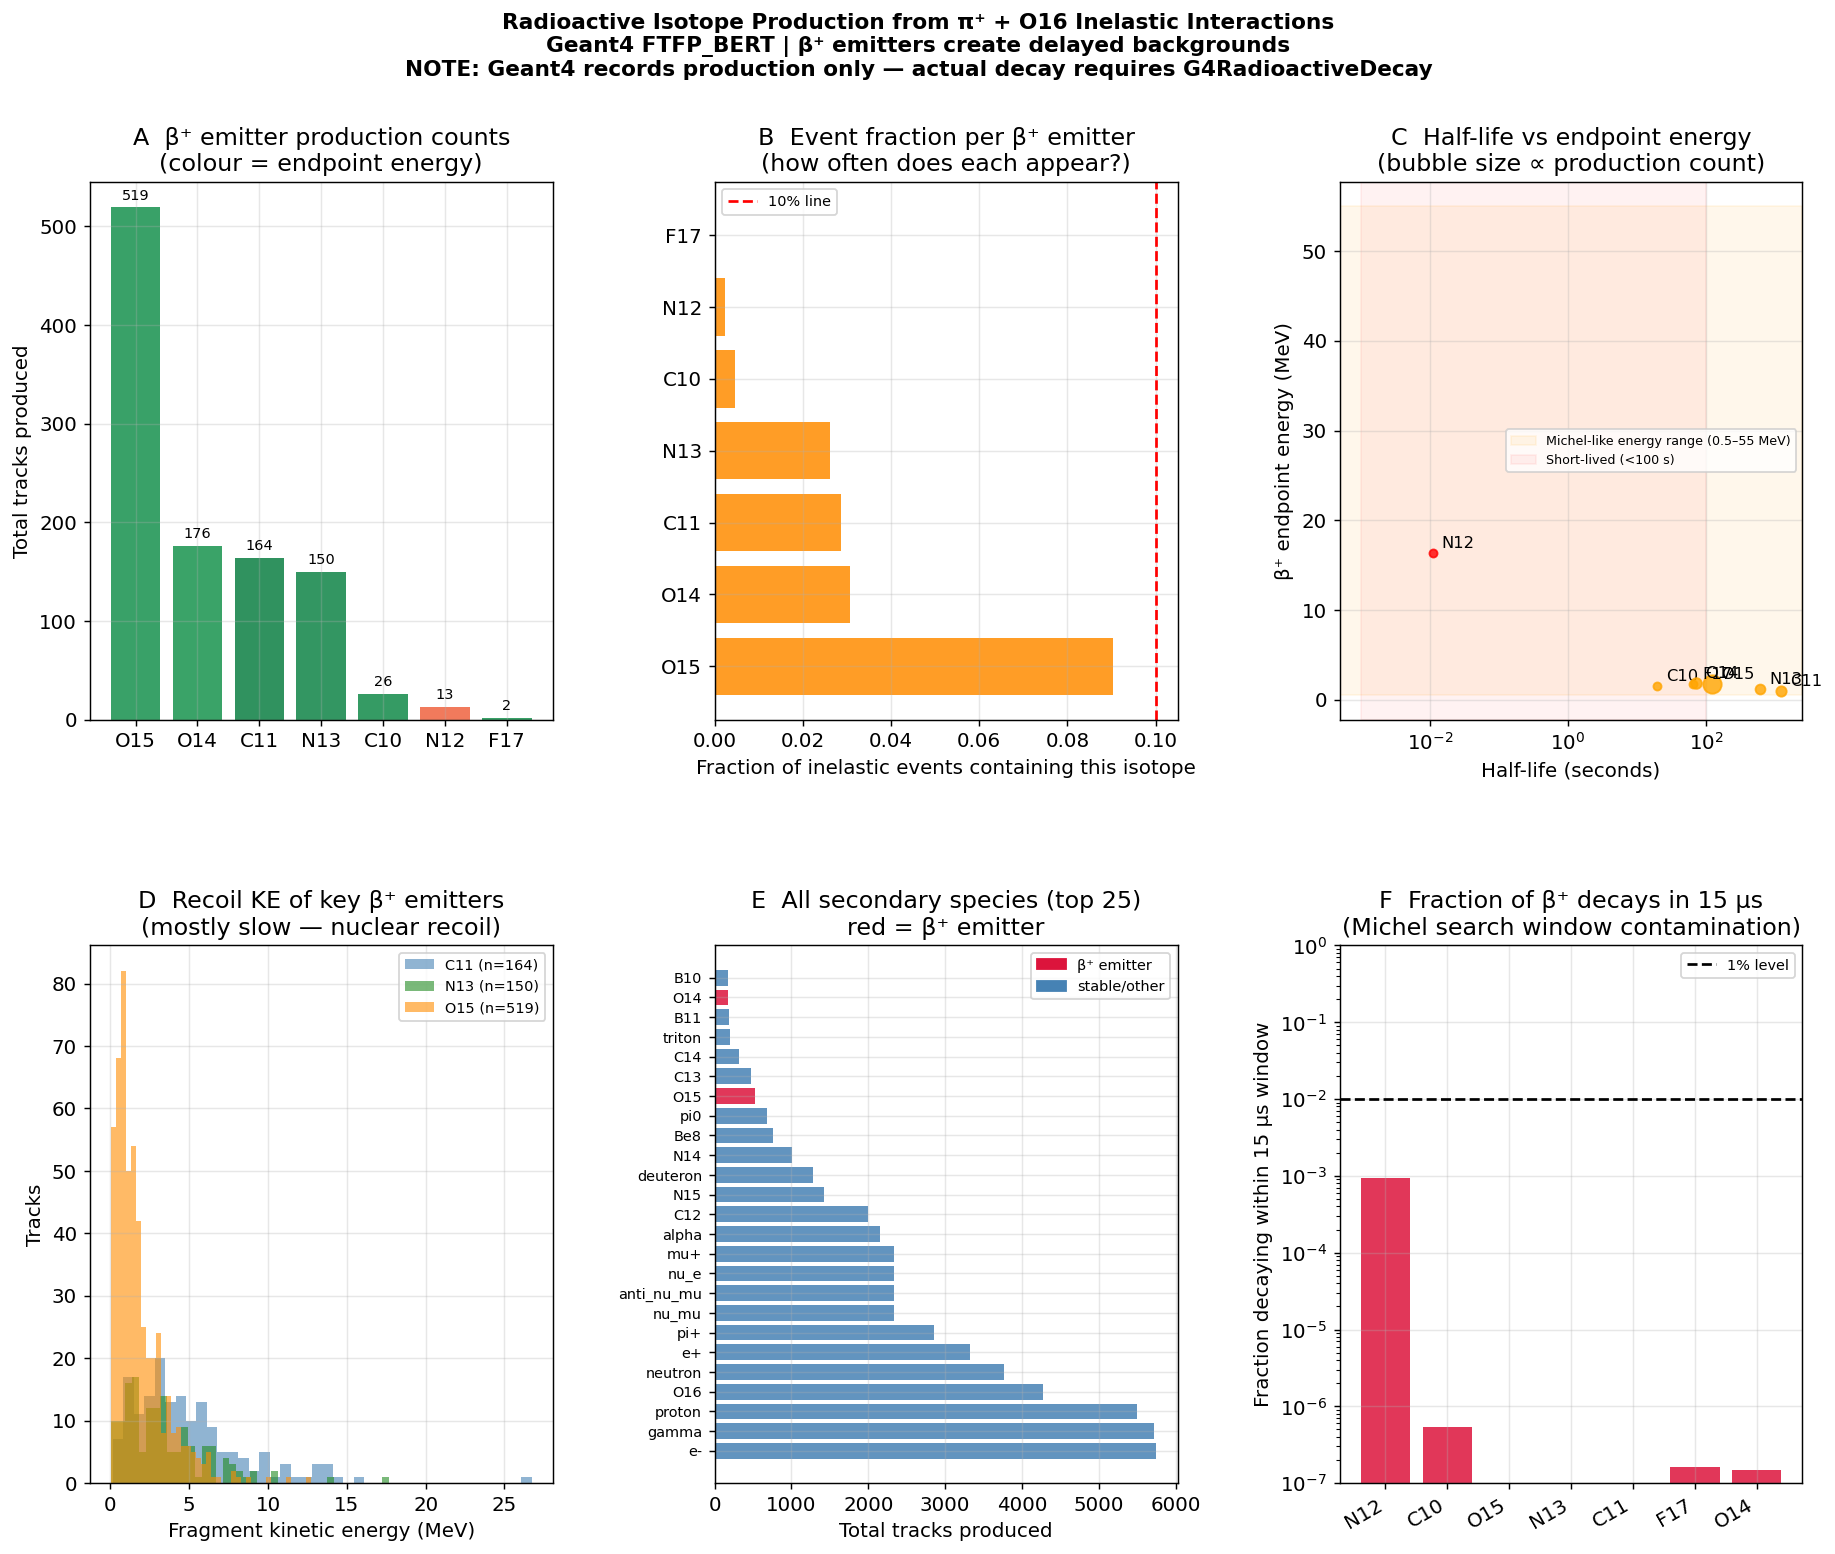


  RADIOACTIVE ISOTOPE DELAYED BACKGROUND SUMMARY

  Inelastic events analysed : 5,739
  Events with β⁺ emitter   : 986 (17.2%)

  Decays within 15 µs Michel search window:
  Isotope   produced   frac_in_15µs   n_in_window   endpoint
  ─────────────────────────────────────────────────────────
  N12             13        9.45e-04           0.01     16.32 MeV
  O15            519        8.52e-08           0.00      1.72 MeV
  O14            176        1.47e-07           0.00      1.81 MeV
  C10             26        5.39e-07           0.00      1.47 MeV
  N13            150        1.74e-08           0.00      1.19 MeV
  C11            164        8.49e-09           0.00      0.96 MeV
  F17              2        1.61e-07           0.00      1.74 MeV

  IMPORTANT CAVEATS:
  1. Geant4 FTFP_BERT does NOT simulate radioactive decay.
     These are production counts only.
  2. To simulate actual delayed β⁺ signals you need
     G4RadioactiveDecay added to the physics list.
  3. Short-lived isot

In [75]:
# ── Cell: Radioactive isotope inventory from π⁺+O inelastic ──────────────────
# FTFP_BERT produces radioactive isotopes via nuclear spallation.
# Several are β⁺ emitters whose positrons produce delayed Cherenkov
# that could fake Michel electron signals.
#
# Key isotopes and half-lives:
#   C11  : t½ = 20.4 min  → e⁺ endpoint ~0.96 MeV
#   N13  : t½ = 9.97 min  → e⁺ endpoint ~1.19 MeV
#   O15  : t½ = 2.04 min  → e⁺ endpoint ~1.72 MeV
#   B8   : t½ = 770 ms    → e⁺ endpoint ~13.7 MeV (energetic!)
#   C10  : t½ = 19.3 s    → e⁺ endpoint ~1.47 MeV
#   N12  : t½ = 11 ms     → e⁺ endpoint ~16.3 MeV (very energetic!)
#
# Note: Geant4 FTFP_BERT does NOT simulate the actual radioactive decay
# of these isotopes (that requires G4RadioactiveDecay physics).
# This cell documents PRODUCTION rates only — the actual delayed
# backgrounds would need a separate radioactive decay simulation.

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─── Known β⁺ emitters from spallation of O16 ────────────────────────────────
# Format: name → (half_life_seconds, beta_endpoint_MeV, decay_mode)
BETA_PLUS_ISOTOPES = {
    'N12'     : (0.011,   16.32,  'β⁺'),   # 11 ms  — very energetic
    'B8'      : (0.770,   13.70,  'β⁺'),   # 770 ms — energetic
    'C10'     : (19.3,     1.47,  'β⁺'),   # 19.3 s
    'O15'     : (122.,     1.72,  'β⁺'),   # 2 min
    'N13'     : (597.,     1.19,  'β⁺'),   # 9.97 min
    'C11'     : (1224.,    0.96,  'β⁺'),   # 20.4 min
    'F17'     : (64.5,     1.74,  'β⁺'),   # 64.5 s
    'O14'     : (70.6,     1.81,  'β⁺'),   # 70.6 s
}

# Also track stable/long-lived isotopes that just contribute to energy deposition
OTHER_ISOTOPES = ['C12', 'C13', 'N14', 'N15', 'O16', 'O17', 'O18',
                  'C14', 'F18', 'F19', 'Na22', 'Ne20']

print("Known β⁺ emitters from O16 spallation:")
print(f"{'Isotope':8s} {'t½':>12s} {'β⁺ endpoint':>14s} {'Concern'}")
print("─" * 60)
for iso, (t_half, E_end, mode) in sorted(BETA_PLUS_ISOTOPES.items(),
                                          key=lambda x: x[1][0]):
    if t_half < 1:
        t_str = f"{t_half*1000:.0f} ms"
    elif t_half < 60:
        t_str = f"{t_half:.1f} s"
    elif t_half < 3600:
        t_str = f"{t_half/60:.1f} min"
    else:
        t_str = f"{t_half/3600:.1f} hr"

    concern = ("⚠ MICHEL-LIKE" if 0.5 < E_end < 60 else
               "⚠ ENERGETIC"  if E_end > 5 else
               "low energy")
    print(f"  {iso:6s}   {t_str:>10s}   {E_end:>8.2f} MeV    {concern}")
print()

# ─── Load isotope production from StepTree ────────────────────────────────────
print("Loading StepTree for isotope inventory...")
with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    st_iso = f[st_key].arrays(
        ['event_id', 'particle', 'parent_id',
         'from_primary_pi', 'p_mag', 'KE', 'time'],
        library='pd'
    )

st_iso['particle']        = (st_iso['particle'].astype(str)
                              .str.strip().str.rstrip('\x00'))
st_iso['from_primary_pi'] = st_iso['from_primary_pi'].astype(bool)
st_iso['parent_id']       = st_iso['parent_id'].astype(int)
for c in ['p_mag', 'KE']:
    st_iso[c] = pd.to_numeric(st_iso[c], errors='coerce').fillna(0.)

# Restrict to inelastic signal events
st_iso = st_iso[st_iso['event_id'].isin(inel_ids)].copy()

# Get first step per track (= production)
is_secondary = st_iso['from_primary_pi'] & (st_iso['parent_id'] != 0)
first_iso = (st_iso[is_secondary]
             .sort_values('time')
             .groupby(['event_id', 'particle'])
             .first()
             .reset_index())

# ─── Count productions ────────────────────────────────────────────────────────
all_isotopes = list(BETA_PLUS_ISOTOPES.keys()) + OTHER_ISOTOPES

iso_stats = {}
for iso in all_isotopes:
    rows = first_iso[first_iso['particle'] == iso]
    n_tracks = len(rows)
    n_events = rows['event_id'].nunique()
    if n_tracks > 0:
        iso_stats[iso] = {
            'n_tracks'      : n_tracks,
            'n_events'      : n_events,
            'evt_fraction'  : n_events / len(sig_inel),
            'mean_KE_MeV'   : rows['KE'].mean() * 1000,
            'is_beta_plus'  : iso in BETA_PLUS_ISOTOPES,
        }

print("─── ISOTOPE PRODUCTION RATES (inelastic signal events) ───")
print(f"{'Isotope':8s} {'n_tracks':>10s} {'n_events':>10s} "
      f"{'evt_frac':>10s} {'mean_KE':>10s} {'type'}")
print("─" * 65)
for iso, s in sorted(iso_stats.items(),
                     key=lambda x: x[1]['n_tracks'], reverse=True):
    tag = "β⁺ emitter" if s['is_beta_plus'] else "stable/long"
    print(f"  {iso:6s}  {s['n_tracks']:>10,}  {s['n_events']:>10,}  "
          f"{s['evt_fraction']:>10.3f}  "
          f"{s['mean_KE_MeV']:>8.1f} MeV  {tag}")
print()

# ─── β⁺ emitter production rate summary ──────────────────────────────────────
print("─── β⁺ EMITTER CONCERN SUMMARY ───")
total_beta_plus_events = set()
for iso in BETA_PLUS_ISOTOPES:
    if iso in iso_stats:
        evts = set(first_iso[first_iso['particle'] == iso]['event_id'].values)
        total_beta_plus_events |= evts
        s = iso_stats[iso]
        t_half = BETA_PLUS_ISOTOPES[iso][0]
        E_end  = BETA_PLUS_ISOTOPES[iso][1]
        print(f"  {iso:6s}: {s['n_events']:,} events ({s['evt_fraction']*100:.1f}%)  "
              f"t½={t_half:.1f}s  endpoint={E_end:.2f} MeV")

print(f"\n  Events with ANY β⁺ emitter produced: "
      f"{len(total_beta_plus_events):,} "
      f"({100*len(total_beta_plus_events)/len(sig_inel):.1f}% of inelastic events)")
print()

# ─── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle(
    'Radioactive Isotope Production from π⁺ + O16 Inelastic Interactions\n'
    'Geant4 FTFP_BERT | β⁺ emitters create delayed backgrounds\n'
    'NOTE: Geant4 records production only — actual decay requires G4RadioactiveDecay',
    fontsize=12, fontweight='bold'
)

# ── Panel A: Production counts — β⁺ emitters ─────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
beta_data = {iso: iso_stats[iso]['n_tracks']
             for iso in BETA_PLUS_ISOTOPES if iso in iso_stats}
beta_data = dict(sorted(beta_data.items(), key=lambda x: x[1], reverse=True))
if beta_data:
    colors_hl = [plt.cm.RdYlGn_r(
                    BETA_PLUS_ISOTOPES[iso][1] / 20.)
                 for iso in beta_data]
    bars = ax.bar(range(len(beta_data)), list(beta_data.values()),
                  color=colors_hl, alpha=0.85)
    ax.set_xticks(range(len(beta_data)))
    ax.set_xticklabels(list(beta_data.keys()))
    ax.set_ylabel('Total tracks produced')
    ax.set_title('A  β⁺ emitter production counts\n(colour = endpoint energy)')
    for bar, (iso, n) in zip(bars, beta_data.items()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{n:,}', ha='center', va='bottom', fontsize=8)

# ── Panel B: Event fraction by isotope ───────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
frac_data = {iso: iso_stats[iso]['evt_fraction']
             for iso in BETA_PLUS_ISOTOPES if iso in iso_stats}
frac_data = dict(sorted(frac_data.items(), key=lambda x: x[1], reverse=True))
if frac_data:
    ax.barh(range(len(frac_data)), list(frac_data.values()),
            color='darkorange', alpha=0.85)
    ax.set_yticks(range(len(frac_data)))
    ax.set_yticklabels(list(frac_data.keys()))
    ax.set_xlabel('Fraction of inelastic events containing this isotope')
    ax.set_title('B  Event fraction per β⁺ emitter\n(how often does each appear?)')
    ax.axvline(0.1, color='red', ls='--', lw=1.5, label='10% line')
    ax.legend(fontsize=8)

# ── Panel C: Half-life vs endpoint energy — concern map ──────────────────────
ax = fig.add_subplot(gs[0, 2])
for iso, (t_half, E_end, _) in BETA_PLUS_ISOTOPES.items():
    if iso not in iso_stats:
        continue
    n = iso_stats[iso]['n_tracks']
    size = max(20, min(500, n / 5))
    color = ('red'    if E_end > 5 else
             'orange' if 0.5 < E_end < 5 else
             'green')
    ax.scatter(t_half, E_end, s=size, color=color, alpha=0.8, zorder=3)
    ax.annotate(iso, (t_half, E_end),
                textcoords='offset points', xytext=(5, 3), fontsize=9)

ax.axhspan(0.5, 55, alpha=0.08, color='orange',
           label='Michel-like energy range (0.5–55 MeV)')
ax.axvspan(1e-3, 100, alpha=0.05, color='red',
           label='Short-lived (<100 s)')
ax.set_xscale('log')
ax.set_xlabel('Half-life (seconds)')
ax.set_ylabel('β⁺ endpoint energy (MeV)')
ax.set_title('C  Half-life vs endpoint energy\n(bubble size ∝ production count)')
ax.legend(fontsize=7)

# ── Panel D: KE of produced fragments ────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
for iso, color in [('C11','steelblue'), ('N13','forestgreen'),
                   ('O15','darkorange'), ('B8','crimson')]:
    rows = first_iso[first_iso['particle'] == iso]
    if len(rows) > 0:
        ax.hist(rows['KE'] * 1000, bins=40, alpha=0.6,
                color=color, label=f'{iso} (n={len(rows):,})')
ax.set_xlabel('Fragment kinetic energy (MeV)')
ax.set_ylabel('Tracks')
ax.set_title('D  Recoil KE of key β⁺ emitters\n(mostly slow — nuclear recoil)')
ax.legend(fontsize=8)

# ── Panel E: Full isotope landscape ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
all_produced = first_iso['particle'].value_counts().head(25)
colors_full = ['crimson' if p in BETA_PLUS_ISOTOPES else
               'steelblue' for p in all_produced.index]
ax.barh(range(len(all_produced)), all_produced.values,
        color=colors_full, alpha=0.85)
ax.set_yticks(range(len(all_produced)))
ax.set_yticklabels(all_produced.index.tolist(), fontsize=8)
ax.set_xlabel('Total tracks produced')
ax.set_title('E  All secondary species (top 25)\nred = β⁺ emitter')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='crimson',   label='β⁺ emitter'),
                   Patch(color='steelblue', label='stable/other')],
          fontsize=8)

# ── Panel F: Delayed background rate estimate ─────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
# For each β⁺ emitter, estimate how many decays fall in a
# 0–15 µs readout window (the Michel search window)
# N_decay(t<T) = N_produced * (1 - exp(-T * ln2 / t_half))
T_WINDOW_NS = 15000.   # ns — Michel search window
results_decay = {}
for iso, (t_half_s, E_end, _) in BETA_PLUS_ISOTOPES.items():
    if iso not in iso_stats:
        continue
    n_prod    = iso_stats[iso]['n_tracks']
    t_half_ns = t_half_s * 1e9
    frac_decay_in_window = 1.0 - np.exp(-T_WINDOW_NS * np.log(2) / t_half_ns)
    n_decays_in_window   = n_prod * frac_decay_in_window
    results_decay[iso] = {
        'n_produced'           : n_prod,
        'frac_decay_in_window' : frac_decay_in_window,
        'n_decays_in_window'   : n_decays_in_window,
        'E_end_MeV'            : E_end,
    }

decay_labels = list(results_decay.keys())
decay_fracs  = [results_decay[iso]['frac_decay_in_window']
                for iso in decay_labels]
ax.bar(range(len(decay_labels)), decay_fracs,
       color='crimson', alpha=0.85)
ax.set_xticks(range(len(decay_labels)))
ax.set_xticklabels(decay_labels, rotation=30, ha='right')
ax.set_ylabel('Fraction decaying within 15 µs window')
ax.set_yscale('log')
ax.set_ylim(1e-7, 1.0)
ax.axhline(0.01, color='black', ls='--', lw=1.5,
           label='1% level')
ax.set_title('F  Fraction of β⁺ decays in 15 µs\n'
             '(Michel search window contamination)')
ax.legend(fontsize=8)

plt.savefig('radioactive_isotope_inventory.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Final concern summary ────────────────────────────────────────────────────
print()
print('='*65)
print('  RADIOACTIVE ISOTOPE DELAYED BACKGROUND SUMMARY')
print('='*65)
print(f"\n  Inelastic events analysed : {len(sig_inel):,}")
print(f"  Events with β⁺ emitter   : {len(total_beta_plus_events):,} "
      f"({100*len(total_beta_plus_events)/len(sig_inel):.1f}%)")
print()
print("  Decays within 15 µs Michel search window:")
print(f"  {'Isotope':6s} {'produced':>10s} {'frac_in_15µs':>14s} "
      f"{'n_in_window':>13s} {'endpoint':>10s}")
print("  " + "─"*57)
for iso, rd in sorted(results_decay.items(),
                      key=lambda x: x[1]['n_decays_in_window'],
                      reverse=True):
    print(f"  {iso:6s}  {rd['n_produced']:>10,}  "
          f"{rd['frac_decay_in_window']:>14.2e}  "
          f"{rd['n_decays_in_window']:>13.2f}  "
          f"{rd['E_end_MeV']:>8.2f} MeV")
print()
print("  IMPORTANT CAVEATS:")
print("  1. Geant4 FTFP_BERT does NOT simulate radioactive decay.")
print("     These are production counts only.")
print("  2. To simulate actual delayed β⁺ signals you need")
print("     G4RadioactiveDecay added to the physics list.")
print("  3. Short-lived isotopes (B8, N12) decay so fast they")
print("     appear prompt — could inflate apparent π⁺ Cherenkov.")
print("  4. Long-lived isotopes (C11, N13) persist across events")
print("     in real data — pile-up background in beam spills.")
print("  5. In real ANNIE water you'd also have cosmogenic")
print("     spallation producing the same isotopes continuously.")

Signal events : 12,029

μ⁻ final process (signal):
Transportation          11386
muMinusCaptureAtRest      639
Decay                       4

Pass 1 — finding μ⁻ track IDs and daughter first-steps...


C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['mu_tid'] = chunk['event_id'].map(mu_track_ids)
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['mu_tid'] = chunk['event_id'].map(mu_track_ids)
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

  chunk 10 | mu_tids=3,760 | daughters=832,236


C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['mu_tid'] = chunk['event_id'].map(mu_track_ids)
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['mu_tid'] = chunk['event_id'].map(mu_track_ids)
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

  chunk 20 | mu_tids=7,488 | daughters=1,655,858


...

  chunk 20


C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:183: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['dtype'] = [
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:183: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['dtype'] = [
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:183: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

  chunk 30


C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:183: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['dtype'] = [
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:183: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['dtype'] = [
C:\Users\Dylon Fleming\AppData\Local\Temp\ipykernel_31452\893948629.py:183: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

Pass 2 done.

  μ⁻ DAUGHTER CHERENKOV SUMMARY
  delta_ray             : mean=12,813.6  (13.66% of μ⁻)  events=12,029 (100.0%)
  pair_positron         : mean=     1.2  ( 0.00% of μ⁻)  events=9 (0.1%)
  decay_electron        : mean=     3.0  ( 0.00% of μ⁻)  events=8 (0.1%)

  Total daughter contamination:
    median fraction : 12.24%
    mean   fraction : 13.57%


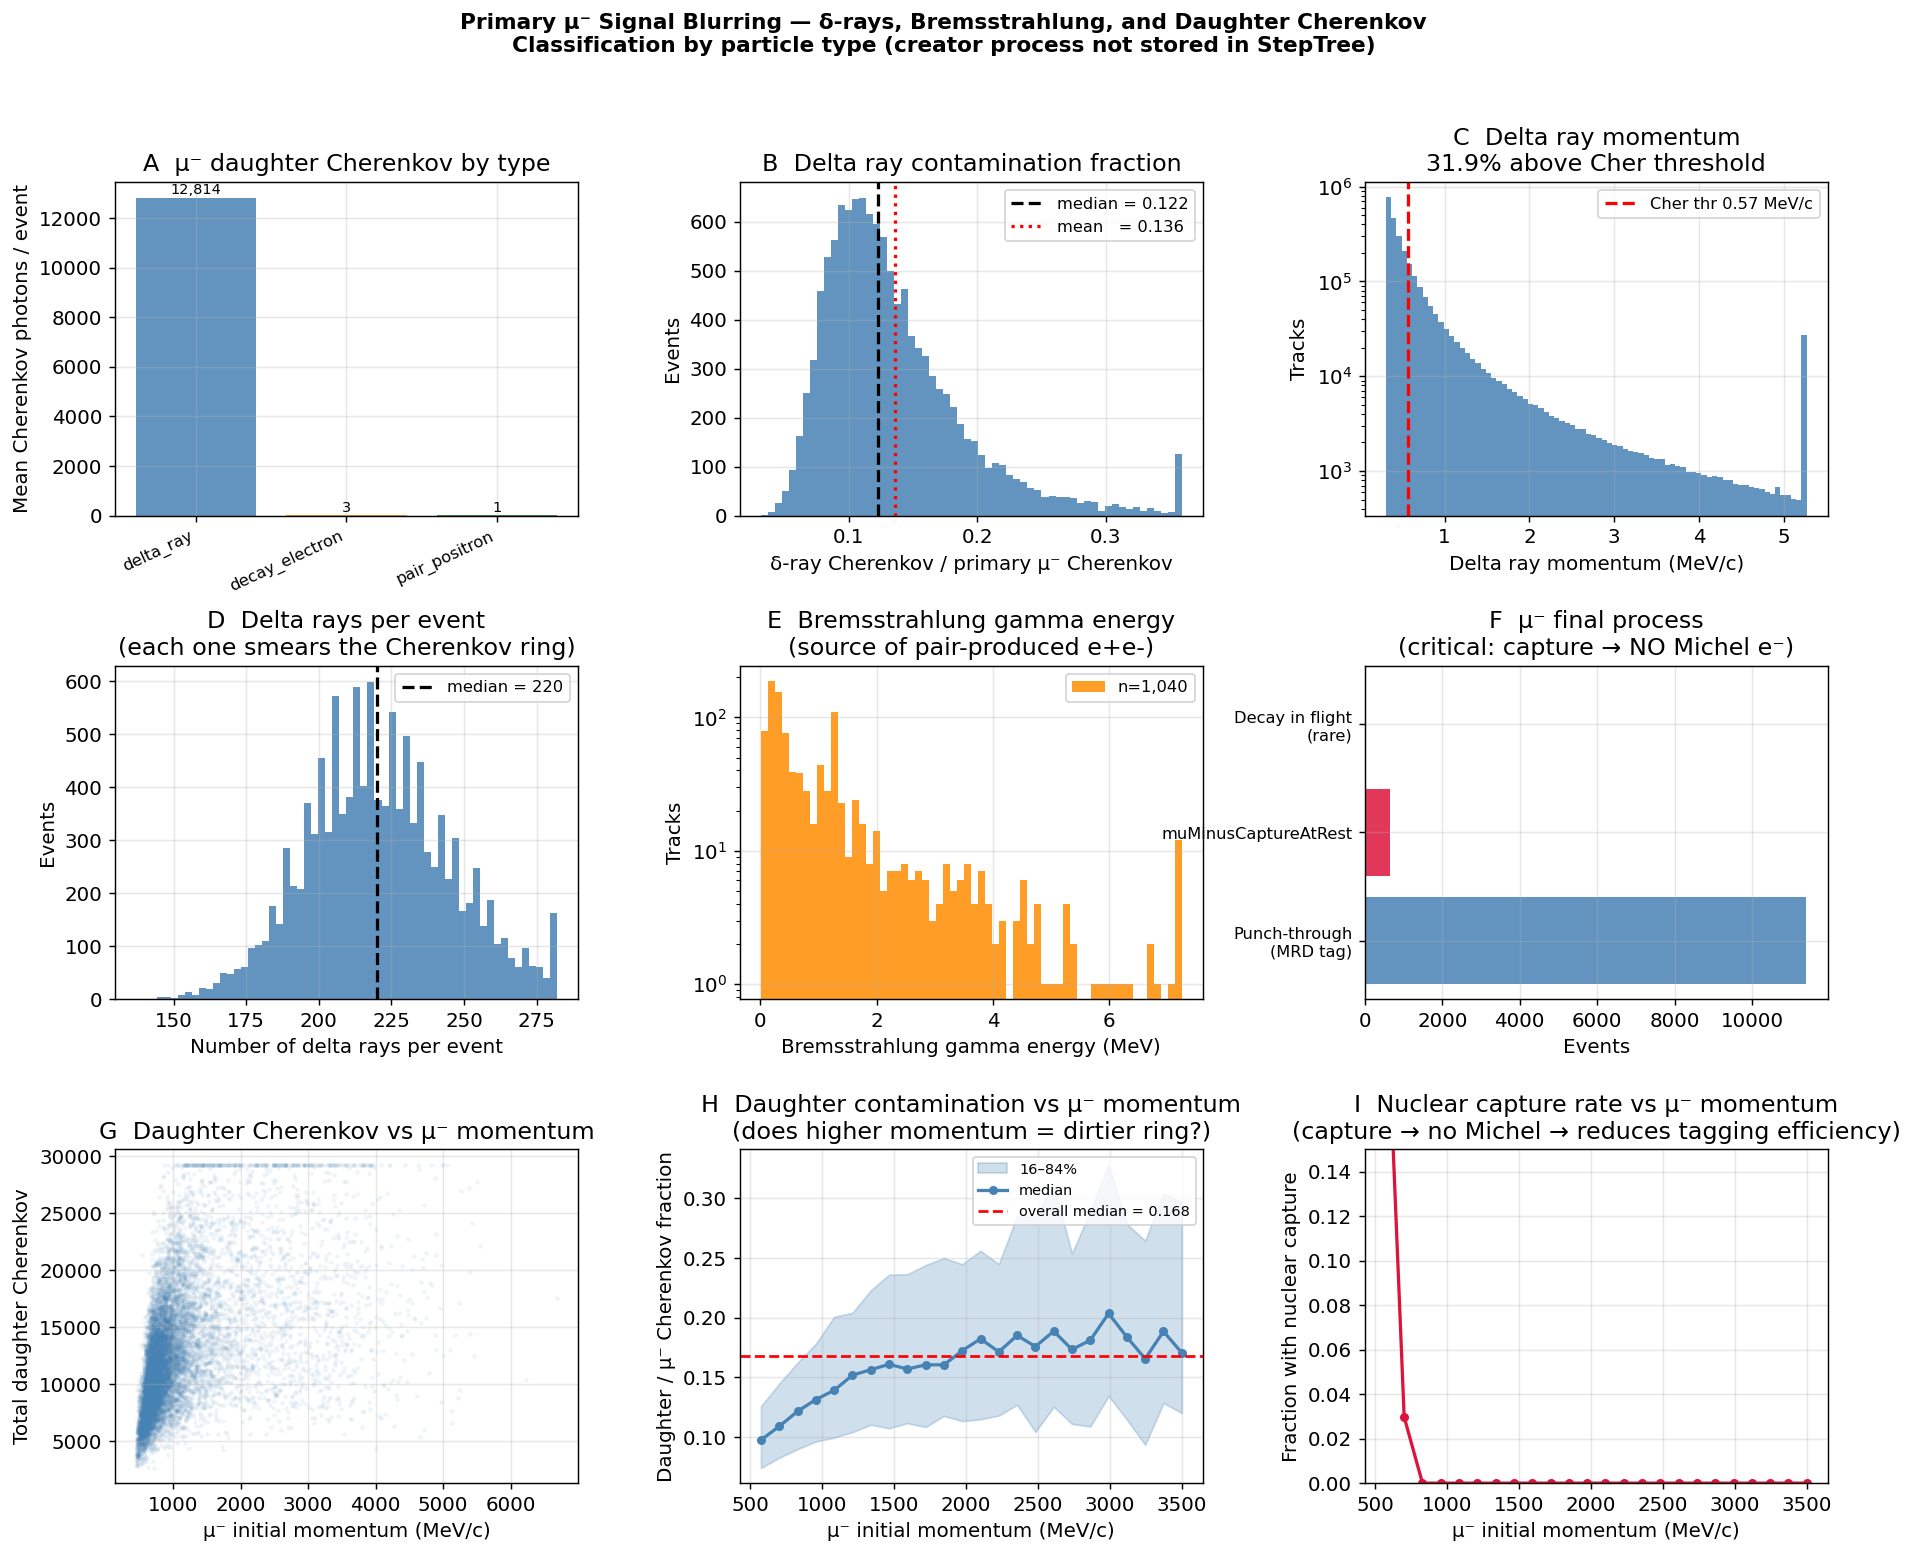

In [81]:
# ── Cell: Primary μ⁻ signal blurring — batched read, type-based classification
# process column = what happened TO the particle at each step (not creator)
# → classify daughters by particle type + timing instead
#
# μ⁻ daughters:
#   e-  (prompt)   → delta ray from hard EM scatter along muon track
#   gamma           → bremsstrahlung radiation
#   e+              → pair production from brem photon (rare)
#   e-  (>200 ns)  → decay electron (very rare — signal filter selects punch-through)
#   neutron/proton  → nuclear recoil (very rare)

import uproot, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─── EventTree ────────────────────────────────────────────────────────────────
with uproot.open(SHUF_PATH) as f:
    et_key = sorted([k for k in f.keys() if 'EventTree' in k])[-1]
    ev_mu  = f[et_key].arrays(
        ['event_id','mu_p0','mu_cher_total','mu_track_len',
         'mu_contained','mu_final_process'],
        library='pd'
    )

ev_mu['mu_contained']     = ev_mu['mu_contained'].astype(bool)
ev_mu['mu_final_process'] = (ev_mu['mu_final_process'].astype(str)
                               .str.strip().str.rstrip('\x00'))
for c in ['mu_p0','mu_cher_total','mu_track_len']:
    ev_mu[c] = pd.to_numeric(ev_mu[c], errors='coerce')
if ev_mu['mu_track_len'].max() > 600:
    ev_mu['mu_track_len'] = ev_mu['mu_track_len'] / 10.

sig_mu  = ev_mu[(ev_mu['mu_p0'] > 0.1185) & (~ev_mu['mu_contained'])].copy()
sig_ids = set(sig_mu['event_id'].values)

print(f"Signal events : {len(sig_mu):,}")
print("\nμ⁻ final process (signal):")
print(sig_mu['mu_final_process'].value_counts().to_string())
print()

# ─── Classifier — particle type + timing only ─────────────────────────────────
def classify_daughter(particle, time_ns):
    """
    Classify by particle type. The 'process' column records what happened
    TO the daughter at each step — not the creator process. Since we know
    the parent is the primary μ⁻, particle type is unambiguous:
      e-  prompt  → delta ray (hard EM ionisation scatter)
      e-  delayed → decay electron (μ⁻ → e⁻ + νμ + ν̄e, very rare in signal)
      e+          → pair production from brem photon
      gamma       → bremsstrahlung
      nu_*        → decay neutrinos
      n/p         → nuclear recoil (extremely rare)
    """
    if particle == 'e-':
        return 'decay_electron' if time_ns > 200. else 'delta_ray'
    if particle == 'e+':
        return 'pair_positron'
    if particle == 'gamma':
        return 'bremsstrahlung'
    if 'nu' in particle:
        return 'decay_neutrino'
    if particle in ('neutron','proton'):
        return 'nuclear_recoil'
    return 'other'

# ─── Batched pass 1: find mu- track_ids + collect daughter first steps ─────────
ST_COLS   = ['event_id','particle','parent_id','track_id',
             'from_primary_pi','cher_step','p_mag','KE',
             'px','py','pz','time','step_num']
CHUNK     = 1_000_000

mu_track_ids   = {}      # event_id → primary mu- track_id
daughter_rows  = []
seen_daughters = set()   # (event_id, track_id) already captured

print("Pass 1 — finding μ⁻ track IDs and daughter first-steps...")
with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    for i, chunk in enumerate(f[st_key].iterate(
            ST_COLS, step_size=CHUNK, library='pd')):

        chunk['particle']        = (chunk['particle'].astype(str)
                                     .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi'] = chunk['from_primary_pi'].astype(bool)
        chunk['parent_id']       = chunk['parent_id'].astype(int)
        chunk['track_id']        = chunk['track_id'].astype(int)
        for c in ['cher_step','p_mag','KE','px','py','pz','time']:
            chunk[c] = pd.to_numeric(chunk[c], errors='coerce').fillna(0.)

        chunk = chunk[chunk['event_id'].isin(sig_ids)]
        if len(chunk) == 0:
            continue

        # Record primary μ⁻ track_id (first time seen per event)
        prim_mu = chunk[(chunk['particle'] == 'mu-') &
                        (chunk['parent_id'] == 0)]
        for eid, tid in zip(prim_mu['event_id'].values,
                            prim_mu['track_id'].values):
            if eid not in mu_track_ids:
                mu_track_ids[eid] = tid

        # Daughters: parent_id == mu_track_id, not from pi chain
        chunk['mu_tid'] = chunk['event_id'].map(mu_track_ids)
        is_daughter = (
            chunk['parent_id'].notna() &
            (chunk['parent_id'] == chunk['mu_tid']) &
            (~chunk['from_primary_pi']) &
            (chunk['particle'] != 'mu-')
        )
        daus = chunk[is_daughter].copy()
        if len(daus) == 0:
            continue

        # Keep only first step per (event_id, track_id)
        daus = (daus.sort_values('step_num')
                    .groupby(['event_id','track_id'], sort=False)
                    .first()
                    .reset_index())

        # Skip already-seen tracks
        key_set = set(zip(daus['event_id'].values, daus['track_id'].values))
        new_keys = key_set - seen_daughters
        seen_daughters |= new_keys
        daus = daus[daus.apply(
            lambda r: (r['event_id'], r['track_id']) in new_keys, axis=1
        )]
        if len(daus):
            daughter_rows.append(daus)

        if (i+1) % 10 == 0:
            print(f"  chunk {i+1} | mu_tids={len(mu_track_ids):,} | "
                  f"daughters={sum(len(d) for d in daughter_rows):,}")

first_daughters = pd.concat(daughter_rows, ignore_index=True)
print(f"\nPass 1 done. Daughter tracks: {len(first_daughters):,}")

first_daughters['type'] = [
    classify_daughter(p, t)
    for p, t in zip(first_daughters['particle'],
                    first_daughters['time'])
]
print("\nDaughter classification:")
print(first_daughters['type'].value_counts().to_string())
print()

# ─── Batched pass 2: sum Cherenkov per event per daughter type ─────────────────
# Build map: (event_id, track_id) → type
track_type_map = {
    (eid, tid): dtype
    for eid, tid, dtype in zip(first_daughters['event_id'].values,
                               first_daughters['track_id'].values,
                               first_daughters['type'].values)
}

DAUGHTER_TYPES = ['delta_ray','bremsstrahlung','pair_positron',
                  'decay_electron','nuclear_recoil','other']

cher_acc = {dt: {} for dt in DAUGHTER_TYPES}  # dt → {event_id: total_cher}

print("Pass 2 — accumulating Cherenkov by daughter type...")
with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if 'StepTree' in k])[-1]
    for i, chunk in enumerate(f[st_key].iterate(
            ['event_id','track_id','parent_id','from_primary_pi',
             'cher_step','particle'],
            step_size=CHUNK, library='pd')):

        chunk['particle']        = (chunk['particle'].astype(str)
                                     .str.strip().str.rstrip('\x00'))
        chunk['from_primary_pi'] = chunk['from_primary_pi'].astype(bool)
        chunk['parent_id']       = chunk['parent_id'].astype(int)
        chunk['track_id']        = chunk['track_id'].astype(int)
        chunk['cher_step']       = pd.to_numeric(
            chunk['cher_step'], errors='coerce').fillna(0.)

        chunk = chunk[chunk['event_id'].isin(sig_ids) &
                      ~chunk['from_primary_pi'] &
                      (chunk['particle'] != 'mu-')]
        if len(chunk) == 0:
            continue

        # Tag each step with its daughter type
        chunk['dtype'] = [
            track_type_map.get((eid, tid), None)
            for eid, tid in zip(chunk['event_id'].values,
                                chunk['track_id'].values)
        ]
        chunk = chunk[chunk['dtype'].notna()]

        for dt in DAUGHTER_TYPES:
            sub = chunk[chunk['dtype'] == dt]
            if len(sub) == 0:
                continue
            grouped = sub.groupby('event_id')['cher_step'].sum()
            for eid, val in grouped.items():
                cher_acc[dt][eid] = cher_acc[dt].get(eid, 0.) + val

        if (i+1) % 10 == 0:
            print(f"  chunk {i+1}")

print("Pass 2 done.")

# ─── Merge onto sig_mu ────────────────────────────────────────────────────────
sig_mu = sig_mu.set_index('event_id')
for dt in DAUGHTER_TYPES:
    col = pd.Series(cher_acc[dt], name=f'cher_{dt}')
    sig_mu = sig_mu.join(col, how='left')
    sig_mu[f'cher_{dt}'] = sig_mu[f'cher_{dt}'].fillna(0.)

sig_mu['mu_daughter_cher_total'] = sum(
    sig_mu[f'cher_{dt}'] for dt in DAUGHTER_TYPES
)
sig_mu['daughter_frac'] = (sig_mu['mu_daughter_cher_total'] /
                            sig_mu['mu_cher_total'].replace(0, np.nan))
sig_mu = sig_mu.reset_index()

# ─── Quick summary before plotting ───────────────────────────────────────────
print()
print('='*60)
print('  μ⁻ DAUGHTER CHERENKOV SUMMARY')
print('='*60)
mu_mean = sig_mu['mu_cher_total'].mean()
for dt in DAUGHTER_TYPES:
    col  = f'cher_{dt}'
    mean = sig_mu[col].mean()
    if mean < 0.5: continue
    frac = mean / mu_mean
    nevt = (sig_mu[col] > 0).sum()
    print(f"  {dt:22s}: mean={mean:>8,.1f}  "
          f"({frac*100:5.2f}% of μ⁻)  "
          f"events={nevt:,} ({100*nevt/len(sig_mu):.1f}%)")

print()
print(f"  Total daughter contamination:")
print(f"    median fraction : {sig_mu['daughter_frac'].median()*100:.2f}%")
print(f"    mean   fraction : {sig_mu['daughter_frac'].mean()*100:.2f}%")

# ─── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    'Primary μ⁻ Signal Blurring — δ-rays, Bremsstrahlung, and Daughter Cherenkov\n'
    'Classification by particle type (creator process not stored in StepTree)',
    fontsize=12, fontweight='bold'
)

# ── Panel A: Daughter Cherenkov by type ───────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
type_means = {dt: sig_mu[f'cher_{dt}'].mean()
              for dt in DAUGHTER_TYPES
              if sig_mu[f'cher_{dt}'].mean() > 0.5}
type_means = dict(sorted(type_means.items(), key=lambda x: x[1], reverse=True))
colors_t   = ['steelblue','darkorange','forestgreen','crimson','purple','grey']
bars = ax.bar(range(len(type_means)), list(type_means.values()),
              color=colors_t[:len(type_means)], alpha=0.85)
ax.set_xticks(range(len(type_means)))
ax.set_xticklabels(list(type_means.keys()), rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean Cherenkov photons / event')
ax.set_title('A  μ⁻ daughter Cherenkov by type')
for bar, val in zip(bars, type_means.values()):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+30,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

# ── Panel B: Delta ray fraction distribution ──────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
dr_frac = (sig_mu['cher_delta_ray'] /
           sig_mu['mu_cher_total'].replace(0, np.nan)).dropna()
ax.hist(dr_frac.clip(upper=dr_frac.quantile(0.99)),
        bins=60, color='steelblue', alpha=0.85)
ax.axvline(dr_frac.median(), color='black', lw=1.8, ls='--',
           label=f'median = {dr_frac.median():.3f}')
ax.axvline(dr_frac.mean(), color='red', lw=1.8, ls=':',
           label=f'mean   = {dr_frac.mean():.3f}')
ax.set_xlabel('δ-ray Cherenkov / primary μ⁻ Cherenkov')
ax.set_ylabel('Events')
ax.set_title('B  Delta ray contamination fraction')
ax.legend(fontsize=9)

# ── Panel C: Delta ray momentum spectrum ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
dr        = first_daughters[first_daughters['type'] == 'delta_ray']
p_thr_e   = 0.000511 / np.sqrt(1.34**2 - 1)
if len(dr):
    ax.hist(dr['p_mag'].clip(upper=dr['p_mag'].quantile(0.99))*1000,
            bins=80, color='steelblue', alpha=0.85)
    ax.axvline(p_thr_e*1000, color='red', lw=1.8, ls='--',
               label=f'Cher thr {p_thr_e*1000:.2f} MeV/c')
    frac_above = (dr['p_mag'] > p_thr_e).mean()
    ax.set_xlabel('Delta ray momentum (MeV/c)')
    ax.set_ylabel('Tracks')
    ax.set_title(f'C  Delta ray momentum\n{frac_above*100:.1f}% above Cher threshold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)

# ── Panel D: Delta ray count per event ───────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
dr_per_event = (first_daughters[first_daughters['type']=='delta_ray']
                .groupby('event_id')['track_id'].count())
dr_per_event = dr_per_event.reindex(sig_mu['event_id'], fill_value=0)
ax.hist(dr_per_event.clip(upper=dr_per_event.quantile(0.99)),
        bins=60, color='steelblue', alpha=0.85)
ax.axvline(dr_per_event.median(), color='black', lw=1.8, ls='--',
           label=f'median = {dr_per_event.median():.0f}')
ax.set_xlabel('Number of delta rays per event')
ax.set_ylabel('Events')
ax.set_title('D  Delta rays per event\n(each one smears the Cherenkov ring)')
ax.legend(fontsize=9)

# ── Panel E: Bremsstrahlung gamma energy ──────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
brem = first_daughters[first_daughters['type'] == 'bremsstrahlung']
if len(brem):
    ax.hist(brem['KE'].clip(upper=brem['KE'].quantile(0.99))*1000,
            bins=60, color='darkorange', alpha=0.85,
            label=f'n={len(brem):,}')
    ax.set_xlabel('Bremsstrahlung gamma energy (MeV)')
    ax.set_ylabel('Tracks')
    ax.set_title('E  Bremsstrahlung gamma energy\n(source of pair-produced e+e-)')
    ax.set_yscale('log')
    ax.legend(fontsize=9)

# ── Panel F: μ⁻ final process ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
fate_counts = sig_mu['mu_final_process'].value_counts()
fate_labels = [f.replace('MuMinusCaptureAtRest','μ⁻ Nuclear Capture\n(no Michel!)')
                .replace('Transportation','Punch-through\n(MRD tag)')
                .replace('Decay','Decay in flight\n(rare)')
               for f in fate_counts.index]
colors_fate = ['steelblue' if 'Transport' in f else
               'crimson'   if 'Capture'   in f else
               'forestgreen' for f in fate_counts.index]
ax.barh(range(len(fate_counts)), fate_counts.values,
        color=colors_fate, alpha=0.85)
ax.set_yticks(range(len(fate_counts)))
ax.set_yticklabels(fate_labels, fontsize=9)
ax.set_xlabel('Events')
ax.set_title('F  μ⁻ final process\n(critical: capture → NO Michel e⁻)')

# ── Panel G: Total daughter Cherenkov vs μ⁻ momentum ─────────────────────────
ax = fig.add_subplot(gs[2, 0])
ax.scatter(sig_mu['mu_p0']*1000,
           sig_mu['mu_daughter_cher_total'].clip(
               upper=sig_mu['mu_daughter_cher_total'].quantile(0.98)),
           s=3, alpha=0.05, color='steelblue')
ax.set_xlabel('μ⁻ initial momentum (MeV/c)')
ax.set_ylabel('Total daughter Cherenkov')
ax.set_title('G  Daughter Cherenkov vs μ⁻ momentum')

# ── Panel H: Daughter fraction vs μ⁻ momentum (binned) ───────────────────────
ax = fig.add_subplot(gs[2, 1])
p_bins = np.linspace(sig_mu['mu_p0'].quantile(0.02),
                     sig_mu['mu_p0'].quantile(0.98), 25)
p_cents = 0.5*(p_bins[:-1]+p_bins[1:])
frac_med = []
frac_lo  = []
frac_hi  = []
for lo, hi in zip(p_bins[:-1], p_bins[1:]):
    sub = sig_mu.loc[
        (sig_mu['mu_p0']>=lo) & (sig_mu['mu_p0']<hi),
        'daughter_frac'
    ].dropna()
    frac_med.append(sub.median() if len(sub) else np.nan)
    frac_lo.append( sub.quantile(0.16) if len(sub) else np.nan)
    frac_hi.append( sub.quantile(0.84) if len(sub) else np.nan)

frac_med = np.array(frac_med)
frac_lo  = np.array(frac_lo)
frac_hi  = np.array(frac_hi)
ax.fill_between(p_cents*1000, frac_lo, frac_hi,
                alpha=0.25, color='steelblue', label='16–84%')
ax.plot(p_cents*1000, frac_med, 'o-', color='steelblue',
        lw=1.8, ms=4, label='median')
ax.axhline(np.nanmedian(frac_med), color='red', lw=1.5, ls='--',
           label=f'overall median = {np.nanmedian(frac_med):.3f}')
ax.set_xlabel('μ⁻ initial momentum (MeV/c)')
ax.set_ylabel('Daughter / μ⁻ Cherenkov fraction')
ax.set_title('H  Daughter contamination vs μ⁻ momentum\n'
             '(does higher momentum = dirtier ring?)')
ax.legend(fontsize=8)

# ── Panel I: Capture rate vs μ⁻ momentum (binned) ────────────────────────────
ax = fig.add_subplot(gs[2, 2])
sig_mu['is_capture'] = sig_mu['mu_final_process'].str.contains(
    'Capture', na=False)
cap_rate = []
for lo, hi in zip(p_bins[:-1], p_bins[1:]):
    sub = sig_mu[(sig_mu['mu_p0']>=lo) & (sig_mu['mu_p0']<hi)]
    cap_rate.append(sub['is_capture'].mean() if len(sub) else np.nan)
ax.plot(p_cents*1000, cap_rate, 'o-', color='crimson',
        lw=1.8, ms=4)
ax.set_xlabel('μ⁻ initial momentum (MeV/c)')
ax.set_ylabel('Fraction with nuclear capture')
ax.set_title('I  Nuclear capture rate vs μ⁻ momentum\n'
             '(capture → no Michel → reduces tagging efficiency)')
ax.set_ylim(0, 0.15)

plt.savefig('muon_signal_blurring.png', dpi=150, bbox_inches='tight')
plt.show()

In [77]:
# ── Cell: Build late-window table for the ~40 ns feature ──────────────────────

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Fallbacks
try:
    SHUF_PATH
except NameError:
    SHUF_PATH = Path(r"D:\research\ANNIE\simualtion\my_geant4\annie_coprimary30kshuffled.root")

try:
    DET_EFF
except NameError:
    DET_EFF = 0.025

try:
    C_WATER
except NameError:
    C_WATER = 299.792 / 1.34

try:
    R_CYL
except NameError:
    R_CYL = 1600.0

try:
    Z_MAX
except NameError:
    Z_MAX = 2000.0

CHUNK_SIZE = 500_000
T_LATE_MIN = 35.0
T_LATE_MAX = 45.0

def tof_to_cylinder(x, y, z):
    r = np.sqrt(x**2 + y**2)
    d_barrel = np.clip(R_CYL - r, 0, None)
    d_endcap = np.clip(np.where(z >= 0, Z_MAX - z, Z_MAX + z), 0, None)
    return np.minimum(d_barrel, d_endcap)

def choose_best_tree(root_file, tree_name):
    matches = []
    for key in root_file.keys():
        if key.split(";")[0] == tree_name:
            obj = root_file[key]
            n = getattr(obj, "num_entries", -1)
            matches.append((key, n))
    if not matches:
        return None
    matches.sort(key=lambda t: t[1], reverse=True)
    return root_file[matches[0][0]]

def clean_str_series(s):
    return s.astype(str).str.strip().str.rstrip("\x00")

# event metadata
if "ev_sig" not in globals():
    raise RuntimeError("Need ev_sig in memory first.")

event_meta = ev_sig.copy()
if "event_id" not in event_meta.columns:
    event_meta["event_id"] = event_meta.index
event_meta["event_id"] = pd.to_numeric(event_meta["event_id"], errors="coerce").astype(np.int32)
event_meta = event_meta.drop_duplicates(subset=["event_id"]).set_index("event_id")

sig_ids = set(event_meta.index.astype(np.int32))

meta_cols = [
    c for c in [
        "mu_water_exit_ns", "mu_time_stop", "pi_time_end",
        "mu_p0", "pi_p0", "open_angle_deg",
        "fate", "mu_final_process", "pi_final_process",
        "mu_cher_total", "pi_cher_total"
    ] if c in event_meta.columns
]
meta_use = event_meta[meta_cols].copy()

late_parts = []

print(f"Scanning StepTree for {T_LATE_MIN:.1f}–{T_LATE_MAX:.1f} ns wall-hit steps...")

with uproot.open(SHUF_PATH) as f:
    st = choose_best_tree(f, "StepTree")
    total_entries = st.num_entries
    print(f"StepTree entries: {total_entries:,}")

    cols = [
        "event_id", "particle", "parent_id", "track_id", "step_num",
        "x", "y", "z", "time", "cher_step", "process", "from_primary_pi"
    ]
    cols = [c for c in cols if c in st.keys()]

    for i, chunk in enumerate(st.iterate(cols, step_size=CHUNK_SIZE, library="pd")):
        chunk["particle"] = clean_str_series(chunk["particle"])
        if "process" in chunk.columns:
            chunk["process"] = clean_str_series(chunk["process"])
        else:
            chunk["process"] = "unknown"

        if "from_primary_pi" in chunk.columns:
            chunk["from_primary_pi"] = chunk["from_primary_pi"].astype(bool)
        else:
            chunk["from_primary_pi"] = False

        base_mask = (
            chunk["event_id"].isin(sig_ids) &
            (chunk["cher_step"] > 0)
        )

        is_mu = (chunk["particle"] == "mu-") & (chunk["parent_id"] == 0)
        is_pi = (chunk["particle"] == "pi+") & (chunk["from_primary_pi"])

        chunk = chunk[base_mask & (is_mu | is_pi)].copy()
        if len(chunk) == 0:
            continue

        d_wall = tof_to_cylinder(chunk["x"].values, chunk["y"].values, chunk["z"].values)
        chunk["d_wall_mm"] = d_wall
        chunk["tof_ns"] = d_wall / C_WATER
        chunk["t_hit"] = chunk["time"] + chunk["tof_ns"]
        chunk["cher_det"] = chunk["cher_step"] * DET_EFF
        chunk["r_mm"] = np.sqrt(chunk["x"].values**2 + chunk["y"].values**2)

        late = chunk[(chunk["t_hit"] >= T_LATE_MIN) & (chunk["t_hit"] <= T_LATE_MAX)].copy()
        if len(late):
            late_parts.append(late)

        if (i + 1) % 10 == 0:
            done = min((i + 1) * CHUNK_SIZE, total_entries)
            print(f"  chunk {i+1:3d}  ({done:,} / {total_entries:,})")

late40 = pd.concat(late_parts, ignore_index=True) if late_parts else pd.DataFrame()

if len(late40) == 0:
    print("No late-window steps found.")
else:
    late40 = late40.merge(meta_use, left_on="event_id", right_index=True, how="left")

    print("\nLate-window summary")
    print("=" * 60)
    print(f"rows in late40                 : {len(late40):,}")
    print(f"unique events                  : {late40['event_id'].nunique():,}")
    print(f"weighted raw late photons      : {late40['cher_step'].sum():,.1f}")
    print(f"weighted detected proxy        : {late40['cher_det'].sum():,.1f}")
    print()
    print("particle breakdown (rows):")
    print(late40["particle"].value_counts().to_string())
    print()
    print("particle breakdown (weighted raw photons):")
    print(late40.groupby("particle")["cher_step"].sum().sort_values(ascending=False).to_string())
    print()
    print(f"t_hit range                    : {late40['t_hit'].min():.2f} to {late40['t_hit'].max():.2f} ns")
    print(f"emit time range                : {late40['time'].min():.2f} to {late40['time'].max():.2f} ns")
    print(f"wall TOF range                 : {late40['tof_ns'].min():.2f} to {late40['tof_ns'].max():.2f} ns")

Scanning StepTree for 35.0–45.0 ns wall-hit steps...
StepTree entries: 32,267,516
  chunk  10  (5,000,000 / 32,267,516)
  chunk  20  (10,000,000 / 32,267,516)
  chunk  30  (15,000,000 / 32,267,516)
  chunk  40  (20,000,000 / 32,267,516)
  chunk  50  (25,000,000 / 32,267,516)
  chunk  60  (30,000,000 / 32,267,516)

Late-window summary
rows in late40                 : 51
unique events                  : 1
weighted raw late photons      : 3,872.1
weighted detected proxy        : 96.8

particle breakdown (rows):
pi+    51

particle breakdown (weighted raw photons):
particle
pi+    3872.110369

t_hit range                    : 40.58 to 41.12 ns
emit time range                : 34.33 to 35.65 ns
wall TOF range                 : 5.47 to 6.26 ns


In [78]:
# ── Cell: Top events contributing to the ~40 ns feature ───────────────────────

if "late40" not in globals() or len(late40) == 0:
    raise RuntimeError("Run the late40 builder cell first.")

event_contrib = (
    late40.groupby(["event_id", "particle"], as_index=False)
    .agg(
        raw_cher=("cher_step", "sum"),
        det_cher=("cher_det", "sum"),
        n_steps=("step_num", "count"),
        mean_t_hit=("t_hit", "mean"),
        mean_emit_t=("time", "mean"),
        mean_tof=("tof_ns", "mean"),
        min_t_hit=("t_hit", "min"),
        max_t_hit=("t_hit", "max"),
    )
    .sort_values("raw_cher", ascending=False)
)

event_tot = (
    late40.groupby("event_id", as_index=False)
    .agg(
        raw_cher=("cher_step", "sum"),
        det_cher=("cher_det", "sum"),
        n_rows=("cher_step", "count"),
    )
    .sort_values("raw_cher", ascending=False)
)

event_tot["cum_frac"] = event_tot["raw_cher"].cumsum() / event_tot["raw_cher"].sum()

print("Top event totals driving the late feature:")
display(event_tot.head(20))

print("\nTop event+particle contributions:")
display(event_contrib.head(30))

for n in [1, 3, 5, 10]:
    frac = event_tot.head(n)["raw_cher"].sum() / event_tot["raw_cher"].sum()
    print(f"Top {n:2d} events account for {frac*100:5.1f}% of the weighted late feature")

top_ids = event_tot.head(12)["event_id"].tolist()

meta_show_cols = [
    c for c in [
        "mu_water_exit_ns", "mu_time_stop", "pi_time_end",
        "mu_p0", "pi_p0", "open_angle_deg", "fate",
        "mu_final_process", "pi_final_process",
        "mu_cher_total", "pi_cher_total"
    ] if c in late40.columns
]

top_meta = (
    late40[late40["event_id"].isin(top_ids)]
    .drop_duplicates(subset=["event_id"])
    [["event_id"] + meta_show_cols]
    .sort_values("event_id")
)

print("\nMetadata for top late-feature events:")
display(top_meta)

Top event totals driving the late feature:


,event_id,raw_cher,det_cher,n_rows,cum_frac
0,23630,3872.110369,96.802759,51,1.0



Top event+particle contributions:


,event_id,particle,raw_cher,det_cher,n_steps,mean_t_hit,mean_emit_t,mean_tof,min_t_hit,max_t_hit
0,23630,pi+,3872.110369,96.802759,51,40.849521,35.010659,5.838862,40.582776,41.116694


Top  1 events account for 100.0% of the weighted late feature
Top  3 events account for 100.0% of the weighted late feature
Top  5 events account for 100.0% of the weighted late feature
Top 10 events account for 100.0% of the weighted late feature

Metadata for top late-feature events:


,event_id,mu_water_exit_ns,mu_time_stop,pi_time_end,mu_p0,pi_p0,open_angle_deg,fate,mu_final_process,pi_final_process,mu_cher_total,pi_cher_total
0,23630,5.668897,10.419402,1.152509,0.604003,0.885859,95.66293,Inelastic,Transportation,pi+Inelastic,71409.135239,15202.223075


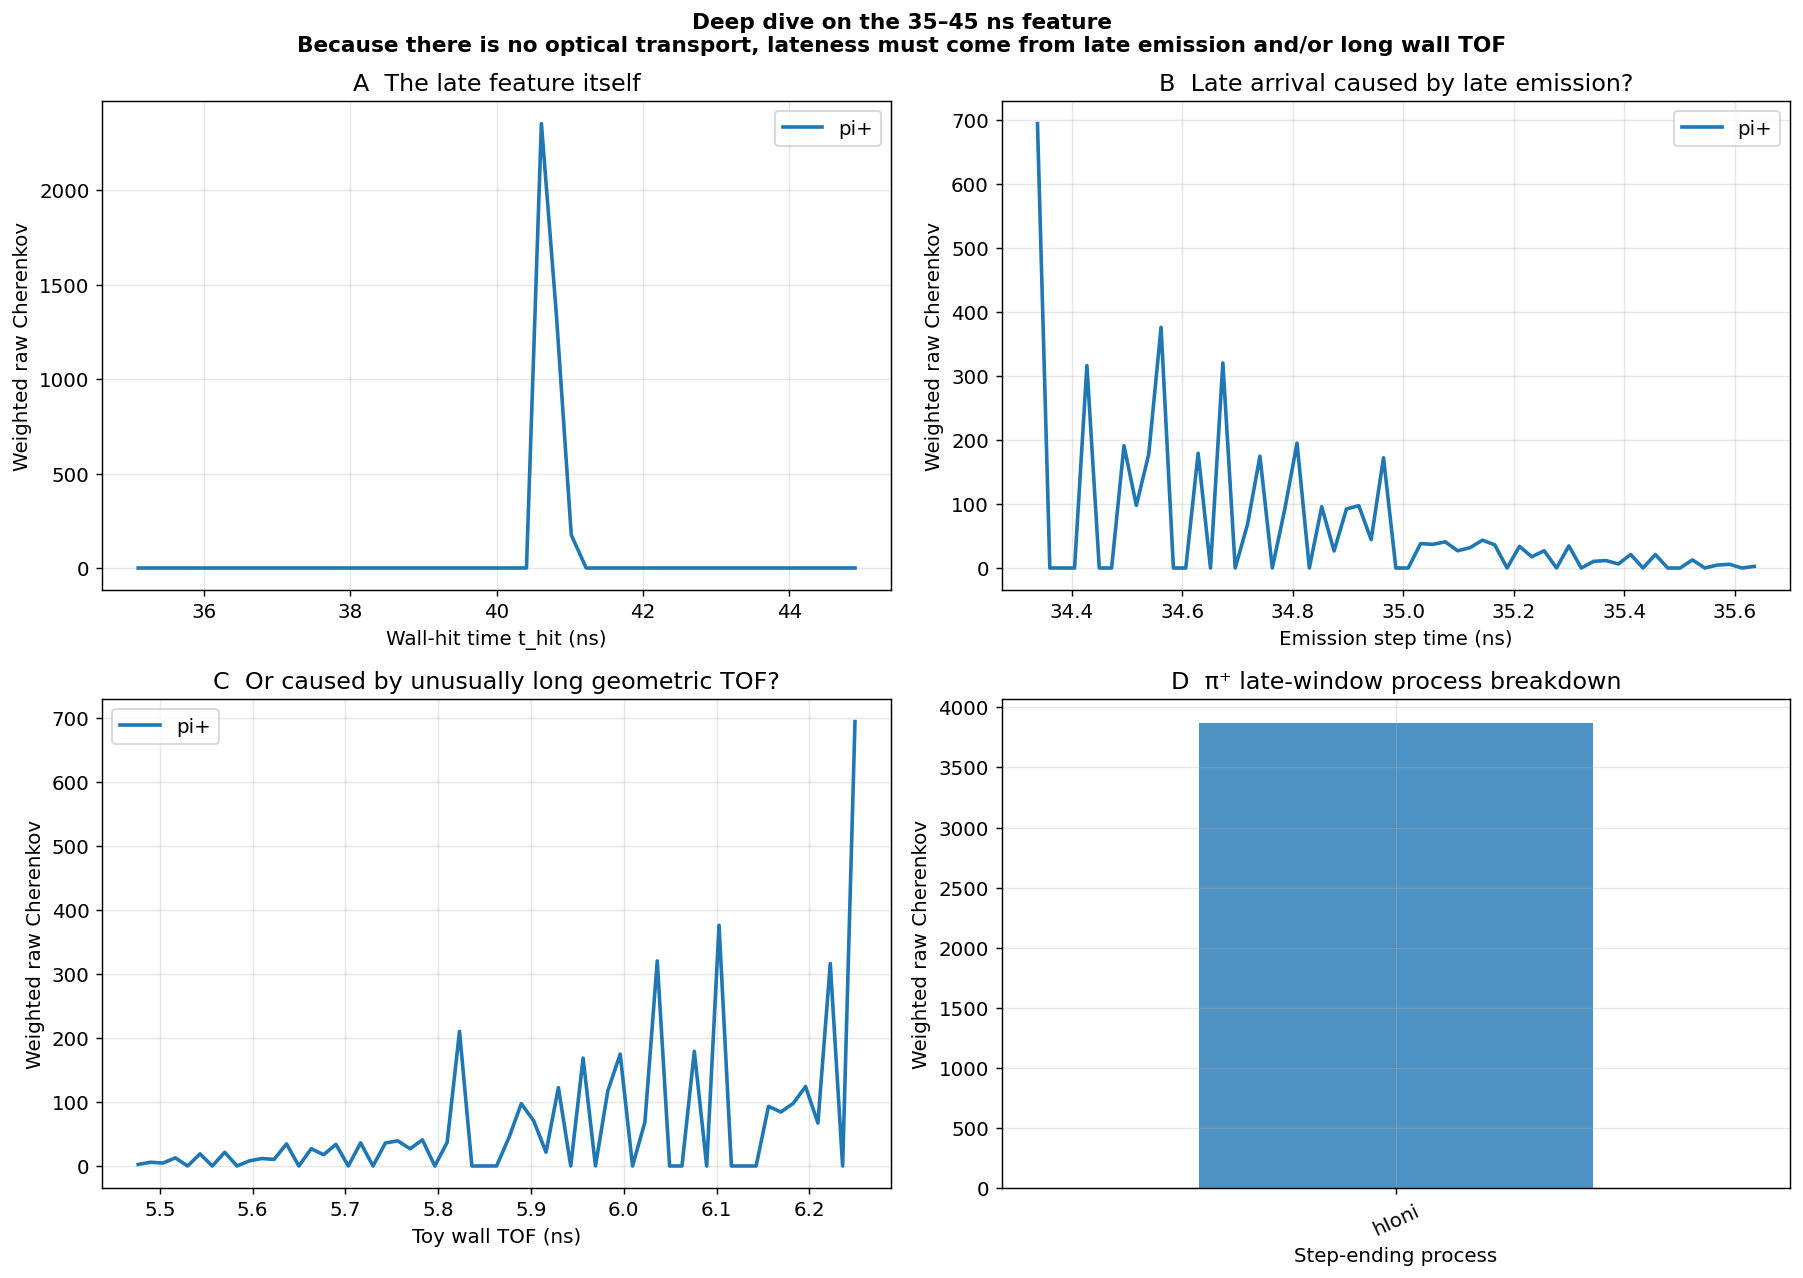

Weighted means in the late feature:

pi+
  mean emit time : 34.67 ns
  mean wall TOF  : 6.05 ns
  mean t_hit     : 40.72 ns


In [79]:
# ── Cell: What makes the ~40 ns feature late? emission time or path TOF? ─────

if "late40" not in globals() or len(late40) == 0:
    raise RuntimeError("Run the late40 builder cell first.")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Deep dive on the {T_LATE_MIN:.0f}–{T_LATE_MAX:.0f} ns feature\n"
    "Because there is no optical transport, lateness must come from late emission and/or long wall TOF",
    fontsize=12, fontweight="bold"
)

# A: weighted arrival-time spectrum in the late window
ax = axes[0, 0]
for part, ls in [("mu-", "--"), ("pi+", "-")]:
    sl = late40[late40["particle"] == part]
    if len(sl):
        bins = np.linspace(T_LATE_MIN, T_LATE_MAX, 50)
        h, b = np.histogram(sl["t_hit"], bins=bins, weights=sl["cher_step"])
        c = 0.5 * (b[:-1] + b[1:])
        ax.plot(c, h, lw=2, ls=ls, label=part)
ax.set_xlabel("Wall-hit time t_hit (ns)")
ax.set_ylabel("Weighted raw Cherenkov")
ax.set_title("A  The late feature itself")
ax.legend()

# B: weighted emission-time spectrum
ax = axes[0, 1]
for part, ls in [("mu-", "--"), ("pi+", "-")]:
    sl = late40[late40["particle"] == part]
    if len(sl):
        bins = np.linspace(late40["time"].min(), late40["time"].max(), 60)
        h, b = np.histogram(sl["time"], bins=bins, weights=sl["cher_step"])
        c = 0.5 * (b[:-1] + b[1:])
        ax.plot(c, h, lw=2, ls=ls, label=part)
ax.set_xlabel("Emission step time (ns)")
ax.set_ylabel("Weighted raw Cherenkov")
ax.set_title("B  Late arrival caused by late emission?")
ax.legend()

# C: weighted wall-TOF spectrum
ax = axes[1, 0]
for part, ls in [("mu-", "--"), ("pi+", "-")]:
    sl = late40[late40["particle"] == part]
    if len(sl):
        bins = np.linspace(late40["tof_ns"].min(), late40["tof_ns"].max(), 60)
        h, b = np.histogram(sl["tof_ns"], bins=bins, weights=sl["cher_step"])
        c = 0.5 * (b[:-1] + b[1:])
        ax.plot(c, h, lw=2, ls=ls, label=part)
ax.set_xlabel("Toy wall TOF (ns)")
ax.set_ylabel("Weighted raw Cherenkov")
ax.set_title("C  Or caused by unusually long geometric TOF?")
ax.legend()

# D: pi+ process breakdown in the late window
ax = axes[1, 1]
pi_late = late40[late40["particle"] == "pi+"].copy()
if len(pi_late):
    proc_w = pi_late.groupby("process")["cher_step"].sum().sort_values(ascending=False)
    proc_w.head(12).plot(kind="bar", ax=ax, alpha=0.8)
ax.set_xlabel("Step-ending process")
ax.set_ylabel("Weighted raw Cherenkov")
ax.set_title("D  π⁺ late-window process breakdown")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

print("Weighted means in the late feature:")
for part in ["mu-", "pi+"]:
    sl = late40[late40["particle"] == part]
    if len(sl):
        w = sl["cher_step"].values
        print(f"\n{part}")
        print(f"  mean emit time : {np.average(sl['time'], weights=w):.2f} ns")
        print(f"  mean wall TOF  : {np.average(sl['tof_ns'], weights=w):.2f} ns")
        print(f"  mean t_hit     : {np.average(sl['t_hit'], weights=w):.2f} ns")

Top event IDs driving the late feature: [23630]


,event_id,mu_water_exit_ns,mu_time_stop,pi_time_end,mu_p0,pi_p0,open_angle_deg,fate
0,23630,5.668897,10.419402,1.152509,0.604003,0.885859,95.66293,Inelastic


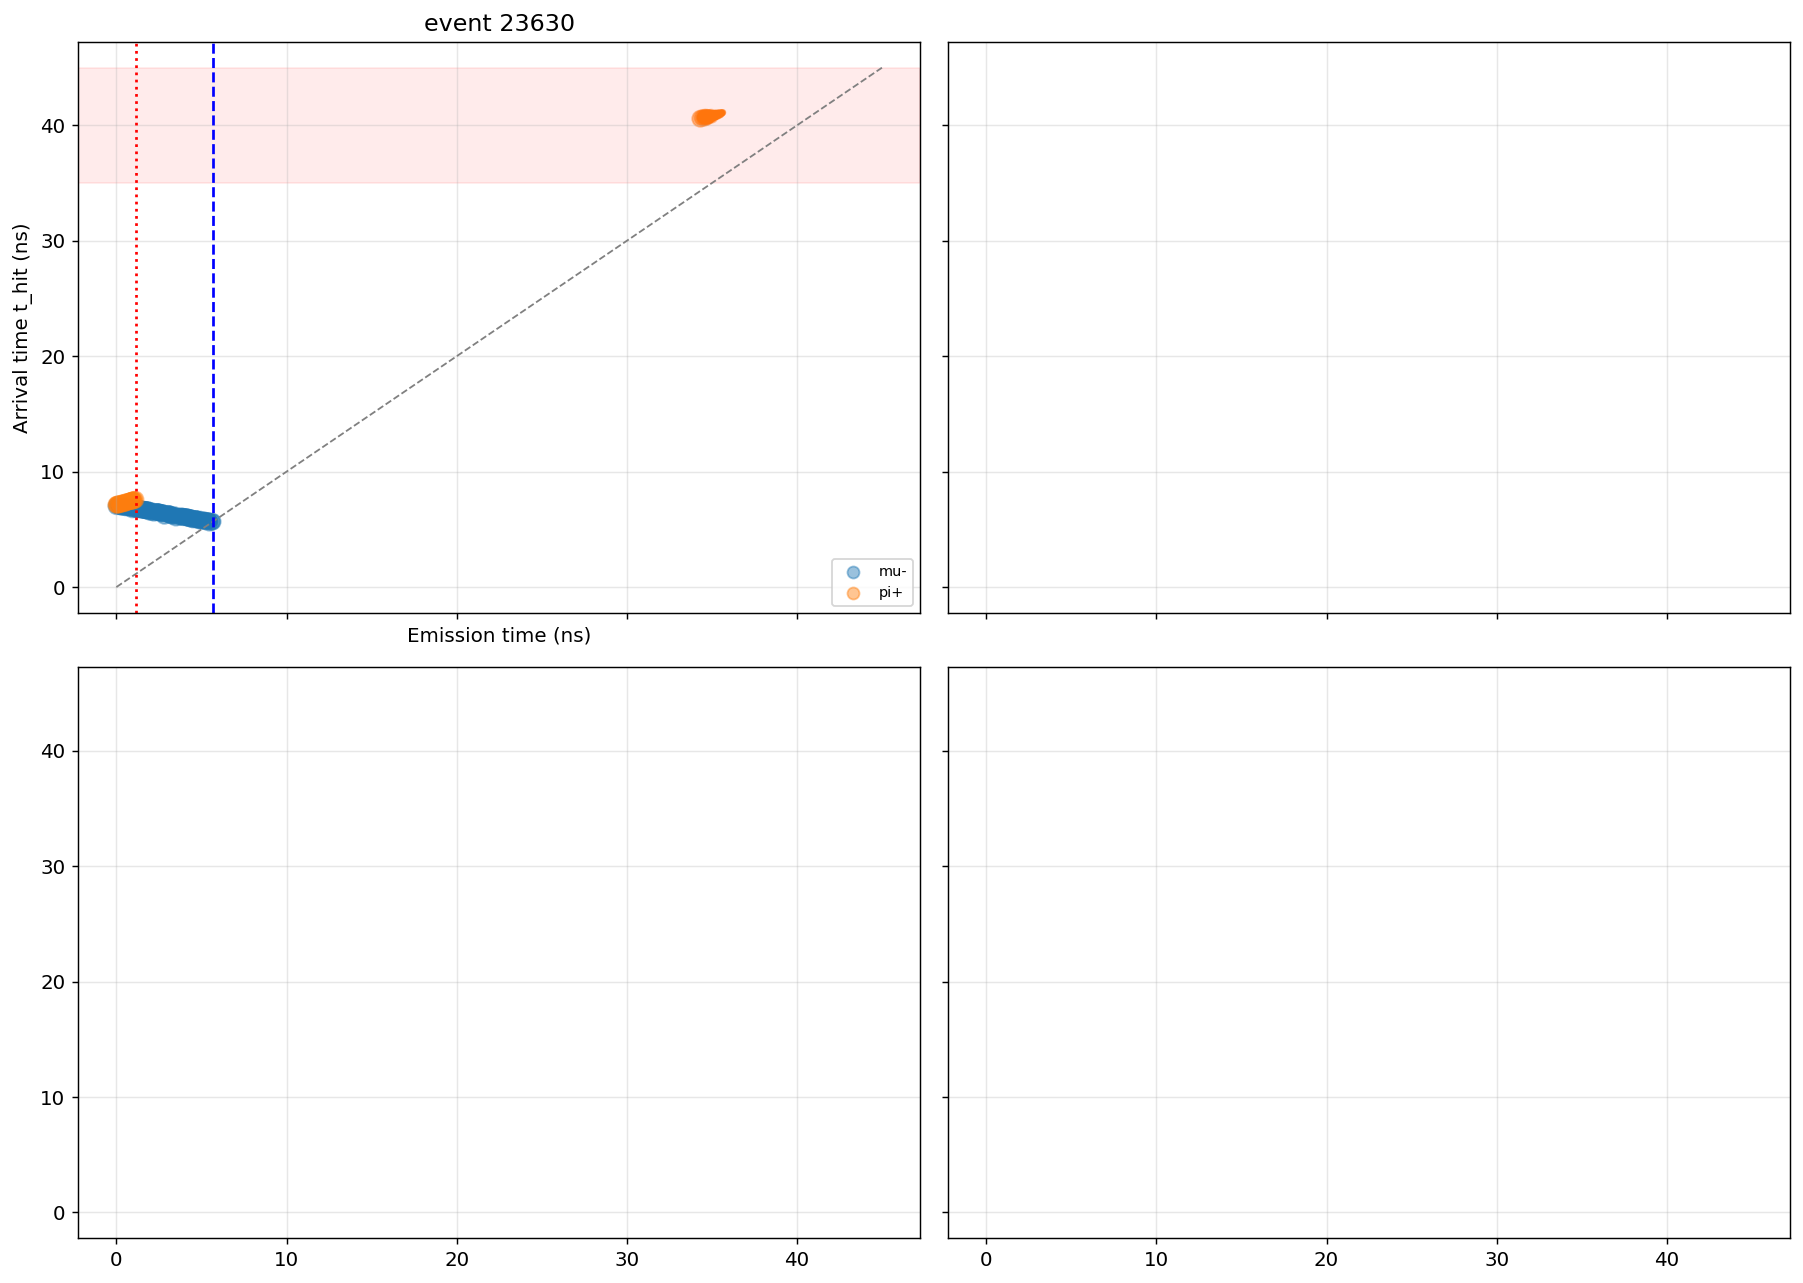

In [80]:
# ── Cell: Inspect the top individual events behind the late feature ───────────

if "late40" not in globals() or len(late40) == 0:
    raise RuntimeError("Run the late40 builder cell first.")

top_event_ids = (
    late40.groupby("event_id")["cher_step"]
    .sum()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print("Top event IDs driving the late feature:", top_event_ids)

inspect_parts = []

with uproot.open(SHUF_PATH) as f:
    st = choose_best_tree(f, "StepTree")
    cols = [
        "event_id", "particle", "parent_id", "track_id", "step_num",
        "x", "y", "z", "time", "cher_step", "process", "from_primary_pi"
    ]
    cols = [c for c in cols if c in st.keys()]

    for chunk in st.iterate(cols, step_size=CHUNK_SIZE, library="pd"):
        chunk["particle"] = clean_str_series(chunk["particle"])
        if "process" in chunk.columns:
            chunk["process"] = clean_str_series(chunk["process"])
        else:
            chunk["process"] = "unknown"

        if "from_primary_pi" in chunk.columns:
            chunk["from_primary_pi"] = chunk["from_primary_pi"].astype(bool)
        else:
            chunk["from_primary_pi"] = False

        chunk = chunk[
            chunk["event_id"].isin(top_event_ids) &
            (chunk["cher_step"] > 0)
        ].copy()
        if len(chunk) == 0:
            continue

        is_mu = (chunk["particle"] == "mu-") & (chunk["parent_id"] == 0)
        is_pi = (chunk["particle"] == "pi+") & (chunk["from_primary_pi"])
        chunk = chunk[is_mu | is_pi].copy()
        if len(chunk) == 0:
            continue

        d_wall = tof_to_cylinder(chunk["x"].values, chunk["y"].values, chunk["z"].values)
        chunk["tof_ns"] = d_wall / C_WATER
        chunk["t_hit"] = chunk["time"] + chunk["tof_ns"]
        inspect_parts.append(chunk)

inspect_df = pd.concat(inspect_parts, ignore_index=True)

meta_cols = [
    c for c in [
        "mu_water_exit_ns", "mu_time_stop", "pi_time_end",
        "mu_p0", "pi_p0", "open_angle_deg", "fate"
    ] if c in event_meta.columns
]
meta_inspect = event_meta.loc[top_event_ids, meta_cols].reset_index()
display(meta_inspect)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, eid in zip(axes, top_event_ids):
    sl = inspect_df[inspect_df["event_id"] == eid].copy().sort_values(["particle", "step_num"])

    mu = sl[sl["particle"] == "mu-"]
    pi = sl[sl["particle"] == "pi+"]

    if len(mu):
        ax.scatter(
            mu["time"], mu["t_hit"],
            s=np.clip(np.sqrt(mu["cher_step"]) * 4, 8, 80),
            alpha=0.45, label="mu-"
        )
    if len(pi):
        ax.scatter(
            pi["time"], pi["t_hit"],
            s=np.clip(np.sqrt(pi["cher_step"]) * 4, 8, 80),
            alpha=0.45, label="pi+"
        )

    # target late window
    ax.axhspan(T_LATE_MIN, T_LATE_MAX, alpha=0.08, color="red")
    # reference diagonals
    xline = np.linspace(0, max(sl["time"].max(), T_LATE_MAX), 100)
    ax.plot(xline, xline, color="gray", ls="--", lw=1)

    if eid in event_meta.index:
        row = event_meta.loc[eid]
        mu_exit = row["mu_water_exit_ns"] if "mu_water_exit_ns" in row else row.get("mu_time_stop", np.nan)
        pi_end = row.get("pi_time_end", np.nan)
        if pd.notna(mu_exit):
            ax.axvline(mu_exit, color="blue", ls="--", lw=1.5)
        if pd.notna(pi_end):
            ax.axvline(pi_end, color="red", ls=":", lw=1.5)

    ax.set_title(f"event {eid}")
    ax.set_xlabel("Emission time (ns)")
    ax.set_ylabel("Arrival time t_hit (ns)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [82]:
# ── Cell: Is the ~40 ns feature the original primary pi+ track? ──────────────

if "late40" not in globals() or len(late40) == 0:
    raise RuntimeError("Run the late40 builder cell first.")
if "ev_sig" not in globals():
    raise RuntimeError("Need ev_sig in memory.")

eid = int(late40["event_id"].iloc[0])
print("Late-feature event_id:", eid)

cols = ["event_id", "track_id", "parent_id", "step_num", "time", "t_hit",
        "tof_ns", "cher_step", "process", "particle", "from_primary_pi"]
show = late40[cols].sort_values(["track_id", "step_num"]).copy()

print("\nUnique late-feature track IDs:")
print(show["track_id"].value_counts().sort_index().to_string())

print("\nUnique parent IDs:")
print(show["parent_id"].value_counts().sort_index().to_string())

print("\nPer-track summary:")
track_summary = (
    show.groupby("track_id", as_index=False)
    .agg(
        parent_id=("parent_id", "first"),
        n_steps=("step_num", "count"),
        step_min=("step_num", "min"),
        step_max=("step_num", "max"),
        t_emit_min=("time", "min"),
        t_emit_max=("time", "max"),
        t_hit_min=("t_hit", "min"),
        t_hit_max=("t_hit", "max"),
        raw_cher=("cher_step", "sum"),
        process_first=("process", "first"),
    )
    .sort_values("raw_cher", ascending=False)
)
display(track_summary)

if "pi_track_id" in ev_sig.columns:
    primary_tid = ev_sig.loc[eid, "pi_track_id"]
    print(f"\nEventTree primary pi_track_id = {primary_tid}")
    print("Late-feature uses primary track?:", primary_tid in set(show["track_id"]))
else:
    print("\nNo pi_track_id column found in ev_sig, so cannot compare directly.")

print("\nFirst 30 late-feature rows:")
display(show.head(30))

Late-feature event_id: 23630

Unique late-feature track IDs:
219    51

Unique parent IDs:
42    51

Per-track summary:


,track_id,parent_id,n_steps,step_min,step_max,t_emit_min,t_emit_max,t_hit_min,t_hit_max,raw_cher,process_first
0,219,42,51,1,51,34.326977,35.646701,40.582776,41.116694,3872.110369,hIoni



EventTree primary pi_track_id = 2
Late-feature uses primary track?: False

First 30 late-feature rows:


,event_id,track_id,parent_id,step_num,time,t_hit,tof_ns,cher_step,process,particle,from_primary_pi
0,23630,219,42,1,34.326977,40.582776,6.255799,694.027983,hIoni,pi+,True
1,23630,219,42,2,34.432886,40.651687,6.218801,316.185661,hIoni,pi+,True
2,23630,219,42,3,34.484019,40.699202,6.215182,29.668089,hIoni,pi+,True
3,23630,219,42,4,34.488982,40.699558,6.210576,37.425852,hIoni,pi+,True
4,23630,219,42,5,34.495281,40.690531,6.195250,124.071902,hIoni,pi+,True
5,23630,219,42,6,34.516274,40.698769,6.182495,97.739536,hIoni,pi+,True
6,23630,219,42,7,34.533090,40.704164,6.171073,84.270171,hIoni,pi+,True
7,23630,219,42,8,34.547785,40.706065,6.158281,93.155444,hIoni,pi+,True
8,23630,219,42,9,34.564300,40.671341,6.107041,375.817222,hIoni,pi+,True
9,23630,219,42,10,34.631905,40.714277,6.082372,179.120905,hIoni,pi+,True


chunk 10
chunk 20
chunk 30
chunk 40
chunk 50
chunk 60


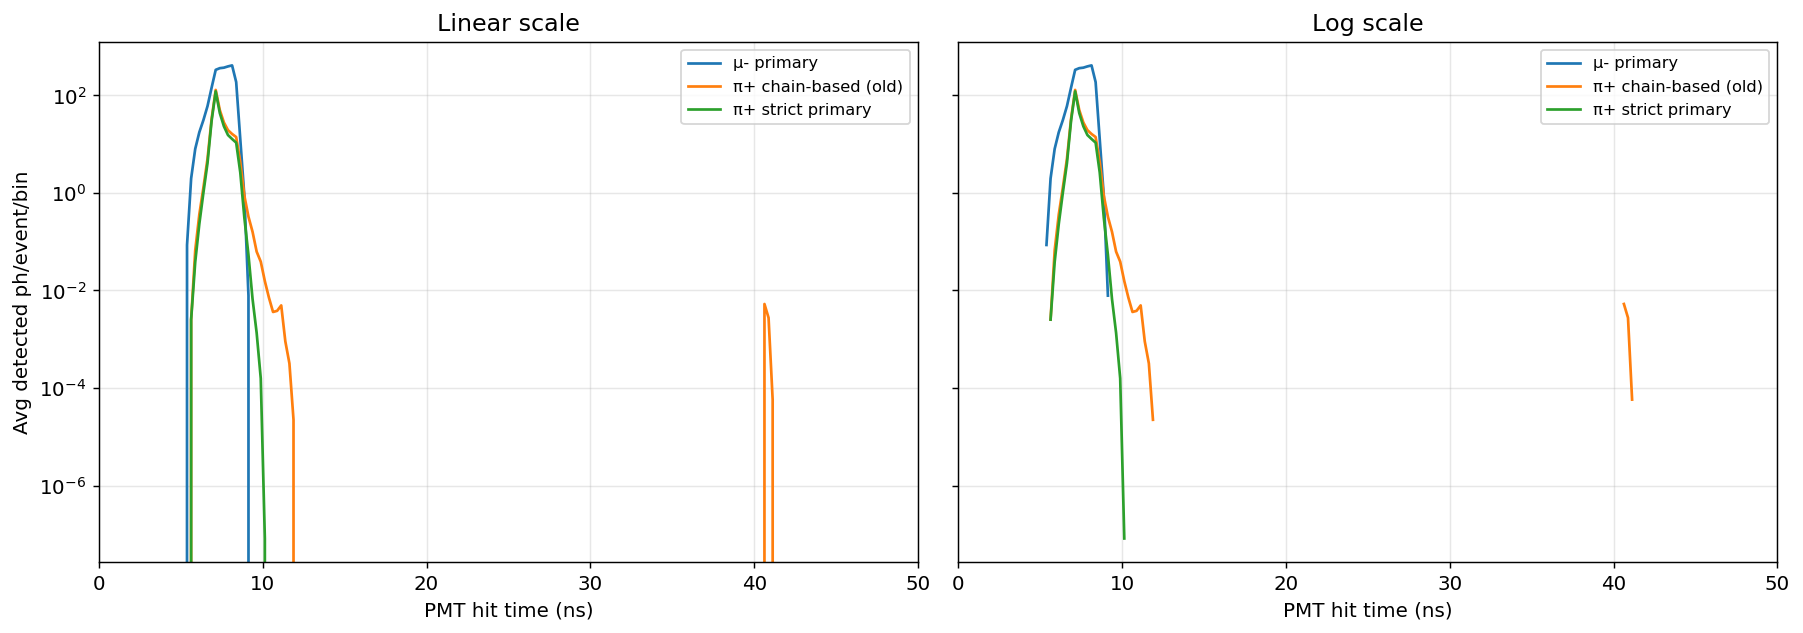

In [83]:
# ── Cell: Rebuild prompt timeline with STRICT primary pi+ only ────────────────

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "ev_sig" not in globals():
    raise RuntimeError("Need ev_sig in memory.")
if "pi_track_id" not in ev_sig.columns:
    raise RuntimeError("Need pi_track_id in ev_sig for strict-primary selection.")

# prompt bins
T_PROMPT_STRICT = np.linspace(0, 60, 241)
T_PROMPT_STRICT_C = 0.5 * (T_PROMPT_STRICT[:-1] + T_PROMPT_STRICT[1:])

sum_mu_strict = np.zeros(len(T_PROMPT_STRICT_C))
sum_pi_chain  = np.zeros(len(T_PROMPT_STRICT_C))
sum_pi_strict = np.zeros(len(T_PROMPT_STRICT_C))

sig_ids = set(np.int32(ev_sig.index.tolist()))
pi_tid_lookup = ev_sig["pi_track_id"].to_dict()

n_evt_mu = 0
n_evt_pi_chain = 0
n_evt_pi_strict = 0

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if "StepTree" in k])[-1]

    cols = ["event_id", "particle", "parent_id", "track_id",
            "x", "y", "z", "time", "cher_step", "from_primary_pi"]

    for i, chunk in enumerate(f[st_key].iterate(cols, step_size=500_000, library="pd")):
        chunk["particle"] = chunk["particle"].astype(str).str.strip().str.rstrip("\x00")
        chunk["from_primary_pi"] = chunk["from_primary_pi"].astype(bool)

        chunk = chunk[
            (chunk["event_id"].isin(sig_ids)) &
            (chunk["cher_step"] > 0)
        ].copy()
        if len(chunk) == 0:
            continue

        d_wall = tof_to_cylinder(chunk["x"].values, chunk["y"].values, chunk["z"].values)
        chunk["t_hit"] = chunk["time"] + d_wall / C_WATER
        chunk["cher_det"] = chunk["cher_step"] * DET_EFF

        mu = chunk[(chunk["particle"] == "mu-") & (chunk["parent_id"] == 0)].copy()

        # old selection
        pi_chain = chunk[(chunk["particle"] == "pi+") & (chunk["from_primary_pi"])].copy()

        # strict primary selection using pi_track_id
        pi_strict = chunk[chunk["particle"] == "pi+"].copy()
        if len(pi_strict):
            pi_strict["primary_tid"] = pi_strict["event_id"].map(pi_tid_lookup)
            pi_strict = pi_strict[pi_strict["track_id"] == pi_strict["primary_tid"]].copy()

        for eid, grp in mu.groupby("event_id"):
            sum_mu_strict += np.histogram(grp["t_hit"], bins=T_PROMPT_STRICT, weights=grp["cher_det"])[0]
            n_evt_mu += 1

        for eid, grp in pi_chain.groupby("event_id"):
            sum_pi_chain += np.histogram(grp["t_hit"], bins=T_PROMPT_STRICT, weights=grp["cher_det"])[0]
            n_evt_pi_chain += 1

        for eid, grp in pi_strict.groupby("event_id"):
            sum_pi_strict += np.histogram(grp["t_hit"], bins=T_PROMPT_STRICT, weights=grp["cher_det"])[0]
            n_evt_pi_strict += 1

        if (i + 1) % 10 == 0:
            print(f"chunk {i+1}")

avg_mu_strict = sum_mu_strict / max(n_evt_mu, 1)
avg_pi_chain  = sum_pi_chain  / max(n_evt_pi_chain, 1)
avg_pi_strict = sum_pi_strict / max(n_evt_pi_strict, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# linear
ax = axes[0]
ax.plot(T_PROMPT_STRICT_C, avg_mu_strict, label="μ- primary")
ax.plot(T_PROMPT_STRICT_C, avg_pi_chain, label="π+ chain-based (old)")
ax.plot(T_PROMPT_STRICT_C, avg_pi_strict, label="π+ strict primary")
ax.set_xlim(0, 50)
ax.set_xlabel("PMT hit time (ns)")
ax.set_ylabel("Avg detected ph/event/bin")
ax.set_title("Linear scale")
ax.legend(fontsize=9)

# log
ax = axes[1]
ax.semilogy(T_PROMPT_STRICT_C, np.where(avg_mu_strict > 0, avg_mu_strict, np.nan), label="μ- primary")
ax.semilogy(T_PROMPT_STRICT_C, np.where(avg_pi_chain > 0,  avg_pi_chain,  np.nan), label="π+ chain-based (old)")
ax.semilogy(T_PROMPT_STRICT_C, np.where(avg_pi_strict > 0, avg_pi_strict, np.nan), label="π+ strict primary")
ax.set_xlim(0, 50)
ax.set_xlabel("PMT hit time (ns)")
ax.set_title("Log scale")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [84]:
# Cell: define known one-event outlier mask
LATE_OUTLIER_EID = 23630

ev_sig_no23630 = ev_sig[ev_sig.index != LATE_OUTLIER_EID].copy()

print("Original ev_sig events     :", len(ev_sig))
print("Without event 23630        :", len(ev_sig_no23630))
print("Removed event present?     :", LATE_OUTLIER_EID in ev_sig_no23630.index)

Original ev_sig events     : 12029
Without event 23630        : 12028
Removed event present?     : False


chunk 10
chunk 20
chunk 30
chunk 40
chunk 50
chunk 60


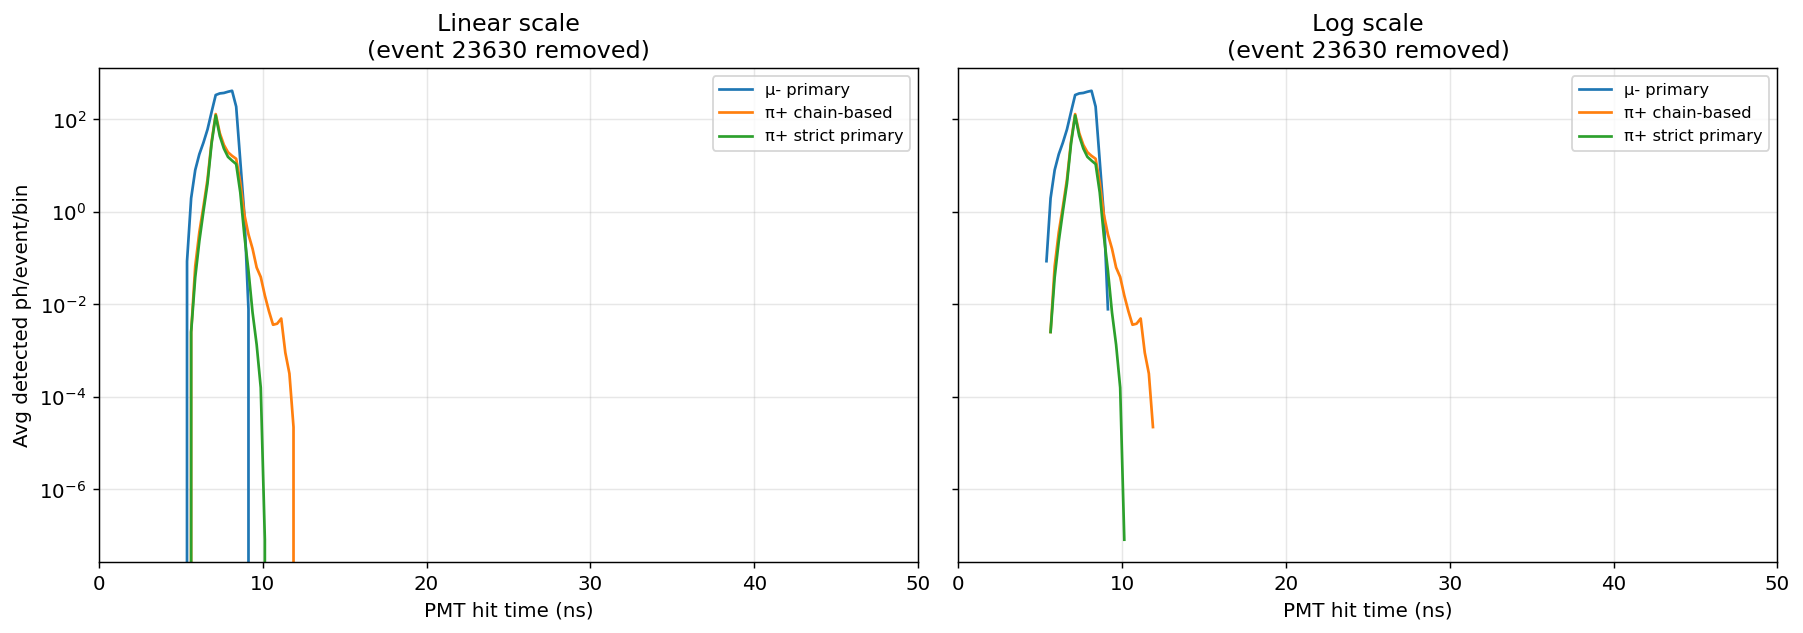

In [85]:
# ── Cell: Strict primary π+ prompt timeline excluding event 23630 ────────────

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "ev_sig" not in globals():
    raise RuntimeError("Need ev_sig in memory.")
if "pi_track_id" not in ev_sig.columns:
    raise RuntimeError("Need pi_track_id in ev_sig for strict-primary selection.")

EXCLUDE_EID = 23630

ev_use = ev_sig[ev_sig.index != EXCLUDE_EID].copy()

T_PROMPT_STRICT = np.linspace(0, 60, 241)
T_PROMPT_STRICT_C = 0.5 * (T_PROMPT_STRICT[:-1] + T_PROMPT_STRICT[1:])

sum_mu_strict = np.zeros(len(T_PROMPT_STRICT_C))
sum_pi_chain  = np.zeros(len(T_PROMPT_STRICT_C))
sum_pi_strict = np.zeros(len(T_PROMPT_STRICT_C))

sig_ids = set(np.int32(ev_use.index.tolist()))
pi_tid_lookup = ev_use["pi_track_id"].to_dict()

n_evt_mu = 0
n_evt_pi_chain = 0
n_evt_pi_strict = 0

with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if "StepTree" in k])[-1]

    cols = ["event_id", "particle", "parent_id", "track_id",
            "x", "y", "z", "time", "cher_step", "from_primary_pi"]

    for i, chunk in enumerate(f[st_key].iterate(cols, step_size=500_000, library="pd")):
        chunk["particle"] = chunk["particle"].astype(str).str.strip().str.rstrip("\x00")
        chunk["from_primary_pi"] = chunk["from_primary_pi"].astype(bool)

        chunk = chunk[
            (chunk["event_id"].isin(sig_ids)) &
            (chunk["cher_step"] > 0)
        ].copy()
        if len(chunk) == 0:
            continue

        d_wall = tof_to_cylinder(chunk["x"].values, chunk["y"].values, chunk["z"].values)
        chunk["t_hit"] = chunk["time"] + d_wall / C_WATER
        chunk["cher_det"] = chunk["cher_step"] * DET_EFF

        mu = chunk[(chunk["particle"] == "mu-") & (chunk["parent_id"] == 0)].copy()

        # old broader chain-based pion selection
        pi_chain = chunk[(chunk["particle"] == "pi+") & (chunk["from_primary_pi"])].copy()

        # strict original primary π+ only
        pi_strict = chunk[chunk["particle"] == "pi+"].copy()
        if len(pi_strict):
            pi_strict["primary_tid"] = pi_strict["event_id"].map(pi_tid_lookup)
            pi_strict = pi_strict[pi_strict["track_id"] == pi_strict["primary_tid"]].copy()

        for eid, grp in mu.groupby("event_id"):
            sum_mu_strict += np.histogram(grp["t_hit"], bins=T_PROMPT_STRICT, weights=grp["cher_det"])[0]
            n_evt_mu += 1

        for eid, grp in pi_chain.groupby("event_id"):
            sum_pi_chain += np.histogram(grp["t_hit"], bins=T_PROMPT_STRICT, weights=grp["cher_det"])[0]
            n_evt_pi_chain += 1

        for eid, grp in pi_strict.groupby("event_id"):
            sum_pi_strict += np.histogram(grp["t_hit"], bins=T_PROMPT_STRICT, weights=grp["cher_det"])[0]
            n_evt_pi_strict += 1

        if (i + 1) % 10 == 0:
            print(f"chunk {i+1}")

avg_mu_strict = sum_mu_strict / max(n_evt_mu, 1)
avg_pi_chain  = sum_pi_chain  / max(n_evt_pi_chain, 1)
avg_pi_strict = sum_pi_strict / max(n_evt_pi_strict, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax = axes[0]
ax.plot(T_PROMPT_STRICT_C, avg_mu_strict, label="μ- primary")
ax.plot(T_PROMPT_STRICT_C, avg_pi_chain, label="π+ chain-based")
ax.plot(T_PROMPT_STRICT_C, avg_pi_strict, label="π+ strict primary")
ax.set_xlim(0, 50)
ax.set_xlabel("PMT hit time (ns)")
ax.set_ylabel("Avg detected ph/event/bin")
ax.set_title("Linear scale\n(event 23630 removed)")
ax.legend(fontsize=9)

ax = axes[1]
ax.semilogy(T_PROMPT_STRICT_C, np.where(avg_mu_strict > 0, avg_mu_strict, np.nan), label="μ- primary")
ax.semilogy(T_PROMPT_STRICT_C, np.where(avg_pi_chain > 0,  avg_pi_chain,  np.nan), label="π+ chain-based")
ax.semilogy(T_PROMPT_STRICT_C, np.where(avg_pi_strict > 0, avg_pi_strict, np.nan), label="π+ strict primary")
ax.set_xlim(0, 50)
ax.set_xlabel("PMT hit time (ns)")
ax.set_title("Log scale\n(event 23630 removed)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Original ev_sig size : 12029
Plotting ev_sig size : 12028
Excluded event IDs   : [23630]
chunk 10
chunk 20
chunk 30
chunk 40
chunk 50
chunk 60


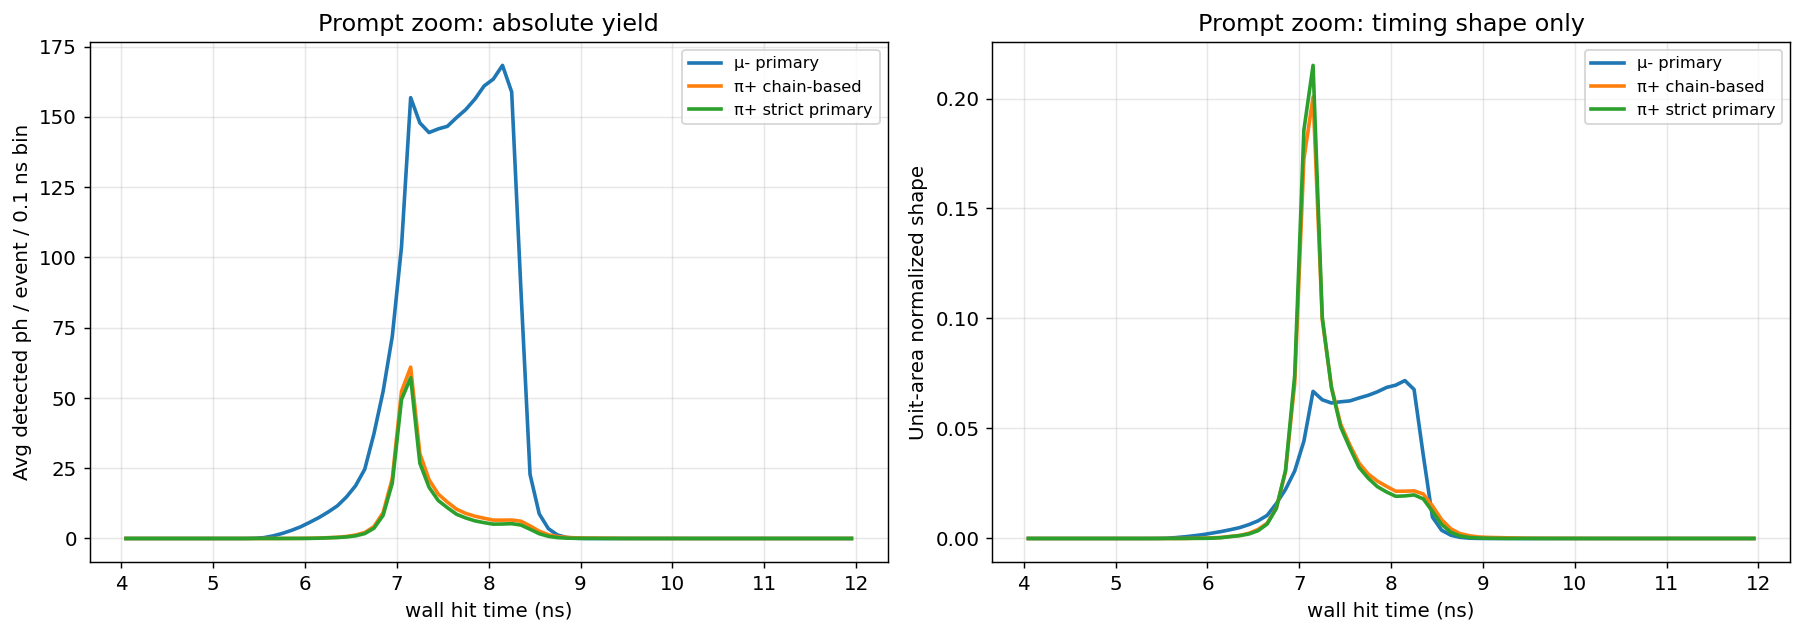

HIGH-RES PROMPT ZOOM SUMMARY
μ- peak time                : 8.15 ns
π+ chain-based peak time    : 7.15 ns
π+ strict primary peak time : 7.15 ns

μ- integrated prompt light (4–12 ns)                : 2345.023
π+ chain-based integrated prompt light (4–12 ns)    : 303.734
π+ strict primary integrated prompt light (4–12 ns) : 266.053


In [88]:
# ── Cell: High-resolution prompt zoom (self-contained, event 23630 removed) ──

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# Fallbacks / constants
# -----------------------------
try:
    SHUF_PATH
except NameError:
    SHUF_PATH = Path(r"D:\research\ANNIE\simualtion\my_geant4\annie_coprimary30kshuffled.root")

try:
    DET_EFF
except NameError:
    DET_EFF = 0.025

try:
    C_WATER
except NameError:
    C_WATER = 299.792 / 1.34

try:
    R_CYL
except NameError:
    R_CYL = 1600.0

try:
    Z_MAX
except NameError:
    Z_MAX = 2000.0

OUTLIER_EIDS = {23630}

def tof_to_cylinder(x, y, z):
    r = np.sqrt(x**2 + y**2)
    d_barrel = np.clip(R_CYL - r, 0, None)
    d_endcap = np.clip(np.where(z >= 0, Z_MAX - z, Z_MAX + z), 0, None)
    return np.minimum(d_barrel, d_endcap)

# -----------------------------
# Build plotting sample
# -----------------------------
if "ev_sig" not in globals():
    raise RuntimeError("Need ev_sig in memory first.")

ev_sig_plot = ev_sig.copy()

# make sure event_id/index handling is clean
if "event_id" not in ev_sig_plot.columns:
    ev_sig_plot["event_id"] = ev_sig_plot.index

ev_sig_plot["event_id"] = pd.to_numeric(ev_sig_plot["event_id"], errors="coerce")
ev_sig_plot = ev_sig_plot.dropna(subset=["event_id"]).copy()
ev_sig_plot["event_id"] = ev_sig_plot["event_id"].astype(np.int32)
ev_sig_plot = ev_sig_plot.set_index("event_id", drop=False)

if "pi_track_id" not in ev_sig_plot.columns:
    raise RuntimeError("Need pi_track_id in ev_sig. Re-run the EventTree setup cell that loads pi_track_id.")

ev_sig_plot = ev_sig_plot[~ev_sig_plot.index.isin(OUTLIER_EIDS)].copy()

print("Original ev_sig size :", len(ev_sig))
print("Plotting ev_sig size :", len(ev_sig_plot))
print("Excluded event IDs   :", sorted(OUTLIER_EIDS))

# -----------------------------
# High-resolution prompt bins
# -----------------------------
T_ZOOM = np.arange(4.0, 12.0 + 0.1, 0.1)
T_ZOOM_C = 0.5 * (T_ZOOM[:-1] + T_ZOOM[1:])

sum_mu = np.zeros(len(T_ZOOM_C))
sum_pi_chain = np.zeros(len(T_ZOOM_C))
sum_pi_strict = np.zeros(len(T_ZOOM_C))

sig_ids = set(np.int32(ev_sig_plot.index.tolist()))
pi_tid_lookup = ev_sig_plot["pi_track_id"].to_dict()

n_mu = 0
n_pi_chain = 0
n_pi_strict = 0

# -----------------------------
# Scan StepTree
# -----------------------------
with uproot.open(SHUF_PATH) as f:
    st_key = sorted([k for k in f.keys() if "StepTree" in k])[-1]

    cols = [
        "event_id", "particle", "parent_id", "track_id",
        "x", "y", "z", "time", "cher_step", "from_primary_pi"
    ]

    for i, chunk in enumerate(f[st_key].iterate(cols, step_size=500_000, library="pd")):
        chunk["particle"] = chunk["particle"].astype(str).str.strip().str.rstrip("\x00")
        chunk["from_primary_pi"] = chunk["from_primary_pi"].astype(bool)

        chunk = chunk[
            (chunk["event_id"].isin(sig_ids)) &
            (chunk["cher_step"] > 0)
        ].copy()
        if len(chunk) == 0:
            continue

        d_wall = tof_to_cylinder(chunk["x"].values, chunk["y"].values, chunk["z"].values)
        chunk["t_hit"] = chunk["time"] + d_wall / C_WATER
        chunk["cher_det"] = chunk["cher_step"] * DET_EFF

        mu = chunk[(chunk["particle"] == "mu-") & (chunk["parent_id"] == 0)].copy()

        # broader chain-based pion selection
        pi_chain = chunk[
            (chunk["particle"] == "pi+") &
            (chunk["from_primary_pi"])
        ].copy()

        # strict original primary π+ only
        pi_strict = chunk[chunk["particle"] == "pi+"].copy()
        if len(pi_strict):
            pi_strict["primary_tid"] = pi_strict["event_id"].map(pi_tid_lookup)
            pi_strict = pi_strict[pi_strict["track_id"] == pi_strict["primary_tid"]].copy()

        for _, grp in mu.groupby("event_id"):
            sum_mu += np.histogram(grp["t_hit"], bins=T_ZOOM, weights=grp["cher_det"])[0]
            n_mu += 1

        for _, grp in pi_chain.groupby("event_id"):
            sum_pi_chain += np.histogram(grp["t_hit"], bins=T_ZOOM, weights=grp["cher_det"])[0]
            n_pi_chain += 1

        for _, grp in pi_strict.groupby("event_id"):
            sum_pi_strict += np.histogram(grp["t_hit"], bins=T_ZOOM, weights=grp["cher_det"])[0]
            n_pi_strict += 1

        if (i + 1) % 10 == 0:
            print(f"chunk {i+1}")

avg_mu = sum_mu / max(n_mu, 1)
avg_pi_chain = sum_pi_chain / max(n_pi_chain, 1)
avg_pi_strict = sum_pi_strict / max(n_pi_strict, 1)

def unit_area(y):
    s = np.nansum(y)
    return y / s if s > 0 else y

shape_mu = unit_area(avg_mu)
shape_pi_chain = unit_area(avg_pi_chain)
shape_pi_strict = unit_area(avg_pi_strict)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(T_ZOOM_C, avg_mu, label="μ- primary", lw=2)
ax.plot(T_ZOOM_C, avg_pi_chain, label="π+ chain-based", lw=2)
ax.plot(T_ZOOM_C, avg_pi_strict, label="π+ strict primary", lw=2)
ax.set_xlabel("wall hit time (ns)")
ax.set_ylabel("Avg detected ph / event / 0.1 ns bin")
ax.set_title("Prompt zoom: absolute yield")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(T_ZOOM_C, shape_mu, label="μ- primary", lw=2)
ax.plot(T_ZOOM_C, shape_pi_chain, label="π+ chain-based", lw=2)
ax.plot(T_ZOOM_C, shape_pi_strict, label="π+ strict primary", lw=2)
ax.set_xlabel("wall hit time (ns)")
ax.set_ylabel("Unit-area normalized shape")
ax.set_title("Prompt zoom: timing shape only")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("=" * 60)
print("HIGH-RES PROMPT ZOOM SUMMARY")
print("=" * 60)
print(f"μ- peak time                : {T_ZOOM_C[np.nanargmax(avg_mu)]:.2f} ns")
print(f"π+ chain-based peak time    : {T_ZOOM_C[np.nanargmax(avg_pi_chain)]:.2f} ns")
print(f"π+ strict primary peak time : {T_ZOOM_C[np.nanargmax(avg_pi_strict)]:.2f} ns")
print()
print(f"μ- integrated prompt light (4–12 ns)                : {np.nansum(avg_mu):.3f}")
print(f"π+ chain-based integrated prompt light (4–12 ns)    : {np.nansum(avg_pi_chain):.3f}")
print(f"π+ strict primary integrated prompt light (4–12 ns) : {np.nansum(avg_pi_strict):.3f}")